Clustering flow regime and finding alpha ( with meaningful statistic )

Tập trung vào phân cụm và kết quả phân cụm
- Sử dụng K-Means để pcum và KNN để dự đoán
- Sử dụng CAPM để đo lường mức độ ý nghĩa của alpha và beta (của VNINDEX)

In [7]:
SYMBOL = 'PNJ'

In [1]:
import json
import math
from math import pi
import os
import re
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandas_ta as ta
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import requests
import seaborn as sns
from tqdm import tqdm

from arch import arch_model
import google.generativeai as genai
from scipy import stats
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_coeffs, savgol_filter
from scipy.stats import norm

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.power import TTestPower  # Sửa lại từ TTestPower cho chuẩn statsmodels

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import TimeSeriesSplit
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import QuantileTransformer, StandardScaler

# --- Path Setup & Project Imports ---
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..', '..', '..'))  # Go up 3 levels to mle_stock
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from analysis.core import StockAnalyzer

# --- Initialization ---
warnings.filterwarnings('ignore')  # Tắt các cảnh báo không cần thiết
analyzer = StockAnalyzer()
print("✅ Analyzer initialized successfully.")

C:\Users\HELLO\AppData\Local\Temp\ipykernel_16056\843579783.py:21: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


✅ Đã load cấu hình Database: localhost:5432/stock_db
✅ Analyzer initialized successfully.


# 1. Nhập dữ liệu đầu vào

In [2]:
def load_and_map_excel(excel_path, df_history):
    """
    Đọc file Excel mới, chuyển đổi format và gộp với dữ liệu lịch sử.
    """
    # 1. Đọc Excel
    df_new = pd.read_csv(excel_path)
    
    # 2. Mapping cột Tiếng Việt -> English
    mapping = {
        'NGÀY': 'time',
        'GIÁ': 'close',
        'MỞ': 'open',
        'CAO': 'high',
        'THẤP': 'low',
        'KL KHỚP': 'volume',
        'GT KHỚP': 'trading_value',
        'GT Nước Ngoài Khớp Ròng': 'foreign_net_val',
        'GT Tự doanh Khớp Ròng': 'prop_net_val',
        'GT Cá Nhân Khớp Ròng': 'local_ind_net_val',
        'GT Tổ chức Khớp Ròng': 'local_inst_net_val', # Nếu cần
        'KL Nước Ngoài Khớp Ròng': 'foreign_net_vol',
        'KL Tự doanh Khớp Ròng': 'prop_net_vol',
        'KL Cá Nhân Khớp Ròng': 'local_ind_net_vol',
        'KL Tổ chức Khớp Ròng': 'local_inst_net_vol', # Nếu cần
    }
    
    df_new = df_new.rename(columns=mapping)
    df_new['time'] = pd.to_datetime(df_new['time'], format='%d/%m/%Y')
    
    # Tính toán các cột bổ trợ để không làm lỗi hàm Feature Engineering cũ
    # Vì Excel chỉ có Net, ta giả định Buy/Sell dựa trên Net để hàm không lỗi
    # for g in investor_groups:
    #     if f'{g}_net_val' in df_new.columns:
    #         # Fake buy/sell để tránh lỗi chia cho 0 khi tính sentiment
    #         # Logic: Buy = Net nếu Net > 0, Sell = |Net| nếu Net < 0
    #         df_new[f'{g}_buy_val'] = df_new[f'{g}_net_val'].apply(lambda x: x if x > 0 else 0)
    #         df_new[f'{g}_sell_val'] = df_new[f'{g}_net_val'].apply(lambda x: abs(x) if x < 0 else 0)
    
    # 3. Gộp với lịch sử để tính được các chỉ số MA20, MA50, Accu_20d
    # Chỉ lấy các cột cần thiết từ df_history
    df_combined = pd.concat([df_history, df_new], axis=0).drop_duplicates(subset=['time']).sort_values('time')
    
    return df_combined.reset_index(drop=True)

In [8]:
# --- BƯỚC 1: CHUẨN BỊ DỮ LIỆU ---
excel_file_path_vni = rf"E:\Document\Tao\FiinGroup\csv_data\Kafi_Phân_Loại_Nhà_Đầu_Tư_{SYMBOL}.csv"
excel_file_path_vni_new = rf"E:\Document\Tao\FiinGroup\csv_data\Kafi_Giá_{SYMBOL}.csv"

investor_groups = ['foreign', 'prop', 'local_ind', 'local_inst']

df_vni_raw = load_and_map_excel(excel_file_path_vni, df_history=None)

In [382]:
def preliminary_data_evaluation(df_raw):
    """
    Báo cáo đánh giá sơ bộ dữ liệu thô.
    Tự động chuyển đổi đơn vị sang Tỷ đồng để dễ quan sát.
    """
    df = df_raw.copy()
    
    # Danh sách các cột tiền tệ cần quy đổi (VND -> Tỷ VND)
    val_cols = [col for col in df.columns if '_val' in col or 'value' in col or 'close' in col]
    # Ngoại lệ: close/open/high/low thường là điểm số hoặc đơn vị nghìn đồng, không nên chia 1e9 
    # trừ khi bạn muốn đưa giá VNINDEX về dạng đơn vị khác. 
    # Ở đây tôi chỉ quy đổi dòng tiền (Value).
    money_cols = [col for col in df.columns if '_val' in col or 'trading_value' in col]

    print("="*70)
    print(f"📊 BÁO CÁO ĐÁNH GIÁ DỮ LIỆU ĐẦU VÀO (Đơn vị: Tỷ VNĐ)")
    print(f"- Khoảng thời gian: {df['time'].min().date()} -> {df['time'].max().date()}")
    print(f"- Tổng số phiên: {len(df)}")
    print("="*70)

    # 1. BÁO CÁO CHẤT LƯỢNG (NaN & ZERO)
    quality_report = []
    for col in df.columns:
        nan_count = df[col].isnull().sum()
        zero_count = (df[col] == 0).sum()
        quality_report.append({
            'Cột': col,
            'Thiếu (NaN)': nan_count,
            'Bằng 0': zero_count,
            '% Lỗi': round((nan_count + zero_count) / len(df) * 100, 1)
        })
    df_quality = pd.DataFrame(quality_report).sort_values('% Lỗi', ascending=False)
    
    print("\n[!] Top 5 cột cần lưu ý về dữ liệu:")
    display(df_quality.head(5))

    # 2. THỐNG KÊ MÔ TẢ (CHUYỂN SANG TỶ ĐỒNG)
    # Chỉ thống kê các cột dòng tiền chính
    core_flow_cols = ['trading_value', 'foreign_net_val', 'prop_net_val', 'local_ind_net_val']
    core_flow_cols = [c for c in core_flow_cols if c in df.columns]
    
    desc_stats = df[core_flow_cols].describe()
    # Quy đổi từ đồng sang Tỷ đồng (chia cho 1,000,000,000)
    desc_stats_billion = desc_stats / 1e9
    # Riêng dòng 'count' không được chia
    desc_stats_billion.loc['count'] = desc_stats.loc['count']

    print("\n📈 BẢNG THỐNG KÊ DÒNG TIỀN (Đơn vị: Tỷ VNĐ):")
    # Format hiển thị có dấu phẩy và 2 chữ số thập phân
    display(desc_stats_billion.style.format(precision=2, thousands=","))

    # 3. BIỂU ĐỒ TRỰC QUAN (Hóa lỏng con số)
    fig = make_subplots(rows=4, cols=1, shared_xaxes=True, vertical_spacing=0.05,
                        subplot_titles=('BIẾN ĐỘNG GIÁ', 'DÒNG TIỀN NƯỚC NGOÀI (Tỷ VNĐ)', 'DÒNG TIỀN TỰ DOANH (Tỷ VNĐ)', 'DÒNG TIỀN CÁ NHÂN (Tỷ VNĐ)'))

    fig.add_trace(go.Scatter(x=df['time'], y=df['close'], name='Price', line=dict(color='black')), row=1, col=1)
    
    # Plot ròng tỷ đồng
    f_net_billion = df['foreign_net_val'] / 1e9
    p_net_billion = df['prop_net_val'] / 1e9
    lcind_net_billion = df['local_ind_net_val'] / 1e9
    
    fig.add_trace(go.Bar(x=df['time'], y=f_net_billion, name='Foreign Net', 
                         marker_color=['red' if x < 0 else 'green' for x in f_net_billion]), row=2, col=1)
    
    fig.add_trace(go.Bar(x=df['time'], y=p_net_billion, name='Prop Net', 
                         marker_color=['red' if x < 0 else 'green' for x in p_net_billion]), row=3, col=1)
    
    fig.add_trace(go.Bar(x=df['time'], y=lcind_net_billion, name='Local Net', 
                         marker_color=['red' if x < 0 else 'green' for x in lcind_net_billion]), row=4, col=1)

    fig.update_layout(height=800, title_text="KHẢO SÁT DÒNG TIỀN THỊ TRƯỜNG (QUY ĐỔI TỶ VNĐ)", showlegend=False)
    fig.show()

# --- Thực thi ---
preliminary_data_evaluation(df_vni_raw)

📊 BÁO CÁO ĐÁNH GIÁ DỮ LIỆU ĐẦU VÀO (Đơn vị: Tỷ VNĐ)
- Khoảng thời gian: 2019-06-12 -> 2026-08-21
- Tổng số phiên: 1800

[!] Top 5 cột cần lưu ý về dữ liệu:


,Cột,Thiếu (NaN),Bằng 0,% Lỗi
16,prop_net_vol,0,424,23.6000
20,prop_net_val,0,424,23.6000
10,KL THỎA THUẬN,0,235,13.1000
11,GT THỎA THUẬN,0,235,13.1000
4,%THAY ĐỔI,0,108,6.0000



📈 BẢNG THỐNG KÊ DÒNG TIỀN (Đơn vị: Tỷ VNĐ):


,trading_value,foreign_net_val,prop_net_val,local_ind_net_val
count,"1,800.00","1,800.00","1,800.00","1,800.00"
mean,727.14,-17.20,0.40,13.33
std,589.25,140.97,32.48,130.89
min,43.73,"-1,044.94",-204.20,"-1,166.43"
25%,346.15,-58.51,-7.88,-41.27
50%,571.30,-10.29,0.00,5.62
75%,929.70,30.11,8.49,59.26
max,"5,730.02","1,756.55",327.17,872.51


# Tinh chỉnh parameter thêm các tác động qua lại của các nđt
Tóm lại, tôi đánh giá feature hiện tại của bạn đã đủ giàu, thậm chí hơi nhiều. Tôi không muốn “thêm feature để model mạnh hơn”; tôi muốn tối ưu time horizon của những feature quan trọng và bổ sung thông tin quan hệ giữa investor groups. Nếu làm đúng, tôi nghĩ 7 hyperparameters (a,b,c,d,rsi,ma,impact) là một mức khá đẹp; tôi chưa muốn vượt quá khoảng 8–10 hyperparameters cho 300–500 trials.

Không phải chỉ range, mà VIF còn đang tác động đến việc này nữa

PNJ
  a = 160, b = 130, c = 25, d = 20
  a = 120, b = 100, c = 25, d = 30

TCB
a = 200, b = 200, c = 75, d = 35
a = 140, b = 140, c = 45, d = 20 (Max VIF              : 67.02)
a = 150, b = 120, c = 45, d = 25

MBB
a = 70, b = 70, c = 75, d = 40
a = 70, b = 70, c = 65, d = 5

FPT
a = 80, b = 80, c = 75, d = 15
a = 70, b = 70, c = 40, d = 20
a = 80, b = 60, c = 50, d = 20

HPG
a = 110, b = 70, c = 80, d = 10
a = 120, b = 100, c = 75, d = 30
a = 200, b = 110, c = 70, d = 15

SSI
  a = 160, b = 140, c = 80, d = 20
  a = 160, b = 140, c = 70, d = 20

In [353]:
import optuna
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from scipy.stats import spearmanr
from numpy.linalg import pinv
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# CẤU HÌNH CHUNG
# ============================================================
investor_groups = ["foreign", "prop", "local_inst", "local_ind"]
LOOKBACK_DAYS = 1000
OOS_DAYS = 40
TRIALS = 300
max_vif_set = 100000

# ==================== ĐIỀU KHIỂN QUAN HỆ a-b-c-d ====================
# Bạn chỉ cần sửa các dòng dưới đây

# Range tuyệt đối
A_MIN, A_MAX = 20, 200
B_MIN, B_MAX = 20, 160
C_MIN, C_MAX = 15, 70
D_MIN, D_MAX = 5, 30

# Quan hệ giữa a và b
ALLOW_A_GREATER_THAN_B = True      # True  = cho phép a ≥ b

# Quan hệ khác (tuỳ chọn)
MAX_C = 100
MAX_D = 40

# =====================================================================

HARD_MIN_HIT_RATE = 0.50
MIN_TOP_DECILE_HIT = 0.65

OPTIMIZE_A = True
OPTIMIZE_B = True
OPTIMIZE_C = True
OPTIMIZE_D = True

FIXED_A = 100
FIXED_B = 100
FIXED_C = 15
FIXED_D = 5

# ============================================================
# VIF (giữ nguyên)
# ============================================================
def fast_vif(X_scaled: np.ndarray) -> np.ndarray:
    n_features = X_scaled.shape[1]
    if n_features == 0:
        return np.array([])
    corr = np.corrcoef(X_scaled, rowvar=False)
    corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
    try:
        inv_corr = pinv(corr)
        vifs = np.diag(inv_corr)
    except Exception:
        vifs = np.full(n_features, 999.0)
    return np.maximum(vifs, 1.0)


def iterative_vif_exclude_fast(X_df, threshold=5.0, max_iter=40, min_features=8):
    cols = list(X_df.columns)
    excluded = []
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_df[cols])

    for _ in range(max_iter):
        if len(cols) <= min_features:
            break
        vifs = fast_vif(X_scaled)
        if np.max(vifs) <= threshold:
            break
        worst_idx = int(np.argmax(vifs))
        excluded.append(cols[worst_idx])
        cols.pop(worst_idx)
        X_scaled = np.delete(X_scaled, worst_idx, axis=1)

    final_max_vif = float(np.max(fast_vif(X_scaled))) if len(cols) > 0 else 1.0
    return excluded, cols, final_max_vif


# ============================================================
# HÀM ĐÁNH GIÁ – VERSION ƯU TIÊN TOP DECILE + IC
# ============================================================
def evaluate_params_interaction(
    a, b, c, d,
    df_vni_raw,
    investor_groups,
    w_ic=0.65,
    w_hit=0.35,
    min_hit_rate=0.50,
    min_signals=20,
    vif_threshold=8.0,
    lookback_days=LOOKBACK_DAYS,
    oos_days=OOS_DAYS,
):
    try:
        df = df_vni_raw.copy()

        keep_cols = [
            'open', 'high', 'low', 'close', 'trading_value',
            'foreign_net_val', 'prop_net_val', 'local_ind_net_val', 'local_inst_net_val',
            'foreign_net_vol', 'prop_net_vol', 'local_ind_net_vol', 'local_inst_net_vol',
        ]
        keep_cols = [col for col in keep_cols if col in df.columns]
        df = df[keep_cols]

        df['trading_value'] = df['trading_value'].replace(0, np.nan).interpolate()
        df['close'] = df['close'].ffill()
        df['log_ret'] = np.log(df['close'] / df['close'].shift(1)).fillna(0)
        df['abs_ret'] = df['log_ret'].abs()

        tr = np.maximum(
            df['high'] - df['low'],
            np.maximum(
                (df['high'] - df['close'].shift(1)).abs(),
                (df['low'] - df['close'].shift(1)).abs()
            )
        )
        df['target_ret_t10'] = df['close'].shift(-10) / df['close'] - 1

        for g in investor_groups:
            net_val = df[f'{g}_net_val']
            net_ratio = net_val / df['trading_value']
            df[f'feat_{g}_net_ratio'] = net_ratio.fillna(0)

            prev = net_ratio.shift(1).abs()
            df[f'feat_{g}_price_impact'] = (df['abs_ret'].shift(1) / (prev + 1e-6)).rolling(5).median()

            mu = df[f'feat_{g}_net_ratio'].rolling(a).mean()
            sigma = df[f'feat_{g}_net_ratio'].rolling(a).std()
            df[f'feat_{g}_zscore'] = ((df[f'feat_{g}_net_ratio'] - mu) / (sigma + 1e-8)).clip(-4, 4).fillna(0)

            rmin = net_val.rolling(a).min()
            rmax = net_val.rolling(a).max()
            df[f'feat_{g}_sentiment'] = (2 * (net_val - rmin) / (rmax - rmin + 1e-6) - 1).fillna(0)

        df = df.replace([np.inf, -np.inf], 0).fillna(0)

        # ===================== FEATURE FACTORY =====================
        feature_dict = {}

        delta = df["close"].diff()
        gain = delta.clip(lower=0).rolling(14).mean()
        loss = (-delta.clip(upper=0)).rolling(14).mean()
        rs = gain / (loss + 1e-8)
        rsi = 100 - (100 / (1 + rs))
        feature_dict["ta_rsi_norm"] = (rsi / 100.0) - 0.5

        ma20 = df["close"].rolling(20).mean()
        feature_dict["ta_dist_ma20"] = (df["close"] - ma20) / ma20

        roll_high = df["high"].rolling(c).max()
        roll_low = df["low"].rolling(c).min()
        feature_dict["ta_pos_in_range"] = (df["close"] - roll_low) / (roll_high - roll_low + 1e-8)

        feature_dict["ta_atr_pct"] = tr.ewm(span=b, adjust=False).mean() / df["close"]

        for g in investor_groups:
            sent = df[f"feat_{g}_sentiment"]
            sent_ewm = sent.ewm(span=b, adjust=False).mean()
            feature_dict[f"feat_{g}_sentiment_ewm"] = sent_ewm

            sent_mean = sent_ewm.rolling(a, min_periods=10).mean()
            sent_std = sent_ewm.rolling(a, min_periods=10).std().replace(0, np.nan)
            sent_z = ((sent_ewm - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

            feature_dict[f"feat_{g}_sentiment_sq"] = sent_z**2
            feature_dict[f"feat_{g}_sentiment_cubed"] = (sent_z**3 - 3 * sent_z).clip(-10, 10)

            impulse = sent_ewm.diff(d).fillna(0)
            feature_dict[f"feat_{g}_flow_impulse_{d}d"] = impulse

            imp_mean = impulse.rolling(a, min_periods=10).mean()
            imp_std = impulse.rolling(a, min_periods=10).std().replace(0, np.nan)
            imp_z = ((impulse - imp_mean) / (imp_std + 1e-6)).clip(-3, 3).fillna(0)

            feature_dict[f"feat_{g}_flow_impulse_{d}d_sq"] = imp_z**2
            feature_dict[f"feat_{g}_flow_impulse_{d}d_cubed"] = (imp_z**3 - 3 * imp_z).clip(-10, 10)

            feature_dict[f"feat_{g}_eff_flow"] = sent * df[f"feat_{g}_price_impact"]
            feature_dict[f"feat_{g}_val_share"] = df[f"{g}_net_val"].abs() / df["trading_value"]

            implied = np.where(df[f"{g}_net_vol"] != 0, df[f"{g}_net_val"] / df[f"{g}_net_vol"], 0)
            feature_dict[f"feat_{g}_rel_net_price_ewm"] = (
                pd.Series(implied / df["close"], index=df.index).ewm(span=b, adjust=False).mean()
            )

            feature_dict[f"inter_{g}_sent_x_pos"]    = sent_z * feature_dict["ta_pos_in_range"]
            feature_dict[f"inter_{g}_sent_x_rsi"]    = sent_z * feature_dict["ta_rsi_norm"]
            feature_dict[f"inter_{g}_sent_x_distma"] = sent_z * feature_dict["ta_dist_ma20"]
            feature_dict[f"inter_{g}_imp_x_atr"]     = imp_z  * feature_dict["ta_atr_pct"]
            feature_dict[f"inter_{g}_eff_x_pos"]     = feature_dict[f"feat_{g}_eff_flow"] * feature_dict["ta_pos_in_range"]
            feature_dict[f"inter_{g}_sent_x_atr"]    = sent_z * feature_dict["ta_atr_pct"]

        # ============================================================
        # CROSS-INVESTOR FEATURES (Toàn bộ mối quan hệ)
        # ============================================================
        groups = investor_groups  # ["foreign", "prop", "local_inst", "local_ind"]

        # Lấy các series đã có
        sent_ewm = {g: feature_dict[f"feat_{g}_sentiment_ewm"] for g in groups}
        sent_z   = {}
        for g in groups:
            # tái tạo sent_z nếu cần (hoặc lấy từ biến đã tính trước đó)
            sent = df[f"feat_{g}_sentiment"]
            sent_ewm_g = sent.ewm(span=b, adjust=False).mean()
            sent_mean = sent_ewm_g.rolling(a, min_periods=10).mean()
            sent_std  = sent_ewm_g.rolling(a, min_periods=10).std().replace(0, np.nan)
            sent_z[g] = ((sent_ewm_g - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

        net_ratio = {g: df[f"feat_{g}_net_ratio"] for g in groups}

        # ----------------------------------------------------------
        # 1. Relative Flow (chênh lệch) – tất cả cặp
        # ----------------------------------------------------------
        from itertools import combinations

        for g1, g2 in combinations(groups, 2):
            # Chênh lệch sentiment EWM
            feature_dict[f"cross_{g1}_minus_{g2}_sent"] = sent_ewm[g1] - sent_ewm[g2]
            
            # Chênh lệch z-score
            feature_dict[f"cross_{g1}_minus_{g2}_sent_z"] = sent_z[g1] - sent_z[g2]
            
            # Chênh lệch net_ratio
            feature_dict[f"cross_{g1}_minus_{g2}_net"] = net_ratio[g1] - net_ratio[g2]
            
            # Absolute difference (độ lớn sự khác biệt)
            feature_dict[f"cross_abs_{g1}_{g2}_sent"] = (sent_ewm[g1] - sent_ewm[g2]).abs()

        # ----------------------------------------------------------
        # 2. Agreement / Disagreement
        # ----------------------------------------------------------
        for g1, g2 in combinations(groups, 2):
            # Cùng chiều hay ngược chiều (sign agreement)
            sign_agree = np.sign(sent_ewm[g1]) * np.sign(sent_ewm[g2])
            feature_dict[f"cross_agree_sign_{g1}_{g2}"] = sign_agree
            
            # Strength-weighted agreement (càng lớn càng đồng thuận mạnh)
            feature_dict[f"cross_agree_strength_{g1}_{g2}"] = sent_ewm[g1] * sent_ewm[g2]
            
            # Disagreement magnitude
            feature_dict[f"cross_disagree_{g1}_{g2}"] = (sent_ewm[g1] - sent_ewm[g2]).abs() * (1 - sign_agree.abs())

        # ----------------------------------------------------------
        # 3. Dispersion (độ phân tán giữa tất cả nhóm)
        # ----------------------------------------------------------
        # Stack tất cả sentiment_ewm
        sent_matrix = pd.concat([sent_ewm[g] for g in groups], axis=1)
        sent_matrix.columns = groups

        feature_dict["cross_dispersion_std"] = sent_matrix.std(axis=1)           # độ lệch chuẩn giữa 4 nhóm
        feature_dict["cross_dispersion_range"] = sent_matrix.max(axis=1) - sent_matrix.min(axis=1)  # range
        feature_dict["cross_dispersion_iqr"] = sent_matrix.quantile(0.75, axis=1) - sent_matrix.quantile(0.25, axis=1)

        # Dispersion của net_ratio
        net_matrix = pd.concat([net_ratio[g] for g in groups], axis=1)
        net_matrix.columns = groups
        feature_dict["cross_net_dispersion_std"] = net_matrix.std(axis=1)
        feature_dict["cross_net_dispersion_range"] = net_matrix.max(axis=1) - net_matrix.min(axis=1)

        # ----------------------------------------------------------
        # 4. Dominance Ratio (tỷ trọng dòng tiền)
        # ----------------------------------------------------------
        total_abs_net = sum(df[f"{g}_net_val"].abs() for g in groups) + 1e-8

        for g in groups:
            feature_dict[f"cross_dominance_{g}"] = df[f"{g}_net_val"].abs() / total_abs_net

        # Dominance của nhóm tổ chức vs cá nhân
        inst_abs = df["local_inst_net_val"].abs() + df["foreign_net_val"].abs()
        ind_abs  = df["local_ind_net_val"].abs() + df["prop_net_val"].abs()
        feature_dict["cross_dominance_inst_vs_ind"] = (inst_abs - ind_abs) / (inst_abs + ind_abs + 1e-8)

        # ----------------------------------------------------------
        # 5. Pairwise rolling agreement (tương quan ngắn hạn)
        # ----------------------------------------------------------
        for g1, g2 in combinations(groups, 2):
            # Rolling correlation của sentiment (cửa sổ cố định 10 & 20)
            for win in [10, 20]:
                corr = sent_ewm[g1].rolling(win, min_periods=5).corr(sent_ewm[g2])
                feature_dict[f"cross_corr_{g1}_{g2}_{win}d"] = corr.fillna(0)

        # ----------------------------------------------------------
        # 6. Net Pressure & Composite Signals
        # ----------------------------------------------------------
        # Tổng dòng tiền có trọng số (foreign + local_inst mạnh hơn)
        feature_dict["cross_net_pressure_smart"] = (
            1.5 * sent_ewm["foreign"] +
            1.2 * sent_ewm["local_inst"] +
            1.0 * sent_ewm["prop"] +
            0.7 * sent_ewm["local_ind"]
        )

        # Pure institutional pressure
        feature_dict["cross_inst_pressure"] = sent_ewm["foreign"] + sent_ewm["local_inst"]

        # Pure retail pressure
        feature_dict["cross_retail_pressure"] = sent_ewm["prop"] + sent_ewm["local_ind"]

        # Smart vs Retail
        feature_dict["cross_smart_minus_retail"] = (
            feature_dict["cross_inst_pressure"] - feature_dict["cross_retail_pressure"]
        )

        # ----------------------------------------------------------
        # 7. Extreme Disagreement flags (optional, có thể hữu ích)
        # ----------------------------------------------------------
        feature_dict["cross_extreme_disagree"] = (
            (feature_dict["cross_dispersion_std"] > feature_dict["cross_dispersion_std"].rolling(60).quantile(0.9))
        ).astype(float)

        df_feat = pd.DataFrame(feature_dict, index=df.index)
        model_data = pd.concat([df_feat, df["target_ret_t10"]], axis=1)
        model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()

        if len(model_data) < (lookback_days + oos_days + 50):
            return -999.0, -1.0, 0.0, 0.0, [], 999.0, 0

        train_data = model_data.iloc[-(lookback_days + oos_days) : -oos_days].copy()
        if len(train_data) < 300:
            return -999.0, -1.0, 0.0, 0.0, [], 999.0, 0

        X_all = train_data.drop(columns=["target_ret_t10"])
        y = train_data["target_ret_t10"].values

        cols_to_exclude, remaining_cols, final_max_vif = iterative_vif_exclude_fast(
            X_all, threshold=vif_threshold, max_iter=40, min_features=8
        )
        if len(remaining_cols) < 8:
            return -999.0, -1.0, 0.0, 0.0, cols_to_exclude, final_max_vif, 0

        X = X_all[remaining_cols].values
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        model = LinearRegression()
        model.fit(X_scaled, y)
        pred = model.predict(X_scaled)

        # ============================================================
        # METRICS CƠ BẢN
        # ============================================================
        ic, _ = spearmanr(pred, y)
        if np.isnan(ic):
            ic = -1.0

        mask_up = pred > 0
        n_signals = int(mask_up.sum())
        hit_rate_up = (y[mask_up] > 0).mean() if n_signals >= min_signals else 0.50
        avg_ret_when_up = float(y[mask_up].mean()) if n_signals >= min_signals else 0.0

        # ============================================================
        # METRICS THEO DECILE (quan trọng nhất)
        # ============================================================
        try:
            deciles = pd.qcut(pred, 10, labels=False, duplicates="drop")
        except Exception:
            return -999.0, ic, hit_rate_up, avg_ret_when_up, cols_to_exclude, final_max_vif, n_signals

        df_dec = pd.DataFrame({"pred": pred, "y": y, "decile": deciles})
        
        # Thống kê từng decile
        decile_stats = df_dec.groupby("decile").agg(
            mean_ret=("y", "mean"),
            hit_rate=("y", lambda x: (x > 0).mean()),
            count=("y", "count")
        ).reindex(range(10))

        # 2 decile cao nhất (8 và 9)
        top_deciles = decile_stats.loc[[8, 9]].dropna()
        bottom_deciles = decile_stats.loc[[0, 1]].dropna()

        if len(top_deciles) < 1:
            return -999.0, ic, hit_rate_up, avg_ret_when_up, cols_to_exclude, final_max_vif, n_signals

        top_hit = top_deciles["hit_rate"].mean()
        top_mean_ret = top_deciles["mean_ret"].mean()
        bottom_mean_ret = bottom_deciles["mean_ret"].mean() if len(bottom_deciles) > 0 else 0.0

        # Kiểm tra tính đơn điệu đơn giản (mean return tăng theo decile)
        mean_rets = decile_stats["mean_ret"].dropna().values
        if len(mean_rets) >= 5:
            mono_score = spearmanr(np.arange(len(mean_rets)), mean_rets)[0]
            if np.isnan(mono_score):
                mono_score = 0.0
        else:
            mono_score = 0.0

        # ============================================================
        # SCORE MỚI – ƯU TIÊN TOP DECILE + IC
        # ============================================================
        # 1. IC (quan trọng nhất)
        ic_term = np.clip(ic, -0.3, 0.9)

        # 2. Chất lượng 2 decile cao nhất
        top_hit_term = np.clip((top_hit - 0.50) / 0.40, 0, 1.5)          # 0.50→0 , 0.90→1.0
        top_ret_term = np.clip(top_mean_ret * 20, 0, 1.5)                 # thưởng mean return cao

        # 3. Khuyến khích bottom decile có return thấp
        bottom_term = np.clip(-bottom_mean_ret * 15, 0, 1.0)

        # 4. Overall hit chỉ cần quanh 50%
        overall_hit_term = 1.0 - abs(hit_rate_up - 0.52) * 2               # càng gần 0.50–0.55 càng tốt
        overall_hit_term = np.clip(overall_hit_term, 0.3, 1.0)

        # 5. Monotonicity
        mono_term = np.clip(mono_score, 0, 1.0)

        # Tổng hợp score
        score = (
            0.42 * ic_term +
            0.28 * top_hit_term +
            0.15 * top_ret_term +
            0.08 * bottom_term +
            0.04 * mono_term +
            0.03 * overall_hit_term
        )

        # Soft penalty nếu top decile chưa đủ tốt
        if top_hit < MIN_TOP_DECILE_HIT:
            score *= 0.55

        if top_mean_ret < 0.002:          # mean return top quá thấp
            score *= 0.7

        # Hard constraint cuối
        if (
            ic < 0.03
            or top_hit < 0.58
            or n_signals < max(10, min_signals // 2)
            or hit_rate_up < 0.47
        ):
            score = -999.0

        return (
            float(score),
            float(ic),
            float(hit_rate_up),
            float(avg_ret_when_up),
            cols_to_exclude,
            final_max_vif,
            n_signals,
            float(top_hit),               # thêm để theo dõi
            float(top_mean_ret),
            float(mono_score)
        )

    except Exception:
        return -999.0, -1.0, 0.0, 0.0, [], 999.0, 0, 0.0, 0.0, 0.0


def objective(trial):
    # ----- Suggest a -----
    if OPTIMIZE_A:
        a = trial.suggest_int("window_z", A_MIN, A_MAX, step=10)
    else:
        a = FIXED_A

    # ----- Suggest b (phụ thuộc vào a và cờ ALLOW_A_GREATER_THAN_B) -----
    if OPTIMIZE_B:
        if ALLOW_A_GREATER_THAN_B:
            # Cho phép a ≥ b  →  b có thể từ B_MIN đến min(B_MAX, a)
            b_low = B_MIN
            b_high = min(B_MAX, a)
        else:
            # Bắt buộc a ≤ b  →  b phải ≥ a
            b_low = max(B_MIN, a)
            b_high = B_MAX

        # Đảm bảo low <= high (tránh lỗi Optuna)
        if b_low > b_high:
            b_low = b_high

        b = trial.suggest_int("window_div", int(b_low), int(b_high), step=10)
    else:
        b = FIXED_B

    # ----- Suggest c, d (độc lập) -----
    if OPTIMIZE_C:
        c = trial.suggest_int("test_pos_range", C_MIN, C_MAX, step=5)
    else:
        c = FIXED_C

    if OPTIMIZE_D:
        d = trial.suggest_int("days", D_MIN, D_MAX, step=5)
    else:
        d = FIXED_D

    # ----- Kiểm tra ràng buộc lần cuối (an toàn) -----
    if ALLOW_A_GREATER_THAN_B:
        if a < b:          # không được a < b
            return -999.0
    else:
        if a > b:          # không được a > b
            return -999.0

    # ----- Gọi hàm đánh giá -----
    result = evaluate_params_interaction(
        a, b, c, d,
        df_vni_raw,
        investor_groups,
        w_ic=0.65,
        w_hit=0.35,
        min_hit_rate=0.50,
        min_signals=20,
        vif_threshold=max_vif_set,          # bạn đang để 20
        lookback_days=LOOKBACK_DAYS,
        oos_days=OOS_DAYS,
    )

    if len(result) >= 10:
        score, ic, hit_up, avg_ret_up, excluded, max_vif, n_signals, top_hit, top_mean, mono = result
    else:
        score, ic, hit_up, avg_ret_up, excluded, max_vif, n_signals = result[:7]
        top_hit = top_mean = mono = 0.0

    # Lưu thông tin
    trial.set_user_attr("ic", ic)
    trial.set_user_attr("hit_rate_up", hit_up)
    trial.set_user_attr("avg_ret_when_up", avg_ret_up)
    trial.set_user_attr("n_signals", n_signals)
    trial.set_user_attr("top_decile_hit", top_hit)
    trial.set_user_attr("top_decile_mean_ret", top_mean)
    trial.set_user_attr("mono_score", mono)
    trial.set_user_attr("cols_to_exclude", excluded)
    trial.set_user_attr("max_vif", max_vif)
    trial.set_user_attr("n_excluded", len(excluded))
    trial.set_user_attr("a", a)
    trial.set_user_attr("b", b)
    trial.set_user_attr("c", c)
    trial.set_user_attr("d", d)
    trial.set_user_attr("a_minus_b", a - b)

    return score

# ============================================================
# CHẠY OPTUNA
# ============================================================
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=20, n_warmup_steps=10),
)

study.optimize(objective, n_trials=TRIALS, show_progress_bar=True)

# ============================================================
# KẾT QUẢ
# ============================================================
best = study.best_trial
print("\n" + "="*70)
print("BEST TRIAL – ƯU TIÊN TOP DECILE + IC")
print("="*70)
print(f"Score                : {best.value:.4f}")
print(f"IC                   : {best.user_attrs['ic']:.4f}")
print(f"Hit Rate overall     : {best.user_attrs['hit_rate_up']:.4f}")
print(f"Top Decile Hit       : {best.user_attrs['top_decile_hit']:.4f}")
print(f"Top Decile Mean Ret  : {best.user_attrs['top_decile_mean_ret']:.5f}")
print(f"Mono Score           : {best.user_attrs['mono_score']:.4f}")
print(f"Số tín hiệu          : {best.user_attrs['n_signals']}")
print(f"Max VIF              : {best.user_attrs['max_vif']:.2f}")

print(f"\nGiá trị a/b/c/d:")
print(f"  a = {best.user_attrs['a']}, b = {best.user_attrs['b']}, "
    f"c = {best.user_attrs['c']}, d = {best.user_attrs['d']}")

[I 2026-08-24 23:28:23,623] A new study created in memory with name: no-name-e1f4b623-79dd-470b-81b2-5ee9b7eb9bc7


  0%|          | 0/300 [00:00<?, ?it/s]

[I 2026-08-24 23:28:23,789] Trial 0 finished with value: 0.9939739515212084 and parameters: {'window_z': 90, 'window_div': 90, 'test_pos_range': 55, 'days': 20}. Best is trial 0 with value: 0.9939739515212084.
[I 2026-08-24 23:28:23,941] Trial 1 finished with value: 0.854530667326986 and parameters: {'window_z': 40, 'window_div': 20, 'test_pos_range': 15, 'days': 30}. Best is trial 0 with value: 0.9939739515212084.
[I 2026-08-24 23:28:24,083] Trial 2 finished with value: 0.9434772973426161 and parameters: {'window_z': 130, 'window_div': 100, 'test_pos_range': 15, 'days': 30}. Best is trial 0 with value: 0.9939739515212084.
[I 2026-08-24 23:28:24,214] Trial 3 finished with value: 0.9959622502281852 and parameters: {'window_z': 170, 'window_div': 50, 'test_pos_range': 25, 'days': 10}. Best is trial 3 with value: 0.9959622502281852.
[I 2026-08-24 23:28:24,339] Trial 4 finished with value: 0.9844234103093438 and parameters: {'window_z': 70, 'window_div': 50, 'test_pos_range': 40, 'days': 1

TCB
a = 140, b = 100, c = 50, d = 25

SSI
a = 160, b = 100, c = 70, d = 30

# Optuna 2

In [359]:
import optuna
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from scipy.stats import spearmanr
from numpy.linalg import pinv
import warnings
# warnings.filterwarnings("ignore")

# ============================================================
# CẤU HÌNH CHUNG
# ============================================================
investor_groups = ["foreign", "prop", "local_inst", "local_ind"]
LOOKBACK_DAYS = 1000
OOS_DAYS = 60
TRIALS = 300
max_vif_set = 100000

# ==================== ĐIỀU KHIỂN QUAN HỆ a-b-c-d ====================
# Bạn chỉ cần sửa các dòng dưới đây

# Range tuyệt đối
A_MIN, A_MAX = 10, 200
B_MIN, B_MAX = 10, 160
C_MIN, C_MAX = 10, 70
D_MIN, D_MAX = 5, 30

# Quan hệ giữa a và b
ALLOW_A_GREATER_THAN_B = True      # True  = cho phép a ≥ b

# Quan hệ khác (tuỳ chọn)
MAX_C = 100
MAX_D = 40

# =====================================================================

HARD_MIN_HIT_RATE = 0.60
MIN_TOP_DECILE_HIT = 0.75

OPTIMIZE_A = True
OPTIMIZE_B = True
OPTIMIZE_C = True
OPTIMIZE_D = True

FIXED_A = 200
FIXED_B = 200
FIXED_C = 15
FIXED_D = 10

# ============================================================
# VIF (giữ nguyên)
# ============================================================
def fast_vif(X_scaled: np.ndarray) -> np.ndarray:
    n_features = X_scaled.shape[1]
    if n_features == 0:
        return np.array([])
    corr = np.corrcoef(X_scaled, rowvar=False)
    corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
    try:
        inv_corr = pinv(corr)
        vifs = np.diag(inv_corr)
    except Exception:
        vifs = np.full(n_features, 999.0)
    return np.maximum(vifs, 1.0)


def iterative_vif_exclude_fast(X_df, threshold=5.0, max_iter=40, min_features=8):
    cols = list(X_df.columns)
    excluded = []
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_df[cols])

    for _ in range(max_iter):
        if len(cols) <= min_features:
            break
        vifs = fast_vif(X_scaled)
        if np.max(vifs) <= threshold:
            break
        worst_idx = int(np.argmax(vifs))
        excluded.append(cols[worst_idx])
        cols.pop(worst_idx)
        X_scaled = np.delete(X_scaled, worst_idx, axis=1)

    final_max_vif = float(np.max(fast_vif(X_scaled))) if len(cols) > 0 else 1.0
    return excluded, cols, final_max_vif


# ============================================================
# HÀM ĐÁNH GIÁ – VERSION ƯU TIÊN TOP DECILE + IC
# ============================================================
def evaluate_params_interaction(
    a, b, c, d,
    df_vni_raw,
    investor_groups,
    w_ic=0.65,
    w_hit=0.35,
    min_hit_rate=0.50,
    min_signals=20,
    vif_threshold=8.0,
    lookback_days=LOOKBACK_DAYS,
    oos_days=OOS_DAYS,
):
    try:
        df = df_vni_raw.copy()

        keep_cols = [
            'open', 'high', 'low', 'close', 'trading_value',
            'foreign_net_val', 'prop_net_val', 'local_ind_net_val', 'local_inst_net_val',
            'foreign_net_vol', 'prop_net_vol', 'local_ind_net_vol', 'local_inst_net_vol',
        ]
        keep_cols = [col for col in keep_cols if col in df.columns]
        df = df[keep_cols]

        df['trading_value'] = df['trading_value'].replace(0, np.nan).interpolate()
        df['close'] = df['close'].ffill()
        df['log_ret'] = np.log(df['close'] / df['close'].shift(1)).fillna(0)
        df['abs_ret'] = df['log_ret'].abs()

        tr = np.maximum(
            df['high'] - df['low'],
            np.maximum(
                (df['high'] - df['close'].shift(1)).abs(),
                (df['low'] - df['close'].shift(1)).abs()
            )
        )
        df['target_ret_t10'] = df['close'].shift(-10) / df['close'] - 1

        for g in investor_groups:
            net_val = df[f'{g}_net_val']
            net_ratio = net_val / df['trading_value']
            df[f'feat_{g}_net_ratio'] = net_ratio.fillna(0)

            prev = net_ratio.shift(1).abs()
            df[f'feat_{g}_price_impact'] = (df['abs_ret'].shift(1) / (prev + 1e-6)).rolling(5).median()

            mu = df[f'feat_{g}_net_ratio'].rolling(a).mean()
            sigma = df[f'feat_{g}_net_ratio'].rolling(a).std()
            df[f'feat_{g}_zscore'] = ((df[f'feat_{g}_net_ratio'] - mu) / (sigma + 1e-8)).clip(-4, 4).fillna(0)

            rmin = net_val.rolling(a).min()
            rmax = net_val.rolling(a).max()
            df[f'feat_{g}_sentiment'] = (2 * (net_val - rmin) / (rmax - rmin + 1e-6) - 1).fillna(0)

        df = df.replace([np.inf, -np.inf], 0).fillna(0)

        # ===================== FEATURE FACTORY =====================
        feature_dict = {}

        delta = df["close"].diff()
        gain = delta.clip(lower=0).rolling(14).mean()
        loss = (-delta.clip(upper=0)).rolling(14).mean()
        rs = gain / (loss + 1e-8)
        rsi = 100 - (100 / (1 + rs))
        feature_dict["ta_rsi_norm"] = (rsi / 100.0) - 0.5

        ma20 = df["close"].rolling(20).mean()
        feature_dict["ta_dist_ma20"] = (df["close"] - ma20) / ma20

        roll_high = df["high"].rolling(c).max()
        roll_low = df["low"].rolling(c).min()
        feature_dict["ta_pos_in_range"] = (df["close"] - roll_low) / (roll_high - roll_low + 1e-8)

        feature_dict["ta_atr_pct"] = tr.ewm(span=b, adjust=False).mean() / df["close"]

        for g in investor_groups:
            sent = df[f"feat_{g}_sentiment"]
            sent_ewm = sent.ewm(span=b, adjust=False).mean()
            feature_dict[f"feat_{g}_sentiment_ewm"] = sent_ewm

            sent_mean = sent_ewm.rolling(a, min_periods=10).mean()
            sent_std = sent_ewm.rolling(a, min_periods=10).std().replace(0, np.nan)
            sent_z = ((sent_ewm - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

            feature_dict[f"feat_{g}_sentiment_sq"] = sent_z**2
            feature_dict[f"feat_{g}_sentiment_cubed"] = (sent_z**3 - 3 * sent_z).clip(-10, 10)

            impulse = sent_ewm.diff(d).fillna(0)
            feature_dict[f"feat_{g}_flow_impulse_{d}d"] = impulse

            imp_mean = impulse.rolling(a, min_periods=10).mean()
            imp_std = impulse.rolling(a, min_periods=10).std().replace(0, np.nan)
            imp_z = ((impulse - imp_mean) / (imp_std + 1e-6)).clip(-3, 3).fillna(0)

            feature_dict[f"feat_{g}_flow_impulse_{d}d_sq"] = imp_z**2
            feature_dict[f"feat_{g}_flow_impulse_{d}d_cubed"] = (imp_z**3 - 3 * imp_z).clip(-10, 10)

            feature_dict[f"feat_{g}_eff_flow"] = sent * df[f"feat_{g}_price_impact"]
            feature_dict[f"feat_{g}_val_share"] = df[f"{g}_net_val"].abs() / df["trading_value"]

            implied = np.where(df[f"{g}_net_vol"] != 0, df[f"{g}_net_val"] / df[f"{g}_net_vol"], 0)
            feature_dict[f"feat_{g}_rel_net_price_ewm"] = (
                pd.Series(implied / df["close"], index=df.index).ewm(span=b, adjust=False).mean()
            )

            feature_dict[f"inter_{g}_sent_x_pos"]    = sent_z * feature_dict["ta_pos_in_range"]
            feature_dict[f"inter_{g}_sent_x_rsi"]    = sent_z * feature_dict["ta_rsi_norm"]
            feature_dict[f"inter_{g}_sent_x_distma"] = sent_z * feature_dict["ta_dist_ma20"]
            feature_dict[f"inter_{g}_imp_x_atr"]     = imp_z  * feature_dict["ta_atr_pct"]
            feature_dict[f"inter_{g}_eff_x_pos"]     = feature_dict[f"feat_{g}_eff_flow"] * feature_dict["ta_pos_in_range"]
            feature_dict[f"inter_{g}_sent_x_atr"]    = sent_z * feature_dict["ta_atr_pct"]

        df_feat = pd.DataFrame(feature_dict, index=df.index)
        model_data = pd.concat([df_feat, df["target_ret_t10"]], axis=1)
        model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()

        if len(model_data) < (lookback_days + oos_days + 50):
            return -999.0, -1.0, 0.0, 0.0, [], 999.0, 0

        train_data = model_data.iloc[-(lookback_days + oos_days) : -oos_days].copy()
        if len(train_data) < 300:
            return -999.0, -1.0, 0.0, 0.0, [], 999.0, 0

        X_all = train_data.drop(columns=["target_ret_t10"])
        y = train_data["target_ret_t10"].values

        cols_to_exclude, remaining_cols, final_max_vif = iterative_vif_exclude_fast(
            X_all, threshold=vif_threshold, max_iter=40, min_features=8
        )
        if len(remaining_cols) < 8:
            return -999.0, -1.0, 0.0, 0.0, cols_to_exclude, final_max_vif, 0

        X = X_all[remaining_cols].values
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        model = LinearRegression()
        model.fit(X_scaled, y)
        pred = model.predict(X_scaled)

        # ============================================================
        # METRICS CƠ BẢN
        # ============================================================
        ic, _ = spearmanr(pred, y)
        if np.isnan(ic):
            ic = -1.0

        mask_up = pred > 0
        n_signals = int(mask_up.sum())
        hit_rate_up = (y[mask_up] > 0).mean() if n_signals >= min_signals else 0.50
        avg_ret_when_up = float(y[mask_up].mean()) if n_signals >= min_signals else 0.0

        # ============================================================
        # METRICS THEO DECILE (quan trọng nhất)
        # ============================================================
        try:
            deciles = pd.qcut(pred, 10, labels=False, duplicates="drop")
        except Exception:
            return -999.0, ic, hit_rate_up, avg_ret_when_up, cols_to_exclude, final_max_vif, n_signals

        df_dec = pd.DataFrame({"pred": pred, "y": y, "decile": deciles})
        
        # Thống kê từng decile
        decile_stats = df_dec.groupby("decile").agg(
            mean_ret=("y", "mean"),
            hit_rate=("y", lambda x: (x > 0).mean()),
            count=("y", "count")
        ).reindex(range(10))

        # 2 decile cao nhất (8 và 9)
        top_deciles = decile_stats.loc[[8, 9]].dropna()
        bottom_deciles = decile_stats.loc[[0, 1]].dropna()

        if len(top_deciles) < 1:
            return -999.0, ic, hit_rate_up, avg_ret_when_up, cols_to_exclude, final_max_vif, n_signals

        top_hit = top_deciles["hit_rate"].mean()
        top_mean_ret = top_deciles["mean_ret"].mean()
        bottom_mean_ret = bottom_deciles["mean_ret"].mean() if len(bottom_deciles) > 0 else 0.0

        # Kiểm tra tính đơn điệu đơn giản (mean return tăng theo decile)
        mean_rets = decile_stats["mean_ret"].dropna().values
        if len(mean_rets) >= 5:
            mono_score = spearmanr(np.arange(len(mean_rets)), mean_rets)[0]
            if np.isnan(mono_score):
                mono_score = 0.0
        else:
            mono_score = 0.0

        # ============================================================
        # SCORE MỚI – ƯU TIÊN TOP DECILE + IC
        # ============================================================
        # 1. IC (quan trọng nhất)
        ic_term = np.clip(ic, -0.3, 0.9)

        # 2. Chất lượng 2 decile cao nhất
        top_hit_term = np.clip((top_hit - 0.50) / 0.40, 0, 1.5)          # 0.50→0 , 0.90→1.0
        top_ret_term = np.clip(top_mean_ret * 20, 0, 1.5)                 # thưởng mean return cao

        # 3. Khuyến khích bottom decile có return thấp
        bottom_term = np.clip(-bottom_mean_ret * 15, 0, 1.0)

        # 4. Overall hit chỉ cần quanh 50%
        overall_hit_term = 1.0 - abs(hit_rate_up - 0.52) * 2               # càng gần 0.50–0.55 càng tốt
        overall_hit_term = np.clip(overall_hit_term, 0.3, 1.0)

        # 5. Monotonicity
        mono_term = np.clip(mono_score, 0, 1.0)

        # Tổng hợp score
        score = (
            0.42 * ic_term +
            0.28 * top_hit_term +
            0.15 * top_ret_term +
            0.08 * bottom_term +
            0.04 * mono_term +
            0.03 * overall_hit_term
        )

        # Soft penalty nếu top decile chưa đủ tốt
        if top_hit < MIN_TOP_DECILE_HIT:
            score *= 0.55

        if top_mean_ret < 0.002:          # mean return top quá thấp
            score *= 0.7

        # Hard constraint cuối
        if (
            ic < 0.03
            or top_hit < 0.58
            or n_signals < max(10, min_signals // 2)
            or hit_rate_up < 0.47
        ):
            score = -999.0

        return (
            float(score),
            float(ic),
            float(hit_rate_up),
            float(avg_ret_when_up),
            cols_to_exclude,
            final_max_vif,
            n_signals,
            float(top_hit),               # thêm để theo dõi
            float(top_mean_ret),
            float(mono_score)
        )

    except Exception:
        return -999.0, -1.0, 0.0, 0.0, [], 999.0, 0, 0.0, 0.0, 0.0


def objective(trial):
    # ----- Suggest a -----
    if OPTIMIZE_A:
        a = trial.suggest_int("window_z", A_MIN, A_MAX, step=10)
    else:
        a = FIXED_A

    # ----- Suggest b (phụ thuộc vào a và cờ ALLOW_A_GREATER_THAN_B) -----
    if OPTIMIZE_B:
        if ALLOW_A_GREATER_THAN_B:
            # Cho phép a ≥ b  →  b có thể từ B_MIN đến min(B_MAX, a)
            b_low = B_MIN
            b_high = min(B_MAX, a)
        else:
            # Bắt buộc a ≤ b  →  b phải ≥ a
            b_low = max(B_MIN, a)
            b_high = B_MAX

        # Đảm bảo low <= high (tránh lỗi Optuna)
        if b_low > b_high:
            b_low = b_high

        b = trial.suggest_int("window_div", int(b_low), int(b_high), step=10)
    else:
        b = FIXED_B

    # ----- Suggest c, d (độc lập) -----
    if OPTIMIZE_C:
        c = trial.suggest_int("test_pos_range", C_MIN, C_MAX, step=5)
    else:
        c = FIXED_C

    if OPTIMIZE_D:
        d = trial.suggest_int("days", D_MIN, D_MAX, step=5)
    else:
        d = FIXED_D

    # ----- Kiểm tra ràng buộc lần cuối (an toàn) -----
    if ALLOW_A_GREATER_THAN_B:
        if a < b:          # không được a < b
            return -999.0
    else:
        if a > b:          # không được a > b
            return -999.0

    # ----- Gọi hàm đánh giá -----
    result = evaluate_params_interaction(
        a, b, c, d,
        df_vni_raw,
        investor_groups,
        w_ic=0.65,
        w_hit=0.35,
        min_hit_rate=0.50,
        min_signals=20,
        vif_threshold=max_vif_set,          # bạn đang để 20
        lookback_days=LOOKBACK_DAYS,
        oos_days=OOS_DAYS,
    )

    if len(result) >= 10:
        score, ic, hit_up, avg_ret_up, excluded, max_vif, n_signals, top_hit, top_mean, mono = result
    else:
        score, ic, hit_up, avg_ret_up, excluded, max_vif, n_signals = result[:7]
        top_hit = top_mean = mono = 0.0

    # Lưu thông tin
    trial.set_user_attr("ic", ic)
    trial.set_user_attr("hit_rate_up", hit_up)
    trial.set_user_attr("avg_ret_when_up", avg_ret_up)
    trial.set_user_attr("n_signals", n_signals)
    trial.set_user_attr("top_decile_hit", top_hit)
    trial.set_user_attr("top_decile_mean_ret", top_mean)
    trial.set_user_attr("mono_score", mono)
    trial.set_user_attr("cols_to_exclude", excluded)
    trial.set_user_attr("max_vif", max_vif)
    trial.set_user_attr("n_excluded", len(excluded))
    trial.set_user_attr("a", a)
    trial.set_user_attr("b", b)
    trial.set_user_attr("c", c)
    trial.set_user_attr("d", d)
    trial.set_user_attr("a_minus_b", a - b)

    return score

# ============================================================
# CHẠY OPTUNA
# ============================================================
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=20, n_warmup_steps=10),
)

study.optimize(objective, n_trials=TRIALS, show_progress_bar=True)

# ============================================================
# KẾT QUẢ
# ============================================================
best = study.best_trial
print("\n" + "="*70)
print("BEST TRIAL – ƯU TIÊN TOP DECILE + IC")
print("="*70)
print(f"Score                : {best.value:.4f}")
print(f"IC                   : {best.user_attrs['ic']:.4f}")
print(f"Hit Rate overall     : {best.user_attrs['hit_rate_up']:.4f}")
print(f"Top Decile Hit       : {best.user_attrs['top_decile_hit']:.4f}")
print(f"Top Decile Mean Ret  : {best.user_attrs['top_decile_mean_ret']:.5f}")
print(f"Mono Score           : {best.user_attrs['mono_score']:.4f}")
print(f"Số tín hiệu          : {best.user_attrs['n_signals']}")
print(f"Max VIF              : {best.user_attrs['max_vif']:.2f}")

print(f"\nGiá trị a/b/c/d:")
print(f"  a = {best.user_attrs['a']}, b = {best.user_attrs['b']}, "
    f"c = {best.user_attrs['c']}, d = {best.user_attrs['d']}")

[I 2026-08-24 23:29:41,430] A new study created in memory with name: no-name-1ce4f3ef-dbc0-4dc0-90fd-a7122086ac18


  0%|          | 0/300 [00:00<?, ?it/s]

[I 2026-08-24 23:29:41,523] Trial 0 finished with value: 0.8420783684135416 and parameters: {'window_z': 80, 'window_div': 80, 'test_pos_range': 55, 'days': 20}. Best is trial 0 with value: 0.8420783684135416.
[I 2026-08-24 23:29:41,580] Trial 1 finished with value: 0.7160115358639969 and parameters: {'window_z': 40, 'window_div': 10, 'test_pos_range': 10, 'days': 30}. Best is trial 0 with value: 0.8420783684135416.
[I 2026-08-24 23:29:41,649] Trial 2 finished with value: 0.7571175742593655 and parameters: {'window_z': 130, 'window_div': 100, 'test_pos_range': 10, 'days': 30}. Best is trial 0 with value: 0.8420783684135416.
[I 2026-08-24 23:29:41,704] Trial 3 finished with value: 0.7692746931603083 and parameters: {'window_z': 170, 'window_div': 40, 'test_pos_range': 20, 'days': 10}. Best is trial 0 with value: 0.8420783684135416.
[I 2026-08-24 23:29:41,784] Trial 4 finished with value: 0.7575026912534633 and parameters: {'window_z': 70, 'window_div': 40, 'test_pos_range': 35, 'days': 

TCB
a = 200, b = 160, c = 70, d = 10

SSI
a = 160, b = 160, c = 70, d = 25

VN30
a = 100, b = 70, c = 70, d = 30


# Optuna 3

In [391]:
import optuna
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from scipy.stats import spearmanr
from numpy.linalg import pinv
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# CẤU HÌNH CHUNG
# ============================================================
investor_groups = ["foreign", "prop", "local_inst", "local_ind"]
LOOKBACK_DAYS = 1000
OOS_DAYS = 60
TRIALS = 300
MAX_VIF = 1000

# ==================== ĐIỀU KHIỂN QUAN HỆ a-b-c-d ====================
# Bạn chỉ cần sửa các dòng dưới đây

# Range tuyệt đối
A_MIN, A_MAX = 30, 200
B_MIN, B_MAX = 30, 200
C_MIN, C_MAX = 15, 55
D_MIN, D_MAX = 5, 20

# Quan hệ giữa a và b
ALLOW_B_GREATER_THAN_A = True      # True = cho phép b > a
MAX_B_MINUS_A = 100                  # b chỉ được lớn hơn a tối đa bao nhiêu (nếu cho phép)
MIN_A_MINUS_B = 0                   # a phải lớn hơn b ít nhất bao nhiêu (0 = cho phép a ≈ b)
MAX_A_MINUS_B = 100                 # a không được lớn hơn b quá mức này

# Quan hệ khác (tuỳ chọn)
MAX_C = 100
MAX_D = 40

# =====================================================================

HARD_MIN_HIT_RATE = 0.50
MIN_TOP_DECILE_HIT = 0.65

OPTIMIZE_A = True
OPTIMIZE_B = True
OPTIMIZE_C = True
OPTIMIZE_D = True

FIXED_A = 200
FIXED_B = 200
FIXED_C = 15
FIXED_D = 5

# ============================================================
# VIF (giữ nguyên)
# ============================================================
def fast_vif(X_scaled: np.ndarray) -> np.ndarray:
    n_features = X_scaled.shape[1]
    if n_features == 0:
        return np.array([])
    corr = np.corrcoef(X_scaled, rowvar=False)
    corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
    try:
        inv_corr = pinv(corr)
        vifs = np.diag(inv_corr)
    except Exception:
        vifs = np.full(n_features, 999.0)
    return np.maximum(vifs, 1.0)


def iterative_vif_exclude_fast(X_df, threshold=5.0, max_iter=40, min_features=8):
    cols = list(X_df.columns)
    excluded = []
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_df[cols])

    for _ in range(max_iter):
        if len(cols) <= min_features:
            break
        vifs = fast_vif(X_scaled)
        if np.max(vifs) <= threshold:
            break
        worst_idx = int(np.argmax(vifs))
        excluded.append(cols[worst_idx])
        cols.pop(worst_idx)
        X_scaled = np.delete(X_scaled, worst_idx, axis=1)

    final_max_vif = float(np.max(fast_vif(X_scaled))) if len(cols) > 0 else 1.0
    return excluded, cols, final_max_vif


# ============================================================
# HÀM ĐÁNH GIÁ – VERSION ƯU TIÊN TOP DECILE + IC
# ============================================================
def evaluate_params_interaction(
    a, b, c, d,
    df_vni_raw,
    investor_groups,
    w_ic=0.65,
    w_hit=0.35,
    min_hit_rate=0.50,
    min_signals=20,
    vif_threshold=8.0,
    lookback_days=LOOKBACK_DAYS,
    oos_days=OOS_DAYS,
):
    try:
        df = df_vni_raw.copy()

        keep_cols = [
            'open', 'high', 'low', 'close', 'trading_value',
            'foreign_net_val', 'prop_net_val', 'local_ind_net_val', 'local_inst_net_val',
            'foreign_net_vol', 'prop_net_vol', 'local_ind_net_vol', 'local_inst_net_vol',
        ]
        keep_cols = [col for col in keep_cols if col in df.columns]
        df = df[keep_cols]

        df['trading_value'] = df['trading_value'].replace(0, np.nan).interpolate()
        df['close'] = df['close'].ffill()
        df['log_ret'] = np.log(df['close'] / df['close'].shift(1)).fillna(0)
        df['abs_ret'] = df['log_ret'].abs()

        tr = np.maximum(
            df['high'] - df['low'],
            np.maximum(
                (df['high'] - df['close'].shift(1)).abs(),
                (df['low'] - df['close'].shift(1)).abs()
            )
        )
        df['target_ret_t10'] = df['close'].shift(-10) / df['close'] - 1

        for g in investor_groups:
            net_val = df[f'{g}_net_val']
            net_ratio = net_val / df['trading_value']
            df[f'feat_{g}_net_ratio'] = net_ratio.fillna(0)

            prev = net_ratio.shift(1).abs()
            df[f'feat_{g}_price_impact'] = (df['abs_ret'].shift(1) / (prev + 1e-6)).rolling(5).median()

            mu = df[f'feat_{g}_net_ratio'].rolling(a).mean()
            sigma = df[f'feat_{g}_net_ratio'].rolling(a).std()
            df[f'feat_{g}_zscore'] = ((df[f'feat_{g}_net_ratio'] - mu) / (sigma + 1e-8)).clip(-4, 4).fillna(0)

            rmin = net_val.rolling(a).min()
            rmax = net_val.rolling(a).max()
            df[f'feat_{g}_sentiment'] = (2 * (net_val - rmin) / (rmax - rmin + 1e-6) - 1).fillna(0)

        df = df.replace([np.inf, -np.inf], 0).fillna(0)

        # ===================== FEATURE FACTORY =====================
        feature_dict = {}

        delta = df["close"].diff()
        gain = delta.clip(lower=0).rolling(14).mean()
        loss = (-delta.clip(upper=0)).rolling(14).mean()
        rs = gain / (loss + 1e-8)
        rsi = 100 - (100 / (1 + rs))
        feature_dict["ta_rsi_norm"] = (rsi / 100.0) - 0.5

        ma20 = df["close"].rolling(20).mean()
        feature_dict["ta_dist_ma20"] = (df["close"] - ma20) / ma20

        roll_high = df["high"].rolling(c).max()
        roll_low = df["low"].rolling(c).min()
        feature_dict["ta_pos_in_range"] = (df["close"] - roll_low) / (roll_high - roll_low + 1e-8)

        feature_dict["ta_atr_pct"] = tr.ewm(span=b, adjust=False).mean() / df["close"]

        for g in investor_groups:
            sent = df[f"feat_{g}_sentiment"]
            sent_ewm = sent.ewm(span=b, adjust=False).mean()
            feature_dict[f"feat_{g}_sentiment_ewm"] = sent_ewm

            sent_mean = sent_ewm.rolling(a, min_periods=10).mean()
            sent_std = sent_ewm.rolling(a, min_periods=10).std().replace(0, np.nan)
            sent_z = ((sent_ewm - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

            feature_dict[f"feat_{g}_sentiment_sq"] = sent_z**2
            feature_dict[f"feat_{g}_sentiment_cubed"] = (sent_z**3 - 3 * sent_z).clip(-10, 10)

            impulse = sent_ewm.diff(d).fillna(0)
            feature_dict[f"feat_{g}_flow_impulse_{d}d"] = impulse

            imp_mean = impulse.rolling(a, min_periods=10).mean()
            imp_std = impulse.rolling(a, min_periods=10).std().replace(0, np.nan)
            imp_z = ((impulse - imp_mean) / (imp_std + 1e-6)).clip(-3, 3).fillna(0)

            feature_dict[f"feat_{g}_flow_impulse_{d}d_sq"] = imp_z**2
            feature_dict[f"feat_{g}_flow_impulse_{d}d_cubed"] = (imp_z**3 - 3 * imp_z).clip(-10, 10)

            feature_dict[f"feat_{g}_eff_flow"] = sent * df[f"feat_{g}_price_impact"]
            feature_dict[f"feat_{g}_val_share"] = df[f"{g}_net_val"].abs() / df["trading_value"]

            implied = np.where(df[f"{g}_net_vol"] != 0, df[f"{g}_net_val"] / df[f"{g}_net_vol"], 0)
            feature_dict[f"feat_{g}_rel_net_price_ewm"] = (
                pd.Series(implied / df["close"], index=df.index).ewm(span=b, adjust=False).mean()
            )

            feature_dict[f"inter_{g}_sent_x_pos"]    = sent_z * feature_dict["ta_pos_in_range"]
            feature_dict[f"inter_{g}_sent_x_rsi"]    = sent_z * feature_dict["ta_rsi_norm"]
            feature_dict[f"inter_{g}_sent_x_distma"] = sent_z * feature_dict["ta_dist_ma20"]
            feature_dict[f"inter_{g}_imp_x_atr"]     = imp_z  * feature_dict["ta_atr_pct"]
            feature_dict[f"inter_{g}_eff_x_pos"]     = feature_dict[f"feat_{g}_eff_flow"] * feature_dict["ta_pos_in_range"]
            feature_dict[f"inter_{g}_sent_x_atr"]    = sent_z * feature_dict["ta_atr_pct"]

        df_feat = pd.DataFrame(feature_dict, index=df.index)
        model_data = pd.concat([df_feat, df["target_ret_t10"]], axis=1)
        model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()

        if len(model_data) < (lookback_days + oos_days + 50):
            return -999.0, -1.0, 0.0, 0.0, [], 999.0, 0

        train_data = model_data.iloc[-(lookback_days + oos_days) : -oos_days].copy()
        if len(train_data) < 300:
            return -999.0, -1.0, 0.0, 0.0, [], 999.0, 0

        X_all = train_data.drop(columns=["target_ret_t10"])
        y = train_data["target_ret_t10"].values

        cols_to_exclude, remaining_cols, final_max_vif = iterative_vif_exclude_fast(
            X_all, threshold=vif_threshold, max_iter=40, min_features=8
        )
        if len(remaining_cols) < 8:
            return -999.0, -1.0, 0.0, 0.0, cols_to_exclude, final_max_vif, 0

        X = X_all[remaining_cols].values
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        model = LinearRegression()
        model.fit(X_scaled, y)
        pred = model.predict(X_scaled)

        # ============================================================
        # METRICS CƠ BẢN
        # ============================================================
        ic, _ = spearmanr(pred, y)
        if np.isnan(ic):
            ic = -1.0

        mask_up = pred > 0
        n_signals = int(mask_up.sum())
        hit_rate_up = (y[mask_up] > 0).mean() if n_signals >= min_signals else 0.50
        avg_ret_when_up = float(y[mask_up].mean()) if n_signals >= min_signals else 0.0

        # ============================================================
        # METRICS THEO DECILE (quan trọng nhất)
        # ============================================================
        try:
            deciles = pd.qcut(pred, 10, labels=False, duplicates="drop")
        except Exception:
            return -999.0, ic, hit_rate_up, avg_ret_when_up, cols_to_exclude, final_max_vif, n_signals

        df_dec = pd.DataFrame({"pred": pred, "y": y, "decile": deciles})
        
        # Thống kê từng decile
        decile_stats = df_dec.groupby("decile").agg(
            mean_ret=("y", "mean"),
            hit_rate=("y", lambda x: (x > 0).mean()),
            count=("y", "count")
        ).reindex(range(10))

        # 2 decile cao nhất (8 và 9)
        top_deciles = decile_stats.loc[[8, 9]].dropna()
        bottom_deciles = decile_stats.loc[[0, 1]].dropna()

        if len(top_deciles) < 1:
            return -999.0, ic, hit_rate_up, avg_ret_when_up, cols_to_exclude, final_max_vif, n_signals

        top_hit = top_deciles["hit_rate"].mean()
        top_mean_ret = top_deciles["mean_ret"].mean()
        bottom_mean_ret = bottom_deciles["mean_ret"].mean() if len(bottom_deciles) > 0 else 0.0

        # Kiểm tra tính đơn điệu đơn giản (mean return tăng theo decile)
        mean_rets = decile_stats["mean_ret"].dropna().values
        if len(mean_rets) >= 5:
            mono_score = spearmanr(np.arange(len(mean_rets)), mean_rets)[0]
            if np.isnan(mono_score):
                mono_score = 0.0
        else:
            mono_score = 0.0

        # ============================================================
        # SCORE MỚI – ƯU TIÊN TOP DECILE + IC
        # ============================================================
        # 1. IC (quan trọng nhất)
        ic_term = np.clip(ic, -0.3, 0.9)

        # 2. Chất lượng 2 decile cao nhất
        top_hit_term = np.clip((top_hit - 0.50) / 0.40, 0, 1.5)          # 0.50→0 , 0.90→1.0
        top_ret_term = np.clip(top_mean_ret * 20, 0, 1.5)                 # thưởng mean return cao

        # 3. Khuyến khích bottom decile có return thấp
        bottom_term = np.clip(-bottom_mean_ret * 15, 0, 1.0)

        # 4. Overall hit chỉ cần quanh 50%
        overall_hit_term = 1.0 - abs(hit_rate_up - 0.52) * 2               # càng gần 0.50–0.55 càng tốt
        overall_hit_term = np.clip(overall_hit_term, 0.3, 1.0)

        # 5. Monotonicity
        mono_term = np.clip(mono_score, 0, 1.0)

        # Tổng hợp score
        score = (
            0.42 * ic_term +
            0.28 * top_hit_term +
            0.15 * top_ret_term +
            0.08 * bottom_term +
            0.04 * mono_term +
            0.03 * overall_hit_term
        )

        # Soft penalty nếu top decile chưa đủ tốt
        if top_hit < MIN_TOP_DECILE_HIT:
            score *= 0.55

        if top_mean_ret < 0.002:          # mean return top quá thấp
            score *= 0.7

        # Hard constraint cuối
        if (
            ic < 0.03
            or top_hit < 0.58
            or n_signals < max(10, min_signals // 2)
            or hit_rate_up < 0.47
        ):
            score = -999.0

        return (
            float(score),
            float(ic),
            float(hit_rate_up),
            float(avg_ret_when_up),
            cols_to_exclude,
            final_max_vif,
            n_signals,
            float(top_hit),               # thêm để theo dõi
            float(top_mean_ret),
            float(mono_score)
        )

    except Exception:
        return -999.0, -1.0, 0.0, 0.0, [], 999.0, 0, 0.0, 0.0, 0.0


# ============================================================
# OPTUNA OBJECTIVE – CÓ KIỂM SOÁT QUAN HỆ a-b-c-d
# ============================================================
def objective(trial):
    # ----- Suggest theo thứ tự có phụ thuộc -----
    if OPTIMIZE_A:
        a = trial.suggest_int("window_z", A_MIN, A_MAX, step=10)
    else:
        a = FIXED_A

    # if OPTIMIZE_B:
    #     # Tính biên cho b dựa trên a
    #     b_low = B_MIN
    #     b_high = B_MAX

    #     if not ALLOW_B_GREATER_THAN_A:
    #         b_high = min(b_high, a)                    # b không được > a

    #     # a phải lớn hơn b ít nhất MIN_A_MINUS_B
    #     b_high = min(b_high, a - MIN_A_MINUS_B)

    #     # a không được lớn hơn b quá MAX_A_MINUS_B
    #     b_low = max(b_low, a - MAX_A_MINUS_B)

    #     # Nếu cho phép b > a một chút
    #     if ALLOW_B_GREATER_THAN_A:
    #         b_high = min(B_MAX, a + MAX_B_MINUS_A)

    #     # Đảm bảo low <= high
    #     b_low = max(B_MIN, b_low)
    #     b_high = max(b_low, b_high)

    #     b = trial.suggest_int("window_div", b_low, b_high, step=10)
    # else:
    #     b = FIXED_B

    if OPTIMIZE_B:
        # Biên cơ bản
        b_low = B_MIN
        b_high = B_MAX

        # Cho phép b > a
        if ALLOW_B_GREATER_THAN_A:
            b_high = min(B_MAX, a + MAX_B_MINUS_A)
        else:
            b_high = min(B_MAX, a)

        # Giới hạn a không được lớn hơn b quá nhiều
        b_low = max(B_MIN, a - MAX_A_MINUS_B)

        # Đảm bảo low < high
        if b_low >= b_high:
            b_low = max(B_MIN, b_high - 20)

        b = trial.suggest_int("window_div", int(b_low), int(b_high), step=10)
    else:
        b = FIXED_B

    if OPTIMIZE_C:
        c = trial.suggest_int("test_pos_range", C_MIN, C_MAX, step=5)
    else:
        c = FIXED_C

    if OPTIMIZE_D:
        d = trial.suggest_int("days", D_MIN, D_MAX, step=5)
    else:
        d = FIXED_D

    # ----- Kiểm tra lại ràng buộc (phòng trường hợp edge) -----
    if b > a + (MAX_B_MINUS_A if ALLOW_B_GREATER_THAN_A else 0):
        return -999.0
    if a - b < MIN_A_MINUS_B:
        return -999.0
    if a - b > MAX_A_MINUS_B:
        return -999.0

    # ----- Gọi hàm đánh giá -----
    result = evaluate_params_interaction(
        a, b, c, d,
        df_vni_raw,
        investor_groups,
        w_ic=0.65,
        w_hit=0.35,
        min_hit_rate=0.50,
        min_signals=20,
        vif_threshold=MAX_VIF,
        lookback_days=LOOKBACK_DAYS,
        oos_days=OOS_DAYS,
    )

    if len(result) >= 10:
        score, ic, hit_up, avg_ret_up, excluded, max_vif, n_signals, top_hit, top_mean, mono = result
    else:
        score, ic, hit_up, avg_ret_up, excluded, max_vif, n_signals = result[:7]
        top_hit = top_mean = mono = 0.0

    # Lưu thông tin
    trial.set_user_attr("ic", ic)
    trial.set_user_attr("hit_rate_up", hit_up)
    trial.set_user_attr("avg_ret_when_up", avg_ret_up)
    trial.set_user_attr("n_signals", n_signals)
    trial.set_user_attr("top_decile_hit", top_hit)
    trial.set_user_attr("top_decile_mean_ret", top_mean)
    trial.set_user_attr("mono_score", mono)
    trial.set_user_attr("cols_to_exclude", excluded)
    trial.set_user_attr("max_vif", max_vif)
    trial.set_user_attr("n_excluded", len(excluded))
    trial.set_user_attr("a", a)
    trial.set_user_attr("b", b)
    trial.set_user_attr("c", c)
    trial.set_user_attr("d", d)
    trial.set_user_attr("a_minus_b", a - b)

    return score


# ============================================================
# CHẠY OPTUNA
# ============================================================
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=20, n_warmup_steps=10),
)

study.optimize(objective, n_trials=TRIALS, show_progress_bar=True)

# ============================================================
# KẾT QUẢ
# ============================================================
best = study.best_trial
print("\n" + "="*70)
print("BEST TRIAL – ƯU TIÊN TOP DECILE + IC")
print("="*70)
print(f"Score                : {best.value:.4f}")
print(f"IC                   : {best.user_attrs['ic']:.4f}")
print(f"Hit Rate overall     : {best.user_attrs['hit_rate_up']:.4f}")
print(f"Top Decile Hit       : {best.user_attrs['top_decile_hit']:.4f}")
print(f"Top Decile Mean Ret  : {best.user_attrs['top_decile_mean_ret']:.5f}")
print(f"Mono Score           : {best.user_attrs['mono_score']:.4f}")
print(f"Số tín hiệu          : {best.user_attrs['n_signals']}")
print(f"Max VIF              : {best.user_attrs['max_vif']:.2f}")

print(f"\nGiá trị a/b/c/d:")
print(f"  a = {best.user_attrs['a']}, b = {best.user_attrs['b']}, "
    f"c = {best.user_attrs['c']}, d = {best.user_attrs['d']}")

[I 2026-08-24 23:34:55,082] A new study created in memory with name: no-name-e503e8b3-c162-47a7-8cfa-e75c76684595


  0%|          | 0/300 [00:00<?, ?it/s]

[I 2026-08-24 23:34:55,097] Trial 0 finished with value: -999.0 and parameters: {'window_z': 90, 'window_div': 190, 'test_pos_range': 45, 'days': 15}. Best is trial 0 with value: -999.0.
[I 2026-08-24 23:34:55,176] Trial 1 finished with value: 0.9130982368264435 and parameters: {'window_z': 50, 'window_div': 50, 'test_pos_range': 15, 'days': 20}. Best is trial 1 with value: 0.9130982368264435.
[I 2026-08-24 23:34:55,179] Trial 2 finished with value: -999.0 and parameters: {'window_z': 130, 'window_div': 150, 'test_pos_range': 15, 'days': 20}. Best is trial 1 with value: 0.9130982368264435.
[I 2026-08-24 23:34:55,248] Trial 3 finished with value: 0.8934860685583159 and parameters: {'window_z': 170, 'window_div': 90, 'test_pos_range': 20, 'days': 5}. Best is trial 1 with value: 0.9130982368264435.
[I 2026-08-24 23:34:55,250] Trial 4 finished with value: -999.0 and parameters: {'window_z': 80, 'window_div': 110, 'test_pos_range': 30, 'days': 10}. Best is trial 1 with value: 0.913098236826

TCB
a = 150, b = 120, c = 45, d = 25
a = 200, b = 200, c = 40, d = 10

MBB
a = 70, b = 70, c = 70, d = 5

SSI
a = 150, b = 150, c = 45, d = 20
a = 190, b = 130, c = 20, d = 5

VNINDEX 
Giá trị a/b/c/d:
  a = 140, b = 130, c = 40, d = 30
  a = 130, b = 110, c = 15, d = 30
  a = 80, b = 70, c = 35, d = 25
  a = 80, b = 80, c = 55, d = 20

VN30
a = 60, b = 50, c = 55, d = 20

# Optuna bản cũ không giới hạn a và b

In [409]:
import optuna
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from scipy.stats import spearmanr
from numpy.linalg import pinv
import warnings
warnings.filterwarnings("ignore")

investor_groups = ["foreign", "prop", "local_inst", "local_ind"]
LOOKBACK_DAYS = 1000
OOS_DAYS = 60
MAX_VIF = 1000

# ============================================================
# CHO PHÉP BẬT/TẮT TỐI ƯU TỪNG BIẾN (True = tối ưu, False = dùng giá trị cố định)
# ============================================================
OPTIMIZE_A = True
OPTIMIZE_B = True
OPTIMIZE_C = True
OPTIMIZE_D = True

# Giá trị cố định khi không tối ưu biến đó (bạn có thể sửa)
FIXED_A = 40
FIXED_B = 60
FIXED_C = 30
FIXED_D = 10

MAX_A = 200
MIN_A = 20

MAX_B = 200
MIN_B = 20

MAX_C = 70
MIN_C = 10

MAX_A = 50
MIN_A = 5
# ============================================================
# NEW: ngưỡng hit rate tuyệt đối, KHÔNG bị Optuna tune thấp hơn mức này
# ============================================================
HARD_MIN_HIT_RATE = 0.55  # hit_rate_up bắt buộc phải > mức này, luôn luôn

# ============================================================
# VIF nhanh (giữ nguyên)
# ============================================================
def fast_vif(X_scaled: np.ndarray) -> np.ndarray:
    n_features = X_scaled.shape[1]
    if n_features == 0:
        return np.array([])
    corr = np.corrcoef(X_scaled, rowvar=False)
    corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
    try:
        inv_corr = pinv(corr)
        vifs = np.diag(inv_corr)
    except Exception:
        vifs = np.full(n_features, 999.0)
    return np.maximum(vifs, 1.0)


def iterative_vif_exclude_fast(X_df, threshold=10.0, max_iter=18, min_features=6):
    cols = list(X_df.columns)
    excluded = []
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_df[cols])

    for _ in range(max_iter):
        if len(cols) <= min_features:
            break
        vifs = fast_vif(X_scaled)
        max_vif = np.max(vifs)
        if max_vif <= threshold:
            break
        worst_idx = np.argmax(vifs)
        excluded.append(cols[worst_idx])
        cols.pop(worst_idx)
        X_scaled = np.delete(X_scaled, worst_idx, axis=1)

    final_max_vif = float(np.max(fast_vif(X_scaled))) if len(cols) > 0 else 1.0
    return excluded, cols, final_max_vif


# ============================================================
# Hàm đánh giá (đã nâng cấp metrics + ưu tiên hit rate)
# ============================================================
def evaluate_params(
    a, b, c, d,
    df_vni_raw,
    investor_groups,
    w_ic: float = 0.75,
    w_hit: float = 0.25,
    min_hit_rate: float = 0.52,
    min_signals: int = 20,
    vif_threshold: float = 5.0,
    lookback_days: int = LOOKBACK_DAYS,
    oos_days: int = OOS_DAYS,
):
    try:
        df = df_vni_raw.copy()

        keep_cols = [
            'open', 'high', 'low', 'close', 'trading_value',
            'foreign_net_val', 'prop_net_val', 'local_ind_net_val', 'local_inst_net_val',
            'foreign_net_vol', 'prop_net_vol', 'local_ind_net_vol', 'local_inst_net_vol',
        ]
        keep_cols = [col for col in keep_cols if col in df.columns]
        df = df[keep_cols]

        df['trading_value'] = df['trading_value'].replace(0, np.nan).interpolate()
        df['close'] = df['close'].ffill()
        df['log_ret'] = np.log(df['close'] / df['close'].shift(1)).fillna(0)
        df['abs_ret'] = df['log_ret'].abs()

        tr = np.maximum(
            df['high'] - df['low'],
            np.maximum(
                (df['high'] - df['close'].shift(1)).abs(),
                (df['low'] - df['close'].shift(1)).abs()
            )
        )
        df['ctx_atr_ratio'] = tr.rolling(14).mean() / df['close']
        df['target_ret_t10'] = df['close'].shift(-10) / df['close'] - 1

        for g in investor_groups:
            net_val = df[f'{g}_net_val']
            net_ratio = net_val / df['trading_value']
            df[f'feat_{g}_net_ratio'] = net_ratio.fillna(0)

            prev = net_ratio.shift(1).abs()
            df[f'feat_{g}_price_impact'] = (df['abs_ret'].shift(1) / (prev + 1e-6)).rolling(5).median()

            mu = df[f'feat_{g}_net_ratio'].rolling(a).mean()
            sigma = df[f'feat_{g}_net_ratio'].rolling(a).std()
            df[f'feat_{g}_zscore'] = ((df[f'feat_{g}_net_ratio'] - mu) / (sigma + 1e-8)).clip(-4, 4).fillna(0)

            rmin = net_val.rolling(a).min()
            rmax = net_val.rolling(a).max()
            df[f'feat_{g}_sentiment'] = (2 * (net_val - rmin) / (rmax - rmin + 1e-6) - 1).fillna(0)

        df = df.replace([np.inf, -np.inf], 0).fillna(0)

        # ============================================================
        # FEATURE FACTORY
        # ============================================================
        feature_dict = {}

        delta = df["close"].diff()
        gain = delta.clip(lower=0).rolling(14).mean()
        loss = (-delta.clip(upper=0)).rolling(14).mean()
        rs = gain / (loss + 1e-8)
        rsi = 100 - (100 / (1 + rs))
        feature_dict["ta_rsi_norm"] = (rsi / 100.0) - 0.5

        ma20 = df["close"].rolling(20).mean()
        feature_dict["ta_dist_ma20"] = (df["close"] - ma20) / ma20

        roll_high = df["high"].rolling(c).max()
        roll_low = df["low"].rolling(c).min()
        feature_dict["ta_pos_in_range"] = (df["close"] - roll_low) / (
            roll_high - roll_low + 1e-8
        )

        feature_dict["ta_atr_pct"] = (
            tr.ewm(span=b, adjust=False).mean() / df["close"]
        )
        feature_dict["mkt_range_ewm"] = (
            (df["high"] - df["low"]) / df["close"]
        ).ewm(span=b, adjust=False).mean()

        for g in investor_groups:
            sent = df[f"feat_{g}_sentiment"]
            sent_ewm = sent.ewm(span=b, adjust=False).mean()

            feature_dict[f"feat_{g}_sentiment_ewm"] = sent_ewm

            sent_mean = sent_ewm.rolling(a, min_periods=10).mean()
            sent_std = sent_ewm.rolling(a, min_periods=10).std().replace(0, np.nan)
            sent_z = ((sent_ewm - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

            feature_dict[f"feat_{g}_sentiment_sq"] = sent_z**2
            feature_dict[f"feat_{g}_sentiment_cubed"] = (sent_z**3 - 3 * sent_z).clip(-10, 10)

            impulse = sent_ewm.diff(d).fillna(0)
            feature_dict[f"feat_{g}_flow_impulse_{d}d"] = impulse

            imp_mean = impulse.rolling(a, min_periods=10).mean()
            imp_std = impulse.rolling(a, min_periods=10).std().replace(0, np.nan)
            imp_z = ((impulse - imp_mean) / (imp_std + 1e-6)).clip(-3, 3).fillna(0)

            feature_dict[f"feat_{g}_flow_impulse_{d}d_sq"] = imp_z**2
            feature_dict[f"feat_{g}_flow_impulse_{d}d_cubed"] = (imp_z**3 - 3 * imp_z).clip(-10, 10)

            feature_dict[f"feat_{g}_eff_flow"] = sent * df[f"feat_{g}_price_impact"]
            feature_dict[f"feat_{g}_val_share"] = df[f"{g}_net_val"].abs() / df["trading_value"]

            implied = np.where(
                df[f"{g}_net_vol"] != 0,
                df[f"{g}_net_val"] / df[f"{g}_net_vol"],
                0,
            )
            feature_dict[f"feat_{g}_rel_net_price_ewm"] = (
                pd.Series(implied / df["close"], index=df.index)
                .ewm(span=b, adjust=False)
                .mean()
            )

        df_feat = pd.DataFrame(feature_dict, index=df.index)
        model_data = pd.concat([df_feat, df["target_ret_t10"]], axis=1)
        model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()

        # ============================================================
        # CHIA TRAIN / OOS
        # - OOS: 30 phiên gần nhất
        # - Train: 1000 phiên ngay trước OOS
        # ============================================================
        if len(model_data) < (lookback_days + oos_days):
            # Không đủ dữ liệu thì lấy tối đa có thể cho train, vẫn chừa oos_days
            if len(model_data) <= oos_days + 50:
                return -999.0, -1.0, 0.0, 0.0, [], 999.0, 0
            train_data = model_data.iloc[-(lookback_days + oos_days) : -oos_days].copy()
        else:
            train_data = model_data.iloc[-(lookback_days + oos_days) : -oos_days].copy()

        if len(train_data) < 300:
            return -999.0, -1.0, 0.0, 0.0, [], 999.0, 0

        X_all = train_data.drop(columns=["target_ret_t10"])
        y = train_data["target_ret_t10"].values

        # VIF filter
        cols_to_exclude, remaining_cols, final_max_vif = iterative_vif_exclude_fast(
            X_all, threshold=vif_threshold, max_iter=18, min_features=6
        )

        if len(remaining_cols) < 6:
            return -999.0, -1.0, 0.0, 0.0, cols_to_exclude, final_max_vif, 0

        X = X_all[remaining_cols].values

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        model = LinearRegression()
        model.fit(X_scaled, y)
        pred = model.predict(X_scaled)

        # ---------- Metrics ----------
        ic, _ = spearmanr(pred, y)
        if np.isnan(ic):
            ic = -1.0

        mask_up = pred > 0
        n_signals = int(mask_up.sum())

        if n_signals >= min_signals:
            hit_rate_up = (y[mask_up] > 0).mean()
            avg_ret_when_up = y[mask_up].mean()
        else:
            hit_rate_up = 0.5
            avg_ret_when_up = 0.0

        # ---------- Scoring (ƯU TIÊN HIT RATE) ----------
        hit_centered = 2 * (hit_rate_up - 0.5)
        score = w_hit * hit_centered + w_ic * ic

        if hit_rate_up > HARD_MIN_HIT_RATE:
            score += 0.5 * (hit_centered ** 2)

        if avg_ret_when_up > 0:
            score += 0.05 * np.clip(avg_ret_when_up * 10, 0, 0.3)

        effective_min_hit_rate = max(min_hit_rate, HARD_MIN_HIT_RATE)
        if (
            (ic < 0.03)
            or (hit_rate_up <= HARD_MIN_HIT_RATE)
            or (hit_rate_up < effective_min_hit_rate)
            or (n_signals < min_signals)
        ):
            score = -999.0

        return score, ic, hit_rate_up, avg_ret_when_up, cols_to_exclude, final_max_vif, n_signals

    except Exception:
        return -999.0, -1.0, 0.0, 0.0, [], 999.0, 0


# ============================================================
# Optuna Objective – Tối ưu cả trọng số metrics
# ============================================================
def objective(trial):
    # --- Feature windows (có thể bật/tắt từng biến) ---
    if OPTIMIZE_A:
        a = trial.suggest_int("window_z", 10, 200, step=10)
    else:
        a = FIXED_A

    if OPTIMIZE_B:
        b = trial.suggest_int("window_div", 10, 250, step=10)
    else:
        b = FIXED_B

    if OPTIMIZE_C:
        c = trial.suggest_int("test_pos_range", 10, 100, step=5)
    else:
        c = FIXED_C

    if OPTIMIZE_D:
        d = trial.suggest_int("days", 5, 50, step=5)
    else:
        d = FIXED_D

    # --- Metric weights ---
    w_hit = trial.suggest_float("w_hit", 0.65, 0.95)
    w_ic = 1.0 - w_hit

    min_hit_rate = trial.suggest_float("min_hit_rate", 0.51, 0.60)
    min_signals = trial.suggest_int("min_signals", 15, 40, step=5)

    score, ic, hit_up, avg_ret_up, excluded, max_vif, n_signals = evaluate_params(
        a, b, c, d,
        df_vni_raw,
        investor_groups,
        w_ic=w_ic,
        w_hit=w_hit,
        min_hit_rate=min_hit_rate,
        min_signals=min_signals,
        vif_threshold=MAX_VIF,
        lookback_days=LOOKBACK_DAYS,
        oos_days=OOS_DAYS,
    )

    # Lưu lại để phân tích
    trial.set_user_attr("ic", ic)
    trial.set_user_attr("hit_rate_up", hit_up)
    trial.set_user_attr("avg_ret_when_up", avg_ret_up)
    trial.set_user_attr("n_signals", n_signals)
    trial.set_user_attr("cols_to_exclude", excluded)
    trial.set_user_attr("max_vif", max_vif)
    trial.set_user_attr("n_excluded", len(excluded))
    trial.set_user_attr("w_ic", w_ic)
    trial.set_user_attr("w_hit", w_hit)
    trial.set_user_attr("min_hit_rate", min_hit_rate)
    trial.set_user_attr("a", a)
    trial.set_user_attr("b", b)
    trial.set_user_attr("c", c)
    trial.set_user_attr("d", d)

    return score


# ============================================================
# Chạy tối ưu
# ============================================================
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=15, n_warmup_steps=10),
)

study.optimize(objective, n_trials=300, show_progress_bar=True)

# ============================================================
# Kết quả
# ============================================================
best = study.best_trial
print("\n" + "="*65)
print("BEST TRIAL RESULTS (Train trên 1000 phiên, OOS 30 phiên gần nhất)")
print("="*65)
print(f"Score                : {best.value:.4f}")
print(f"IC                   : {best.user_attrs['ic']:.4f}")
print(f"Hit Rate (Up)        : {best.user_attrs['hit_rate_up']:.4f}")
print(f"Avg Return when Up   : {best.user_attrs['avg_ret_when_up']:.5f}")
print(f"Số tín hiệu Long     : {best.user_attrs['n_signals']}")
print(f"Max VIF              : {best.user_attrs['max_vif']:.2f}")
print(f"Số biến bị loại      : {best.user_attrs['n_excluded']}")
print(f"\nTrọng số tối ưu:")
print(f"  w_ic               : {best.user_attrs['w_ic']:.3f}")
print(f"  w_hit              : {best.user_attrs['w_hit']:.3f}")
print(f"  min_hit_rate       : {best.user_attrs['min_hit_rate']:.3f}")

print(f"\nGiá trị a/b/c/d được dùng:")
print(f"  window_z (a)       : {best.user_attrs['a']}   | OPTIMIZE_A = {OPTIMIZE_A}")
print(f"  window_div (b)     : {best.user_attrs['b']}   | OPTIMIZE_B = {OPTIMIZE_B}")
print(f"  test_pos_range (c) : {best.user_attrs['c']}   | OPTIMIZE_C = {OPTIMIZE_C}")
print(f"  days (d)           : {best.user_attrs['d']}   | OPTIMIZE_D = {OPTIMIZE_D}")

print(SYMBOL)

print("\nBest Parameters (các biến được Optuna tối ưu):")
for k, v in best.params.items():
    print(f"  {k:20s}: {v}")

print("\ncols_to_exclude:")
for col in best.user_attrs['cols_to_exclude']:
    print(f"  - {col}")

[I 2026-08-24 23:37:49,459] A new study created in memory with name: no-name-3a880930-a6a7-49bb-9592-82c23075f4f1


  0%|          | 0/300 [00:00<?, ?it/s]

[I 2026-08-24 23:37:49,539] Trial 0 finished with value: 0.37498488559559817 and parameters: {'window_z': 80, 'window_div': 240, 'test_pos_range': 75, 'days': 30, 'w_hit': 0.696805592132731, 'min_hit_rate': 0.5240395068302582, 'min_signals': 15}. Best is trial 0 with value: 0.37498488559559817.
[I 2026-08-24 23:37:49,593] Trial 1 finished with value: 0.3688329240781366 and parameters: {'window_z': 180, 'window_div': 160, 'test_pos_range': 75, 'days': 5, 'w_hit': 0.9409729556485982, 'min_hit_rate': 0.5849198376720379, 'min_signals': 20}. Best is trial 0 with value: 0.37498488559559817.
[I 2026-08-24 23:37:49,684] Trial 2 finished with value: 0.3511214381869777 and parameters: {'window_z': 40, 'window_div': 50, 'test_pos_range': 35, 'days': 30, 'w_hit': 0.7795835055926348, 'min_hit_rate': 0.5362106226178238, 'min_signals': 30}. Best is trial 0 with value: 0.37498488559559817.
[I 2026-08-24 23:37:49,755] Trial 3 finished with value: 0.32718183130992906 and parameters: {'window_z': 30, 'wi

PNJ
Giá trị a/b/c/d được dùng:
window_z (a)       : 190   | OPTIMIZE_A = True
window_div (b)     : 180   | OPTIMIZE_B = True
test_pos_range (c) : 45   | OPTIMIZE_C = True
days (d)           : 50   | OPTIMIZE_D = True

TCB
Giá trị a/b/c/d được dùng:
  window_z (a)       : 200   | OPTIMIZE_A = True
  window_div (b)     : 230   | OPTIMIZE_B = True
  test_pos_range (c) : 95   | OPTIMIZE_C = True
  days (d)           : 50   | OPTIMIZE_D = True

MBB
  window_z            : 190
  window_div          : 170
  test_pos_range      : 100
  days                : 20

VNINDEX
Giá trị a/b/c/d được dùng:
  window_z (a)       : 80   | OPTIMIZE_A = True
  window_div (b)     : 180   | OPTIMIZE_B = True
  test_pos_range (c) : 95   | OPTIMIZE_C = True
  days (d)           : 50   | OPTIMIZE_D = True

SSI
Giá trị a/b/c/d được dùng:
  window_z (a)       : 190   | OPTIMIZE_A = True
  window_div (b)     : 220   | OPTIMIZE_B = True
  test_pos_range (c) : 100   | OPTIMIZE_C = True
  days (d)           : 45   | OPTIMIZE_D = True

HDC
Giá trị a/b/c/d được dùng:
  window_z (a)       : 170   | OPTIMIZE_A = True
  window_div (b)     : 250   | OPTIMIZE_B = True
  test_pos_range (c) : 90   | OPTIMIZE_C = True
  days (d)           : 50   | OPTIMIZE_D = True



In [195]:
# # ============================================================
# # 1. Lấy Best Trial
# # ============================================================
# best = study.best_trial

# best_params = {
#     "a": best.user_attrs["a"],
#     "b": best.user_attrs["b"],
#     "c": best.user_attrs["c"],
#     "d": best.user_attrs["d"],
# }

# print("=" * 70)
# print("BEST TRIAL PARAMETERS")
# print("=" * 70)
# for k, v in best_params.items():
#     print(f"{k:15s}: {v}")

# print(f"\nBest Score              : {best.value:.4f}")
# print(f"IC                      : {best.user_attrs['ic']:.4f}")
# print(f"Hit Rate overall        : {best.user_attrs['hit_rate_up']:.4f}")
# print(f"Top Decile Hit          : {best.user_attrs.get('top_decile_hit', np.nan):.4f}")
# print(f"Top Decile Mean Return  : {best.user_attrs.get('top_decile_mean_ret', np.nan):.5f}")
# print(f"Mono Score              : {best.user_attrs.get('mono_score', np.nan):.4f}")
# print(f"Signals                 : {best.user_attrs['n_signals']}")
# print(f"Avg Ret when Up         : {best.user_attrs['avg_ret_when_up']:.5f}")

# # ============================================================
# # 2. Đánh giá lại chính xác tại điểm Best
# # ============================================================
# result_best = evaluate_params_interaction(
#     best_params["a"],
#     best_params["b"],
#     best_params["c"],
#     best_params["d"],
#     df_vni_raw,
#     investor_groups,
#     w_ic=0.65,          # theo logic mới
#     w_hit=0.35,
#     min_hit_rate=0.50,
#     min_signals=20,
# )

# # Xử lý số lượng giá trị trả về (phiên bản mới trả 10 giá trị)
# if len(result_best) >= 10:
#     (score_best, ic_best, hit_best, avg_ret_best,
#      _, _, n_sig_best, top_hit_best, top_mean_best, mono_best) = result_best
# else:
#     score_best, ic_best, hit_best, avg_ret_best, _, _, n_sig_best = result_best[:7]
#     top_hit_best = top_mean_best = mono_best = np.nan

# print("\n=== Đánh giá lại tại điểm BEST ===")
# print(f"Score               : {score_best:.4f}")
# print(f"IC                  : {ic_best:.4f}")
# print(f"Hit Rate overall    : {hit_best:.4f}")
# print(f"Top Decile Hit      : {top_hit_best:.4f}")
# print(f"Top Decile Mean Ret : {top_mean_best:.5f}")
# print(f"Mono Score          : {mono_best:.4f}")
# print(f"Signals             : {n_sig_best}")
# print(f"Avg Ret when Up     : {avg_ret_best:.5f}")

# # ============================================================
# # 3. Quét vùng lân cận quanh BEST (Neighborhood Robustness)
# # ============================================================
# def neighborhood_check(base_a, base_b, base_c, base_d,
#                        delta_a=10, delta_b=10, delta_c=5, delta_d=5):
#     results = []

#     a_range = [base_a + da for da in [-delta_a, 0, delta_a]]
#     b_range = [base_b + db for db in [-delta_b, 0, delta_b]]
#     c_range = [base_c + dc for dc in [-delta_c, 0, delta_c]]
#     d_range = [base_d + dd for dd in [-delta_d, 0, delta_d]]

#     for a in a_range:
#         for b in b_range:
#             for c in c_range:
#                 for d in d_range:
#                     a_ = max(20, a)
#                     b_ = max(20, b)
#                     c_ = max(10, c)
#                     d_ = max(5, d)

#                     res = evaluate_params_interaction(
#                         a_, b_, c_, d_,
#                         df_vni_raw,
#                         investor_groups,
#                         w_ic=0.65,
#                         w_hit=0.35,
#                         min_hit_rate=0.50,
#                         min_signals=20,
#                     )

#                     if len(res) >= 10:
#                         sc, ic, hit, avg, _, _, nsig, top_hit, top_mean, mono = res
#                     else:
#                         sc, ic, hit, avg, _, _, nsig = res[:7]
#                         top_hit = top_mean = mono = np.nan

#                     results.append({
#                         "a": a_,
#                         "b": b_,
#                         "c": c_,
#                         "d": d_,
#                         "IC": ic,
#                         "Hit": hit,
#                         "TopHit": top_hit,
#                         "TopMeanRet": top_mean,
#                         "Mono": mono,
#                         "Signals": nsig,
#                         "Score": sc,
#                         "AvgRet": avg,
#                     })

#     return pd.DataFrame(results)


# df_nei = neighborhood_check(
#     base_a=best_params["a"],
#     base_b=best_params["b"],
#     base_c=best_params["c"],
#     base_d=best_params["d"],
#     delta_a=10,
#     delta_b=10,
#     delta_c=5,
#     delta_d=5,
# )

# print("\n" + "=" * 70)
# print("THỐNG KÊ VÙNG LÂN CẬN QUANH BEST")
# print("=" * 70)
# print(df_nei[["IC", "Hit", "TopHit", "TopMeanRet", "Mono", "Signals", "Score"]].describe().round(4))

# print("\nĐộ lệch chuẩn IC          :", round(df_nei["IC"].std(), 5))
# print("Độ lệch chuẩn Hit         :", round(df_nei["Hit"].std(), 5))
# print("Độ lệch chuẩn TopHit      :", round(df_nei["TopHit"].std(), 5))
# print("Độ lệch chuẩn TopMeanRet  :", round(df_nei["TopMeanRet"].std(), 5))
# print("Độ lệch chuẩn Score       :", round(df_nei["Score"].std(), 5))
# print("Tỷ lệ điểm TopHit ≥ 0.65  :", round((df_nei["TopHit"] >= 0.65).mean(), 3))
# print("Tỷ lệ điểm Score > 0      :", round((df_nei["Score"] > 0).mean(), 3))

# # ============================================================
# # 4. Top 10 điểm tốt nhất trong vùng lân cận
# # ============================================================
# print("\n=== Top 10 điểm tốt nhất trong vùng lân cận ===")
# cols_show = ["a", "b", "c", "d", "IC", "Hit", "TopHit", "TopMeanRet", "Mono", "Signals", "Score"]
# print(df_nei.sort_values("Score", ascending=False).head(10)[cols_show].to_string(index=False))

# OLS


Đang chạy lại model với:
  window_z       = 170
  window_div     = 250
  test_pos_range = 35
  days           = 50
  lookback_days  = 1000
  oos_days       = 60
Các cột hiện có trong model_data:
['ta_rsi_norm', 'ta_dist_ma20', 'ta_pos_in_range', 'ta_atr_pct', 'feat_foreign_sentiment_ewm', 'feat_foreign_sentiment_sq', 'feat_foreign_sentiment_cubed', 'feat_foreign_flow_impulse_50d', 'feat_foreign_flow_impulse_50d_sq', 'feat_foreign_flow_impulse_50d_cubed', 'feat_foreign_eff_flow', 'feat_foreign_val_share', 'feat_foreign_rel_net_price_ewm', 'inter_foreign_sent_x_pos', 'inter_foreign_sent_x_rsi', 'inter_foreign_sent_x_distma', 'inter_foreign_imp_x_atr', 'inter_foreign_eff_x_pos', 'inter_foreign_sent_x_atr', 'feat_prop_sentiment_ewm', 'feat_prop_sentiment_sq', 'feat_prop_sentiment_cubed', 'feat_prop_flow_impulse_50d', 'feat_prop_flow_impulse_50d_sq', 'feat_prop_flow_impulse_50d_cubed', 'feat_prop_eff_flow', 'feat_prop_val_share', 'feat_prop_rel_net_price_ewm', 'inter_prop_sent_x_pos', 'int

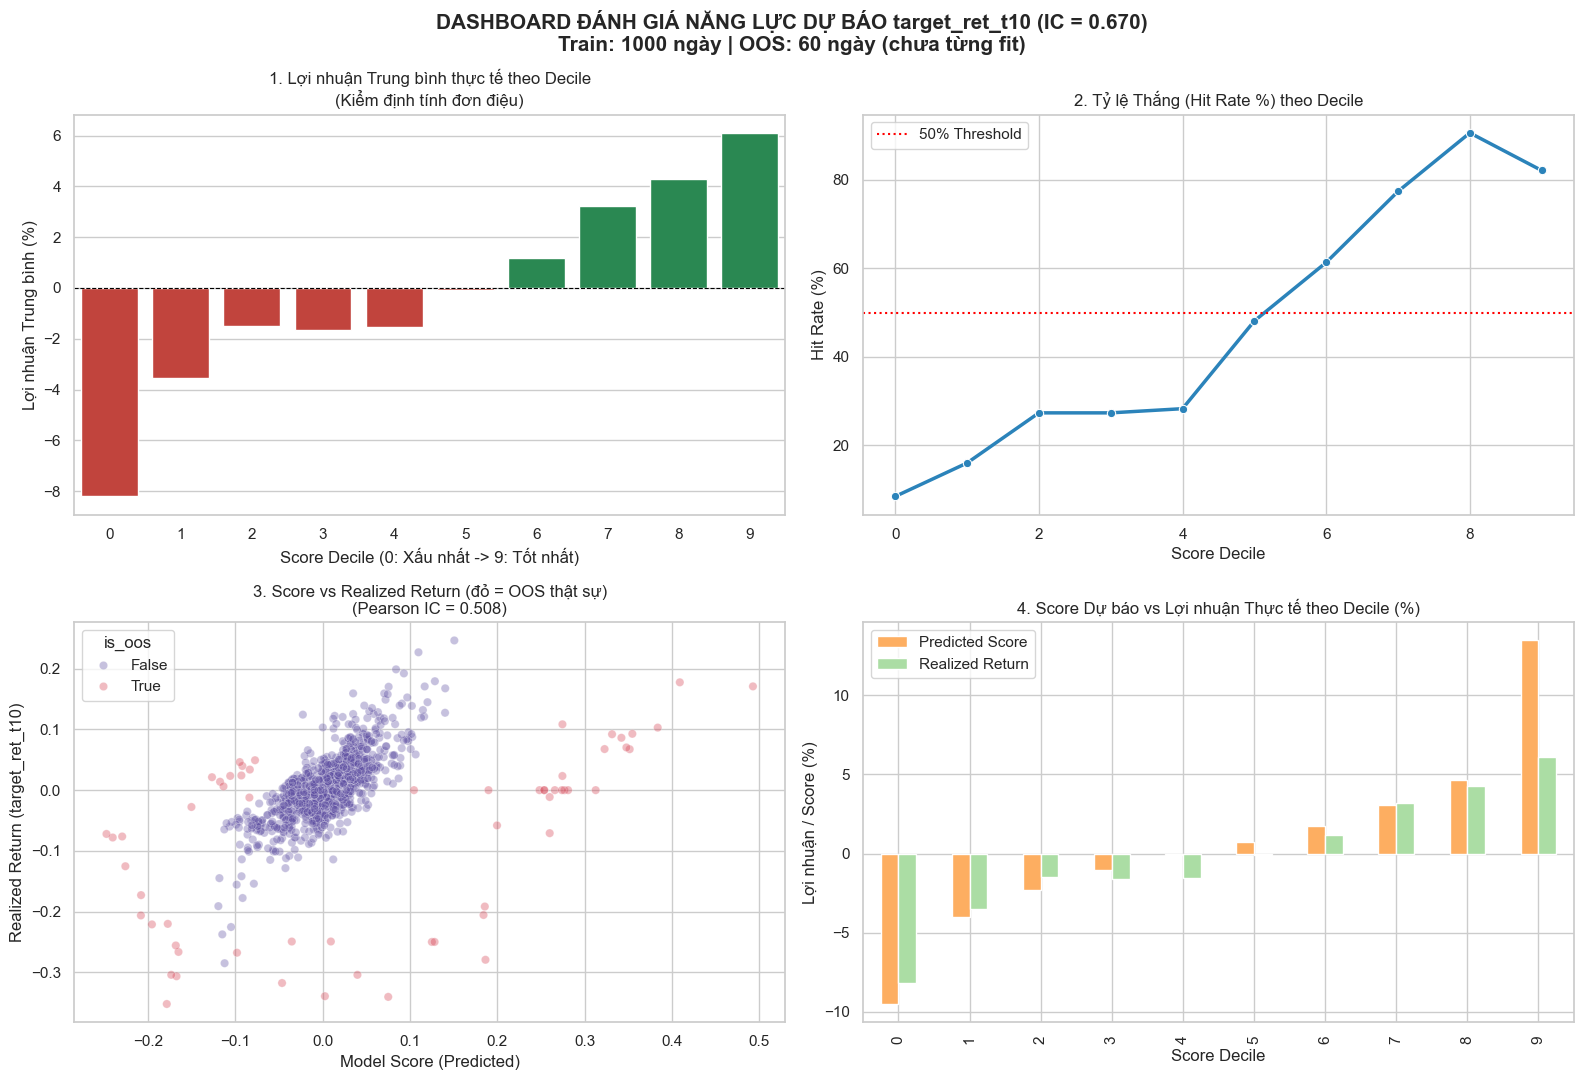

In [410]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# 1. LẤY BEST PARAMS TỪ OPTUNA (giữ nguyên)
# ============================================================

best_params = study.best_trial
cols_to_exclude = study.best_trial.user_attrs["cols_to_exclude"]

a = best_params.user_attrs["a"]
b = best_params.user_attrs["b"]
c = best_params.user_attrs["c"]
d = best_params.user_attrs["d"]
# a = 100
# b = 250
# c = 10
# d = 10
print(f"\nĐang chạy lại model với:")
print(f"  window_z       = {a}")
print(f"  window_div     = {b}")
print(f"  test_pos_range = {c}")
print(f"  days           = {d}")
print(f"  lookback_days  = {LOOKBACK_DAYS}")
print(f"  oos_days       = {OOS_DAYS}")

y_col = "target_ret_t10"


# ============================================================
# 2. HÀM TẠO FEATURE GỐC (giữ nguyên logic của bạn)
# ============================================================
def generate_full_investor_features(df_raw, window_z=a):
    df = df_raw.copy()

    keep_cols = [
        'time', 'symbol', 'open', 'high', 'low', 'close', 'close_raw',
        'volume', 'trading_value', 'vwap', 'buy_active_vol', 'sell_active_vol',
        'pe', 'pb',
        'foreign_net_val', 'prop_net_val', 'local_ind_net_val', 'local_inst_net_val',
        'foreign_net_vol', 'prop_net_vol', 'local_ind_net_vol', 'local_inst_net_vol',
    ]
    keep_cols = [col for col in keep_cols if col in df.columns]
    df = df[keep_cols]

    df['trading_value'] = df['trading_value'].replace(0, np.nan).interpolate()
    df['close'] = df['close'].ffill()
    df['log_ret'] = np.log(df['close'] / df['close'].shift(1)).fillna(0)
    df['abs_ret'] = df['log_ret'].abs()

    close = df['close']
    ma20 = ta.sma(close, length=20)
    ma50 = ta.sma(close, length=50)
    df['ctx_rsi_14'] = ta.rsi(close, length=14) / 100.0
    df['ctx_dist_ma50'] = (close - ma50) / ma50
    df['ctx_dist_ma20'] = (close - ma20) / ma20
    df['ctx_dist_ma20_ma50'] = (ma20 - ma50) / ma50
    df['ctx_atr_ratio'] = ta.atr(df['high'], df['low'], df['close'], length=14) / df['close']

    vol_ma20 = df['trading_value'].rolling(20).mean()
    df['ctx_liquidity_zscore'] = ((df['trading_value'] - vol_ma20) / df['trading_value'].rolling(20).std()).fillna(0)
    df['ctx_volatility_20d'] = df['log_ret'].rolling(20).std() * np.sqrt(252)
    df['ctx_intraday_range'] = (df['high'] - df['low']) / close

    for t in range(1, 11):
        fwd_indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=t)
        df[f'target_ret_t{t}'] = df['close'].shift(-t) / df['close'] - 1
        df[f'target_hi_ret_t{t}'] = (df['high'].shift(-1).rolling(window=fwd_indexer).max() / df['close']) - 1
        df[f'target_lo_ret_t{t}'] = (df['low'].shift(-1).rolling(window=fwd_indexer).min() / df['close']) - 1
        df[f'target_range_t{t}'] = df[f'target_hi_ret_t{t}'] - df[f'target_lo_ret_t{t}']

    for g in investor_groups:
        net_val_col = f'{g}_net_val'
        net_ratio = df[net_val_col] / df['trading_value']
        df[f'feat_{g}_net_ratio'] = net_ratio.fillna(0)

        prev_net_ratio_abs = net_ratio.shift(1).abs()
        df[f'feat_{g}_price_impact'] = (df['abs_ret'].shift(1) / (prev_net_ratio_abs + 1e-6)).rolling(5).median()

        mu = df[f'feat_{g}_net_ratio'].rolling(window=window_z).mean()
        sigma = df[f'feat_{g}_net_ratio'].rolling(window=window_z).std()
        z_score = ((df[f'feat_{g}_net_ratio'] - mu) / sigma).clip(-4, 4)
        df[f'feat_{g}_zscore'] = z_score.fillna(0)

        roll_min = df[net_val_col].rolling(window_z).min()
        roll_max = df[net_val_col].rolling(window_z).max()
        df[f'feat_{g}_sentiment'] = (2 * (df[net_val_col] - roll_min) / (roll_max - roll_min + 1e-6) - 1).fillna(0)

        df[f'feat_{g}_dominance'] = (df[net_val_col].abs() / df['trading_value']).fillna(0)

        is_flip = (df[net_val_col] * df[net_val_col].shift(1)) < 0
        df[f'feat_{g}_flip_count_10d'] = is_flip.rolling(10).sum().fillna(0)

        df[f'feat_{g}_vol_adj_flow'] = df[f'feat_{g}_net_ratio'] / (df['ctx_atr_ratio'] + 1e-6)
        df[f'feat_{g}_sentiment_stability'] = df[f'feat_{g}_net_ratio'].rolling(10).std().fillna(0)

    for g in investor_groups:
        for w in [3, 5, 10, 20]:
            roll_net = df[f'{g}_net_val'].rolling(window=w).sum()
            roll_val = df['trading_value'].rolling(window=w).sum()
            df[f'feat_{g}_accu_{w}d'] = (roll_net / roll_val).fillna(0)

    return df.replace([np.inf, -np.inf], 0).fillna(0)


# ============================================================
# 3. TẠO FEATURE + INTERACTION (giữ nguyên logic của bạn)
# ============================================================
df_quant_vni = generate_full_investor_features(df_vni_raw, window_z=a)
df = df_quant_vni.copy()

feature_dict = {}

delta = df["close"].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / (loss + 1e-8)
rsi = 100 - (100 / (1 + rs))
feature_dict["ta_rsi_norm"] = (rsi / 100.0) - 0.5

ma20 = df["close"].rolling(window=20).mean()
feature_dict["ta_dist_ma20"] = (df["close"] - ma20) / ma20

roll_high = df["high"].rolling(window=c).max()
roll_low = df["low"].rolling(window=c).min()
feature_dict["ta_pos_in_range"] = (df["close"] - roll_low) / (roll_high - roll_low + 1e-8)

tr = np.maximum(
    df["high"] - df["low"],
    np.maximum(
        (df["high"] - df["close"].shift(1)).abs(),
        (df["low"] - df["close"].shift(1)).abs(),
    ),
)
feature_dict["ta_atr_pct"] = tr.ewm(span=b, adjust=False).mean() / df["close"]

for g in investor_groups:
    sent = df[f"feat_{g}_sentiment"]
    sent_ewm = sent.ewm(span=b, adjust=False).mean()

    feature_dict[f"feat_{g}_sentiment_ewm"] = sent_ewm

    sent_mean = sent_ewm.rolling(a, min_periods=10).mean()
    sent_std = sent_ewm.rolling(a, min_periods=10).std().replace(0, np.nan)
    sent_z = ((sent_ewm - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

    feature_dict[f"feat_{g}_sentiment_sq"] = sent_z**2
    feature_dict[f"feat_{g}_sentiment_cubed"] = (sent_z**3 - 3 * sent_z).clip(-10, 10)

    impulse = sent_ewm.diff(d).fillna(0)
    feature_dict[f"feat_{g}_flow_impulse_{d}d"] = impulse

    imp_mean = impulse.rolling(a, min_periods=10).mean()
    imp_std = impulse.rolling(a, min_periods=10).std().replace(0, np.nan)
    imp_z = ((impulse - imp_mean) / (imp_std + 1e-6)).clip(-3, 3).fillna(0)

    feature_dict[f"feat_{g}_flow_impulse_{d}d_sq"] = imp_z**2
    feature_dict[f"feat_{g}_flow_impulse_{d}d_cubed"] = (imp_z**3 - 3 * imp_z).clip(-10, 10)

    feature_dict[f"feat_{g}_eff_flow"] = sent * df[f"feat_{g}_price_impact"]
    feature_dict[f"feat_{g}_val_share"] = df[f"{g}_net_val"].abs() / df["trading_value"]

    implied = np.where(df[f"{g}_net_vol"] != 0, df[f"{g}_net_val"] / df[f"{g}_net_vol"], 0)
    feature_dict[f"feat_{g}_rel_net_price_ewm"] = (
        pd.Series(implied / df["close"], index=df.index).ewm(span=b, adjust=False).mean()
    )

    feature_dict[f"inter_{g}_sent_x_pos"] = sent_z * feature_dict["ta_pos_in_range"]
    feature_dict[f"inter_{g}_sent_x_rsi"] = sent_z * feature_dict["ta_rsi_norm"]
    feature_dict[f"inter_{g}_sent_x_distma"] = sent_z * feature_dict["ta_dist_ma20"]
    feature_dict[f"inter_{g}_imp_x_atr"] = imp_z * feature_dict["ta_atr_pct"]
    feature_dict[f"inter_{g}_eff_x_pos"] = feature_dict[f"feat_{g}_eff_flow"] * feature_dict["ta_pos_in_range"]
    feature_dict[f"inter_{g}_sent_x_atr"] = sent_z * feature_dict["ta_atr_pct"]

df_final_features = pd.DataFrame(feature_dict, index=df.index)
model_data = pd.concat([df_final_features, df[y_col]], axis=1)
model_data.replace([np.inf, -np.inf], np.nan, inplace=True)
model_data.dropna(inplace=True)
model_data = model_data.join(df[["close"]], how="left")

print("Các cột hiện có trong model_data:")
print(model_data.columns.tolist())
print("\nSố dòng (toàn bộ, trước khi cắt lookback/oos):", len(model_data))


# ============================================================
# 4. CẮT TRAIN / OOS — ĐÚNG LOGIC NHƯ evaluate_params_interaction
#    train_data = model_data.iloc[-(lookback_days + oos_days) : -oos_days]
#    oos_data   = model_data.iloc[-oos_days:]
#    => Model chỉ được fit trên dữ liệu ĐÃ lùi lại OOS_DAYS ngày,
#       KHÔNG đụng vào oos_days ngày gần nhất (giữ để test thật sự out-of-sample).
# ============================================================
total_needed = LOOKBACK_DAYS + OOS_DAYS

if len(model_data) >= total_needed:
    train_data = model_data.iloc[-total_needed:-OOS_DAYS].copy()
    oos_data = model_data.iloc[-OOS_DAYS:].copy()
else:
    print(
        f"[Cảnh báo] Chỉ có {len(model_data)} dòng dữ liệu hợp lệ, "
        f"ít hơn LOOKBACK_DAYS+OOS_DAYS={total_needed}. "
        f"Dùng toàn bộ phần còn lại sau khi trừ OOS_DAYS cho train."
    )
    if len(model_data) > OOS_DAYS:
        train_data = model_data.iloc[:-OOS_DAYS].copy()
        oos_data = model_data.iloc[-OOS_DAYS:].copy()
    else:
        train_data = model_data.copy()
        oos_data = pd.DataFrame(columns=model_data.columns)

print(f"Số dòng TRAIN (fit model) : {len(train_data)}")
print(f"Số dòng OOS   (giữ lại)   : {len(oos_data)}")


# ============================================================
# 5. FIT OLS CHỈ TRÊN train_data (không dùng oos_data)
# ============================================================
X_cols = [col for col in df_final_features.columns if col not in cols_to_exclude and "custom_score" not in col]

X_raw = train_data[X_cols]
y = train_data[y_col]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_cols, index=X_raw.index)
X_final = sm.add_constant(X_scaled_df)

lag_map = {"target_ret_t3": 3, "target_ret_t5": 5, "target_ret_t10": 10}
current_lag = lag_map.get(y_col, 10)

full_model = sm.OLS(y, X_final).fit(cov_type="HAC", cov_kwds={"maxlags": current_lag})

train_data['ols_pred_score'] = full_model.predict(X_final)
train_data['actual_ret'] = y

print("\n========== KẾT QUẢ MÔ HÌNH (FIT TRÊN TRAIN, ĐÃ LOẠI OOS_DAYS) ==========")
print(full_model.summary())

pred_train = train_data['ols_pred_score']
actual_train = train_data['actual_ret']
ic_train, _ = spearmanr(pred_train, actual_train)
hit_rate_train = (actual_train[pred_train > 0] > 0).mean() if (pred_train > 0).sum() > 0 else np.nan

print(f"\n[TRAIN] IC (Spearman)       : {ic_train:.4f}")
print(f"[TRAIN] Hit Rate khi pred>0 : {hit_rate_train:.4f}")
print(f"[TRAIN] Số quan sát         : {len(train_data)}")


# ============================================================
# 6. ĐÁNH GIÁ THẬT SỰ OUT-OF-SAMPLE trên oos_data
#    (đây là phần dữ liệu model CHƯA từng thấy khi fit)
# ============================================================
if len(oos_data) > 0:
    X_oos_raw = oos_data[X_cols]
    X_oos_scaled = scaler.transform(X_oos_raw)
    X_oos_scaled_df = pd.DataFrame(X_oos_scaled, columns=X_cols, index=X_oos_raw.index)
    X_oos_final = sm.add_constant(X_oos_scaled_df, has_constant='add')

    oos_data['ols_pred_score'] = full_model.predict(X_oos_final)
    oos_data['actual_ret'] = oos_data[y_col]

    pred_oos = oos_data['ols_pred_score']
    actual_oos = oos_data['actual_ret']

    ic_oos, _ = spearmanr(pred_oos, actual_oos)
    n_signals_oos = int((pred_oos > 0).sum())
    hit_rate_oos = (actual_oos[pred_oos > 0] > 0).mean() if n_signals_oos > 0 else np.nan

    print(f"\n[OOS ] IC (Spearman)        : {ic_oos:.4f}")
    print(f"[OOS ] Hit Rate khi pred>0  : {hit_rate_oos:.4f}")
    print(f"[OOS ] Số tín hiệu Long     : {n_signals_oos}")
    print(f"[OOS ] Số quan sát          : {len(oos_data)}")
else:
    print("\n[OOS] Không đủ dữ liệu để đánh giá out-of-sample.")


# ============================================================
# 7. TÍNH custom_score TRÊN TOÀN BỘ LỊCH SỬ (để vẽ dashboard)
#    Dùng model đã fit (chỉ trên train_data) để predict cho mọi ngày.
#    -> phần train sẽ là in-sample, phần oos sẽ là out-of-sample thật.
# ============================================================
def compute_model_score(df_feat, model, scaler):
    """
    df_feat: DataFrame chứa các feature thô (chưa scale)
    model: Đối tượng kết quả từ sm.OLS(...).fit()
    scaler: Đối tượng StandardScaler đã dùng khi train
    """
    model_features = [col for col in model.params.index if col != 'const']
    X_raw = df_feat[model_features]
    X_scaled = scaler.transform(X_raw)
    X_scaled_df = pd.DataFrame(X_scaled, columns=model_features, index=df_feat.index)
    X_final = sm.add_constant(X_scaled_df, has_constant='add')
    return model.predict(X_final)


# Chỉ tính score cho đúng phần dữ liệu đã dùng (train + oos), không tính lại cho
# toàn bộ lịch sử để tránh nhầm lẫn giữa vùng train và vùng chưa từng train.
eval_data = pd.concat([train_data[X_cols], oos_data[X_cols]], axis=0) if len(oos_data) > 0 else train_data[X_cols]
eval_data = eval_data.copy()
eval_data['custom_score'] = compute_model_score(eval_data, full_model, scaler)
eval_data['is_oos'] = False
if len(oos_data) > 0:
    eval_data.loc[oos_data.index, 'is_oos'] = True

df_analysis = pd.concat(
    [eval_data[['custom_score', 'is_oos']], model_data.loc[eval_data.index, y_col]], axis=1
).dropna()

df_analysis['score_decile'] = pd.qcut(df_analysis['custom_score'], 10, labels=False, duplicates='drop')

analysis = df_analysis.groupby('score_decile')[y_col].agg(['mean', 'std', 'count'])
analysis['hit_rate'] = df_analysis.groupby('score_decile')[y_col].apply(lambda x: (x > 0).mean())
analysis['avg_predicted_score'] = df_analysis.groupby('score_decile')['custom_score'].mean()

rank_ic = df_analysis["custom_score"].corr(df_analysis[y_col], method="spearman")
pearson_ic = df_analysis["custom_score"].corr(df_analysis[y_col])

print(f"\n=== 📊 KẾT QUẢ DỰ BÁO {y_col} (TRAIN + OOS gộp lại để xem decile) ===")
print(f"👉 Pearson IC: {pearson_ic:.4f} | Spearman Rank IC: {rank_ic:.4f}\n")
print(analysis)

# ==========================================
# 8. TRỰC QUAN HÓA (VISUALIZATION DASHBOARD)
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    f"DASHBOARD ĐÁNH GIÁ NĂNG LỰC DỰ BÁO {y_col} (IC = {rank_ic:.3f})\n"
    f"Train: {len(train_data)} ngày | OOS: {len(oos_data)} ngày (chưa từng fit)",
    fontsize=15,
    fontweight="bold",
)

colors = ["#d73027" if x < 0 else "#1a9850" for x in analysis["mean"]]
sns.barplot(x=analysis.index, y=analysis["mean"] * 100, ax=axes[0, 0], palette=colors)
axes[0, 0].set_title("1. Lợi nhuận Trung bình thực tế theo Decile\n(Kiểm định tính đơn điệu)", fontsize=12)
axes[0, 0].set_xlabel("Score Decile (0: Xấu nhất -> 9: Tốt nhất)")
axes[0, 0].set_ylabel("Lợi nhuận Trung bình (%)")
axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=0.8)

sns.lineplot(x=analysis.index, y=analysis["hit_rate"] * 100, ax=axes[0, 1], marker="o", linewidth=2.5, color="#2b83ba")
axes[0, 1].set_title("2. Tỷ lệ Thắng (Hit Rate %) theo Decile", fontsize=12)
axes[0, 1].set_xlabel("Score Decile")
axes[0, 1].set_ylabel("Hit Rate (%)")
axes[0, 1].axhline(50, color="red", linestyle=":", label="50% Threshold")
axes[0, 1].legend()

sns.scatterplot(
    x="custom_score", y=y_col, hue="is_oos", data=df_analysis, ax=axes[1, 0],
    alpha=0.35, palette={False: "#5e4fa2", True: "#d53e4f"},
)
axes[1, 0].set_title(
    f"3. Score vs Realized Return (đỏ = OOS thật sự)\n(Pearson IC = {pearson_ic:.3f})", fontsize=12
)
axes[1, 0].set_xlabel("Model Score (Predicted)")
axes[1, 0].set_ylabel(f"Realized Return ({y_col})")

df_calib = pd.DataFrame(
    {
        "Predicted Score": analysis["avg_predicted_score"] * 100,
        "Realized Return": analysis["mean"] * 100,
    },
    index=analysis.index,
)
df_calib.plot(kind="bar", ax=axes[1, 1], color=["#fdae61", "#abdda4"])
axes[1, 1].set_title("4. Score Dự báo vs Lợi nhuận Thực tế theo Decile (%)", fontsize=12)
axes[1, 1].set_xlabel("Score Decile")
axes[1, 1].set_ylabel("Lợi nhuận / Score (%)")

plt.tight_layout()
plt.show()

In [394]:
vif_data = pd.DataFrame()
vif_data["feature"] = X_cols
vif_data["VIF"] = [variance_inflation_factor(X_scaled_df.values, i) for i in range(len(X_cols))]
print(vif_data.sort_values('VIF', ascending=False))

                                   feature      VIF
57        feat_local_ind_rel_net_price_ewm 521.0350
12          feat_foreign_rel_net_price_ewm 477.5161
4               feat_foreign_sentiment_ewm 262.4820
49            feat_local_ind_sentiment_ewm 190.5480
18                inter_foreign_sent_x_atr 136.5249
7            feat_foreign_flow_impulse_20d 120.0216
13                inter_foreign_sent_x_pos 107.9744
58              inter_local_ind_sent_x_pos  98.7212
63              inter_local_ind_sent_x_atr  96.3282
52         feat_local_ind_flow_impulse_20d  92.7032
34           feat_local_inst_sentiment_ewm  63.6664
33                   inter_prop_sent_x_atr  54.9871
42       feat_local_inst_rel_net_price_ewm  53.8053
19                 feat_prop_sentiment_ewm  52.3421
27             feat_prop_rel_net_price_ewm  51.4772
28                   inter_prop_sent_x_pos  48.2108
48             inter_local_inst_sent_x_atr  47.8403
61               inter_local_ind_imp_x_atr  46.3427
60          

In [395]:
# # ============================================================
# # CẤU HÌNH VIF CHO MÔ HÌNH CUỐI
# # ============================================================
# VIF_MAX = 15
# MIN_FEATURES  = 8

# # ============================================================
# # 1. LẤY BEST PARAMS TỪ OPTUNA
# # ============================================================
# best_params = study.best_trial
# cols_to_exclude = study.best_trial.user_attrs.get("cols_to_exclude", [])

# a = best_params.user_attrs["a"]
# b = best_params.user_attrs["b"]
# c = best_params.user_attrs["c"]
# d = best_params.user_attrs["d"]
# print(f"\nĐang chạy lại model với:")
# print(f"  window_z       = {a}")
# print(f"  window_div     = {b}")
# print(f"  test_pos_range = {c}")
# print(f"  days           = {d}")
# print(f"  lookback_days  = {LOOKBACK_DAYS}")
# print(f"  oos_days       = {OOS_DAYS}")
# print(f"  VIF_MAX        = {VIF_MAX}")

# y_col = "target_ret_t10"

# # ============================================================
# # HÀM VIF NHANH + GIẢM LẦN LƯỢT
# # ============================================================
# def fast_vif(X_scaled: np.ndarray) -> np.ndarray:
#     n_features = X_scaled.shape[1]
#     if n_features == 0:
#         return np.array([])
#     corr = np.corrcoef(X_scaled, rowvar=False)
#     corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
#     try:
#         inv_corr = pinv(corr)
#         vifs = np.diag(inv_corr)
#     except Exception:
#         vifs = np.full(n_features, 999.0)
#     return np.maximum(vifs, 1.0)


# def reduce_vif_iterative(X_df: pd.DataFrame, vif_max: float = 10.0, min_features: int = 8):
#     """
#     Loại biến lần lượt (mỗi lần loại 1 biến có VIF cao nhất)
#     cho đến khi max VIF <= vif_max hoặc còn min_features biến.
#     Trả về: list biến bị loại, list biến còn lại, max_vif cuối cùng
#     """
#     cols = list(X_df.columns)
#     excluded = []
#     scaler = StandardScaler()
#     X_scaled = scaler.fit_transform(X_df[cols])

#     print(f"\n--- Bắt đầu giảm VIF (ngưỡng = {vif_max}) ---")
#     print(f"Số biến ban đầu: {len(cols)}")

#     while len(cols) > min_features:
#         vifs = fast_vif(X_scaled)
#         max_vif = float(np.max(vifs))
#         if max_vif <= vif_max:
#             break

#         worst_idx = int(np.argmax(vifs))
#         worst_col = cols[worst_idx]
#         excluded.append(worst_col)
#         print(f"  Loại: {worst_col:<45} | VIF = {max_vif:.2f} | Còn lại: {len(cols)-1}")

#         cols.pop(worst_idx)
#         X_scaled = np.delete(X_scaled, worst_idx, axis=1)

#     final_max_vif = float(np.max(fast_vif(X_scaled))) if len(cols) > 0 else 1.0
#     print(f"--- Kết thúc | Số biến còn lại: {len(cols)} | Max VIF cuối: {final_max_vif:.2f} ---\n")

#     return excluded, cols, final_max_vif


# # ============================================================
# # 2. HÀM TẠO FEATURE GỐC (giữ nguyên)
# # ============================================================

# # ============================================================
# # 3. TẠO FEATURE + INTERACTION (giữ nguyên)
# # ============================================================
# print("Số dòng (toàn bộ, trước khi cắt lookback/oos):", len(model_data))


# # ============================================================
# # 4. CẮT TRAIN / OOS
# # ============================================================
# total_needed = LOOKBACK_DAYS + OOS_DAYS

# if len(model_data) >= total_needed:
#     train_data = model_data.iloc[-total_needed:-OOS_DAYS].copy()
#     oos_data = model_data.iloc[-OOS_DAYS:].copy()
# else:
#     print(f"[Cảnh báo] Chỉ có {len(model_data)} dòng dữ liệu hợp lệ.")
#     if len(model_data) > OOS_DAYS:
#         train_data = model_data.iloc[:-OOS_DAYS].copy()
#         oos_data = model_data.iloc[-OOS_DAYS:].copy()
#     else:
#         train_data = model_data.copy()
#         oos_data = pd.DataFrame(columns=model_data.columns)

# print(f"Số dòng TRAIN : {len(train_data)}")
# print(f"Số dòng OOS   : {len(oos_data)}")


# # ============================================================
# # 5. GIẢM VIF LẦN LƯỢT + FIT OLS
# # ============================================================
# # Bắt đầu từ toàn bộ feature (bỏ qua cols_to_exclude của Optuna nếu muốn kiểm soát lại)
# X_cols_initial = [col for col in df_final_features.columns if "custom_score" not in col]

# X_raw = train_data[X_cols_initial]
# y = train_data[y_col]

# # --- Giảm VIF lần lượt ---
# excluded_vif, remaining_cols, final_max_vif = reduce_vif_iterative(
#     X_raw, vif_max=VIF_MAX, min_features=MIN_FEATURES
# )

# print(f"Các biến bị loại bởi VIF: {excluded_vif}")
# print(f"Max VIF sau khi giảm   : {final_max_vif:.2f}")
# print(f"Số biến còn lại        : {len(remaining_cols)}")

# # Dùng bộ feature đã giảm VIF
# X_raw = train_data[remaining_cols]
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_raw)
# X_scaled_df = pd.DataFrame(X_scaled, columns=remaining_cols, index=X_raw.index)
# X_final = sm.add_constant(X_scaled_df)

# lag_map = {"target_ret_t3": 3, "target_ret_t5": 5, "target_ret_t10": 10}
# current_lag = lag_map.get(y_col, 10)

# full_model = sm.OLS(y, X_final).fit(cov_type="HAC", cov_kwds={"maxlags": current_lag})

# train_data = train_data.copy()
# train_data['ols_pred_score'] = full_model.predict(X_final)
# train_data['actual_ret'] = y

# print("\n========== KẾT QUẢ MÔ HÌNH (SAU KHI GIẢM VIF) ==========")
# print(full_model.summary())

# pred_train = train_data['ols_pred_score']
# actual_train = train_data['actual_ret']
# ic_train, _ = spearmanr(pred_train, actual_train)
# hit_rate_train = (actual_train[pred_train > 0] > 0).mean() if (pred_train > 0).sum() > 0 else np.nan

# print(f"\n[TRAIN] IC (Spearman)       : {ic_train:.4f}")
# print(f"[TRAIN] Hit Rate khi pred>0 : {hit_rate_train:.4f}")
# print(f"[TRAIN] Số quan sát         : {len(train_data)}")
# print(f"[TRAIN] Max VIF cuối cùng   : {final_max_vif:.2f}")


# # ============================================================
# # 6. ĐÁNH GIÁ OOS
# # ============================================================
# if len(oos_data) > 0:
#     X_oos_raw = oos_data[remaining_cols]
#     X_oos_scaled = scaler.transform(X_oos_raw)
#     X_oos_scaled_df = pd.DataFrame(X_oos_scaled, columns=remaining_cols, index=X_oos_raw.index)
#     X_oos_final = sm.add_constant(X_oos_scaled_df, has_constant='add')

#     oos_data = oos_data.copy()
#     oos_data['ols_pred_score'] = full_model.predict(X_oos_final)
#     oos_data['actual_ret'] = oos_data[y_col]

#     pred_oos = oos_data['ols_pred_score']
#     actual_oos = oos_data['actual_ret']

#     ic_oos, _ = spearmanr(pred_oos, actual_oos)
#     n_signals_oos = int((pred_oos > 0).sum())
#     hit_rate_oos = (actual_oos[pred_oos > 0] > 0).mean() if n_signals_oos > 0 else np.nan

#     print(f"\n[OOS ] IC (Spearman)        : {ic_oos:.4f}")
#     print(f"[OOS ] Hit Rate khi pred>0  : {hit_rate_oos:.4f}")
#     print(f"[OOS ] Số tín hiệu Long     : {n_signals_oos}")
#     print(f"[OOS ] Số quan sát          : {len(oos_data)}")
# else:
#     print("\n[OOS] Không đủ dữ liệu để đánh giá out-of-sample.")


# # ============================================================
# # 7 + 8. Tính score + Dashboard (giữ nguyên logic, chỉ đổi remaining_cols)
# # ============================================================
# def compute_model_score(df_feat, model, scaler):
#     model_features = [col for col in model.params.index if col != 'const']
#     X_raw = df_feat[model_features]
#     X_scaled = scaler.transform(X_raw)
#     X_scaled_df = pd.DataFrame(X_scaled, columns=model_features, index=df_feat.index)
#     X_final = sm.add_constant(X_scaled_df, has_constant='add')
#     return model.predict(X_final)


# eval_data = pd.concat([train_data[remaining_cols], oos_data[remaining_cols]], axis=0) if len(oos_data) > 0 else train_data[remaining_cols]
# eval_data = eval_data.copy()
# eval_data['custom_score'] = compute_model_score(eval_data, full_model, scaler)
# eval_data['is_oos'] = False
# if len(oos_data) > 0:
#     eval_data.loc[oos_data.index, 'is_oos'] = True

# df_analysis = pd.concat(
#     [eval_data[['custom_score', 'is_oos']], model_data.loc[eval_data.index, y_col]], axis=1
# ).dropna()

# df_analysis['score_decile'] = pd.qcut(df_analysis['custom_score'], 10, labels=False, duplicates='drop')

# analysis = df_analysis.groupby('score_decile')[y_col].agg(['mean', 'std', 'count'])
# analysis['hit_rate'] = df_analysis.groupby('score_decile')[y_col].apply(lambda x: (x > 0).mean())
# analysis['avg_predicted_score'] = df_analysis.groupby('score_decile')['custom_score'].mean()

# rank_ic = df_analysis["custom_score"].corr(df_analysis[y_col], method="spearman")
# pearson_ic = df_analysis["custom_score"].corr(df_analysis[y_col])

# print(f"\n=== 📊 KẾT QUẢ DỰ BÁO {y_col} (TRAIN + OOS) ===")
# print(f"👉 Pearson IC: {pearson_ic:.4f} | Spearman Rank IC: {rank_ic:.4f}")
# print(f"👉 Max VIF cuối cùng: {final_max_vif:.2f}\n")
# print(analysis)

# #==========================================
# # 8. TRỰC QUAN HÓA (VISUALIZATION DASHBOARD)
# # ==========================================
# sns.set_theme(style="whitegrid")
# fig, axes = plt.subplots(2, 2, figsize=(16, 11))
# fig.suptitle(
#     f"DASHBOARD ĐÁNH GIÁ NĂNG LỰC DỰ BÁO {y_col} (IC = {rank_ic:.3f})\n"
#     f"Train: {len(train_data)} ngày | OOS: {len(oos_data)} ngày (chưa từng fit)",
#     fontsize=15,
#     fontweight="bold",
# )

# colors = ["#d73027" if x < 0 else "#1a9850" for x in analysis["mean"]]
# sns.barplot(x=analysis.index, y=analysis["mean"] * 100, ax=axes[0, 0], palette=colors)
# axes[0, 0].set_title("1. Lợi nhuận Trung bình thực tế theo Decile\n(Kiểm định tính đơn điệu)", fontsize=12)
# axes[0, 0].set_xlabel("Score Decile (0: Xấu nhất -> 9: Tốt nhất)")
# axes[0, 0].set_ylabel("Lợi nhuận Trung bình (%)")
# axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=0.8)

# sns.lineplot(x=analysis.index, y=analysis["hit_rate"] * 100, ax=axes[0, 1], marker="o", linewidth=2.5, color="#2b83ba")
# axes[0, 1].set_title("2. Tỷ lệ Thắng (Hit Rate %) theo Decile", fontsize=12)
# axes[0, 1].set_xlabel("Score Decile")
# axes[0, 1].set_ylabel("Hit Rate (%)")
# axes[0, 1].axhline(50, color="red", linestyle=":", label="50% Threshold")
# axes[0, 1].legend()

# sns.scatterplot(
#     x="custom_score", y=y_col, hue="is_oos", data=df_analysis, ax=axes[1, 0],
#     alpha=0.35, palette={False: "#5e4fa2", True: "#d53e4f"},
# )
# axes[1, 0].set_title(
#     f"3. Score vs Realized Return (đỏ = OOS thật sự)\n(Pearson IC = {pearson_ic:.3f})", fontsize=12
# )
# axes[1, 0].set_xlabel("Model Score (Predicted)")
# axes[1, 0].set_ylabel(f"Realized Return ({y_col})")

# df_calib = pd.DataFrame(
#     {
#         "Predicted Score": analysis["avg_predicted_score"] * 100,
#         "Realized Return": analysis["mean"] * 100,
#     },
#     index=analysis.index,
# )
# df_calib.plot(kind="bar", ax=axes[1, 1], color=["#fdae61", "#abdda4"])
# axes[1, 1].set_title("4. Score Dự báo vs Lợi nhuận Thực tế theo Decile (%)", fontsize=12)
# axes[1, 1].set_xlabel("Score Decile")
# axes[1, 1].set_ylabel("Lợi nhuận / Score (%)")

# plt.tight_layout()
# plt.show()


Số decile thực tế (từ train, sau khi drop duplicates): 10
Số ngày OOS được vẽ: 60
          close  ols_pred_score  decile
1740 65800.0000         -0.0840       1
1741 65000.0000         -0.0775       1
1742 65400.0000         -0.0921       1
1743 65000.0000         -0.0951       1
1744 65700.0000         -0.1268       1
1745 65100.0000         -0.1176       1
1746 64800.0000         -0.1137       1
1747 64000.0000         -0.1060       1
1748 62000.0000         -0.0835       1
1749 62000.0000         -0.0932       1
1750 65000.0000         -0.1504       1
1751 68200.0000         -0.2297       1
1752 68000.0000         -0.2406       1
1753 68000.0000         -0.2477       1
1754 67100.0000         -0.2261       1
1755 66000.0000         -0.2081       1
1756 65200.0000         -0.1957       1
1757 65500.0000         -0.2083       1
1758 64100.0000         -0.1775       1
1759 63500.0000         -0.1652       1
1760 63200.0000         -0.1675       1
1761 63000.0000         -0.1683      

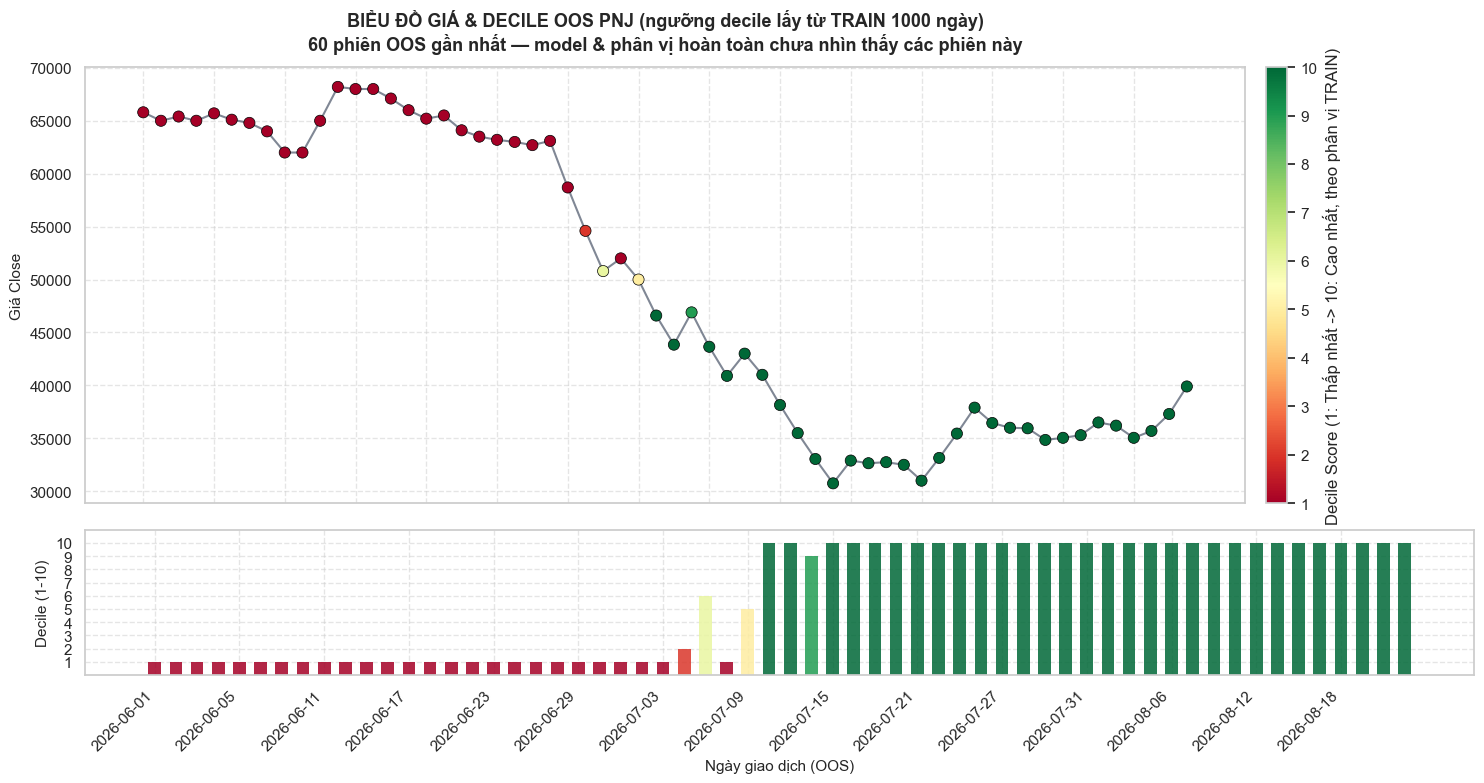

In [411]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==============================================================================
# --- 5. TÍNH NGƯỠNG DECILE TỪ TẬP TRAIN (LOOKBACK_DAYS), RỒI ÁP DỤNG CHO OOS
#
#   Ý tưởng: decile phải phản ánh "vị thế của score OOS so với lịch sử train",
#   nên bin edges (ngưỡng phân vị) PHẢI được tính 1 lần trên train_data['ols_pred_score']
#   rồi dùng pd.cut (không phải pd.qcut) để gán nhãn cho oos_data — tuyệt đối
#   không qcut lại trên chính oos_data, vì OOS chỉ có OOS_DAYS dòng, không đủ để
#   tự định nghĩa phân vị, và làm vậy sẽ phá vỡ ý nghĩa "so với quá khứ".
# ==============================================================================

# --- 5.1 Ngưỡng decile lấy từ TRAIN ---
train_scores = train_data["ols_pred_score"]
_, train_bin_edges = pd.qcut(train_scores, q=10, duplicates="drop", retbins=True)

# Mở rộng 2 đầu mút để score OOS vượt ra ngoài range train vẫn rơi vào
# decile 1 (thấp nhất) hoặc decile cao nhất thay vì bị NaN
train_bin_edges = train_bin_edges.copy()
train_bin_edges[0] = -np.inf
train_bin_edges[-1] = np.inf

n_deciles = len(train_bin_edges) - 1  # có thể < 10 nếu duplicates bị drop

# --- 5.2 Gán decile cho TRAIN theo đúng ngưỡng vừa tính (để đối chiếu nếu cần) ---
train_data["decile_train"] = (
    pd.cut(train_scores, bins=train_bin_edges, labels=False, include_lowest=True) + 1
)

# --- 5.3 Gán decile cho OOS_DAYS bằng ĐÚNG ngưỡng của TRAIN (không tính lại) ---
oos_scores = oos_data["ols_pred_score"]
df_oos = oos_data.copy()
df_oos["decile"] = (
    pd.cut(oos_scores, bins=train_bin_edges, labels=False, include_lowest=True) + 1
)

# Lấy giá Close tương ứng từ df gốc
df_oos["close"] = df.loc[df_oos.index, "close"]

print(f"\nSố decile thực tế (từ train, sau khi drop duplicates): {n_deciles}")
print(f"Số ngày OOS được vẽ: {len(df_oos)}")
print(df_oos[["close", "ols_pred_score", "decile"]])

# ==============================================================================
# --- 6. XỬ LÝ TRỤC THỜI GIAN (giữ nguyên cách của bạn) ---
# ==============================================================================

if "time" in df.columns:
    raw_dates = df.loc[df_oos.index, "time"]
elif "date" in df.columns:
    raw_dates = df.loc[df_oos.index, "date"]
else:
    raw_dates = df_oos.index

if pd.api.types.is_datetime64_any_dtype(raw_dates):
    x_dates = raw_dates.dt.strftime("%Y-%m-%d").values
else:
    x_dates = pd.to_datetime(raw_dates).dt.strftime("%Y-%m-%d").values

# ==============================================================================
# --- 7. HIỂN THỊ LÊN BIỂU ĐỒ GIÁ ---
# ==============================================================================

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]},
)

# ------------------------------------------------------------------------------
# Subplot 1: Đường Giá & Scatter Marker tô màu theo Decile (ngưỡng lấy từ TRAIN)
# ------------------------------------------------------------------------------
ax1.plot(
    x_dates, df_oos["close"], color="#4A5568", linestyle="-",
    linewidth=1.5, alpha=0.7, label="Giá Close",
)

sc = ax1.scatter(
    x_dates, df_oos["close"], c=df_oos["decile"].astype(int),
    cmap="RdYlGn", vmin=1, vmax=n_deciles,
    s=65, zorder=5, edgecolors="black", linewidth=0.5,
)

ax1.set_title(
    f"BIỂU ĐỒ GIÁ & DECILE OOS {SYMBOL} (ngưỡng decile lấy từ TRAIN {len(train_data)} ngày)\n"
    f"{len(df_oos)} phiên OOS gần nhất — model & phân vị hoàn toàn chưa nhìn thấy các phiên này",
    fontsize=13, fontweight="bold", pad=12,
)
ax1.set_ylabel("Giá Close", fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.5)

cbar = plt.colorbar(sc, ax=ax1, orientation="vertical", pad=0.015)
cbar.set_label(f"Decile Score (1: Thấp nhất -> {n_deciles}: Cao nhất, theo phân vị TRAIN)")

# ------------------------------------------------------------------------------
# Subplot 2: Biểu đồ Cột Decile theo từng phiên OOS
# ------------------------------------------------------------------------------
norm_denom = (n_deciles - 1) if n_deciles > 1 else 1
bar_colors = plt.cm.RdYlGn((df_oos["decile"].astype(int) - 1) / norm_denom)

ax2.bar(
    x_dates, df_oos["decile"].astype(int), color=bar_colors,
    alpha=0.85, width=0.6, edgecolor="none",
)
ax2.set_ylabel(f"Decile (1-{n_deciles})", fontsize=11)
ax2.set_ylim(0, n_deciles + 1)
ax2.set_yticks(range(1, n_deciles + 1))
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.set_xlabel("Ngày giao dịch (OOS)", fontsize=11)

plt.xticks(
    rotation=45, ha="right",
    ticks=range(0, len(x_dates), max(1, len(x_dates) // 15)),
)

plt.tight_layout()
plt.show()

In [412]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from scipy.stats import spearmanr

# ============================================================
# CẤU HÌNH CHIẾN LƯỢC DECILE
# ============================================================
# Sử dụng bộ tham số best / median bạn đã chọn
BEST_A = best_params.user_attrs["a"]
BEST_B = best_params.user_attrs["b"]
BEST_C = best_params.user_attrs["c"]
BEST_D = best_params.user_attrs["d"]

# Ngưỡng decile (0-based hoặc 1-based tùy bạn)
# Ví dụ: Long khi decile >= 8 (tức 9 & 10), thoát khi decile <= 1 (tức 1 & 2)
LONG_ENTRY_DECILE = 8
LONG_EXIT_DECILE  = 1          # <= 1  → thoát Long

SHORT_ENTRY_DECILE = 1         # <= 1  → vào Short
SHORT_EXIT_DECILE  = 8

# ============================================================
# HÀM TẠO FEATURE + PREDICTION (dùng lại logic cũ)
# ============================================================
def generate_predictions(df_vni_raw, a, b, c, d, lookback_days=1000, oos_days=15):
    """
    Trả về DataFrame chứa cột: date, target_ret_t10, pred, decile
    """
    
    df = df_vni_raw.copy()
    
    keep_cols = [
        'open', 'high', 'low', 'close', 'trading_value',
        'foreign_net_val', 'prop_net_val', 'local_ind_net_val', 'local_inst_net_val',
        'foreign_net_vol', 'prop_net_vol', 'local_ind_net_vol', 'local_inst_net_vol',
    ]
    keep_cols = [col for col in keep_cols if col in df.columns]
    df = df[keep_cols]

    df['trading_value'] = df['trading_value'].replace(0, np.nan).interpolate()
    df['close'] = df['close'].ffill()
    df['log_ret'] = np.log(df['close'] / df['close'].shift(1)).fillna(0)
    df['abs_ret'] = df['log_ret'].abs()

    tr = np.maximum(
        df['high'] - df['low'],
        np.maximum(
            (df['high'] - df['close'].shift(1)).abs(),
            (df['low'] - df['close'].shift(1)).abs()
        )
    )
    df['target_ret_t10'] = df['close'].shift(-10) / df['close'] - 1

    investor_groups = ["foreign", "prop", "local_inst", "local_ind"]
    
    for g in investor_groups:
        net_val = df[f'{g}_net_val']
        net_ratio = net_val / df['trading_value']
        df[f'feat_{g}_net_ratio'] = net_ratio.fillna(0)

        prev = net_ratio.shift(1).abs()
        df[f'feat_{g}_price_impact'] = (df['abs_ret'].shift(1) / (prev + 1e-6)).rolling(5).median()

        mu = df[f'feat_{g}_net_ratio'].rolling(a).mean()
        sigma = df[f'feat_{g}_net_ratio'].rolling(a).std()
        df[f'feat_{g}_zscore'] = ((df[f'feat_{g}_net_ratio'] - mu) / (sigma + 1e-8)).clip(-4, 4).fillna(0)

        rmin = net_val.rolling(a).min()
        rmax = net_val.rolling(a).max()
        df[f'feat_{g}_sentiment'] = (2 * (net_val - rmin) / (rmax - rmin + 1e-6) - 1).fillna(0)

    df = df.replace([np.inf, -np.inf], 0).fillna(0)

    # Feature factory (giống hệt code gốc)
    feature_dict = {}

    delta = df["close"].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / (loss + 1e-8)
    rsi = 100 - (100 / (1 + rs))
    feature_dict["ta_rsi_norm"] = (rsi / 100.0) - 0.5

    ma20 = df["close"].rolling(20).mean()
    feature_dict["ta_dist_ma20"] = (df["close"] - ma20) / ma20

    roll_high = df["high"].rolling(c).max()
    roll_low = df["low"].rolling(c).min()
    feature_dict["ta_pos_in_range"] = (df["close"] - roll_low) / (roll_high - roll_low + 1e-8)

    feature_dict["ta_atr_pct"] = tr.ewm(span=b, adjust=False).mean() / df["close"]

    for g in investor_groups:
        sent = df[f"feat_{g}_sentiment"]
        sent_ewm = sent.ewm(span=b, adjust=False).mean()
        feature_dict[f"feat_{g}_sentiment_ewm"] = sent_ewm

        sent_mean = sent_ewm.rolling(a, min_periods=10).mean()
        sent_std = sent_ewm.rolling(a, min_periods=10).std().replace(0, np.nan)
        sent_z = ((sent_ewm - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

        feature_dict[f"feat_{g}_sentiment_sq"] = sent_z**2
        feature_dict[f"feat_{g}_sentiment_cubed"] = (sent_z**3 - 3 * sent_z).clip(-10, 10)

        impulse = sent_ewm.diff(d).fillna(0)
        feature_dict[f"feat_{g}_flow_impulse_{d}d"] = impulse

        imp_mean = impulse.rolling(a, min_periods=10).mean()
        imp_std = impulse.rolling(a, min_periods=10).std().replace(0, np.nan)
        imp_z = ((impulse - imp_mean) / (imp_std + 1e-6)).clip(-3, 3).fillna(0)

        feature_dict[f"feat_{g}_flow_impulse_{d}d_sq"] = imp_z**2
        feature_dict[f"feat_{g}_flow_impulse_{d}d_cubed"] = (imp_z**3 - 3 * imp_z).clip(-10, 10)

        feature_dict[f"feat_{g}_eff_flow"] = sent * df[f"feat_{g}_price_impact"]
        feature_dict[f"feat_{g}_val_share"] = df[f"{g}_net_val"].abs() / df["trading_value"]

        implied = np.where(df[f"{g}_net_vol"] != 0, df[f"{g}_net_val"] / df[f"{g}_net_vol"], 0)
        feature_dict[f"feat_{g}_rel_net_price_ewm"] = (
            pd.Series(implied / df["close"], index=df.index).ewm(span=b, adjust=False).mean()
        )

        feature_dict[f"inter_{g}_sent_x_pos"]    = sent_z * feature_dict["ta_pos_in_range"]
        feature_dict[f"inter_{g}_sent_x_rsi"]    = sent_z * feature_dict["ta_rsi_norm"]
        feature_dict[f"inter_{g}_sent_x_distma"] = sent_z * feature_dict["ta_dist_ma20"]
        feature_dict[f"inter_{g}_imp_x_atr"]     = imp_z  * feature_dict["ta_atr_pct"]
        feature_dict[f"inter_{g}_eff_x_pos"]     = feature_dict[f"feat_{g}_eff_flow"] * feature_dict["ta_pos_in_range"]
        feature_dict[f"inter_{g}_sent_x_atr"]    = sent_z * feature_dict["ta_atr_pct"]

    # # ============================================================
    # # CROSS-INVESTOR FEATURES (Toàn bộ mối quan hệ)
    # # ============================================================
    # groups = investor_groups  # ["foreign", "prop", "local_inst", "local_ind"]

    # # Lấy các series đã có
    # sent_ewm = {g: feature_dict[f"feat_{g}_sentiment_ewm"] for g in groups}
    # sent_z   = {}
    # for g in groups:
    #     # tái tạo sent_z nếu cần (hoặc lấy từ biến đã tính trước đó)
    #     sent = df[f"feat_{g}_sentiment"]
    #     sent_ewm_g = sent.ewm(span=b, adjust=False).mean()
    #     sent_mean = sent_ewm_g.rolling(a, min_periods=10).mean()
    #     sent_std  = sent_ewm_g.rolling(a, min_periods=10).std().replace(0, np.nan)
    #     sent_z[g] = ((sent_ewm_g - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

    # net_ratio = {g: df[f"feat_{g}_net_ratio"] for g in groups}

    # # ----------------------------------------------------------
    # # 1. Relative Flow (chênh lệch) – tất cả cặp
    # # ----------------------------------------------------------
    # from itertools import combinations

    # for g1, g2 in combinations(groups, 2):
    #     # Chênh lệch sentiment EWM
    #     feature_dict[f"cross_{g1}_minus_{g2}_sent"] = sent_ewm[g1] - sent_ewm[g2]
        
    #     # Chênh lệch z-score
    #     feature_dict[f"cross_{g1}_minus_{g2}_sent_z"] = sent_z[g1] - sent_z[g2]
        
    #     # Chênh lệch net_ratio
    #     feature_dict[f"cross_{g1}_minus_{g2}_net"] = net_ratio[g1] - net_ratio[g2]
        
    #     # Absolute difference (độ lớn sự khác biệt)
    #     feature_dict[f"cross_abs_{g1}_{g2}_sent"] = (sent_ewm[g1] - sent_ewm[g2]).abs()

    # # ----------------------------------------------------------
    # # 2. Agreement / Disagreement
    # # ----------------------------------------------------------
    # for g1, g2 in combinations(groups, 2):
    #     # Cùng chiều hay ngược chiều (sign agreement)
    #     sign_agree = np.sign(sent_ewm[g1]) * np.sign(sent_ewm[g2])
    #     feature_dict[f"cross_agree_sign_{g1}_{g2}"] = sign_agree
        
    #     # Strength-weighted agreement (càng lớn càng đồng thuận mạnh)
    #     feature_dict[f"cross_agree_strength_{g1}_{g2}"] = sent_ewm[g1] * sent_ewm[g2]
        
    #     # Disagreement magnitude
    #     feature_dict[f"cross_disagree_{g1}_{g2}"] = (sent_ewm[g1] - sent_ewm[g2]).abs() * (1 - sign_agree.abs())

    # # ----------------------------------------------------------
    # # 3. Dispersion (độ phân tán giữa tất cả nhóm)
    # # ----------------------------------------------------------
    # # Stack tất cả sentiment_ewm
    # sent_matrix = pd.concat([sent_ewm[g] for g in groups], axis=1)
    # sent_matrix.columns = groups

    # feature_dict["cross_dispersion_std"] = sent_matrix.std(axis=1)           # độ lệch chuẩn giữa 4 nhóm
    # feature_dict["cross_dispersion_range"] = sent_matrix.max(axis=1) - sent_matrix.min(axis=1)  # range
    # feature_dict["cross_dispersion_iqr"] = sent_matrix.quantile(0.75, axis=1) - sent_matrix.quantile(0.25, axis=1)

    # # Dispersion của net_ratio
    # net_matrix = pd.concat([net_ratio[g] for g in groups], axis=1)
    # net_matrix.columns = groups
    # feature_dict["cross_net_dispersion_std"] = net_matrix.std(axis=1)
    # feature_dict["cross_net_dispersion_range"] = net_matrix.max(axis=1) - net_matrix.min(axis=1)

    # # ----------------------------------------------------------
    # # 4. Dominance Ratio (tỷ trọng dòng tiền)
    # # ----------------------------------------------------------
    # total_abs_net = sum(df[f"{g}_net_val"].abs() for g in groups) + 1e-8

    # for g in groups:
    #     feature_dict[f"cross_dominance_{g}"] = df[f"{g}_net_val"].abs() / total_abs_net

    # # Dominance của nhóm tổ chức vs cá nhân
    # inst_abs = df["local_inst_net_val"].abs() + df["foreign_net_val"].abs()
    # ind_abs  = df["local_ind_net_val"].abs() + df["prop_net_val"].abs()
    # feature_dict["cross_dominance_inst_vs_ind"] = (inst_abs - ind_abs) / (inst_abs + ind_abs + 1e-8)

    # # ----------------------------------------------------------
    # # 5. Pairwise rolling agreement (tương quan ngắn hạn)
    # # ----------------------------------------------------------
    # for g1, g2 in combinations(groups, 2):
    #     # Rolling correlation của sentiment (cửa sổ cố định 10 & 20)
    #     for win in [10, 20]:
    #         corr = sent_ewm[g1].rolling(win, min_periods=5).corr(sent_ewm[g2])
    #         feature_dict[f"cross_corr_{g1}_{g2}_{win}d"] = corr.fillna(0)

    # # ----------------------------------------------------------
    # # 6. Net Pressure & Composite Signals
    # # ----------------------------------------------------------
    # # Tổng dòng tiền có trọng số (foreign + local_inst mạnh hơn)
    # feature_dict["cross_net_pressure_smart"] = (
    #     1.5 * sent_ewm["foreign"] +
    #     1.2 * sent_ewm["local_inst"] +
    #     1.0 * sent_ewm["prop"] +
    #     0.7 * sent_ewm["local_ind"]
    # )

    # # Pure institutional pressure
    # feature_dict["cross_inst_pressure"] = sent_ewm["foreign"] + sent_ewm["local_inst"]

    # # Pure retail pressure
    # feature_dict["cross_retail_pressure"] = sent_ewm["prop"] + sent_ewm["local_ind"]

    # # Smart vs Retail
    # feature_dict["cross_smart_minus_retail"] = (
    #     feature_dict["cross_inst_pressure"] - feature_dict["cross_retail_pressure"]
    # )

    # # ----------------------------------------------------------
    # # 7. Extreme Disagreement flags (optional, có thể hữu ích)
    # # ----------------------------------------------------------
    # feature_dict["cross_extreme_disagree"] = (
    #     (feature_dict["cross_dispersion_std"] > feature_dict["cross_dispersion_std"].rolling(60).quantile(0.9))
    # ).astype(float)

    df_feat = pd.DataFrame(feature_dict, index=df.index)
    model_data = pd.concat([df_feat, df[["close", "target_ret_t10"]]], axis=1)
    model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()

    # ----- Train trên lookback gần nhất -----
    train_data = model_data.iloc[-(lookback_days + oos_days) : -oos_days].copy()
    X_all = train_data.drop(columns=["target_ret_t10", "close"])
    y = train_data["target_ret_t10"].values

    # VIF đơn giản (giữ lại các cột còn lại)
    from numpy.linalg import pinv
    def fast_vif(X_scaled):
        corr = np.corrcoef(X_scaled, rowvar=False)
        corr = np.nan_to_num(corr, nan=0.0)
        try:
            inv = pinv(corr)
            return np.maximum(np.diag(inv), 1.0)
        except:
            return np.full(X_scaled.shape[1], 999.0)

    cols = list(X_all.columns)
    X_scaled = StandardScaler().fit_transform(X_all)
    for _ in range(40):
        if len(cols) <= 8:
            break
        vifs = fast_vif(X_scaled)
        if np.max(vifs) <= 10.0:
            break
        worst = int(np.argmax(vifs))
        cols.pop(worst)
        X_scaled = np.delete(X_scaled, worst, axis=1)

    X = X_all[cols].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    model = LinearRegression()
    model.fit(X_scaled, y)

    # Predict trên toàn bộ model_data (hoặc chỉ phần gần đây)
    X_full = model_data[cols].values
    X_full_scaled = scaler.transform(X_full)
    pred = model.predict(X_full_scaled)

    result = model_data[["close", "target_ret_t10"]].copy()
    result["pred"] = pred
    result["decile"] = pd.qcut(result["pred"], 10, labels=False, duplicates="drop")  # 0 → 9

    return result


# ============================================================
# MÔ PHỎNG GIAO DỊCH THEO DECILE
# ============================================================
def simulate_decile_strategy(df_pred,
                             long_entry=8, long_exit=1,
                             short_entry=1, short_exit=8):
    """
    Trả về 2 DataFrame riêng: long_trades và short_trades
    """
    df = df_pred.copy()
    df = df.dropna(subset=["pred", "decile", "target_ret_t10"])

    long_trades = []
    short_trades = []

    position = 0          # 1 = Long, -1 = Short, 0 = Flat
    entry_idx = None
    entry_price = None
    entry_decile = None

    for i in range(len(df)):
        row = df.iloc[i]
        decile = row["decile"]
        price = row["close"]
        ret_t10 = row["target_ret_t10"]   # có thể dùng để tham khảo

        # ===== Thoát vị thế =====
        if position == 1 and decile <= long_exit:
            # Thoát Long
            exit_price = price
            pnl = (exit_price / entry_price) - 1
            holding = i - entry_idx
            long_trades.append({
                "entry_date": df.index[entry_idx],
                "exit_date": df.index[i],
                "entry_decile": entry_decile,
                "exit_decile": decile,
                "holding_days": holding,
                "pnl": pnl,
                "entry_price": entry_price,
                "exit_price": exit_price,
            })
            position = 0
            entry_idx = None

        elif position == -1 and decile >= short_exit:
            # Thoát Short
            exit_price = price
            pnl = (entry_price / exit_price) - 1   # short
            holding = i - entry_idx
            short_trades.append({
                "entry_date": df.index[entry_idx],
                "exit_date": df.index[i],
                "entry_decile": entry_decile,
                "exit_decile": decile,
                "holding_days": holding,
                "pnl": pnl,
                "entry_price": entry_price,
                "exit_price": exit_price,
            })
            position = 0
            entry_idx = None

        # ===== Vào vị thế mới (chỉ khi đang flat) =====
        if position == 0:
            if decile >= long_entry:
                position = 1
                entry_idx = i
                entry_price = price
                entry_decile = decile
            elif decile <= short_entry:
                position = -1
                entry_idx = i
                entry_price = price
                entry_decile = decile

    long_df = pd.DataFrame(long_trades)
    short_df = pd.DataFrame(short_trades)
    return long_df, short_df


# ============================================================
# HÀM THỐNG KÊ
# ============================================================
def summarize_trades(trades_df, name="Long"):
    if len(trades_df) == 0:
        print(f"\n=== {name} ===")
        print("Không có giao dịch nào.")
        return

    print(f"\n{'='*60}")
    print(f"{name.upper()} TRADES SUMMARY")
    print(f"{'='*60}")
    print(f"Số lượng lệnh     : {len(trades_df)}")
    print(f"Win rate          : {(trades_df['pnl'] > 0).mean():.2%}")
    print(f"Avg PnL           : {trades_df['pnl'].mean():.4%}")
    print(f"Median PnL        : {trades_df['pnl'].median():.4%}")
    print(f"Std PnL           : {trades_df['pnl'].std():.4%}")
    print(f"Min PnL           : {trades_df['pnl'].min():.4%}")
    print(f"Max PnL           : {trades_df['pnl'].max():.4%}")
    print(f"Avg Holding days  : {trades_df['holding_days'].mean():.1f}")
    print(f"Min Holding days  : {trades_df['holding_days'].min()}")
    print(f"Max Holding days  : {trades_df['holding_days'].max()}")
    print(f"Total return (sum): {trades_df['pnl'].sum():.4%}")

    # Phân phối nhanh
    print(f"\nPhân vị PnL:")
    print(trades_df["pnl"].quantile([0.1, 0.25, 0.5, 0.75, 0.9]).apply(lambda x: f"{x:.4%}").to_string())


# ============================================================
# CHẠY TOÀN BỘ
# ============================================================
# 1. Tạo prediction + decile
df_pred = generate_predictions(
    df_vni_raw,
    a=BEST_A,
    b=BEST_B,
    c=BEST_C,
    d=BEST_D,
    lookback_days=1000,
    oos_days=40
)

# 2. Mô phỏng
long_trades, short_trades = simulate_decile_strategy(
    df_pred,
    long_entry=LONG_ENTRY_DECILE,
    long_exit=LONG_EXIT_DECILE,
    short_entry=SHORT_ENTRY_DECILE,
    short_exit=SHORT_EXIT_DECILE,
)

# 3. Thống kê tách biệt
summarize_trades(long_trades, name="LONG")
summarize_trades(short_trades, name="SHORT")

# 4. (Tuỳ chọn) Xem vài lệnh gần nhất
print("\n=== 5 lệnh LONG gần nhất ===")
if len(long_trades) > 0:
    print(long_trades.tail(30)[["entry_date", "exit_date", "holding_days", "pnl"]].to_string(index=False))

print("\n=== 5 lệnh SHORT gần nhất ===")
if len(short_trades) > 0:
    print(short_trades.tail(30)[["entry_date", "exit_date", "holding_days", "pnl"]].to_string(index=False))


LONG TRADES SUMMARY
Số lượng lệnh     : 15
Win rate          : 66.67%
Avg PnL           : 13.5962%
Median PnL        : 6.0201%
Std PnL           : 26.3084%
Min PnL           : -11.7460%
Max PnL           : 92.3399%
Avg Holding days  : 67.9
Min Holding days  : 3
Max Holding days  : 382
Total return (sum): 203.9428%

Phân vị PnL:
0.1000    -8.0617%
0.2500    -3.4109%
0.5000     6.0201%
0.7500    18.6861%
0.9000    35.4914%

SHORT TRADES SUMMARY
Số lượng lệnh     : 16
Win rate          : 81.25%
Avg PnL           : 7.8625%
Median PnL        : 10.5008%
Std PnL           : 14.4822%
Min PnL           : -31.6731%
Max PnL           : 30.2222%
Avg Holding days  : 44.4
Min Holding days  : 3
Max Holding days  : 302
Total return (sum): 125.7992%

Phân vị PnL:
0.1000    -7.3373%
0.2500     3.4812%
0.5000    10.5008%
0.7500    16.4051%
0.9000    20.4175%

=== 5 lệnh LONG gần nhất ===
 entry_date  exit_date  holding_days     pnl
        189        192             3 -0.1066
        195        204     

# Kiểm tra Optuna + Ridge

In [317]:
import optuna
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr
from numpy.linalg import pinv
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# CẤU HÌNH
# ============================================================
investor_groups = ["foreign", "prop", "local_inst", "local_ind"]
LOOKBACK_DAYS = 1000
OOS_DAYS = 60
TRIALS = 400
MAX_VIF = 1000000000

A_MIN, A_MAX = 30, 160
B_MIN, B_MAX = 25, 160
C_MIN, C_MAX = 15, 50
D_MIN, D_MAX = 5, 25

ALLOW_A_GREATER_THAN_B = True

# ============================================================
# Hàm VIF (giữ nguyên)
# ============================================================
def fast_vif(X_scaled: np.ndarray) -> np.ndarray:
    n_features = X_scaled.shape[1]
    if n_features == 0:
        return np.array([])
    corr = np.corrcoef(X_scaled, rowvar=False)
    corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
    try:
        inv_corr = pinv(corr)
        vifs = np.diag(inv_corr)
    except Exception:
        vifs = np.full(n_features, 999.0)
    return np.maximum(vifs, 1.0)


def iterative_vif_exclude_fast(X_df, threshold=5.0, max_iter=40, min_features=8):
    cols = list(X_df.columns)
    excluded = []
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_df[cols])

    for _ in range(max_iter):
        if len(cols) <= min_features:
            break
        vifs = fast_vif(X_scaled)
        if np.max(vifs) <= threshold:
            break
        worst_idx = int(np.argmax(vifs))
        excluded.append(cols[worst_idx])
        cols.pop(worst_idx)
        X_scaled = np.delete(X_scaled, worst_idx, axis=1)

    final_max_vif = float(np.max(fast_vif(X_scaled))) if len(cols) > 0 else 1.0
    return excluded, cols, final_max_vif


# ============================================================
# Hàm đánh giá – đã đổi sang Ridge
# ============================================================
def evaluate_params_ridge(
    a, b, c, d, alpha,
    df_vni_raw,
    investor_groups,
    vif_threshold=15.0,
    lookback_days=LOOKBACK_DAYS,
    oos_days=OOS_DAYS,
    min_signals=20,
):
    try:
        df = df_vni_raw.copy()

        keep_cols = [
            'open', 'high', 'low', 'close', 'trading_value',
            'foreign_net_val', 'prop_net_val', 'local_ind_net_val', 'local_inst_net_val',
            'foreign_net_vol', 'prop_net_vol', 'local_ind_net_vol', 'local_inst_net_vol',
        ]
        keep_cols = [col for col in keep_cols if col in df.columns]
        df = df[keep_cols]

        df['trading_value'] = df['trading_value'].replace(0, np.nan).interpolate()
        df['close'] = df['close'].ffill()
        df['log_ret'] = np.log(df['close'] / df['close'].shift(1)).fillna(0)
        df['abs_ret'] = df['log_ret'].abs()

        tr = np.maximum(
            df['high'] - df['low'],
            np.maximum(
                (df['high'] - df['close'].shift(1)).abs(),
                (df['low'] - df['close'].shift(1)).abs()
            )
        )
        df['target_ret_t10'] = df['close'].shift(-10) / df['close'] - 1

        for g in investor_groups:
            net_val = df[f'{g}_net_val']
            net_ratio = net_val / df['trading_value']
            df[f'feat_{g}_net_ratio'] = net_ratio.fillna(0)

            prev = net_ratio.shift(1).abs()
            df[f'feat_{g}_price_impact'] = (df['abs_ret'].shift(1) / (prev + 1e-6)).rolling(5).median()

            mu = df[f'feat_{g}_net_ratio'].rolling(a).mean()
            sigma = df[f'feat_{g}_net_ratio'].rolling(a).std()
            df[f'feat_{g}_zscore'] = ((df[f'feat_{g}_net_ratio'] - mu) / (sigma + 1e-8)).clip(-4, 4).fillna(0)

            rmin = net_val.rolling(a).min()
            rmax = net_val.rolling(a).max()
            df[f'feat_{g}_sentiment'] = (2 * (net_val - rmin) / (rmax - rmin + 1e-6) - 1).fillna(0)

        df = df.replace([np.inf, -np.inf], 0).fillna(0)

        # ===================== FEATURE FACTORY =====================
        feature_dict = {}

        delta = df["close"].diff()
        gain = delta.clip(lower=0).rolling(14).mean()
        loss = (-delta.clip(upper=0)).rolling(14).mean()
        rs = gain / (loss + 1e-8)
        rsi = 100 - (100 / (1 + rs))
        feature_dict["ta_rsi_norm"] = (rsi / 100.0) - 0.5

        ma20 = df["close"].rolling(20).mean()
        feature_dict["ta_dist_ma20"] = (df["close"] - ma20) / ma20

        roll_high = df["high"].rolling(c).max()
        roll_low = df["low"].rolling(c).min()
        feature_dict["ta_pos_in_range"] = (df["close"] - roll_low) / (roll_high - roll_low + 1e-8)

        feature_dict["ta_atr_pct"] = tr.ewm(span=b, adjust=False).mean() / df["close"]

        for g in investor_groups:
            sent = df[f"feat_{g}_sentiment"]
            sent_ewm = sent.ewm(span=b, adjust=False).mean()
            feature_dict[f"feat_{g}_sentiment_ewm"] = sent_ewm

            sent_mean = sent_ewm.rolling(a, min_periods=10).mean()
            sent_std = sent_ewm.rolling(a, min_periods=10).std().replace(0, np.nan)
            sent_z = ((sent_ewm - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

            feature_dict[f"feat_{g}_sentiment_sq"] = sent_z**2
            feature_dict[f"feat_{g}_sentiment_cubed"] = (sent_z**3 - 3 * sent_z).clip(-10, 10)

            impulse = sent_ewm.diff(d).fillna(0)
            feature_dict[f"feat_{g}_flow_impulse_{d}d"] = impulse

            imp_mean = impulse.rolling(a, min_periods=10).mean()
            imp_std = impulse.rolling(a, min_periods=10).std().replace(0, np.nan)
            imp_z = ((impulse - imp_mean) / (imp_std + 1e-6)).clip(-3, 3).fillna(0)

            feature_dict[f"feat_{g}_flow_impulse_{d}d_sq"] = imp_z**2
            feature_dict[f"feat_{g}_flow_impulse_{d}d_cubed"] = (imp_z**3 - 3 * imp_z).clip(-10, 10)

            feature_dict[f"feat_{g}_eff_flow"] = sent * df[f"feat_{g}_price_impact"]
            feature_dict[f"feat_{g}_val_share"] = df[f"{g}_net_val"].abs() / df["trading_value"]

            implied = np.where(df[f"{g}_net_vol"] != 0, df[f"{g}_net_val"] / df[f"{g}_net_vol"], 0)
            feature_dict[f"feat_{g}_rel_net_price_ewm"] = (
                pd.Series(implied / df["close"], index=df.index).ewm(span=b, adjust=False).mean()
            )

            feature_dict[f"inter_{g}_sent_x_pos"]    = sent_z * feature_dict["ta_pos_in_range"]
            feature_dict[f"inter_{g}_sent_x_rsi"]    = sent_z * feature_dict["ta_rsi_norm"]
            feature_dict[f"inter_{g}_sent_x_distma"] = sent_z * feature_dict["ta_dist_ma20"]
            feature_dict[f"inter_{g}_imp_x_atr"]     = imp_z  * feature_dict["ta_atr_pct"]
            feature_dict[f"inter_{g}_eff_x_pos"]     = feature_dict[f"feat_{g}_eff_flow"] * feature_dict["ta_pos_in_range"]
            feature_dict[f"inter_{g}_sent_x_atr"]    = sent_z * feature_dict["ta_atr_pct"]

        df_feat = pd.DataFrame(feature_dict, index=df.index)
        model_data = pd.concat([df_feat, df["target_ret_t10"]], axis=1)
        model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()

        if len(model_data) < (lookback_days + oos_days + 50):
            return -999.0, -1.0, 0.0, 0.0, [], 999.0, 0

        train_data = model_data.iloc[-(lookback_days + oos_days):-oos_days].copy()
        if len(train_data) < 300:
            return -999.0, -1.0, 0.0, 0.0, [], 999.0, 0

        X_all = train_data.drop(columns=["target_ret_t10"])
        y = train_data["target_ret_t10"].values

        # VIF
        cols_to_exclude, remaining_cols, final_max_vif = iterative_vif_exclude_fast(
            X_all, threshold=vif_threshold, max_iter=40, min_features=8
        )
        if len(remaining_cols) < 8:
            return -999.0, -1.0, 0.0, 0.0, cols_to_exclude, final_max_vif, 0

        X = X_all[remaining_cols].values
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # ----- RIDGE thay cho LinearRegression -----
        model = Ridge(alpha=alpha, random_state=42)
        model.fit(X_scaled, y)
        pred = model.predict(X_scaled)

        # Metrics
        ic, _ = spearmanr(pred, y)
        if np.isnan(ic):
            ic = -1.0

        mask_up = pred > 0
        n_signals = int(mask_up.sum())
        hit_rate_up = (y[mask_up] > 0).mean() if n_signals >= min_signals else 0.50
        avg_ret_when_up = float(y[mask_up].mean()) if n_signals >= min_signals else 0.0

        try:
            deciles = pd.qcut(pred, 10, labels=False, duplicates="drop")
        except Exception:
            return -999.0, ic, hit_rate_up, avg_ret_when_up, cols_to_exclude, final_max_vif, n_signals

        df_dec = pd.DataFrame({"pred": pred, "y": y, "decile": deciles})
        decile_stats = df_dec.groupby("decile").agg(
            mean_ret=("y", "mean"),
            hit_rate=("y", lambda x: (x > 0).mean())
        ).reindex(range(10))

        top_deciles = decile_stats.loc[[8, 9]].dropna()
        if len(top_deciles) < 1:
            return -999.0, ic, hit_rate_up, avg_ret_when_up, cols_to_exclude, final_max_vif, n_signals

        top_hit = top_deciles["hit_rate"].mean()
        top_mean_ret = top_deciles["mean_ret"].mean()

        # Score
        ic_term = np.clip(ic, -0.3, 0.9)
        top_hit_term = np.clip((top_hit - 0.50) / 0.40, 0, 1.5)
        top_ret_term = np.clip(top_mean_ret * 20, 0, 1.5)

        score = 0.42 * ic_term + 0.30 * top_hit_term + 0.20 * top_ret_term + 0.08 * np.clip(hit_rate_up, 0, 1)

        if top_hit < 0.60 or ic < 0.03 or n_signals < 10:
            score = -999.0

        return (
            float(score), float(ic), float(hit_rate_up), float(avg_ret_when_up),
            cols_to_exclude, final_max_vif, n_signals,
            float(top_hit), float(top_mean_ret), 0.0
        )

    except Exception:
        return -999.0, -1.0, 0.0, 0.0, [], 999.0, 0, 0.0, 0.0, 0.0


# ============================================================
# OBJECTIVE
# ============================================================
def objective(trial):
    a = trial.suggest_int("window_z", A_MIN, A_MAX, step=10)

    if ALLOW_A_GREATER_THAN_B:
        b_low = B_MIN
        b_high = min(B_MAX, a)
    else:
        b_low = max(B_MIN, a)
        b_high = B_MAX
    if b_low > b_high:
        b_low = b_high
    b = trial.suggest_int("window_div", int(b_low), int(b_high), step=10)

    c = trial.suggest_int("pos_range", C_MIN, C_MAX, step=5)
    d = trial.suggest_int("impulse_days", D_MIN, D_MAX, step=5)

    # Alpha của Ridge (rất quan trọng)
    alpha = trial.suggest_float("ridge_alpha", 0.1, 50.0, log=True)

    result = evaluate_params_ridge(
        a, b, c, d, alpha,
        df_vni_raw,
        investor_groups,
        vif_threshold=MAX_VIF,
        lookback_days=LOOKBACK_DAYS,
        oos_days=OOS_DAYS,
    )

    if len(result) >= 10:
        score, ic, hit_up, avg_ret, excluded, max_vif, n_sig, top_hit, top_mean, mono = result
    else:
        score, ic, hit_up, avg_ret, excluded, max_vif, n_sig = result[:7]
        top_hit = top_mean = mono = 0.0

    trial.set_user_attr("ic", ic)
    trial.set_user_attr("hit_rate_up", hit_up)
    trial.set_user_attr("top_decile_hit", top_hit)
    trial.set_user_attr("top_decile_mean_ret", top_mean)
    trial.set_user_attr("n_signals", n_sig)
    trial.set_user_attr("max_vif", max_vif)
    trial.set_user_attr("a", a)
    trial.set_user_attr("b", b)
    trial.set_user_attr("c", c)
    trial.set_user_attr("d", d)
    trial.set_user_attr("alpha", alpha)
    trial.set_user_attr("cols_to_exclude", excluded)

    return score


# ============================================================
# CHẠY
# ============================================================
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=20, n_warmup_steps=10),
)

study.optimize(objective, n_trials=TRIALS, show_progress_bar=True)

# ============================================================
# KẾT QUẢ
# ============================================================
best = study.best_trial
print("\n" + "="*70)
print("BEST TRIAL – RIDGE")
print("="*70)
print(f"Score           : {best.value:.4f}")
print(f"IC              : {best.user_attrs['ic']:.4f}")
print(f"Top Decile Hit  : {best.user_attrs['top_decile_hit']:.4f}")
print(f"n_signals       : {best.user_attrs['n_signals']}")
print(f"Max VIF         : {best.user_attrs['max_vif']:.2f}")
print(f"\nParams:")
print(f"  a = {best.user_attrs['a']}, b = {best.user_attrs['b']}, "
      f"c = {best.user_attrs['c']}, d = {best.user_attrs['d']}")
print(f"  ridge_alpha = {best.user_attrs['alpha']:.4f}")

[I 2026-08-21 21:53:00,855] A new study created in memory with name: no-name-d5a61968-8d25-4809-bbbd-45eafbfa193e


  0%|          | 0/400 [00:00<?, ?it/s]

[I 2026-08-21 21:53:00,982] Trial 0 finished with value: 0.9228604246799024 and parameters: {'window_z': 80, 'window_div': 75, 'pos_range': 40, 'impulse_days': 15, 'ridge_alpha': 0.26368755339723043}. Best is trial 0 with value: 0.9228604246799024.
[I 2026-08-21 21:53:01,057] Trial 1 finished with value: 0.7104997249853059 and parameters: {'window_z': 50, 'window_div': 25, 'pos_range': 45, 'impulse_days': 20, 'ridge_alpha': 8.148293210105287}. Best is trial 0 with value: 0.9228604246799024.
[I 2026-08-21 21:53:01,115] Trial 2 finished with value: 0.7102668713623341 and parameters: {'window_z': 30, 'window_div': 25, 'pos_range': 50, 'impulse_days': 25, 'ridge_alpha': 0.3741940611118496}. Best is trial 0 with value: 0.9228604246799024.
[I 2026-08-21 21:53:01,173] Trial 3 finished with value: 0.729190433804892 and parameters: {'window_z': 50, 'window_div': 25, 'pos_range': 25, 'impulse_days': 15, 'ridge_alpha': 1.464895513280072}. Best is trial 0 with value: 0.9228604246799024.
[I 2026-08

BEST PARAMS (Ridge)
a = 150 | b = 135 | c = 40 | d = 25
ridge_alpha = 0.1539
LOOKBACK = 1000 | OOS = 60
TRAIN: 1000 | OOS: 60 | Số feature: 64

========== TRAIN ==========
IC          : 0.7180
Hit Rate    : 0.7640
Số quan sát : 1000

========== OOS ==========
IC          : 0.4003
Hit Rate    : 0.4643
Signals     : 56
Số quan sát : 60

=== Rank IC (Train+OOS) = 0.6677 ===
                  mean       std  count  hit_rate  avg_pred
score_decile                                               
0            -0.060663  0.040197    106  0.056604 -0.063666
1            -0.030777  0.038021    106  0.179245 -0.031623
2            -0.018570  0.034069    106  0.292453 -0.018333
3            -0.004984  0.037442    106  0.452830 -0.008550
4             0.001097  0.036323    106  0.575472  0.000981
5             0.008961  0.032211    106  0.594340  0.010846
6             0.016347  0.038890    106  0.641509  0.022630
7             0.022195  0.042797    106  0.754717  0.034411
8             0.033364  0.

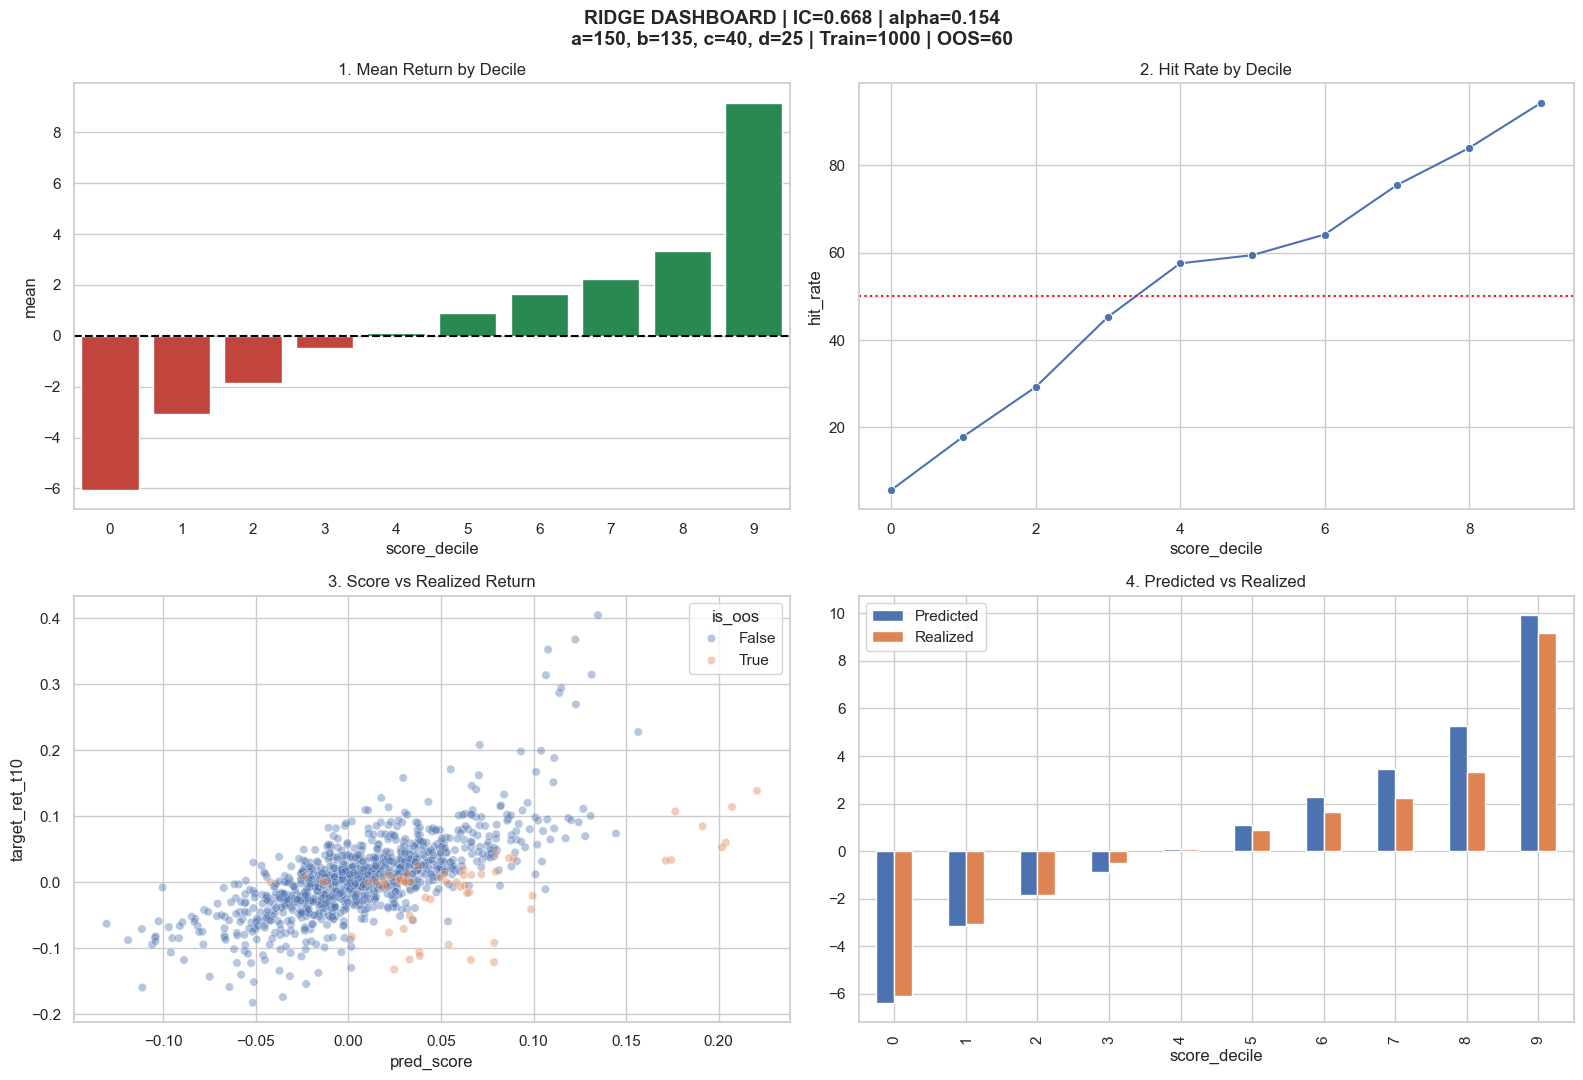

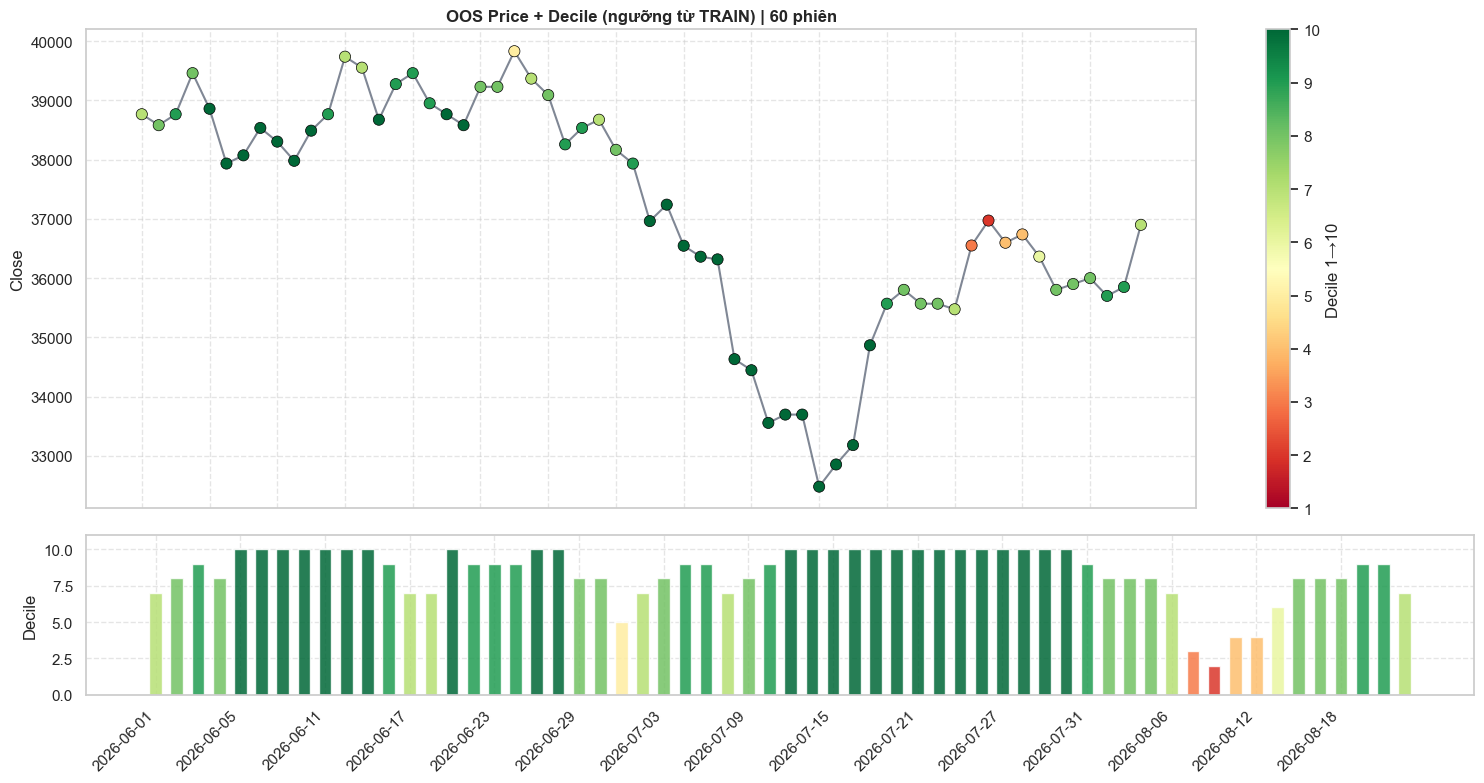

In [318]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# 1. LẤY BEST PARAMS TỪ OPTUNA (Ridge)
# ============================================================
best = study.best_trial

a = best.user_attrs["a"]
b = best.user_attrs["b"]
c = best.user_attrs["c"]
d = best.user_attrs["d"]
alpha = best.user_attrs["alpha"]
cols_to_exclude = best.user_attrs.get("cols_to_exclude", [])

print("="*70)
print("BEST PARAMS (Ridge)")
print("="*70)
print(f"a = {a} | b = {b} | c = {c} | d = {d}")
print(f"ridge_alpha = {alpha:.4f}")
print(f"LOOKBACK = {LOOKBACK_DAYS} | OOS = {OOS_DAYS}")
print("="*70)

y_col = "target_ret_t10"

# ============================================================
# 2. TẠO FEATURE (giống logic trong evaluate_params_ridge)
# ============================================================
def build_features(df_raw, a, b, c, d, investor_groups):
    df = df_vni_raw.copy()

    keep_cols = [
        'open', 'high', 'low', 'close', 'trading_value',
        'foreign_net_val', 'prop_net_val', 'local_ind_net_val', 'local_inst_net_val',
        'foreign_net_vol', 'prop_net_vol', 'local_ind_net_vol', 'local_inst_net_vol',
    ]
    keep_cols = [col for col in keep_cols if col in df.columns]
    df = df[keep_cols]

    df['trading_value'] = df['trading_value'].replace(0, np.nan).interpolate()
    df['close'] = df['close'].ffill()
    df['log_ret'] = np.log(df['close'] / df['close'].shift(1)).fillna(0)
    df['abs_ret'] = df['log_ret'].abs()

    tr = np.maximum(
        df['high'] - df['low'],
        np.maximum(
            (df['high'] - df['close'].shift(1)).abs(),
            (df['low'] - df['close'].shift(1)).abs()
        )
    )
    df['target_ret_t10'] = df['close'].shift(-10) / df['close'] - 1

    for g in investor_groups:
        net_val = df[f'{g}_net_val']
        net_ratio = net_val / df['trading_value']
        df[f'feat_{g}_net_ratio'] = net_ratio.fillna(0)

        prev = net_ratio.shift(1).abs()
        df[f'feat_{g}_price_impact'] = (df['abs_ret'].shift(1) / (prev + 1e-6)).rolling(5).median()

        mu = df[f'feat_{g}_net_ratio'].rolling(a).mean()
        sigma = df[f'feat_{g}_net_ratio'].rolling(a).std()
        df[f'feat_{g}_zscore'] = ((df[f'feat_{g}_net_ratio'] - mu) / (sigma + 1e-8)).clip(-4, 4).fillna(0)

        rmin = net_val.rolling(a).min()
        rmax = net_val.rolling(a).max()
        df[f'feat_{g}_sentiment'] = (2 * (net_val - rmin) / (rmax - rmin + 1e-6) - 1).fillna(0)

    df = df.replace([np.inf, -np.inf], 0).fillna(0)

    # ===================== FEATURE FACTORY =====================
    feature_dict = {}

    delta = df["close"].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / (loss + 1e-8)
    rsi = 100 - (100 / (1 + rs))
    feature_dict["ta_rsi_norm"] = (rsi / 100.0) - 0.5

    ma20 = df["close"].rolling(20).mean()
    feature_dict["ta_dist_ma20"] = (df["close"] - ma20) / ma20

    roll_high = df["high"].rolling(c).max()
    roll_low = df["low"].rolling(c).min()
    feature_dict["ta_pos_in_range"] = (df["close"] - roll_low) / (roll_high - roll_low + 1e-8)

    feature_dict["ta_atr_pct"] = tr.ewm(span=b, adjust=False).mean() / df["close"]

    for g in investor_groups:
        sent = df[f"feat_{g}_sentiment"]
        sent_ewm = sent.ewm(span=b, adjust=False).mean()
        feature_dict[f"feat_{g}_sentiment_ewm"] = sent_ewm

        sent_mean = sent_ewm.rolling(a, min_periods=10).mean()
        sent_std = sent_ewm.rolling(a, min_periods=10).std().replace(0, np.nan)
        sent_z = ((sent_ewm - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

        feature_dict[f"feat_{g}_sentiment_sq"] = sent_z**2
        feature_dict[f"feat_{g}_sentiment_cubed"] = (sent_z**3 - 3 * sent_z).clip(-10, 10)

        impulse = sent_ewm.diff(d).fillna(0)
        feature_dict[f"feat_{g}_flow_impulse_{d}d"] = impulse

        imp_mean = impulse.rolling(a, min_periods=10).mean()
        imp_std = impulse.rolling(a, min_periods=10).std().replace(0, np.nan)
        imp_z = ((impulse - imp_mean) / (imp_std + 1e-6)).clip(-3, 3).fillna(0)

        feature_dict[f"feat_{g}_flow_impulse_{d}d_sq"] = imp_z**2
        feature_dict[f"feat_{g}_flow_impulse_{d}d_cubed"] = (imp_z**3 - 3 * imp_z).clip(-10, 10)

        feature_dict[f"feat_{g}_eff_flow"] = sent * df[f"feat_{g}_price_impact"]
        feature_dict[f"feat_{g}_val_share"] = df[f"{g}_net_val"].abs() / df["trading_value"]

        implied = np.where(df[f"{g}_net_vol"] != 0, df[f"{g}_net_val"] / df[f"{g}_net_vol"], 0)
        feature_dict[f"feat_{g}_rel_net_price_ewm"] = (
            pd.Series(implied / df["close"], index=df.index).ewm(span=b, adjust=False).mean()
        )

        feature_dict[f"inter_{g}_sent_x_pos"]    = sent_z * feature_dict["ta_pos_in_range"]
        feature_dict[f"inter_{g}_sent_x_rsi"]    = sent_z * feature_dict["ta_rsi_norm"]
        feature_dict[f"inter_{g}_sent_x_distma"] = sent_z * feature_dict["ta_dist_ma20"]
        feature_dict[f"inter_{g}_imp_x_atr"]     = imp_z  * feature_dict["ta_atr_pct"]
        feature_dict[f"inter_{g}_eff_x_pos"]     = feature_dict[f"feat_{g}_eff_flow"] * feature_dict["ta_pos_in_range"]
        feature_dict[f"inter_{g}_sent_x_atr"]    = sent_z * feature_dict["ta_atr_pct"]

    df_feat = pd.DataFrame(feature_dict, index=df.index)
    model_data = pd.concat([df_feat, df[y_col], df[["close"]]], axis=1)
    model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()
    return model_data, list(df_feat.columns)


# ============================================================
# 3. TẠO DỮ LIỆU + CẮT TRAIN / OOS
# ============================================================
model_data, all_feature_cols = build_features(df_vni_raw, a, b, c, d, investor_groups)

X_cols = [col for col in all_feature_cols if col not in cols_to_exclude]

total_needed = LOOKBACK_DAYS + OOS_DAYS
if len(model_data) >= total_needed:
    train_data = model_data.iloc[-total_needed:-OOS_DAYS].copy()
    oos_data = model_data.iloc[-OOS_DAYS:].copy()
else:
    train_data = model_data.iloc[:-OOS_DAYS].copy() if len(model_data) > OOS_DAYS else model_data.copy()
    oos_data = model_data.iloc[-OOS_DAYS:].copy() if len(model_data) > OOS_DAYS else pd.DataFrame()

print(f"TRAIN: {len(train_data)} | OOS: {len(oos_data)} | Số feature: {len(X_cols)}")


# ============================================================
# 4. FIT RIDGE TRÊN TRAIN
# ============================================================
X_train = train_data[X_cols]
y_train = train_data[y_col]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

model = Ridge(alpha=alpha, random_state=42)
model.fit(X_train_scaled, y_train)

train_data = train_data.copy()
train_data["pred_score"] = model.predict(X_train_scaled)
train_data["actual_ret"] = y_train

ic_train, _ = spearmanr(train_data["pred_score"], train_data["actual_ret"])
hit_train = (train_data.loc[train_data["pred_score"] > 0, "actual_ret"] > 0).mean()

print("\n========== TRAIN ==========")
print(f"IC          : {ic_train:.4f}")
print(f"Hit Rate    : {hit_train:.4f}")
print(f"Số quan sát : {len(train_data)}")


# ============================================================
# 5. ĐÁNH GIÁ OOS
# ============================================================
if len(oos_data) > 0:
    X_oos = oos_data[X_cols]
    X_oos_scaled = scaler.transform(X_oos)

    oos_data = oos_data.copy()
    oos_data["pred_score"] = model.predict(X_oos_scaled)
    oos_data["actual_ret"] = oos_data[y_col]

    ic_oos, _ = spearmanr(oos_data["pred_score"], oos_data["actual_ret"])
    n_sig = int((oos_data["pred_score"] > 0).sum())
    hit_oos = (oos_data.loc[oos_data["pred_score"] > 0, "actual_ret"] > 0).mean() if n_sig > 0 else np.nan

    print("\n========== OOS ==========")
    print(f"IC          : {ic_oos:.4f}")
    print(f"Hit Rate    : {hit_oos:.4f}")
    print(f"Signals     : {n_sig}")
    print(f"Số quan sát : {len(oos_data)}")
else:
    print("\n[OOS] Không đủ dữ liệu")


# ============================================================
# 6. DECILE ANALYSIS (Train + OOS)
# ============================================================
eval_data = pd.concat([
    train_data[["pred_score", y_col]].assign(is_oos=False),
    oos_data[["pred_score", y_col]].assign(is_oos=True) if len(oos_data) > 0 else pd.DataFrame()
], axis=0).dropna()

eval_data["score_decile"] = pd.qcut(eval_data["pred_score"], 10, labels=False, duplicates="drop")

analysis = eval_data.groupby("score_decile")[y_col].agg(["mean", "std", "count"])
analysis["hit_rate"] = eval_data.groupby("score_decile")[y_col].apply(lambda x: (x > 0).mean())
analysis["avg_pred"] = eval_data.groupby("score_decile")["pred_score"].mean()

rank_ic = eval_data["pred_score"].corr(eval_data[y_col], method="spearman")
print(f"\n=== Rank IC (Train+OOS) = {rank_ic:.4f} ===")
print(analysis)


# ============================================================
# 7. DASHBOARD
# ============================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    f"RIDGE DASHBOARD | IC={rank_ic:.3f} | alpha={alpha:.3f}\n"
    f"a={a}, b={b}, c={c}, d={d} | Train={len(train_data)} | OOS={len(oos_data)}",
    fontsize=14, fontweight="bold"
)

colors = ["#d73027" if x < 0 else "#1a9850" for x in analysis["mean"]]
sns.barplot(x=analysis.index, y=analysis["mean"]*100, ax=axes[0,0], palette=colors)
axes[0,0].axhline(0, color="black", ls="--")
axes[0,0].set_title("1. Mean Return by Decile")

sns.lineplot(x=analysis.index, y=analysis["hit_rate"]*100, ax=axes[0,1], marker="o")
axes[0,1].axhline(50, color="red", ls=":")
axes[0,1].set_title("2. Hit Rate by Decile")

sns.scatterplot(data=eval_data, x="pred_score", y=y_col, hue="is_oos", ax=axes[1,0], alpha=0.4)
axes[1,0].set_title("3. Score vs Realized Return")

pd.DataFrame({
    "Predicted": analysis["avg_pred"]*100,
    "Realized": analysis["mean"]*100
}).plot(kind="bar", ax=axes[1,1])
axes[1,1].set_title("4. Predicted vs Realized")

plt.tight_layout()
plt.show()


# ============================================================
# 8. BIỂU ĐỒ GIÁ + DECILE OOS (ngưỡng lấy từ TRAIN)
# ============================================================
if len(oos_data) > 0:
    # Ngưỡng decile từ TRAIN
    train_scores = train_data["pred_score"]
    _, bin_edges = pd.qcut(train_scores, q=10, duplicates="drop", retbins=True)
    bin_edges = bin_edges.copy()
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf
    n_deciles = len(bin_edges) - 1

    oos_data = oos_data.copy()
    oos_data["decile"] = pd.cut(oos_data["pred_score"], bins=bin_edges, labels=False, include_lowest=True) + 1

    # Trục thời gian
    if "time" in df_vni_raw.columns:
        raw_dates = df_vni_raw.loc[oos_data.index, "time"]
    else:
        raw_dates = oos_data.index

    if pd.api.types.is_datetime64_any_dtype(raw_dates):
        x_dates = pd.to_datetime(raw_dates).dt.strftime("%Y-%m-%d").values
    else:
        x_dates = pd.to_datetime(raw_dates).strftime("%Y-%m-%d").values

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True,
                                   gridspec_kw={"height_ratios": [3, 1]})

    ax1.plot(x_dates, oos_data["close"], color="#4A5568", lw=1.5, alpha=0.7, label="Close")
    sc = ax1.scatter(x_dates, oos_data["close"], c=oos_data["decile"],
                     cmap="RdYlGn", vmin=1, vmax=n_deciles, s=65, zorder=5, edgecolors="black", linewidth=0.5)
    ax1.set_title(f"OOS Price + Decile (ngưỡng từ TRAIN) | {len(oos_data)} phiên", fontweight="bold")
    ax1.set_ylabel("Close")
    ax1.grid(True, ls="--", alpha=0.5)
    plt.colorbar(sc, ax=ax1, label=f"Decile 1→{n_deciles}")

    norm = (n_deciles - 1) if n_deciles > 1 else 1
    bar_colors = plt.cm.RdYlGn((oos_data["decile"] - 1) / norm)
    ax2.bar(x_dates, oos_data["decile"], color=bar_colors, alpha=0.85, width=0.6)
    ax2.set_ylabel("Decile")
    ax2.set_ylim(0, n_deciles + 1)
    ax2.grid(True, ls="--", alpha=0.5)
    plt.xticks(rotation=45, ha="right", ticks=range(0, len(x_dates), max(1, len(x_dates)//15)))

    plt.tight_layout()
    plt.show()

# optuna + Ridge 2

In [ ]:
import optuna
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# CẤU HÌNH ĐƠN GIẢN
# ============================================================
investor_groups = ["foreign", "prop", "local_inst", "local_ind"]
LOOKBACK_DAYS = 1000
OOS_DAYS = 60
TRIALS = 400

A_MIN, A_MAX = 30, 250
B_MIN, B_MAX = 25, 250
C_MIN, C_MAX = 15, 70
D_MIN, D_MAX = 5, 50

# ============================================================
# Hàm đánh giá – Ridge + Metrics đơn giản (ưu tiên Hit Rate)
# ============================================================
def evaluate_params_ridge(
    a, b, c, d, alpha,
    df_vni_raw,
    investor_groups,
    lookback_days=LOOKBACK_DAYS,
    oos_days=OOS_DAYS,
    min_signals=15,
):
    try:
        df = df_vni_raw.copy()

        keep_cols = [
            'open', 'high', 'low', 'close', 'trading_value',
            'foreign_net_val', 'prop_net_val', 'local_ind_net_val', 'local_inst_net_val',
            'foreign_net_vol', 'prop_net_vol', 'local_ind_net_vol', 'local_inst_net_vol',
        ]
        keep_cols = [col for col in keep_cols if col in df.columns]
        df = df[keep_cols]

        df['trading_value'] = df['trading_value'].replace(0, np.nan).interpolate()
        df['close'] = df['close'].ffill()
        df['log_ret'] = np.log(df['close'] / df['close'].shift(1)).fillna(0)
        df['abs_ret'] = df['log_ret'].abs()

        tr = np.maximum(
            df['high'] - df['low'],
            np.maximum(
                (df['high'] - df['close'].shift(1)).abs(),
                (df['low'] - df['close'].shift(1)).abs()
            )
        )
        df['target_ret_t10'] = df['close'].shift(-10) / df['close'] - 1

        for g in investor_groups:
            net_val = df[f'{g}_net_val']
            net_ratio = net_val / df['trading_value']
            df[f'feat_{g}_net_ratio'] = net_ratio.fillna(0)

            prev = net_ratio.shift(1).abs()
            df[f'feat_{g}_price_impact'] = (df['abs_ret'].shift(1) / (prev + 1e-6)).rolling(5).median()

            mu = df[f'feat_{g}_net_ratio'].rolling(a).mean()
            sigma = df[f'feat_{g}_net_ratio'].rolling(a).std()
            df[f'feat_{g}_zscore'] = ((df[f'feat_{g}_net_ratio'] - mu) / (sigma + 1e-8)).clip(-4, 4).fillna(0)

            rmin = net_val.rolling(a).min()
            rmax = net_val.rolling(a).max()
            df[f'feat_{g}_sentiment'] = (2 * (net_val - rmin) / (rmax - rmin + 1e-6) - 1).fillna(0)

        df = df.replace([np.inf, -np.inf], 0).fillna(0)

        # ===================== FEATURE FACTORY =====================
        feature_dict = {}

        delta = df["close"].diff()
        gain = delta.clip(lower=0).rolling(14).mean()
        loss = (-delta.clip(upper=0)).rolling(14).mean()
        rs = gain / (loss + 1e-8)
        rsi = 100 - (100 / (1 + rs))
        feature_dict["ta_rsi_norm"] = (rsi / 100.0) - 0.5

        ma20 = df["close"].rolling(20).mean()
        feature_dict["ta_dist_ma20"] = (df["close"] - ma20) / ma20

        roll_high = df["high"].rolling(c).max()
        roll_low = df["low"].rolling(c).min()
        feature_dict["ta_pos_in_range"] = (df["close"] - roll_low) / (roll_high - roll_low + 1e-8)

        feature_dict["ta_atr_pct"] = tr.ewm(span=b, adjust=False).mean() / df["close"]

        for g in investor_groups:
            sent = df[f"feat_{g}_sentiment"]
            sent_ewm = sent.ewm(span=b, adjust=False).mean()
            feature_dict[f"feat_{g}_sentiment_ewm"] = sent_ewm

            sent_mean = sent_ewm.rolling(a, min_periods=10).mean()
            sent_std = sent_ewm.rolling(a, min_periods=10).std().replace(0, np.nan)
            sent_z = ((sent_ewm - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

            feature_dict[f"feat_{g}_sentiment_sq"] = sent_z**2
            feature_dict[f"feat_{g}_sentiment_cubed"] = (sent_z**3 - 3 * sent_z).clip(-10, 10)

            impulse = sent_ewm.diff(d).fillna(0)
            feature_dict[f"feat_{g}_flow_impulse_{d}d"] = impulse

            imp_mean = impulse.rolling(a, min_periods=10).mean()
            imp_std = impulse.rolling(a, min_periods=10).std().replace(0, np.nan)
            imp_z = ((impulse - imp_mean) / (imp_std + 1e-6)).clip(-3, 3).fillna(0)

            feature_dict[f"feat_{g}_flow_impulse_{d}d_sq"] = imp_z**2
            feature_dict[f"feat_{g}_flow_impulse_{d}d_cubed"] = (imp_z**3 - 3 * imp_z).clip(-10, 10)

            feature_dict[f"feat_{g}_eff_flow"] = sent * df[f"feat_{g}_price_impact"]
            feature_dict[f"feat_{g}_val_share"] = df[f"{g}_net_val"].abs() / df["trading_value"]

            implied = np.where(df[f"{g}_net_vol"] != 0, df[f"{g}_net_val"] / df[f"{g}_net_vol"], 0)
            feature_dict[f"feat_{g}_rel_net_price_ewm"] = (
                pd.Series(implied / df["close"], index=df.index).ewm(span=b, adjust=False).mean()
            )

            feature_dict[f"inter_{g}_sent_x_pos"]    = sent_z * feature_dict["ta_pos_in_range"]
            feature_dict[f"inter_{g}_sent_x_rsi"]    = sent_z * feature_dict["ta_rsi_norm"]
            feature_dict[f"inter_{g}_sent_x_distma"] = sent_z * feature_dict["ta_dist_ma20"]
            feature_dict[f"inter_{g}_imp_x_atr"]     = imp_z  * feature_dict["ta_atr_pct"]
            feature_dict[f"inter_{g}_eff_x_pos"]     = feature_dict[f"feat_{g}_eff_flow"] * feature_dict["ta_pos_in_range"]
            feature_dict[f"inter_{g}_sent_x_atr"]    = sent_z * feature_dict["ta_atr_pct"]

        df_feat = pd.DataFrame(feature_dict, index=df.index)
        model_data = pd.concat([df_feat, df["target_ret_t10"]], axis=1)
        model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()

        if len(model_data) < (lookback_days + oos_days + 50):
            return -999.0, -1.0, 0.0, 0.0, 0

        train_data = model_data.iloc[-(lookback_days + oos_days):-oos_days].copy()
        if len(train_data) < 300:
            return -999.0, -1.0, 0.0, 0.0, 0

        X = train_data.drop(columns=["target_ret_t10"]).values
        y = train_data["target_ret_t10"].values

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        model = Ridge(alpha=alpha, random_state=42)
        model.fit(X_scaled, y)
        pred = model.predict(X_scaled)

        # ---------- Metrics đơn giản ----------
        ic, _ = spearmanr(pred, y)
        if np.isnan(ic):
            ic = -1.0

        mask_up = pred > 0
        n_signals = int(mask_up.sum())
        hit_rate_up = (y[mask_up] > 0).mean() if n_signals >= min_signals else 0.50
        avg_ret_when_up = float(y[mask_up].mean()) if n_signals >= min_signals else 0.0

        # ---------- Score ưu tiên Hit Rate ----------
        # Hit rate là chính, IC là phụ
        hit_term = (hit_rate_up - 0.50) * 2.0          # 0.50 → 0 | 0.70 → 0.40
        ic_term = np.clip(ic, -0.2, 0.6)

        score = 0.70 * hit_term + 0.30 * ic_term

        # Thưởng nhẹ nếu avg return dương
        if avg_ret_when_up > 0:
            score += 0.05 * np.clip(avg_ret_when_up * 10, 0, 0.3)

        # Hard filter
        if hit_rate_up < 0.52 or ic < 0.02 or n_signals < min_signals:
            score = -999.0

        return float(score), float(ic), float(hit_rate_up), float(avg_ret_when_up), n_signals

    except Exception:
        return -999.0, -1.0, 0.0, 0.0, 0


# ============================================================
# OBJECTIVE – Không còn ràng buộc a-b, không VIF
# ============================================================
def objective(trial):
    a = trial.suggest_int("window_z", A_MIN, A_MAX, step=10)
    b = trial.suggest_int("window_div", B_MIN, B_MAX, step=10)
    c = trial.suggest_int("pos_range", C_MIN, C_MAX, step=5)
    d = trial.suggest_int("impulse_days", D_MIN, D_MAX, step=5)
    alpha = trial.suggest_float("ridge_alpha", 0.1, 30.0, log=True)

    score, ic, hit_up, avg_ret, n_sig = evaluate_params_ridge(
        a, b, c, d, alpha,
        df_vni_raw,
        investor_groups,
        lookback_days=LOOKBACK_DAYS,
        oos_days=OOS_DAYS,
    )

    trial.set_user_attr("ic", ic)
    trial.set_user_attr("hit_rate_up", hit_up)
    trial.set_user_attr("avg_ret_when_up", avg_ret)
    trial.set_user_attr("n_signals", n_sig)
    trial.set_user_attr("a", a)
    trial.set_user_attr("b", b)
    trial.set_user_attr("c", c)
    trial.set_user_attr("d", d)
    trial.set_user_attr("alpha", alpha)

    return score


# ============================================================
# CHẠY
# ============================================================
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=25, n_warmup_steps=10),
)

study.optimize(objective, n_trials=TRIALS, show_progress_bar=True)

# ============================================================
# KẾT QUẢ
# ============================================================
best = study.best_trial
print("\n" + "="*70)
print("BEST TRIAL – RIDGE (ưu tiên Hit Rate)")
print("="*70)
print(f"Score           : {best.value:.4f}")
print(f"IC              : {best.user_attrs['ic']:.4f}")
print(f"Hit Rate Up     : {best.user_attrs['hit_rate_up']:.4f}")
print(f"Avg Ret when Up : {best.user_attrs['avg_ret_when_up']:.5f}")
print(f"n_signals       : {best.user_attrs['n_signals']}")
print(f"\nParams:")
print(f"  a = {best.user_attrs['a']}, b = {best.user_attrs['b']}, "
      f"c = {best.user_attrs['c']}, d = {best.user_attrs['d']}")
print(f"  ridge_alpha = {best.user_attrs['alpha']:.4f}")

[I 2026-08-21 21:57:57,442] A new study created in memory with name: no-name-8203d2ad-f0ab-48c6-982f-8467d1a813f6


  0%|          | 0/400 [00:00<?, ?it/s]

[I 2026-08-21 21:57:57,525] Trial 0 finished with value: 0.5242682926829267 and parameters: {'window_z': 110, 'window_div': 235, 'pos_range': 55, 'impulse_days': 25, 'ridge_alpha': 0.24348773534554594}. Best is trial 0 with value: 0.5242682926829267.
[I 2026-08-21 21:57:57,577] Trial 1 finished with value: 0.4626293379731021 and parameters: {'window_z': 60, 'window_div': 35, 'pos_range': 65, 'impulse_days': 25, 'ridge_alpha': 5.675206026988748}. Best is trial 0 with value: 0.5242682926829267.
[I 2026-08-21 21:57:57,649] Trial 2 finished with value: 0.4773806171256082 and parameters: {'window_z': 30, 'window_div': 245, 'pos_range': 60, 'impulse_days': 10, 'ridge_alpha': 0.2820996133514491}. Best is trial 0 with value: 0.5242682926829267.
[I 2026-08-21 21:57:57,731] Trial 3 finished with value: 0.5509726962457339 and parameters: {'window_z': 70, 'window_div': 85, 'pos_range': 45, 'impulse_days': 20, 'ridge_alpha': 0.5265139631677751}. Best is trial 3 with value: 0.5509726962457339.
[I 20

BEST PARAMS (Ridge)
a = 210 | b = 245 | c = 25 | d = 35
ridge_alpha = 0.7178
LOOKBACK = 1000 | OOS = 60
TRAIN: 1000 | OOS: 60 | Số feature: 64

========== TRAIN ==========
IC          : 0.7038
Hit Rate    : 0.7948
Số quan sát : 1000

========== OOS ==========
IC          : 0.7584
Hit Rate    : 0.5094
Signals     : 53
Số quan sát : 60

=== Rank IC (Train+OOS) = 0.6943 ===
                  mean       std  count  hit_rate  avg_pred
score_decile                                               
0            -0.053158  0.044102    106  0.066038 -0.060552
1            -0.028916  0.031882    106  0.179245 -0.030834
2            -0.027762  0.038061    106  0.264151 -0.018785
3            -0.017169  0.039569    106  0.367925 -0.008604
4            -0.002791  0.040349    106  0.537736  0.001114
5             0.011767  0.034097    106  0.641509  0.011113
6             0.014241  0.031544    106  0.745283  0.021362
7             0.030638  0.038590    106  0.726415  0.033394
8             0.045874  0.

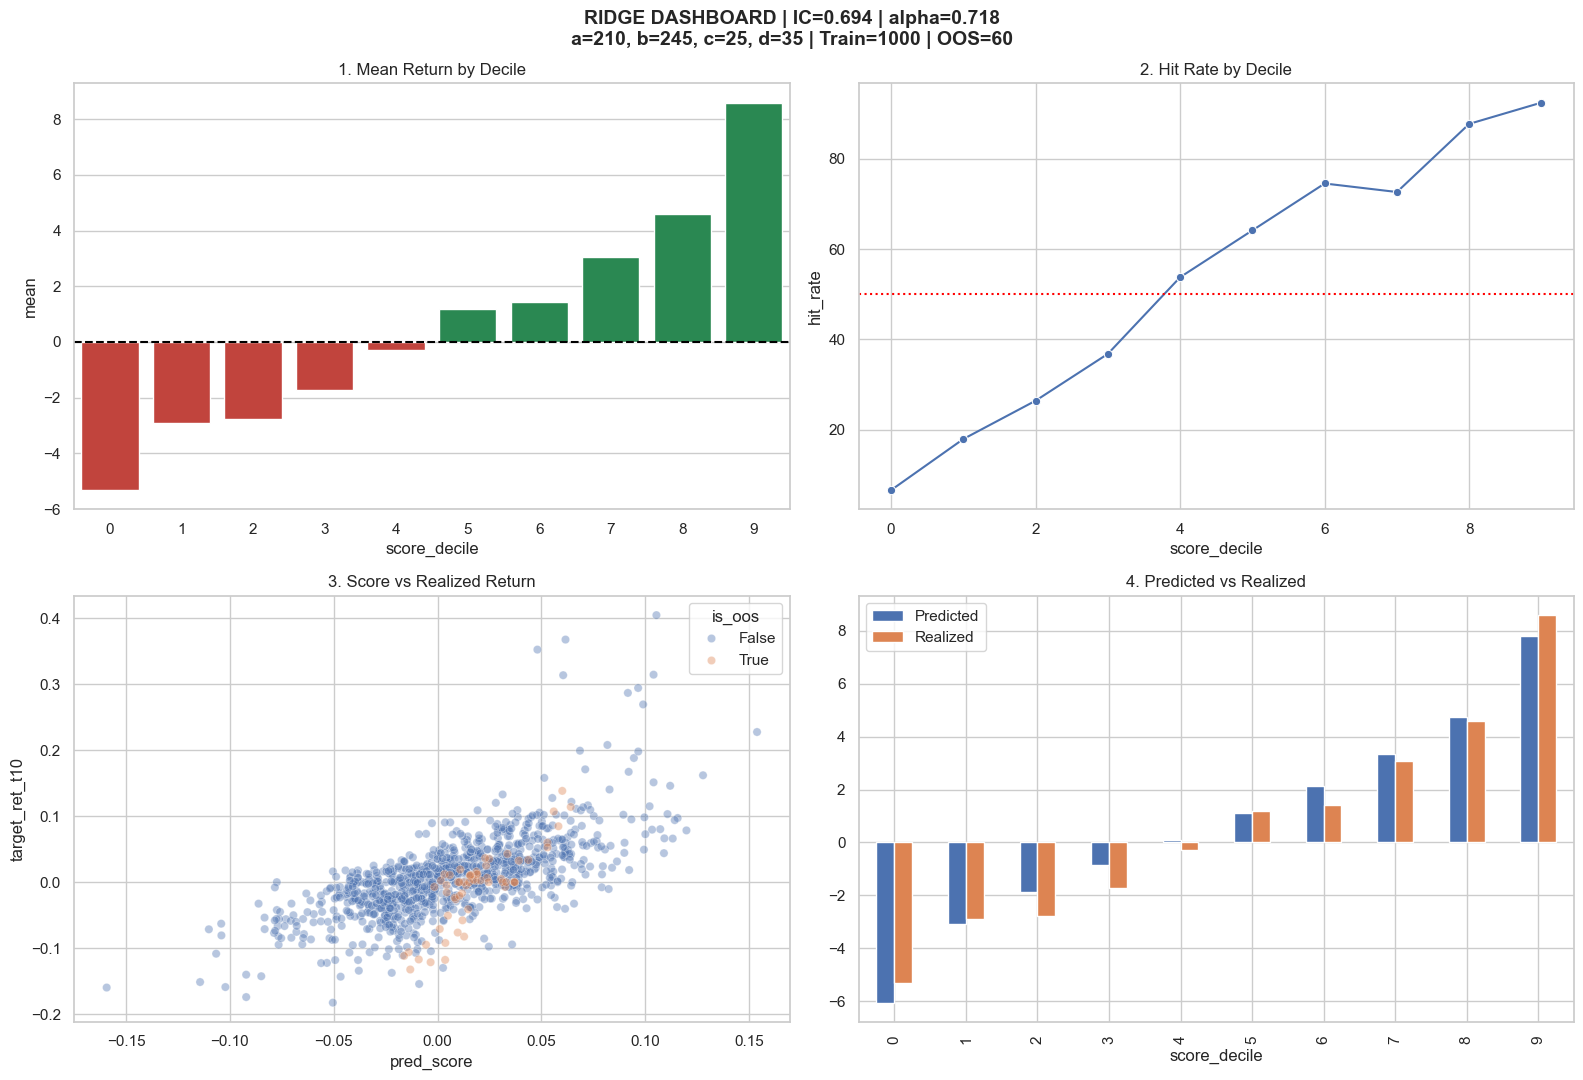

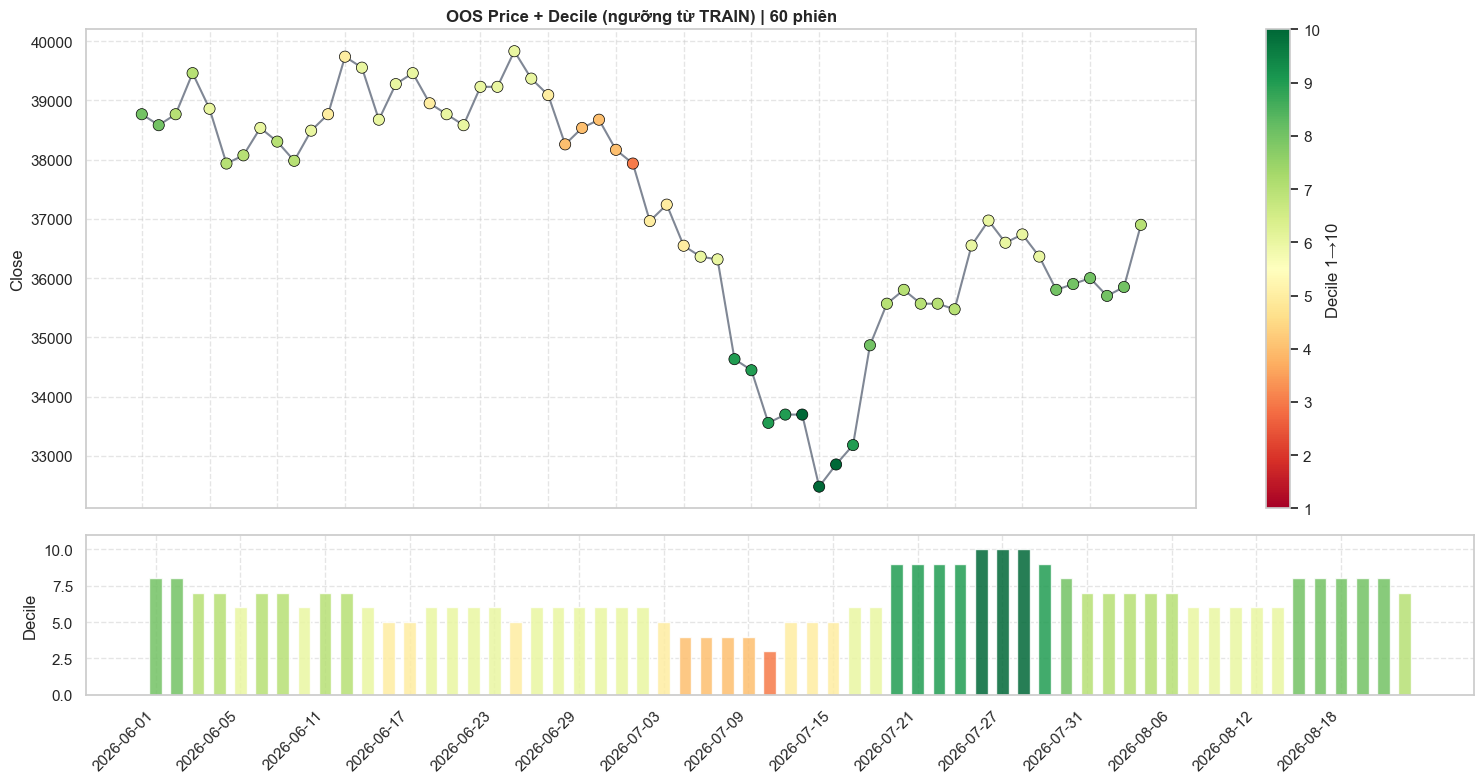

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# 1. LẤY BEST PARAMS TỪ OPTUNA (Ridge)
# ============================================================
best = study.best_trial

a = best.user_attrs["a"]
b = best.user_attrs["b"]
c = best.user_attrs["c"]
d = best.user_attrs["d"]
alpha = best.user_attrs["alpha"]
cols_to_exclude = best.user_attrs.get("cols_to_exclude", [])

print("="*70)
print("BEST PARAMS (Ridge)")
print("="*70)
print(f"a = {a} | b = {b} | c = {c} | d = {d}")
print(f"ridge_alpha = {alpha:.4f}")
print(f"LOOKBACK = {LOOKBACK_DAYS} | OOS = {OOS_DAYS}")
print("="*70)

y_col = "target_ret_t10"

# ============================================================
# 2. TẠO FEATURE (giống logic trong evaluate_params_ridge)
# ============================================================
def build_features(df_raw, a, b, c, d, investor_groups):
    df = df_vni_raw.copy()

    keep_cols = [
        'open', 'high', 'low', 'close', 'trading_value',
        'foreign_net_val', 'prop_net_val', 'local_ind_net_val', 'local_inst_net_val',
        'foreign_net_vol', 'prop_net_vol', 'local_ind_net_vol', 'local_inst_net_vol',
    ]
    keep_cols = [col for col in keep_cols if col in df.columns]
    df = df[keep_cols]

    df['trading_value'] = df['trading_value'].replace(0, np.nan).interpolate()
    df['close'] = df['close'].ffill()
    df['log_ret'] = np.log(df['close'] / df['close'].shift(1)).fillna(0)
    df['abs_ret'] = df['log_ret'].abs()

    tr = np.maximum(
        df['high'] - df['low'],
        np.maximum(
            (df['high'] - df['close'].shift(1)).abs(),
            (df['low'] - df['close'].shift(1)).abs()
        )
    )
    df['target_ret_t10'] = df['close'].shift(-10) / df['close'] - 1

    for g in investor_groups:
        net_val = df[f'{g}_net_val']
        net_ratio = net_val / df['trading_value']
        df[f'feat_{g}_net_ratio'] = net_ratio.fillna(0)

        prev = net_ratio.shift(1).abs()
        df[f'feat_{g}_price_impact'] = (df['abs_ret'].shift(1) / (prev + 1e-6)).rolling(5).median()

        mu = df[f'feat_{g}_net_ratio'].rolling(a).mean()
        sigma = df[f'feat_{g}_net_ratio'].rolling(a).std()
        df[f'feat_{g}_zscore'] = ((df[f'feat_{g}_net_ratio'] - mu) / (sigma + 1e-8)).clip(-4, 4).fillna(0)

        rmin = net_val.rolling(a).min()
        rmax = net_val.rolling(a).max()
        df[f'feat_{g}_sentiment'] = (2 * (net_val - rmin) / (rmax - rmin + 1e-6) - 1).fillna(0)

    df = df.replace([np.inf, -np.inf], 0).fillna(0)

    # ===================== FEATURE FACTORY =====================
    feature_dict = {}

    delta = df["close"].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / (loss + 1e-8)
    rsi = 100 - (100 / (1 + rs))
    feature_dict["ta_rsi_norm"] = (rsi / 100.0) - 0.5

    ma20 = df["close"].rolling(20).mean()
    feature_dict["ta_dist_ma20"] = (df["close"] - ma20) / ma20

    roll_high = df["high"].rolling(c).max()
    roll_low = df["low"].rolling(c).min()
    feature_dict["ta_pos_in_range"] = (df["close"] - roll_low) / (roll_high - roll_low + 1e-8)

    feature_dict["ta_atr_pct"] = tr.ewm(span=b, adjust=False).mean() / df["close"]

    for g in investor_groups:
        sent = df[f"feat_{g}_sentiment"]
        sent_ewm = sent.ewm(span=b, adjust=False).mean()
        feature_dict[f"feat_{g}_sentiment_ewm"] = sent_ewm

        sent_mean = sent_ewm.rolling(a, min_periods=10).mean()
        sent_std = sent_ewm.rolling(a, min_periods=10).std().replace(0, np.nan)
        sent_z = ((sent_ewm - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

        feature_dict[f"feat_{g}_sentiment_sq"] = sent_z**2
        feature_dict[f"feat_{g}_sentiment_cubed"] = (sent_z**3 - 3 * sent_z).clip(-10, 10)

        impulse = sent_ewm.diff(d).fillna(0)
        feature_dict[f"feat_{g}_flow_impulse_{d}d"] = impulse

        imp_mean = impulse.rolling(a, min_periods=10).mean()
        imp_std = impulse.rolling(a, min_periods=10).std().replace(0, np.nan)
        imp_z = ((impulse - imp_mean) / (imp_std + 1e-6)).clip(-3, 3).fillna(0)

        feature_dict[f"feat_{g}_flow_impulse_{d}d_sq"] = imp_z**2
        feature_dict[f"feat_{g}_flow_impulse_{d}d_cubed"] = (imp_z**3 - 3 * imp_z).clip(-10, 10)

        feature_dict[f"feat_{g}_eff_flow"] = sent * df[f"feat_{g}_price_impact"]
        feature_dict[f"feat_{g}_val_share"] = df[f"{g}_net_val"].abs() / df["trading_value"]

        implied = np.where(df[f"{g}_net_vol"] != 0, df[f"{g}_net_val"] / df[f"{g}_net_vol"], 0)
        feature_dict[f"feat_{g}_rel_net_price_ewm"] = (
            pd.Series(implied / df["close"], index=df.index).ewm(span=b, adjust=False).mean()
        )

        feature_dict[f"inter_{g}_sent_x_pos"]    = sent_z * feature_dict["ta_pos_in_range"]
        feature_dict[f"inter_{g}_sent_x_rsi"]    = sent_z * feature_dict["ta_rsi_norm"]
        feature_dict[f"inter_{g}_sent_x_distma"] = sent_z * feature_dict["ta_dist_ma20"]
        feature_dict[f"inter_{g}_imp_x_atr"]     = imp_z  * feature_dict["ta_atr_pct"]
        feature_dict[f"inter_{g}_eff_x_pos"]     = feature_dict[f"feat_{g}_eff_flow"] * feature_dict["ta_pos_in_range"]
        feature_dict[f"inter_{g}_sent_x_atr"]    = sent_z * feature_dict["ta_atr_pct"]

    df_feat = pd.DataFrame(feature_dict, index=df.index)
    model_data = pd.concat([df_feat, df[y_col], df[["close"]]], axis=1)
    model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()
    return model_data, list(df_feat.columns)


# ============================================================
# 3. TẠO DỮ LIỆU + CẮT TRAIN / OOS
# ============================================================
model_data, all_feature_cols = build_features(df_vni_raw, a, b, c, d, investor_groups)

X_cols = [col for col in all_feature_cols if col not in cols_to_exclude]

total_needed = LOOKBACK_DAYS + OOS_DAYS
if len(model_data) >= total_needed:
    train_data = model_data.iloc[-total_needed:-OOS_DAYS].copy()
    oos_data = model_data.iloc[-OOS_DAYS:].copy()
else:
    train_data = model_data.iloc[:-OOS_DAYS].copy() if len(model_data) > OOS_DAYS else model_data.copy()
    oos_data = model_data.iloc[-OOS_DAYS:].copy() if len(model_data) > OOS_DAYS else pd.DataFrame()

print(f"TRAIN: {len(train_data)} | OOS: {len(oos_data)} | Số feature: {len(X_cols)}")


# ============================================================
# 4. FIT RIDGE TRÊN TRAIN
# ============================================================
X_train = train_data[X_cols]
y_train = train_data[y_col]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

model = Ridge(alpha=alpha, random_state=42)
model.fit(X_train_scaled, y_train)

train_data = train_data.copy()
train_data["pred_score"] = model.predict(X_train_scaled)
train_data["actual_ret"] = y_train

ic_train, _ = spearmanr(train_data["pred_score"], train_data["actual_ret"])
hit_train = (train_data.loc[train_data["pred_score"] > 0, "actual_ret"] > 0).mean()

print("\n========== TRAIN ==========")
print(f"IC          : {ic_train:.4f}")
print(f"Hit Rate    : {hit_train:.4f}")
print(f"Số quan sát : {len(train_data)}")


# ============================================================
# 5. ĐÁNH GIÁ OOS
# ============================================================
if len(oos_data) > 0:
    X_oos = oos_data[X_cols]
    X_oos_scaled = scaler.transform(X_oos)

    oos_data = oos_data.copy()
    oos_data["pred_score"] = model.predict(X_oos_scaled)
    oos_data["actual_ret"] = oos_data[y_col]

    ic_oos, _ = spearmanr(oos_data["pred_score"], oos_data["actual_ret"])
    n_sig = int((oos_data["pred_score"] > 0).sum())
    hit_oos = (oos_data.loc[oos_data["pred_score"] > 0, "actual_ret"] > 0).mean() if n_sig > 0 else np.nan

    print("\n========== OOS ==========")
    print(f"IC          : {ic_oos:.4f}")
    print(f"Hit Rate    : {hit_oos:.4f}")
    print(f"Signals     : {n_sig}")
    print(f"Số quan sát : {len(oos_data)}")
else:
    print("\n[OOS] Không đủ dữ liệu")


# ============================================================
# 6. DECILE ANALYSIS (Train + OOS)
# ============================================================
eval_data = pd.concat([
    train_data[["pred_score", y_col]].assign(is_oos=False),
    oos_data[["pred_score", y_col]].assign(is_oos=True) if len(oos_data) > 0 else pd.DataFrame()
], axis=0).dropna()

eval_data["score_decile"] = pd.qcut(eval_data["pred_score"], 10, labels=False, duplicates="drop")

analysis = eval_data.groupby("score_decile")[y_col].agg(["mean", "std", "count"])
analysis["hit_rate"] = eval_data.groupby("score_decile")[y_col].apply(lambda x: (x > 0).mean())
analysis["avg_pred"] = eval_data.groupby("score_decile")["pred_score"].mean()

rank_ic = eval_data["pred_score"].corr(eval_data[y_col], method="spearman")
print(f"\n=== Rank IC (Train+OOS) = {rank_ic:.4f} ===")
print(analysis)


# ============================================================
# 7. DASHBOARD
# ============================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    f"RIDGE DASHBOARD | IC={rank_ic:.3f} | alpha={alpha:.3f}\n"
    f"a={a}, b={b}, c={c}, d={d} | Train={len(train_data)} | OOS={len(oos_data)}",
    fontsize=14, fontweight="bold"
)

colors = ["#d73027" if x < 0 else "#1a9850" for x in analysis["mean"]]
sns.barplot(x=analysis.index, y=analysis["mean"]*100, ax=axes[0,0], palette=colors)
axes[0,0].axhline(0, color="black", ls="--")
axes[0,0].set_title("1. Mean Return by Decile")

sns.lineplot(x=analysis.index, y=analysis["hit_rate"]*100, ax=axes[0,1], marker="o")
axes[0,1].axhline(50, color="red", ls=":")
axes[0,1].set_title("2. Hit Rate by Decile")

sns.scatterplot(data=eval_data, x="pred_score", y=y_col, hue="is_oos", ax=axes[1,0], alpha=0.4)
axes[1,0].set_title("3. Score vs Realized Return")

pd.DataFrame({
    "Predicted": analysis["avg_pred"]*100,
    "Realized": analysis["mean"]*100
}).plot(kind="bar", ax=axes[1,1])
axes[1,1].set_title("4. Predicted vs Realized")

plt.tight_layout()
plt.show()


# ============================================================
# 8. BIỂU ĐỒ GIÁ + DECILE OOS (ngưỡng lấy từ TRAIN)
# ============================================================
if len(oos_data) > 0:
    # Ngưỡng decile từ TRAIN
    train_scores = train_data["pred_score"]
    _, bin_edges = pd.qcut(train_scores, q=10, duplicates="drop", retbins=True)
    bin_edges = bin_edges.copy()
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf
    n_deciles = len(bin_edges) - 1

    oos_data = oos_data.copy()
    oos_data["decile"] = pd.cut(oos_data["pred_score"], bins=bin_edges, labels=False, include_lowest=True) + 1

    # Trục thời gian
    if "time" in df_vni_raw.columns:
        raw_dates = df_vni_raw.loc[oos_data.index, "time"]
    else:
        raw_dates = oos_data.index

    if pd.api.types.is_datetime64_any_dtype(raw_dates):
        x_dates = pd.to_datetime(raw_dates).dt.strftime("%Y-%m-%d").values
    else:
        x_dates = pd.to_datetime(raw_dates).strftime("%Y-%m-%d").values

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True,
                                   gridspec_kw={"height_ratios": [3, 1]})

    ax1.plot(x_dates, oos_data["close"], color="#4A5568", lw=1.5, alpha=0.7, label="Close")
    sc = ax1.scatter(x_dates, oos_data["close"], c=oos_data["decile"],
                     cmap="RdYlGn", vmin=1, vmax=n_deciles, s=65, zorder=5, edgecolors="black", linewidth=0.5)
    ax1.set_title(f"{SYMBOL} - OOS Price + Decile (ngưỡng từ TRAIN) | {len(oos_data)} phiên", fontweight="bold")
    ax1.set_ylabel("Close")
    ax1.grid(True, ls="--", alpha=0.5)
    plt.colorbar(sc, ax=ax1, label=f"Decile 1→{n_deciles}")

    norm = (n_deciles - 1) if n_deciles > 1 else 1
    bar_colors = plt.cm.RdYlGn((oos_data["decile"] - 1) / norm)
    ax2.bar(x_dates, oos_data["decile"], color=bar_colors, alpha=0.85, width=0.6)
    ax2.set_ylabel("Decile")
    ax2.set_ylim(0, n_deciles + 1)
    ax2.grid(True, ls="--", alpha=0.5)
    plt.xticks(rotation=45, ha="right", ticks=range(0, len(x_dates), max(1, len(x_dates)//15)))

    plt.tight_layout()
    plt.show()

# optuna + ridge 3 

In [10]:
SYMBOL = 'VHM'

# --- BƯỚC 1: CHUẨN BỊ DỮ LIỆU ---
excel_file_path_vni = rf"E:\Document\Tao\FiinGroup\csv_data\Kafi_Phân_Loại_Nhà_Đầu_Tư_{SYMBOL}.csv"
excel_file_path_vni_new = rf"E:\Document\Tao\FiinGroup\csv_data\Kafi_Giá_{SYMBOL}.csv"

investor_groups = ['foreign', 'prop', 'local_ind', 'local_inst']

df_vni_raw = load_and_map_excel(excel_file_path_vni, df_history=None)

In [88]:
import optuna
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# CẤU HÌNH ĐƠN GIẢN
# ============================================================
investor_groups = ["foreign", "prop", "local_inst", "local_ind"]
LOOKBACK_DAYS = 1000
OOS_DAYS = 60
TRIALS = 400

A_MIN, A_MAX = 30, 250
B_MIN, B_MAX = 25, 250
C_MIN, C_MAX = 15, 70
D_MIN, D_MAX = 5, 50

# ============================================================
# Hàm đánh giá – Ridge + Metrics đơn giản (ưu tiên Hit Rate)
# ============================================================
def evaluate_params_ridge(
    a, b, c, d, alpha,
    df_vni_raw,
    investor_groups,
    lookback_days=LOOKBACK_DAYS,
    oos_days=OOS_DAYS,
    min_signals=15,
):
    try:
        df = df_vni_raw.copy()

        keep_cols = [
            'open', 'high', 'low', 'close', 'trading_value',
            'foreign_net_val', 'prop_net_val', 'local_ind_net_val', 'local_inst_net_val',
            'foreign_net_vol', 'prop_net_vol', 'local_ind_net_vol', 'local_inst_net_vol',
        ]
        keep_cols = [col for col in keep_cols if col in df.columns]
        df = df[keep_cols]

        df['trading_value'] = df['trading_value'].replace(0, np.nan).interpolate()
        df['close'] = df['close'].ffill()
        df['log_ret'] = np.log(df['close'] / df['close'].shift(1)).fillna(0)
        df['abs_ret'] = df['log_ret'].abs()

        tr = np.maximum(
            df['high'] - df['low'],
            np.maximum(
                (df['high'] - df['close'].shift(1)).abs(),
                (df['low'] - df['close'].shift(1)).abs()
            )
        )
        df['target_ret_t10'] = df['close'].shift(-10) / df['close'] - 1

        for g in investor_groups:
            net_val = df[f'{g}_net_val']
            net_ratio = net_val / df['trading_value']
            df[f'feat_{g}_net_ratio'] = net_ratio.fillna(0)

            prev = net_ratio.shift(1).abs()
            df[f'feat_{g}_price_impact'] = (df['abs_ret'].shift(1) / (prev + 1e-6)).rolling(5).median()

            mu = df[f'feat_{g}_net_ratio'].rolling(a).mean()
            sigma = df[f'feat_{g}_net_ratio'].rolling(a).std()
            df[f'feat_{g}_zscore'] = ((df[f'feat_{g}_net_ratio'] - mu) / (sigma + 1e-8)).clip(-4, 4).fillna(0)

            rmin = net_val.rolling(a).min()
            rmax = net_val.rolling(a).max()
            df[f'feat_{g}_sentiment'] = (2 * (net_val - rmin) / (rmax - rmin + 1e-6) - 1).fillna(0)

        df = df.replace([np.inf, -np.inf], 0).fillna(0)

        # ===================== FEATURE FACTORY =====================
        feature_dict = {}

        delta = df["close"].diff()
        gain = delta.clip(lower=0).rolling(14).mean()
        loss = (-delta.clip(upper=0)).rolling(14).mean()
        rs = gain / (loss + 1e-8)
        rsi = 100 - (100 / (1 + rs))
        feature_dict["ta_rsi_norm"] = (rsi / 100.0) - 0.5

        ma20 = df["close"].rolling(20).mean()
        feature_dict["ta_dist_ma20"] = (df["close"] - ma20) / ma20

        roll_high = df["high"].rolling(c).max()
        roll_low = df["low"].rolling(c).min()
        feature_dict["ta_pos_in_range"] = (df["close"] - roll_low) / (roll_high - roll_low + 1e-8)

        feature_dict["ta_atr_pct"] = tr.ewm(span=b, adjust=False).mean() / df["close"]

        for g in investor_groups:
            sent = df[f"feat_{g}_sentiment"]
            sent_ewm = sent.ewm(span=b, adjust=False).mean()
            feature_dict[f"feat_{g}_sentiment_ewm"] = sent_ewm

            sent_mean = sent_ewm.rolling(a, min_periods=10).mean()
            sent_std = sent_ewm.rolling(a, min_periods=10).std().replace(0, np.nan)
            sent_z = ((sent_ewm - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

            feature_dict[f"feat_{g}_sentiment_sq"] = sent_z**2
            feature_dict[f"feat_{g}_sentiment_cubed"] = (sent_z**3 - 3 * sent_z).clip(-10, 10)

            impulse = sent_ewm.diff(d).fillna(0)
            feature_dict[f"feat_{g}_flow_impulse_{d}d"] = impulse

            imp_mean = impulse.rolling(a, min_periods=10).mean()
            imp_std = impulse.rolling(a, min_periods=10).std().replace(0, np.nan)
            imp_z = ((impulse - imp_mean) / (imp_std + 1e-6)).clip(-3, 3).fillna(0)

            feature_dict[f"feat_{g}_flow_impulse_{d}d_sq"] = imp_z**2
            feature_dict[f"feat_{g}_flow_impulse_{d}d_cubed"] = (imp_z**3 - 3 * imp_z).clip(-10, 10)

            feature_dict[f"feat_{g}_eff_flow"] = sent * df[f"feat_{g}_price_impact"]
            feature_dict[f"feat_{g}_val_share"] = df[f"{g}_net_val"].abs() / df["trading_value"]

            implied = np.where(df[f"{g}_net_vol"] != 0, df[f"{g}_net_val"] / df[f"{g}_net_vol"], 0)
            feature_dict[f"feat_{g}_rel_net_price_ewm"] = (
                pd.Series(implied / df["close"], index=df.index).ewm(span=b, adjust=False).mean()
            )

            feature_dict[f"inter_{g}_sent_x_pos"]    = sent_z * feature_dict["ta_pos_in_range"]
            feature_dict[f"inter_{g}_sent_x_rsi"]    = sent_z * feature_dict["ta_rsi_norm"]
            feature_dict[f"inter_{g}_sent_x_distma"] = sent_z * feature_dict["ta_dist_ma20"]
            feature_dict[f"inter_{g}_imp_x_atr"]     = imp_z  * feature_dict["ta_atr_pct"]
            feature_dict[f"inter_{g}_eff_x_pos"]     = feature_dict[f"feat_{g}_eff_flow"] * feature_dict["ta_pos_in_range"]
            feature_dict[f"inter_{g}_sent_x_atr"]    = sent_z * feature_dict["ta_atr_pct"]
        # ============================================================
        # CROSS-INVESTOR FEATURES (Toàn bộ mối quan hệ)
        # ============================================================
        groups = investor_groups  # ["foreign", "prop", "local_inst", "local_ind"]

        # Lấy các series đã có
        sent_ewm = {g: feature_dict[f"feat_{g}_sentiment_ewm"] for g in groups}
        sent_z   = {}
        for g in groups:
            # tái tạo sent_z nếu cần (hoặc lấy từ biến đã tính trước đó)
            sent = df[f"feat_{g}_sentiment"]
            sent_ewm_g = sent.ewm(span=b, adjust=False).mean()
            sent_mean = sent_ewm_g.rolling(a, min_periods=10).mean()
            sent_std  = sent_ewm_g.rolling(a, min_periods=10).std().replace(0, np.nan)
            sent_z[g] = ((sent_ewm_g - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

        net_ratio = {g: df[f"feat_{g}_net_ratio"] for g in groups}

        # ----------------------------------------------------------
        # 1. Relative Flow (chênh lệch) – tất cả cặp
        # ----------------------------------------------------------
        from itertools import combinations

        for g1, g2 in combinations(groups, 2):
            # Chênh lệch sentiment EWM
            feature_dict[f"cross_{g1}_minus_{g2}_sent"] = sent_ewm[g1] - sent_ewm[g2]
            
            # Chênh lệch z-score
            feature_dict[f"cross_{g1}_minus_{g2}_sent_z"] = sent_z[g1] - sent_z[g2]
            
            # Chênh lệch net_ratio
            feature_dict[f"cross_{g1}_minus_{g2}_net"] = net_ratio[g1] - net_ratio[g2]
            
            # Absolute difference (độ lớn sự khác biệt)
            feature_dict[f"cross_abs_{g1}_{g2}_sent"] = (sent_ewm[g1] - sent_ewm[g2]).abs()

        # ----------------------------------------------------------
        # 2. Agreement / Disagreement
        # ----------------------------------------------------------
        for g1, g2 in combinations(groups, 2):
            # Cùng chiều hay ngược chiều (sign agreement)
            sign_agree = np.sign(sent_ewm[g1]) * np.sign(sent_ewm[g2])
            feature_dict[f"cross_agree_sign_{g1}_{g2}"] = sign_agree
            
            # Strength-weighted agreement (càng lớn càng đồng thuận mạnh)
            feature_dict[f"cross_agree_strength_{g1}_{g2}"] = sent_ewm[g1] * sent_ewm[g2]
            
            # Disagreement magnitude
            feature_dict[f"cross_disagree_{g1}_{g2}"] = (sent_ewm[g1] - sent_ewm[g2]).abs() * (1 - sign_agree.abs())

        # ----------------------------------------------------------
        # 3. Dispersion (độ phân tán giữa tất cả nhóm)
        # ----------------------------------------------------------
        # Stack tất cả sentiment_ewm
        sent_matrix = pd.concat([sent_ewm[g] for g in groups], axis=1)
        sent_matrix.columns = groups

        feature_dict["cross_dispersion_std"] = sent_matrix.std(axis=1)           # độ lệch chuẩn giữa 4 nhóm
        feature_dict["cross_dispersion_range"] = sent_matrix.max(axis=1) - sent_matrix.min(axis=1)  # range
        feature_dict["cross_dispersion_iqr"] = sent_matrix.quantile(0.75, axis=1) - sent_matrix.quantile(0.25, axis=1)

        # Dispersion của net_ratio
        net_matrix = pd.concat([net_ratio[g] for g in groups], axis=1)
        net_matrix.columns = groups
        feature_dict["cross_net_dispersion_std"] = net_matrix.std(axis=1)
        feature_dict["cross_net_dispersion_range"] = net_matrix.max(axis=1) - net_matrix.min(axis=1)

        # ----------------------------------------------------------
        # 4. Dominance Ratio (tỷ trọng dòng tiền)
        # ----------------------------------------------------------
        total_abs_net = sum(df[f"{g}_net_val"].abs() for g in groups) + 1e-8

        for g in groups:
            feature_dict[f"cross_dominance_{g}"] = df[f"{g}_net_val"].abs() / total_abs_net

        # Dominance của nhóm tổ chức vs cá nhân
        inst_abs = df["local_inst_net_val"].abs() + df["foreign_net_val"].abs()
        ind_abs  = df["local_ind_net_val"].abs() + df["prop_net_val"].abs()
        feature_dict["cross_dominance_inst_vs_ind"] = (inst_abs - ind_abs) / (inst_abs + ind_abs + 1e-8)

        # ----------------------------------------------------------
        # 5. Pairwise rolling agreement (tương quan ngắn hạn)
        # ----------------------------------------------------------
        for g1, g2 in combinations(groups, 2):
            # Rolling correlation của sentiment (cửa sổ cố định 10 & 20)
            for win in [10, 20]:
                corr = sent_ewm[g1].rolling(win, min_periods=5).corr(sent_ewm[g2])
                feature_dict[f"cross_corr_{g1}_{g2}_{win}d"] = corr.fillna(0)

        # ----------------------------------------------------------
        # 6. Net Pressure & Composite Signals
        # ----------------------------------------------------------
        # Tổng dòng tiền có trọng số (foreign + local_inst mạnh hơn)
        feature_dict["cross_net_pressure_smart"] = (
            1.5 * sent_ewm["foreign"] +
            1.2 * sent_ewm["local_inst"] +
            1.0 * sent_ewm["prop"] +
            0.7 * sent_ewm["local_ind"]
        )

        # Pure institutional pressure
        feature_dict["cross_inst_pressure"] = sent_ewm["foreign"] + sent_ewm["local_inst"]

        # Pure retail pressure
        feature_dict["cross_retail_pressure"] = sent_ewm["prop"] + sent_ewm["local_ind"]

        # Smart vs Retail
        feature_dict["cross_smart_minus_retail"] = (
            feature_dict["cross_inst_pressure"] - feature_dict["cross_retail_pressure"]
        )

        # ----------------------------------------------------------
        # 7. Extreme Disagreement flags (optional, có thể hữu ích)
        # ----------------------------------------------------------
        feature_dict["cross_extreme_disagree"] = (
            (feature_dict["cross_dispersion_std"] > feature_dict["cross_dispersion_std"].rolling(60).quantile(0.9))
        ).astype(float)
        df_feat = pd.DataFrame(feature_dict, index=df.index)
        model_data = pd.concat([df_feat, df["target_ret_t10"]], axis=1)
        model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()

        if len(model_data) < (lookback_days + oos_days + 50):
            return -999.0, -1.0, 0.0, 0.0, 0

        train_data = model_data.iloc[-(lookback_days + oos_days):-oos_days].copy()
        if len(train_data) < 300:
            return -999.0, -1.0, 0.0, 0.0, 0

        X = train_data.drop(columns=["target_ret_t10"]).values
        y = train_data["target_ret_t10"].values

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        model = Ridge(alpha=alpha, random_state=42)
        model.fit(X_scaled, y)
        pred = model.predict(X_scaled)

        # ---------- Metrics đơn giản ----------
        ic, _ = spearmanr(pred, y)
        if np.isnan(ic):
            ic = -1.0

        mask_up = pred > 0
        n_signals = int(mask_up.sum())
        hit_rate_up = (y[mask_up] > 0).mean() if n_signals >= min_signals else 0.50
        avg_ret_when_up = float(y[mask_up].mean()) if n_signals >= min_signals else 0.0

        # ---------- Score ưu tiên Hit Rate ----------
        # Hit rate là chính, IC là phụ
        hit_term = (hit_rate_up - 0.50) * 2.0          # 0.50 → 0 | 0.70 → 0.40
        ic_term = np.clip(ic, -0.2, 0.6)

        score = 0.70 * hit_term + 0.30 * ic_term

        # Thưởng nhẹ nếu avg return dương
        if avg_ret_when_up > 0:
            score += 0.05 * np.clip(avg_ret_when_up * 10, 0, 0.3)

        # Hard filter
        if hit_rate_up < 0.52 or ic < 0.02 or n_signals < min_signals:
            score = -999.0

        return float(score), float(ic), float(hit_rate_up), float(avg_ret_when_up), n_signals

    except Exception:
        return -999.0, -1.0, 0.0, 0.0, 0


# ============================================================
# OBJECTIVE – Không còn ràng buộc a-b, không VIF
# ============================================================
def objective(trial):
    a = trial.suggest_int("window_z", A_MIN, A_MAX, step=10)
    b = trial.suggest_int("window_div", B_MIN, B_MAX, step=10)
    c = trial.suggest_int("pos_range", C_MIN, C_MAX, step=5)
    d = trial.suggest_int("impulse_days", D_MIN, D_MAX, step=5)
    alpha = trial.suggest_float("ridge_alpha", 0.1, 30.0, log=True)

    score, ic, hit_up, avg_ret, n_sig = evaluate_params_ridge(
        a, b, c, d, alpha,
        df_vni_raw,
        investor_groups,
        lookback_days=LOOKBACK_DAYS,
        oos_days=OOS_DAYS,
    )

    trial.set_user_attr("ic", ic)
    trial.set_user_attr("hit_rate_up", hit_up)
    trial.set_user_attr("avg_ret_when_up", avg_ret)
    trial.set_user_attr("n_signals", n_sig)
    trial.set_user_attr("a", a)
    trial.set_user_attr("b", b)
    trial.set_user_attr("c", c)
    trial.set_user_attr("d", d)
    trial.set_user_attr("alpha", alpha)

    return score


# ============================================================
# CHẠY
# ============================================================
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=25, n_warmup_steps=10),
)

study.optimize(objective, n_trials=TRIALS, show_progress_bar=True)

# ============================================================
# KẾT QUẢ
# ============================================================
best = study.best_trial
print("\n" + "="*70)
print("BEST TRIAL – RIDGE (ưu tiên Hit Rate)")
print("="*70)
print(f"Score           : {best.value:.4f}")
print(f"IC              : {best.user_attrs['ic']:.4f}")
print(f"Hit Rate Up     : {best.user_attrs['hit_rate_up']:.4f}")
print(f"Avg Ret when Up : {best.user_attrs['avg_ret_when_up']:.5f}")
print(f"n_signals       : {best.user_attrs['n_signals']}")
print(f"\nParams:")
print(f"  a = {best.user_attrs['a']}, b = {best.user_attrs['b']}, "
      f"c = {best.user_attrs['c']}, d = {best.user_attrs['d']}")
print(f"  ridge_alpha = {best.user_attrs['alpha']:.4f}")

[I 2026-08-22 00:37:35,198] A new study created in memory with name: no-name-12bc71f6-4003-42d8-b958-32bb0e6dd8d1


  0%|          | 0/400 [00:00<?, ?it/s]

[I 2026-08-22 00:37:35,337] Trial 0 finished with value: 0.6293589743589744 and parameters: {'window_z': 110, 'window_div': 235, 'pos_range': 55, 'impulse_days': 30, 'ridge_alpha': 0.24348773534554594}. Best is trial 0 with value: 0.6293589743589744.
[I 2026-08-22 00:37:35,422] Trial 1 finished with value: 0.5945008319467554 and parameters: {'window_z': 60, 'window_div': 35, 'pos_range': 65, 'impulse_days': 35, 'ridge_alpha': 5.675206026988748}. Best is trial 0 with value: 0.6293589743589744.
[I 2026-08-22 00:37:35,495] Trial 2 finished with value: 0.6193902439024389 and parameters: {'window_z': 30, 'window_div': 245, 'pos_range': 60, 'impulse_days': 15, 'ridge_alpha': 0.2820996133514491}. Best is trial 0 with value: 0.6293589743589744.
[I 2026-08-22 00:37:35,578] Trial 3 finished with value: 0.6064864864864866 and parameters: {'window_z': 70, 'window_div': 85, 'pos_range': 45, 'impulse_days': 25, 'ridge_alpha': 0.5265139631677751}. Best is trial 0 with value: 0.6293589743589744.
[I 20

In [305]:
SYMBOL = 'PNJ'

# --- BƯỚC 1: CHUẨN BỊ DỮ LIỆU ---
excel_file_path_vni = rf"E:\Document\Tao\FiinGroup\csv_data_2\Kafi_Phân_Loại_Nhà_Đầu_Tư_{SYMBOL}.csv"
excel_file_path_vni_new = rf"E:\Document\Tao\FiinGroup\csv_data_2\Kafi_Giá_{SYMBOL}.csv"
# excel_file_path_vni = rf"E:\Document\Tao\FiinGroup\Kafi_Phân_Loại_Nhà_Đầu_Tư_{SYMBOL}_20260305.xlsx"

investor_groups = ['foreign', 'prop', 'local_ind', 'local_inst']

df_vni_raw = load_and_map_excel(excel_file_path_vni, df_history=None)

# để ridge ở ngoài 

In [306]:
import optuna
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from scipy.stats import spearmanr
import warnings

# ============================================================
# CẤU HÌNH ĐƠN GIẢN
# ============================================================
investor_groups = ["foreign", "prop", "local_inst", "local_ind"]
LOOKBACK_DAYS = 1000
OOS_DAYS = 60
TRIALS = 250

A_MIN, A_MAX = 10, 400
B_MIN, B_MAX = 10, 400
C_MIN, C_MAX = 15, 70
D_MIN, D_MAX = 5, 50

# Dải alpha để RidgeCV chọn
ALPHAS = np.logspace(-2, 6, 20)

# METRICS
W_HIT = 0.60          # Trọng số Hit Rate (6 phần)
W_IC  = 0.40          # Trọng số IC (4 phần)

# Ngưỡng trên tập TRAIN (dùng để chấm điểm chính)
MIN_SIGNALS_TRAIN_SOFT = 30
MIN_SIGNALS_TRAIN_HARD = 15
MIN_HIT_TRAIN_SOFT = 0.55
MIN_HIT_TRAIN_HARD = 0.52

# Ngưỡng giám sát OOS (chỉ để phạt / lọc, không phải mục tiêu chính)
MIN_SIGNALS_OOS = 6
MAX_GAP = 0.25                # train_ic - oos_ic không được quá lớn
MIN_OOS_IC_HARD = -0.08
# ============================================================
# Hàm đánh giá – Ridge + Metrics đơn giản (ưu tiên Hit Rate)
# ============================================================
def evaluate_params_ridge(
    a, b, c, d,
    df_vni_raw,
    investor_groups,
    lookback_days=LOOKBACK_DAYS,
    oos_days=OOS_DAYS,
    min_signals=5,
):
    try:
        df = df_vni_raw.copy()

        keep_cols = [
            'open', 'high', 'low', 'close', 'trading_value',
            'foreign_net_val', 'prop_net_val', 'local_ind_net_val', 'local_inst_net_val',
            'foreign_net_vol', 'prop_net_vol', 'local_ind_net_vol', 'local_inst_net_vol',
        ]
        keep_cols = [col for col in keep_cols if col in df.columns]
        df = df[keep_cols]

        df['trading_value'] = df['trading_value'].replace(0, np.nan).interpolate()
        df['close'] = df['close'].ffill()
        df['log_ret'] = np.log(df['close'] / df['close'].shift(1)).fillna(0)
        df['abs_ret'] = df['log_ret'].abs()

        tr = np.maximum(
            df['high'] - df['low'],
            np.maximum(
                (df['high'] - df['close'].shift(1)).abs(),
                (df['low'] - df['close'].shift(1)).abs()
            )
        )
        df['target_ret_t10'] = df['close'].shift(-10) / df['close'] - 1

        for g in investor_groups:
            net_val = df[f'{g}_net_val']
            net_ratio = net_val / df['trading_value']
            df[f'feat_{g}_net_ratio'] = net_ratio.fillna(0)

            prev = net_ratio.shift(1).abs()
            df[f'feat_{g}_price_impact'] = (df['abs_ret'].shift(1) / (prev + 1e-6)).rolling(5).median()

            mu = df[f'feat_{g}_net_ratio'].rolling(a).mean()
            sigma = df[f'feat_{g}_net_ratio'].rolling(a).std()
            df[f'feat_{g}_zscore'] = ((df[f'feat_{g}_net_ratio'] - mu) / (sigma + 1e-8)).clip(-4, 4).fillna(0)

            rmin = net_val.rolling(a).min()
            rmax = net_val.rolling(a).max()
            df[f'feat_{g}_sentiment'] = (2 * (net_val - rmin) / (rmax - rmin + 1e-6) - 1).fillna(0)

        df = df.replace([np.inf, -np.inf], 0).fillna(0)

        # ===================== FEATURE FACTORY =====================
        feature_dict = {}

        delta = df["close"].diff()
        gain = delta.clip(lower=0).rolling(14).mean()
        loss = (-delta.clip(upper=0)).rolling(14).mean()
        rs = gain / (loss + 1e-8)
        rsi = 100 - (100 / (1 + rs))
        feature_dict["ta_rsi_norm"] = (rsi / 100.0) - 0.5

        ma20 = df["close"].rolling(20).mean()
        feature_dict["ta_dist_ma20"] = (df["close"] - ma20) / ma20

        roll_high = df["high"].rolling(c).max()
        roll_low = df["low"].rolling(c).min()
        feature_dict["ta_pos_in_range"] = (df["close"] - roll_low) / (roll_high - roll_low + 1e-8)

        feature_dict["ta_atr_pct"] = tr.ewm(span=b, adjust=False).mean() / df["close"]

        for g in investor_groups:
            sent = df[f"feat_{g}_sentiment"]
            sent_ewm = sent.ewm(span=b, adjust=False).mean()
            feature_dict[f"feat_{g}_sentiment_ewm"] = sent_ewm

            sent_mean = sent_ewm.rolling(a, min_periods=10).mean()
            sent_std = sent_ewm.rolling(a, min_periods=10).std().replace(0, np.nan)
            sent_z = ((sent_ewm - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

            # feature_dict[f"feat_{g}_sentiment_sq"] = sent_z**2
            # feature_dict[f"feat_{g}_sentiment_cubed"] = (sent_z**3 - 3 * sent_z).clip(-10, 10)

            impulse = sent_ewm.diff(d).fillna(0)
            feature_dict[f"feat_{g}_flow_impulse_{d}d"] = impulse

            imp_mean = impulse.rolling(a, min_periods=10).mean()
            imp_std = impulse.rolling(a, min_periods=10).std().replace(0, np.nan)
            imp_z = ((impulse - imp_mean) / (imp_std + 1e-6)).clip(-3, 3).fillna(0)

            # feature_dict[f"feat_{g}_flow_impulse_{d}d_sq"] = imp_z**2
            # feature_dict[f"feat_{g}_flow_impulse_{d}d_cubed"] = (imp_z**3 - 3 * imp_z).clip(-10, 10)

            feature_dict[f"feat_{g}_eff_flow"] = sent * df[f"feat_{g}_price_impact"]
            feature_dict[f"feat_{g}_val_share"] = df[f"{g}_net_val"].abs() / df["trading_value"]

            implied = np.where(df[f"{g}_net_vol"] != 0, df[f"{g}_net_val"] / df[f"{g}_net_vol"], 0)
            feature_dict[f"feat_{g}_rel_net_price_ewm"] = (
                pd.Series(implied / df["close"], index=df.index).ewm(span=b, adjust=False).mean()
            )

            feature_dict[f"inter_{g}_sent_x_pos"]    = sent_z * feature_dict["ta_pos_in_range"]
            # feature_dict[f"inter_{g}_sent_x_rsi"]    = sent_z * feature_dict["ta_rsi_norm"]
            feature_dict[f"inter_{g}_sent_x_distma"] = sent_z * feature_dict["ta_dist_ma20"]
            # feature_dict[f"inter_{g}_imp_x_atr"]     = imp_z  * feature_dict["ta_atr_pct"]
            feature_dict[f"inter_{g}_eff_x_pos"]     = feature_dict[f"feat_{g}_eff_flow"] * feature_dict["ta_pos_in_range"]
            feature_dict[f"inter_{g}_sent_x_atr"]    = sent_z * feature_dict["ta_atr_pct"]
        # ============================================================
        # CROSS-INVESTOR FEATURES (Toàn bộ mối quan hệ)
        # ============================================================
        groups = investor_groups  # ["foreign", "prop", "local_inst", "local_ind"]

        # Lấy các series đã có
        sent_ewm = {g: feature_dict[f"feat_{g}_sentiment_ewm"] for g in groups}
        sent_z   = {}
        for g in groups:
            # tái tạo sent_z nếu cần (hoặc lấy từ biến đã tính trước đó)
            sent = df[f"feat_{g}_sentiment"]
            sent_ewm_g = sent.ewm(span=b, adjust=False).mean()
            sent_mean = sent_ewm_g.rolling(a, min_periods=10).mean()
            sent_std  = sent_ewm_g.rolling(a, min_periods=10).std().replace(0, np.nan)
            sent_z[g] = ((sent_ewm_g - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

        net_ratio = {g: df[f"feat_{g}_net_ratio"] for g in groups}

        # ----------------------------------------------------------
        # 1. Relative Flow (chênh lệch) – tất cả cặp
        # ----------------------------------------------------------
        from itertools import combinations

        for g1, g2 in combinations(groups, 2):
            # Chênh lệch z-score
            feature_dict[f"cross_{g1}_minus_{g2}_sent_z"] = sent_z[g1] - sent_z[g2]


        # ----------------------------------------------------------
        # 2. Agreement / Disagreement
        # ----------------------------------------------------------
        for g1, g2 in combinations(groups, 2):
            # Cùng chiều hay ngược chiều (sign agreement)
            sign_agree = np.sign(sent_ewm[g1]) * np.sign(sent_ewm[g2])
            feature_dict[f"cross_agree_sign_{g1}_{g2}"] = sign_agree
            
            # Strength-weighted agreement (càng lớn càng đồng thuận mạnh)
            feature_dict[f"cross_agree_strength_{g1}_{g2}"] = sent_ewm[g1] * sent_ewm[g2]

        # ----------------------------------------------------------
        # 3. Dispersion (độ phân tán giữa tất cả nhóm)
        # ----------------------------------------------------------
        # Stack tất cả sentiment_ewm
        sent_matrix = pd.concat([sent_ewm[g] for g in groups], axis=1)
        sent_matrix.columns = groups

        feature_dict["cross_dispersion_std"] = sent_matrix.std(axis=1)           # độ lệch chuẩn giữa 4 nhóm
        # feature_dict["cross_dispersion_range"] = sent_matrix.max(axis=1) - sent_matrix.min(axis=1)  # range
        # feature_dict["cross_dispersion_iqr"] = sent_matrix.quantile(0.75, axis=1) - sent_matrix.quantile(0.25, axis=1)
        # ----------------------------------------------------------
        # 4. Dominance Ratio (tỷ trọng dòng tiền)
        # ----------------------------------------------------------
        total_abs_net = sum(df[f"{g}_net_val"].abs() for g in groups) + 1e-8

        for g in groups:
            feature_dict[f"cross_dominance_{g}"] = df[f"{g}_net_val"].abs() / total_abs_net

        # Dominance của nhóm tổ chức vs cá nhân
        inst_abs = df["local_inst_net_val"].abs() + df["foreign_net_val"].abs()
        ind_abs  = df["local_ind_net_val"].abs() + df["prop_net_val"].abs()
        feature_dict["cross_dominance_inst_vs_ind"] = (inst_abs - ind_abs) / (inst_abs + ind_abs + 1e-8)

        # ----------------------------------------------------------
        # 6. Net Pressure & Composite Signals
        # ----------------------------------------------------------
        # Tổng dòng tiền có trọng số (foreign + local_inst mạnh hơn)
        feature_dict["cross_net_pressure_smart"] = (
            1.5 * sent_ewm["foreign"] +
            1.2 * sent_ewm["local_inst"] +
            1.0 * sent_ewm["prop"] +
            0.7 * sent_ewm["local_ind"]
        )

        # Pure institutional pressure
        feature_dict["cross_inst_pressure"] = sent_ewm["foreign"] + sent_ewm["local_inst"]

        # Pure retail pressure
        feature_dict["cross_retail_pressure"] = sent_ewm["prop"] + sent_ewm["local_ind"]

        # Smart vs Retail
        feature_dict["cross_smart_minus_retail"] = (
            feature_dict["cross_inst_pressure"] - feature_dict["cross_retail_pressure"]
        )

        df_feat = pd.DataFrame(feature_dict, index=df.index)
        model_data = pd.concat([df_feat, df["target_ret_t10"]], axis=1)
        model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()

        if len(model_data) < (lookback_days + oos_days + 50):
            return -999.0, -1.0, 0.0, 0.0, 0, 0.0, -1.0, -1.0, 999.0

        # ----- Tách Train / OOS -----
        train_data = model_data.iloc[-(lookback_days + oos_days):-oos_days].copy()
        oos_data   = model_data.iloc[-oos_days:].copy()

        if len(train_data) < 300 or len(oos_data) < 10:
            return -999.0, -1.0, 0.0, 0.0, 0, 0.0, -1.0, -1.0, 999.0

        X_train = train_data.drop(columns=["target_ret_t10"]).values
        y_train = train_data["target_ret_t10"].values
        X_oos   = oos_data.drop(columns=["target_ret_t10"]).values
        y_oos   = oos_data["target_ret_t10"].values

        # ----- Scale -----
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_oos_scaled   = scaler.transform(X_oos)

        # ============================================================
        # METRICS + SCORE
        # ============================================================
        # ============================================================
        # MODEL (chỉ fit trên Train)
        # ============================================================
        from sklearn.model_selection import TimeSeriesSplit

        tscv = TimeSeriesSplit(n_splits=5, gap=10)
        model = RidgeCV(alphas=ALPHAS, cv=tscv, scoring="neg_mean_squared_error")
        model.fit(X_train_scaled, y_train)
        chosen_alpha = float(model.alpha_)

        pred_train = model.predict(X_train_scaled)
        pred_oos   = model.predict(X_oos_scaled)

        # ============================================================
        # METRICS TRÊN TRAIN (dùng để tính SCORE chính)
        # ============================================================
        train_ic, _ = spearmanr(pred_train, y_train)
        if np.isnan(train_ic):
            train_ic = -1.0

        mask_up_train = pred_train > 0
        n_signals_train = int(mask_up_train.sum())

        if n_signals_train >= MIN_SIGNALS_TRAIN_HARD:
            hit_rate_train = (y_train[mask_up_train] > 0).mean()
            avg_ret_train = float(y_train[mask_up_train].mean())
        else:
            hit_rate_train = 0.50
            avg_ret_train = 0.0

        # ============================================================
        # METRICS TRÊN OOS (chỉ để giám sát)
        # ============================================================
        oos_ic, _ = spearmanr(pred_oos, y_oos)
        if np.isnan(oos_ic):
            oos_ic = -1.0

        mask_up_oos = pred_oos > 0
        n_signals_oos = int(mask_up_oos.sum())

        if n_signals_oos >= 3:
            hit_rate_oos = (y_oos[mask_up_oos] > 0).mean()
            avg_ret_oos = float(y_oos[mask_up_oos].mean())
        else:
            hit_rate_oos = 0.50
            avg_ret_oos = 0.0

        train_oos_gap = train_ic - oos_ic

        # ============================================================
        # SCORE CHÍNH (dựa trên TRAIN)
        # ============================================================
        hit_term = (hit_rate_train - 0.50) * 2.0
        ic_term  = np.clip(train_ic, -0.15, 0.60)

        score = W_HIT * hit_term + W_IC * ic_term

        # Thưởng nhẹ lợi nhuận trên train
        if avg_ret_train > 0:
            score += 0.03 * np.clip(avg_ret_train * 8, 0, 0.25)

        # Soft penalty trên Train
        if n_signals_train < MIN_SIGNALS_TRAIN_SOFT:
            score *= 0.75
        if hit_rate_train < MIN_HIT_TRAIN_SOFT:
            score *= 0.80

        # ============================================================
        # GIÁM SÁT OOS (chỉ phạt nhẹ hoặc loại khi quá tệ)
        # ============================================================
        # Phạt nếu gap quá lớn (overfit rõ)
        if train_oos_gap > MAX_GAP:
            score *= 0.70

        # Phạt nếu OOS quá kém
        if oos_ic < 0:
            score *= 0.80
        if n_signals_oos < MIN_SIGNALS_OOS:
            score *= 0.85

        # Hard filter (chỉ loại những case thực sự xấu)
        if (
            n_signals_train < MIN_SIGNALS_TRAIN_HARD
            or hit_rate_train < MIN_HIT_TRAIN_HARD
            or oos_ic < MIN_OOS_IC_HARD
        ):
            score = -999.0

        return (
            float(score),
            float(oos_ic),                 # vẫn trả OOS IC để theo dõi
            float(hit_rate_oos),           # Hit Rate OOS để theo dõi
            float(avg_ret_oos),
            n_signals_oos,
            chosen_alpha,
            float(train_ic),
            float(hit_rate_train),         # thêm hit train nếu muốn
            float(train_oos_gap),
        )
    except Exception as e:
        # Tạm thời in lỗi ra để biết nguyên nhân
        print(f"[EXCEPTION] a={a}, b={b}, c={c}, d={d} → {type(e).__name__}: {e}")
        return -999.0, -1.0, 0.0, 0.0, 0, 0.0, -1.0, -1.0, 999.0


# ============================================================
# OBJECTIVE – Không còn suggest alpha
# ============================================================
def objective(trial):
    a = trial.suggest_int("window_z", A_MIN, A_MAX, step=10)
    b = trial.suggest_int("window_div", B_MIN, B_MAX, step=10)
    c = trial.suggest_int("pos_range", C_MIN, C_MAX, step=10)
    d = trial.suggest_int("impulse_days", D_MIN, D_MAX, step=5)

    result = evaluate_params_ridge(
        a, b, c, d,
        df_vni_raw,
        investor_groups,
        lookback_days=LOOKBACK_DAYS,
        oos_days=OOS_DAYS,
    )

    score, oos_ic, hit_up, avg_ret, n_sig, chosen_alpha, train_ic, _, gap = result

    # Lưu thông tin giám sát
    trial.set_user_attr("ic", oos_ic)
    trial.set_user_attr("hit_rate_up", hit_up)
    trial.set_user_attr("avg_ret_when_up", avg_ret)
    trial.set_user_attr("n_signals", n_sig)
    trial.set_user_attr("chosen_alpha", chosen_alpha)
    trial.set_user_attr("train_ic", train_ic)
    trial.set_user_attr("train_oos_gap", gap)
    trial.set_user_attr("a", a)
    trial.set_user_attr("b", b)
    trial.set_user_attr("c", c)
    trial.set_user_attr("d", d)

    return score


# ============================================================
# CHẠY OPTUNA
# ============================================================
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_startup_trials= 30, n_warmup_steps=10),
)

study.optimize(objective, n_trials=TRIALS, show_progress_bar=True)

# ============================================================
# KẾT QUẢ
# ============================================================
best = study.best_trial
print("\n" + "="*70)
print("BEST TRIAL – RidgeCV (tự chọn alpha)")
print("="*70)
print(f"Score              : {best.value:.4f}")
print(f"OOS IC             : {best.user_attrs['ic']:.4f}")
print(f"Train IC           : {best.user_attrs['train_ic']:.4f}")
print(f"Train-OOS Gap      : {best.user_attrs['train_oos_gap']:.4f}")
print(f"Hit Rate Up (OOS)  : {best.user_attrs['hit_rate_up']:.4f}")
print(f"Avg Ret when Up    : {best.user_attrs['avg_ret_when_up']:.5f}")
print(f"n_signals          : {best.user_attrs['n_signals']}")
print(f"Chosen Alpha       : {best.user_attrs['chosen_alpha']:.4f}")
print(f"\nParams:")
print(f"  a = {best.user_attrs['a']}, b = {best.user_attrs['b']}, "
      f"c = {best.user_attrs['c']}, d = {best.user_attrs['d']}")
print("Alphás đang dùng:", ALPHAS)
print("Alpha được chọn :", best.user_attrs["chosen_alpha"])
# print("CV scores       :", model.cv_results_ if hasattr(model, "cv_results_") else "Không có")

[I 2026-08-24 22:54:43,053] A new study created in memory with name: no-name-12cf54ee-bc9d-42c4-a64d-7826ac5ff250


  0%|          | 0/250 [00:00<?, ?it/s]

[I 2026-08-24 22:54:43,476] Trial 0 finished with value: -999.0 and parameters: {'window_z': 150, 'window_div': 390, 'pos_range': 55, 'impulse_days': 30}. Best is trial 0 with value: -999.0.
[I 2026-08-24 22:54:43,671] Trial 1 finished with value: -999.0 and parameters: {'window_z': 70, 'window_div': 70, 'pos_range': 15, 'impulse_days': 45}. Best is trial 0 with value: -999.0.
[I 2026-08-24 22:54:43,933] Trial 2 finished with value: -999.0 and parameters: {'window_z': 250, 'window_div': 290, 'pos_range': 15, 'impulse_days': 50}. Best is trial 0 with value: -999.0.
[I 2026-08-24 22:54:44,139] Trial 3 finished with value: -999.0 and parameters: {'window_z': 340, 'window_div': 90, 'pos_range': 25, 'impulse_days': 10}. Best is trial 0 with value: -999.0.
[I 2026-08-24 22:54:44,362] Trial 4 finished with value: -999.0 and parameters: {'window_z': 130, 'window_div': 210, 'pos_range': 35, 'impulse_days': 15}. Best is trial 0 with value: -999.0.
[I 2026-08-24 22:54:44,622] Trial 5 finished wit

THỐNG KÊ CHOSEN ALPHA
Số trial hợp lệ     : 46
Alpha trung bình    : 20691.38
Alpha trung vị      : 20691.38
Alpha min – max     : 20691.38 – 20691.38

Tỷ lệ trial theo ngưỡng alpha:
  Alpha ≥ 10     : 100.0%
  Alpha ≥ 50     : 100.0%
  Alpha ≥ 100    : 100.0%
  Alpha ≥ 300    : 100.0%
  Alpha ≥ 1000   : 100.0%
  Alpha ≥ 3000   : 100.0%
  Alpha ≥ 10000  : 100.0%

Phân vị Alpha:
0.1000   20691.3800
0.2500   20691.3800
0.5000   20691.3800
0.7500   20691.3800
0.9000   20691.3800
dtype: float64


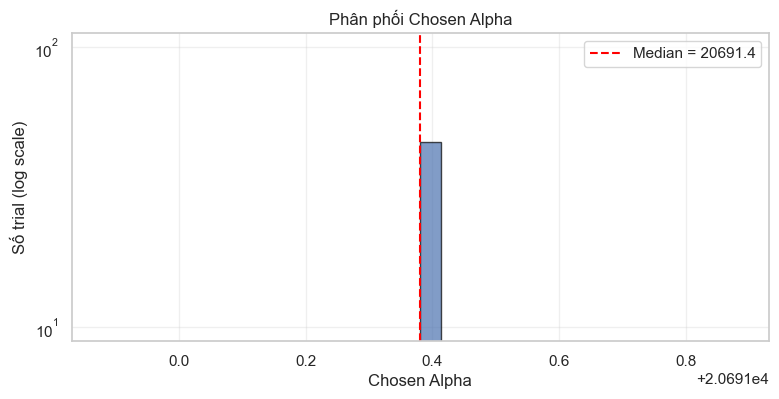

In [307]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Lấy tất cả trial hợp lệ
trials = [t for t in study.trials if t.value is not None and t.value > -900]

alphas = [t.user_attrs.get("chosen_alpha", np.nan) for t in trials]
alphas = [a for a in alphas if not np.isnan(a)]

print("=" * 60)
print("THỐNG KÊ CHOSEN ALPHA")
print("=" * 60)
print(f"Số trial hợp lệ     : {len(alphas)}")
print(f"Alpha trung bình    : {np.mean(alphas):.2f}")
print(f"Alpha trung vị      : {np.median(alphas):.2f}")
print(f"Alpha min – max     : {np.min(alphas):.2f} – {np.max(alphas):.2f}")

# Tỷ lệ theo ngưỡng
thresholds = [10, 50, 100, 300, 1000, 3000, 10000]
print("\nTỷ lệ trial theo ngưỡng alpha:")
for th in thresholds:
    ratio = np.mean(np.array(alphas) >= th)
    print(f"  Alpha ≥ {th:<6} : {ratio:.1%}")

# Phân phối nhanh
print("\nPhân vị Alpha:")
print(pd.Series(alphas).quantile([0.1, 0.25, 0.5, 0.75, 0.9]).round(2))

# (Tuỳ chọn) Vẽ histogram
plt.figure(figsize=(9, 4))
plt.hist(alphas, bins=30, edgecolor="black", alpha=0.7)
plt.axvline(np.median(alphas), color="red", linestyle="--", label=f"Median = {np.median(alphas):.1f}")
plt.yscale("log")
plt.xlabel("Chosen Alpha")
plt.ylabel("Số trial (log scale)")
plt.title("Phân phối Chosen Alpha")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

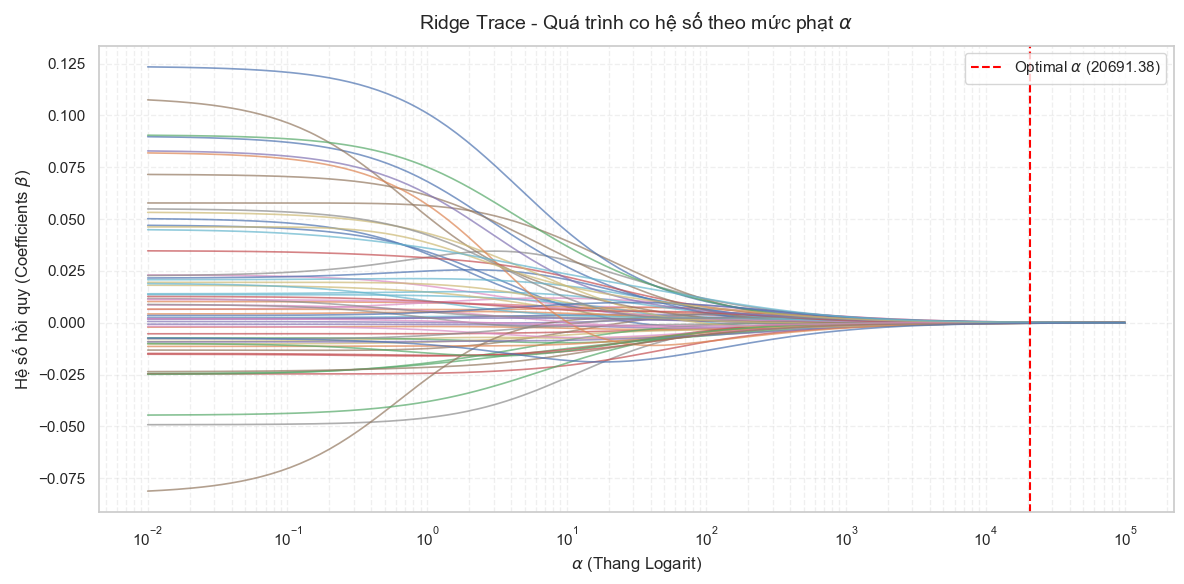

In [308]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge

# 1. Thiết lập dải alpha theo thang logarit
alphas_trace = np.logspace(-2, 5, 200)

# 2. Huấn luyện Ridge trên từng mức alpha và lưu lại hệ số
coefs = []
for a in alphas_trace:
    ridge = Ridge(alpha=a, fit_intercept=True)
    ridge.fit(X_train_scaled, y_train)
    coefs.append(ridge.coef_)

coefs = np.array(coefs)

# 3. Vẽ biểu đồ
plt.figure(figsize=(12, 6))
plt.plot(alphas_trace, coefs, alpha=0.7, linewidth=1.2)

# Đánh dấu alpha tối ưu do RidgeCV tìm được (giả sử là chosen_alpha)
plt.axvline(
    x=best.user_attrs["chosen_alpha"], 
    color='red', 
    linestyle='--', 
    linewidth=1.5, 
    label=f'Optimal $\\alpha$ ({best.user_attrs["chosen_alpha"]:.2f})'
)

plt.xscale('log')
plt.xlabel('$\\alpha$ (Thang Logarit)', fontsize=12)
plt.ylabel('Hệ số hồi quy (Coefficients $\\beta$)', fontsize=12)
plt.title('Ridge Trace - Quá trình co hệ số theo mức phạt $\\alpha$', fontsize=14, pad=12)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

Để alpha ở mức 100 đang khá oke và bắt nhịp

PNJ 
a = 260 | b = 130 | c = 45 | d = 15
ridge_alpha = 20691.3808
LOOKBACK = 1000 | OOS = 60
a = 260 | b = 140 | c = 35 | d = 20
ridge_alpha = 20691.3808
LOOKBACK = 1000 | OOS = 60

BID
a = 190 | b = 50 | c = 25 | d = 20
ridge_alpha = 100.0000
LOOKBACK = 1000 | OOS = 60
-> Tốt hơn
a = 150 | b = 110 | c = 35 | d = 30
ridge_alpha = 7847.5997
LOOKBACK = 1000 | OOS = 60
-> Tệ hơn OOS
a = 140 | b = 200 | c = 35 | d = 40
ridge_alpha = 2976.3514
LOOKBACK = 1000 | OOS = 60
-> Tạm

SSI 
a = 260 | b = 30 | c = 65 | d = 5
ridge_alpha = 1000.0000
LOOKBACK = 1000 | OOS = 60

a = 80 | b = 80 | c = 65 | d = 35
ridge_alpha = 2976.3514
LOOKBACK = 1000 | OOS = 60

In [309]:
def build_features(df_raw, a, b, c, d, investor_groups):
    df = df_vni_raw.copy()

    keep_cols = [
        'open', 'high', 'low', 'close', 'trading_value',
        'foreign_net_val', 'prop_net_val', 'local_ind_net_val', 'local_inst_net_val',
        'foreign_net_vol', 'prop_net_vol', 'local_ind_net_vol', 'local_inst_net_vol',
    ]
    keep_cols = [col for col in keep_cols if col in df.columns]
    df = df[keep_cols]

    df['trading_value'] = df['trading_value'].replace(0, np.nan).interpolate()
    df['close'] = df['close'].ffill()
    df['log_ret'] = np.log(df['close'] / df['close'].shift(1)).fillna(0)
    df['abs_ret'] = df['log_ret'].abs()

    tr = np.maximum(
        df['high'] - df['low'],
        np.maximum(
            (df['high'] - df['close'].shift(1)).abs(),
            (df['low'] - df['close'].shift(1)).abs()
        )
    )
    df['target_ret_t10'] = df['close'].shift(-10) / df['close'] - 1

    for g in investor_groups:
        net_val = df[f'{g}_net_val']
        net_ratio = net_val / df['trading_value']
        df[f'feat_{g}_net_ratio'] = net_ratio.fillna(0)

        prev = net_ratio.shift(1).abs()
        df[f'feat_{g}_price_impact'] = (df['abs_ret'].shift(1) / (prev + 1e-6)).rolling(5).median()

        mu = df[f'feat_{g}_net_ratio'].rolling(a).mean()
        sigma = df[f'feat_{g}_net_ratio'].rolling(a).std()
        df[f'feat_{g}_zscore'] = ((df[f'feat_{g}_net_ratio'] - mu) / (sigma + 1e-8)).clip(-4, 4).fillna(0)

        rmin = net_val.rolling(a).min()
        rmax = net_val.rolling(a).max()
        df[f'feat_{g}_sentiment'] = (2 * (net_val - rmin) / (rmax - rmin + 1e-6) - 1).fillna(0)

    df = df.replace([np.inf, -np.inf], 0).fillna(0)

    # ===================== FEATURE FACTORY =====================
    feature_dict = {}

    delta = df["close"].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / (loss + 1e-8)
    rsi = 100 - (100 / (1 + rs))
    feature_dict["ta_rsi_norm"] = (rsi / 100.0) - 0.5

    ma20 = df["close"].rolling(20).mean()
    feature_dict["ta_dist_ma20"] = (df["close"] - ma20) / ma20

    roll_high = df["high"].rolling(c).max()
    roll_low = df["low"].rolling(c).min()
    feature_dict["ta_pos_in_range"] = (df["close"] - roll_low) / (roll_high - roll_low + 1e-8)

    feature_dict["ta_atr_pct"] = tr.ewm(span=b, adjust=False).mean() / df["close"]

    for g in investor_groups:
        sent = df[f"feat_{g}_sentiment"]
        sent_ewm = sent.ewm(span=b, adjust=False).mean()
        feature_dict[f"feat_{g}_sentiment_ewm"] = sent_ewm

        sent_mean = sent_ewm.rolling(a, min_periods=10).mean()
        sent_std = sent_ewm.rolling(a, min_periods=10).std().replace(0, np.nan)
        sent_z = ((sent_ewm - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

        # feature_dict[f"feat_{g}_sentiment_sq"] = sent_z**2
        feature_dict[f"feat_{g}_sentiment_cubed"] = (sent_z**3 - 3 * sent_z).clip(-10, 10)

        impulse = sent_ewm.diff(d).fillna(0)
        feature_dict[f"feat_{g}_flow_impulse_{d}d"] = impulse

        imp_mean = impulse.rolling(a, min_periods=10).mean()
        imp_std = impulse.rolling(a, min_periods=10).std().replace(0, np.nan)
        imp_z = ((impulse - imp_mean) / (imp_std + 1e-6)).clip(-3, 3).fillna(0)

        # feature_dict[f"feat_{g}_flow_impulse_{d}d_sq"] = imp_z**2
        feature_dict[f"feat_{g}_flow_impulse_{d}d_cubed"] = (imp_z**3 - 3 * imp_z).clip(-10, 10)

        feature_dict[f"feat_{g}_eff_flow"] = sent * df[f"feat_{g}_price_impact"]
        feature_dict[f"feat_{g}_val_share"] = df[f"{g}_net_val"].abs() / df["trading_value"]

        implied = np.where(df[f"{g}_net_vol"] != 0, df[f"{g}_net_val"] / df[f"{g}_net_vol"], 0)
        feature_dict[f"feat_{g}_rel_net_price_ewm"] = (
            pd.Series(implied / df["close"], index=df.index).ewm(span=b, adjust=False).mean()
        )

        feature_dict[f"inter_{g}_sent_x_pos"]    = sent_z * feature_dict["ta_pos_in_range"]
        # feature_dict[f"inter_{g}_sent_x_rsi"]    = sent_z * feature_dict["ta_rsi_norm"]
        feature_dict[f"inter_{g}_sent_x_distma"] = sent_z * feature_dict["ta_dist_ma20"]
        # feature_dict[f"inter_{g}_imp_x_atr"]     = imp_z  * feature_dict["ta_atr_pct"]
        # feature_dict[f"inter_{g}_eff_x_pos"]     = feature_dict[f"feat_{g}_eff_flow"] * feature_dict["ta_pos_in_range"]
        feature_dict[f"inter_{g}_sent_x_atr"]    = sent_z * feature_dict["ta_atr_pct"]
    # ============================================================
    # CROSS-INVESTOR FEATURES (Toàn bộ mối quan hệ)
    # ============================================================
    groups = investor_groups  # ["foreign", "prop", "local_inst", "local_ind"]

    # Lấy các series đã có
    sent_ewm = {g: feature_dict[f"feat_{g}_sentiment_ewm"] for g in groups}
    sent_z   = {}
    for g in groups:
        # tái tạo sent_z nếu cần (hoặc lấy từ biến đã tính trước đó)
        sent = df[f"feat_{g}_sentiment"]
        sent_ewm_g = sent.ewm(span=b, adjust=False).mean()
        sent_mean = sent_ewm_g.rolling(a, min_periods=10).mean()
        sent_std  = sent_ewm_g.rolling(a, min_periods=10).std().replace(0, np.nan)
        sent_z[g] = ((sent_ewm_g - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

    net_ratio = {g: df[f"feat_{g}_net_ratio"] for g in groups}

    # ----------------------------------------------------------
    # 1. Relative Flow (chênh lệch) – tất cả cặp
    # ----------------------------------------------------------
    from itertools import combinations

    for g1, g2 in combinations(groups, 2):
        # Chênh lệch z-score
        feature_dict[f"cross_{g1}_minus_{g2}_sent_z"] = sent_z[g1] - sent_z[g2]


    # ----------------------------------------------------------
    # 2. Agreement / Disagreement
    # ----------------------------------------------------------
    for g1, g2 in combinations(groups, 2):
        # Cùng chiều hay ngược chiều (sign agreement)
        sign_agree = np.sign(sent_ewm[g1]) * np.sign(sent_ewm[g2])
        feature_dict[f"cross_agree_sign_{g1}_{g2}"] = sign_agree
        
        # Strength-weighted agreement (càng lớn càng đồng thuận mạnh)
        feature_dict[f"cross_agree_strength_{g1}_{g2}"] = sent_ewm[g1] * sent_ewm[g2]

    # ----------------------------------------------------------
    # 3. Dispersion (độ phân tán giữa tất cả nhóm)
    # ----------------------------------------------------------
    # Stack tất cả sentiment_ewm
    sent_matrix = pd.concat([sent_ewm[g] for g in groups], axis=1)
    sent_matrix.columns = groups

    feature_dict["cross_dispersion_std"] = sent_matrix.std(axis=1)           # độ lệch chuẩn giữa 4 nhóm
    # feature_dict["cross_dispersion_range"] = sent_matrix.max(axis=1) - sent_matrix.min(axis=1)  # range
    # feature_dict["cross_dispersion_iqr"] = sent_matrix.quantile(0.75, axis=1) - sent_matrix.quantile(0.25, axis=1)
    # ----------------------------------------------------------
    # 4. Dominance Ratio (tỷ trọng dòng tiền)
    # ----------------------------------------------------------
    total_abs_net = sum(df[f"{g}_net_val"].abs() for g in groups) + 1e-8

    for g in groups:
        feature_dict[f"cross_dominance_{g}"] = df[f"{g}_net_val"].abs() / total_abs_net

    # Dominance của nhóm tổ chức vs cá nhân
    inst_abs = df["local_inst_net_val"].abs() + df["foreign_net_val"].abs()
    ind_abs  = df["local_ind_net_val"].abs() + df["prop_net_val"].abs()
    feature_dict["cross_dominance_inst_vs_ind"] = (inst_abs - ind_abs) / (inst_abs + ind_abs + 1e-8)

    # ----------------------------------------------------------
    # 6. Net Pressure & Composite Signals
    # ----------------------------------------------------------
    # Tổng dòng tiền có trọng số (foreign + local_inst mạnh hơn)
    feature_dict["cross_net_pressure_smart"] = (
        1.5 * sent_ewm["foreign"] +
        1.2 * sent_ewm["local_inst"] +
        1.0 * sent_ewm["prop"] +
        0.7 * sent_ewm["local_ind"]
    )

    # Pure institutional pressure
    feature_dict["cross_inst_pressure"] = sent_ewm["foreign"] + sent_ewm["local_inst"]

    # Pure retail pressure
    feature_dict["cross_retail_pressure"] = sent_ewm["prop"] + sent_ewm["local_ind"]

    # Smart vs Retail
    feature_dict["cross_smart_minus_retail"] = (
        feature_dict["cross_inst_pressure"] - feature_dict["cross_retail_pressure"]
    )

    df_feat = pd.DataFrame(feature_dict, index=df.index)

    model_data = pd.concat(
        [df_feat, df[["close", "target_ret_t10"]]],
        axis=1
    )

    model_data = model_data.replace(
        [np.inf, -np.inf], np.nan
    ).dropna()

    feature_cols = [
        col for col in df_feat.columns
        if col != "close"
    ]

    return model_data, feature_cols


BEST PARAMS (Ridge)
a = 230 | b = 400 | c = 55 | d = 25
ridge_alpha = 20691.3808
LOOKBACK = 1000 | OOS = 60
TRAIN: 1000 | OOS: 60 | Số feature: 72

========== TRAIN ==========
IC          : 0.2984
Hit Rate    : 0.5327
Số quan sát : 1000

========== OOS ==========
IC          : 0.2643
Hit Rate    : 0.3333
Signals     : 60
Số quan sát : 60

=== Rank IC (Train+OOS) = 0.2957 ===
                mean    std  count  hit_rate  avg_pred
score_decile                                          
0            -0.0140 0.0467    106    0.2453   -0.0034
1            -0.0035 0.0475    106    0.4245   -0.0014
2            -0.0262 0.0423    106    0.2170   -0.0000
3            -0.0430 0.0941    106    0.3019    0.0011
4            -0.0121 0.0909    106    0.4245    0.0024
5             0.0035 0.0682    106    0.5094    0.0036
6             0.0030 0.0550    106    0.4906    0.0048
7             0.0228 0.0573    106    0.7170    0.0061
8             0.0401 0.0523    106    0.7642    0.0073
9             0.0

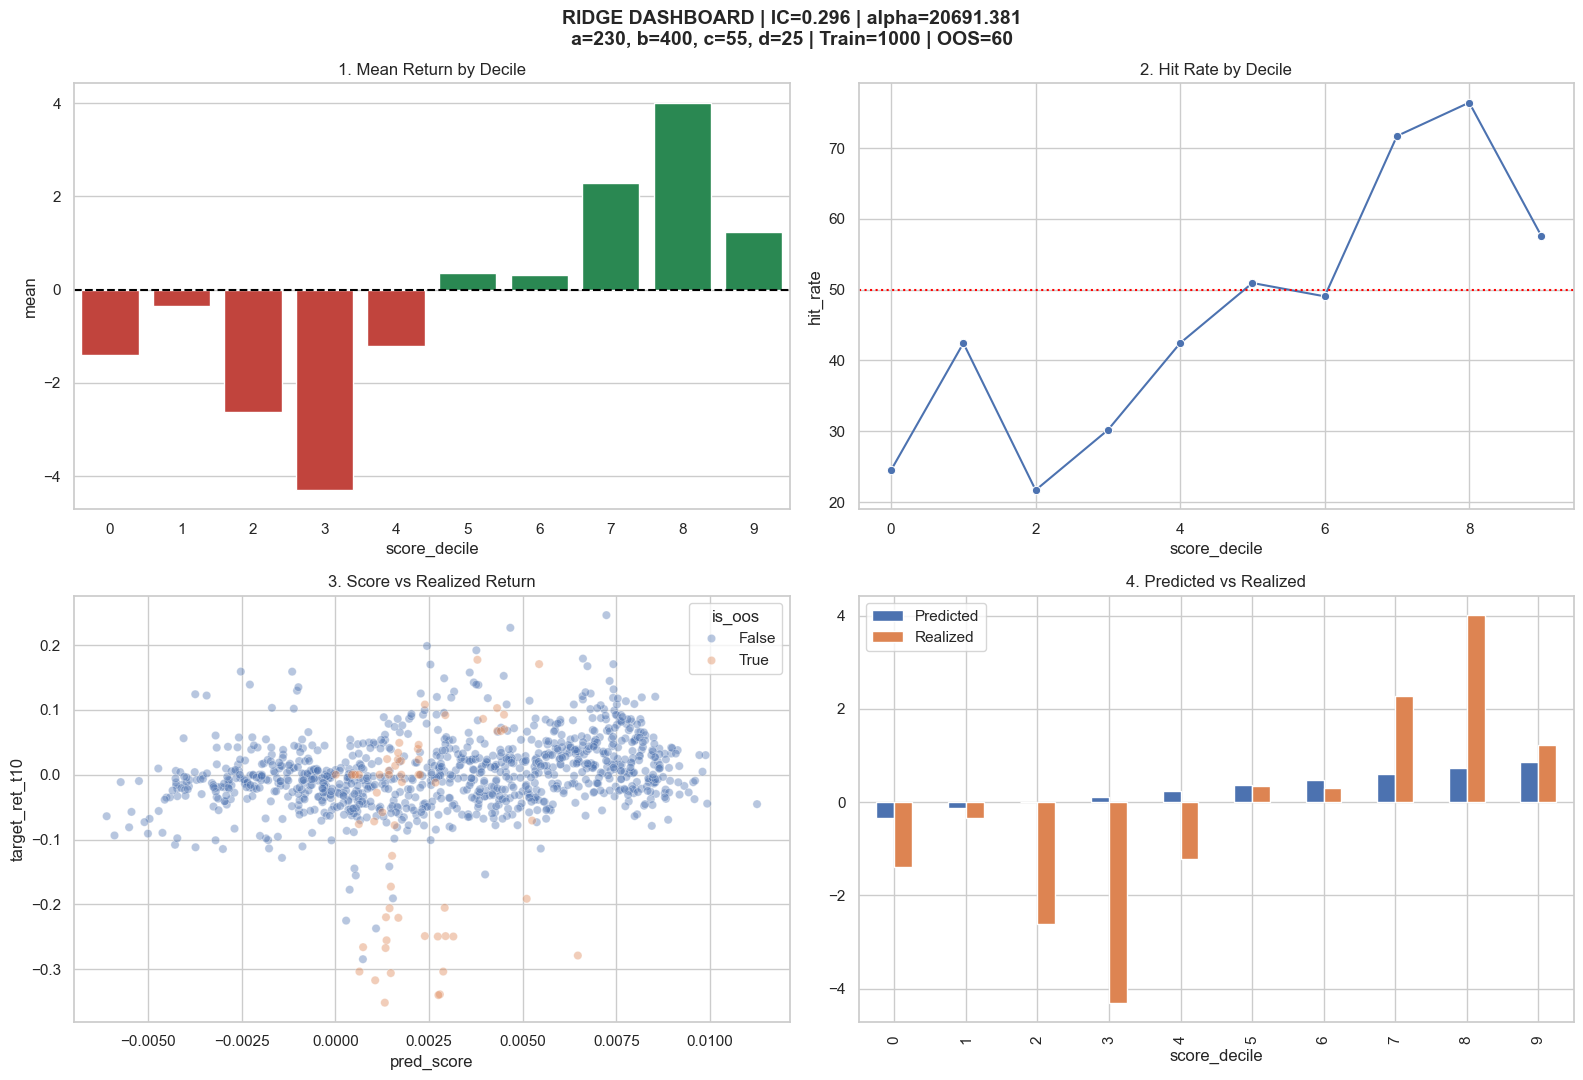

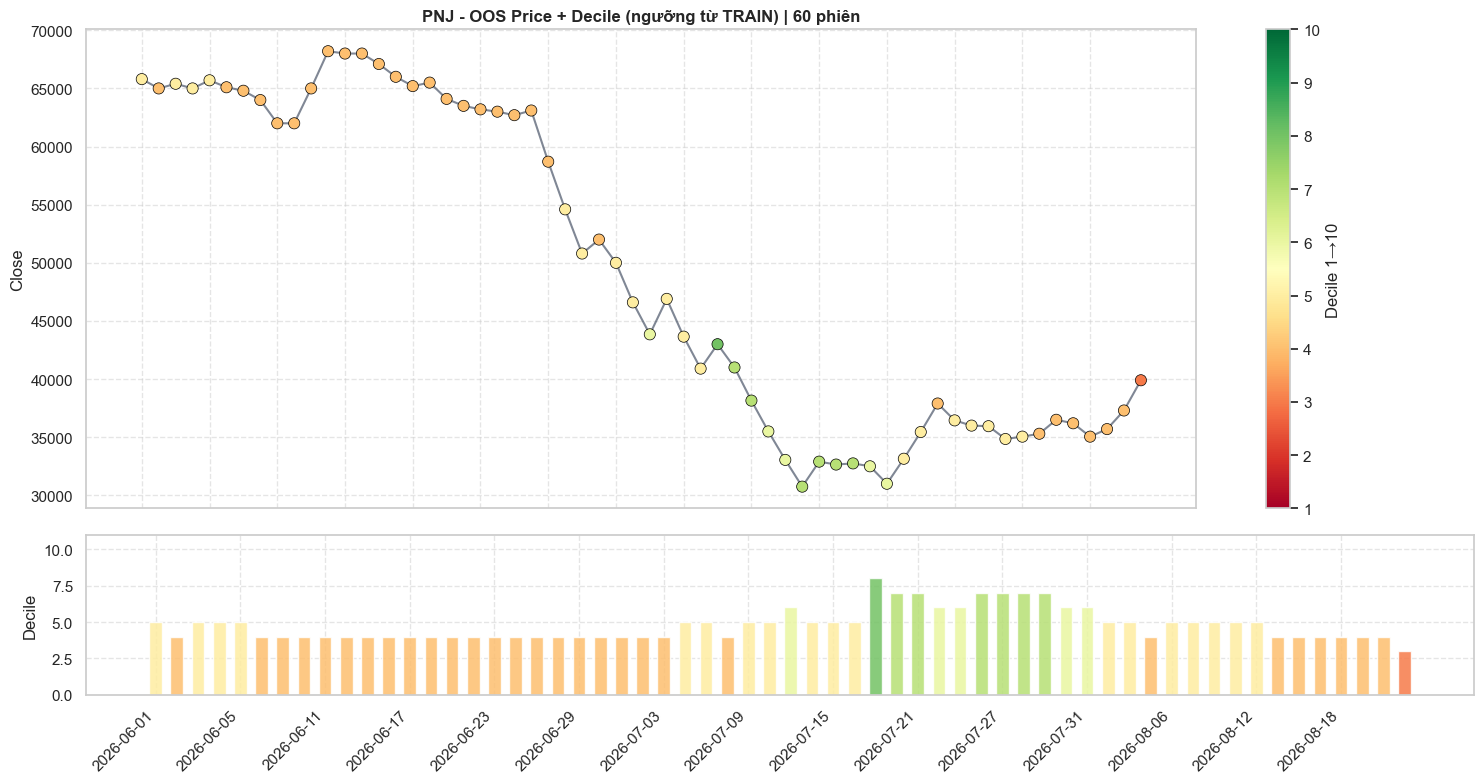

In [310]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# 1. LẤY BEST PARAMS TỪ OPTUNA (Ridge)
# ============================================================
best = study.best_trial

a = best.user_attrs["a"]
b = best.user_attrs["b"]
c = best.user_attrs["c"]
d = best.user_attrs["d"]
alpha = best.user_attrs["chosen_alpha"]
cols_to_exclude = best.user_attrs.get("cols_to_exclude", [])

print("="*70)
print("BEST PARAMS (Ridge)")
print("="*70)
print(f"a = {a} | b = {b} | c = {c} | d = {d}")
print(f"ridge_alpha = {alpha:.4f}")
print(f"LOOKBACK = {LOOKBACK_DAYS} | OOS = {OOS_DAYS}")
print("="*70)

y_col = "target_ret_t10"

# ============================================================
# 3. TẠO DỮ LIỆU + CẮT TRAIN / OOS
# ============================================================
model_data, all_feature_cols = build_features(df_vni_raw, a, b, c, d, investor_groups)

X_cols = [col for col in all_feature_cols if col not in cols_to_exclude]

total_needed = LOOKBACK_DAYS + OOS_DAYS
if len(model_data) >= total_needed:
    train_data = model_data.iloc[-total_needed:-OOS_DAYS].copy()
    oos_data = model_data.iloc[-OOS_DAYS:].copy()
else:
    train_data = model_data.iloc[:-OOS_DAYS].copy() if len(model_data) > OOS_DAYS else model_data.copy()
    oos_data = model_data.iloc[-OOS_DAYS:].copy() if len(model_data) > OOS_DAYS else pd.DataFrame()

print(f"TRAIN: {len(train_data)} | OOS: {len(oos_data)} | Số feature: {len(X_cols)}")


# ============================================================
# 4. FIT RIDGE TRÊN TRAIN
# ============================================================
X_train = train_data[X_cols]
y_train = train_data[y_col]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

model = Ridge(alpha=alpha, random_state=42)
model.fit(X_train_scaled, y_train)

train_data = train_data.copy()
train_data["pred_score"] = model.predict(X_train_scaled)
train_data["actual_ret"] = y_train

ic_train, _ = spearmanr(train_data["pred_score"], train_data["actual_ret"])
hit_train = (train_data.loc[train_data["pred_score"] > 0, "actual_ret"] > 0).mean()

print("\n========== TRAIN ==========")
print(f"IC          : {ic_train:.4f}")
print(f"Hit Rate    : {hit_train:.4f}")
print(f"Số quan sát : {len(train_data)}")


# ============================================================
# 5. ĐÁNH GIÁ OOS
# ============================================================
if len(oos_data) > 0:
    X_oos = oos_data[X_cols]
    X_oos_scaled = scaler.transform(X_oos)

    oos_data = oos_data.copy()
    oos_data["pred_score"] = model.predict(X_oos_scaled)
    oos_data["actual_ret"] = oos_data[y_col]

    ic_oos, _ = spearmanr(oos_data["pred_score"], oos_data["actual_ret"])
    n_sig = int((oos_data["pred_score"] > 0).sum())
    hit_oos = (oos_data.loc[oos_data["pred_score"] > 0, "actual_ret"] > 0).mean() if n_sig > 0 else np.nan

    print("\n========== OOS ==========")
    print(f"IC          : {ic_oos:.4f}")
    print(f"Hit Rate    : {hit_oos:.4f}")
    print(f"Signals     : {n_sig}")
    print(f"Số quan sát : {len(oos_data)}")
else:
    print("\n[OOS] Không đủ dữ liệu")


# ============================================================
# 6. DECILE ANALYSIS (Train + OOS)
# ============================================================
eval_data = pd.concat([
    train_data[["pred_score", y_col]].assign(is_oos=False),
    oos_data[["pred_score", y_col]].assign(is_oos=True) if len(oos_data) > 0 else pd.DataFrame()
], axis=0).dropna()

eval_data["score_decile"] = pd.qcut(eval_data["pred_score"], 10, labels=False, duplicates="drop")

analysis = eval_data.groupby("score_decile")[y_col].agg(["mean", "std", "count"])
analysis["hit_rate"] = eval_data.groupby("score_decile")[y_col].apply(lambda x: (x > 0).mean())
analysis["avg_pred"] = eval_data.groupby("score_decile")["pred_score"].mean()

rank_ic = eval_data["pred_score"].corr(eval_data[y_col], method="spearman")
print(f"\n=== Rank IC (Train+OOS) = {rank_ic:.4f} ===")
print(analysis)


# ============================================================
# 7. DASHBOARD
# ============================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    f"RIDGE DASHBOARD | IC={rank_ic:.3f} | alpha={alpha:.3f}\n"
    f"a={a}, b={b}, c={c}, d={d} | Train={len(train_data)} | OOS={len(oos_data)}",
    fontsize=14, fontweight="bold"
)

colors = ["#d73027" if x < 0 else "#1a9850" for x in analysis["mean"]]
sns.barplot(x=analysis.index, y=analysis["mean"]*100, ax=axes[0,0], palette=colors)
axes[0,0].axhline(0, color="black", ls="--")
axes[0,0].set_title("1. Mean Return by Decile")

sns.lineplot(x=analysis.index, y=analysis["hit_rate"]*100, ax=axes[0,1], marker="o")
axes[0,1].axhline(50, color="red", ls=":")
axes[0,1].set_title("2. Hit Rate by Decile")

sns.scatterplot(data=eval_data, x="pred_score", y=y_col, hue="is_oos", ax=axes[1,0], alpha=0.4)
axes[1,0].set_title("3. Score vs Realized Return")

pd.DataFrame({
    "Predicted": analysis["avg_pred"]*100,
    "Realized": analysis["mean"]*100
}).plot(kind="bar", ax=axes[1,1])
axes[1,1].set_title("4. Predicted vs Realized")

plt.tight_layout()
plt.show()


# ============================================================
# 8. BIỂU ĐỒ GIÁ + DECILE OOS (ngưỡng lấy từ TRAIN)
# ============================================================
if len(oos_data) > 0:
    # Ngưỡng decile từ TRAIN
    train_scores = train_data["pred_score"]
    _, bin_edges = pd.qcut(train_scores, q=10, duplicates="drop", retbins=True)
    bin_edges = bin_edges.copy()
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf
    n_deciles = len(bin_edges) - 1

    oos_data = oos_data.copy()
    oos_data["decile"] = pd.cut(oos_data["pred_score"], bins=bin_edges, labels=False, include_lowest=True) + 1

    # Trục thời gian
    if "time" in df_vni_raw.columns:
        raw_dates = df_vni_raw.loc[oos_data.index, "time"]
    else:
        raw_dates = oos_data.index

    if pd.api.types.is_datetime64_any_dtype(raw_dates):
        x_dates = pd.to_datetime(raw_dates).dt.strftime("%Y-%m-%d").values
    else:
        x_dates = pd.to_datetime(raw_dates).strftime("%Y-%m-%d").values

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True,
                                   gridspec_kw={"height_ratios": [3, 1]})

    ax1.plot(x_dates, oos_data["close"], color="#4A5568", lw=1.5, alpha=0.7, label="Close")
    sc = ax1.scatter(x_dates, oos_data["close"], c=oos_data["decile"],
                     cmap="RdYlGn", vmin=1, vmax=n_deciles, s=65, zorder=5, edgecolors="black", linewidth=0.5)
    ax1.set_title(f"{SYMBOL} - OOS Price + Decile (ngưỡng từ TRAIN) | {len(oos_data)} phiên", fontweight="bold")
    ax1.set_ylabel("Close")
    ax1.grid(True, ls="--", alpha=0.5)
    plt.colorbar(sc, ax=ax1, label=f"Decile 1→{n_deciles}")

    norm = (n_deciles - 1) if n_deciles > 1 else 1
    bar_colors = plt.cm.RdYlGn((oos_data["decile"] - 1) / norm)
    ax2.bar(x_dates, oos_data["decile"], color=bar_colors, alpha=0.85, width=0.6)
    ax2.set_ylabel("Decile")
    ax2.set_ylim(0, n_deciles + 1)
    ax2.grid(True, ls="--", alpha=0.5)
    plt.xticks(rotation=45, ha="right", ticks=range(0, len(x_dates), max(1, len(x_dates)//15)))

    plt.tight_layout()
    plt.show()

# Thử xem Scaler như thế nào

In [3]:
SYMBOL = 'TCB'

# --- BƯỚC 1: CHUẨN BỊ DỮ LIỆU ---
excel_file_path_vni = rf"E:\Document\Tao\FiinGroup\csv_data_2\Kafi_Phân_Loại_Nhà_Đầu_Tư_{SYMBOL}.csv"
excel_file_path_vni_new = rf"E:\Document\Tao\FiinGroup\csv_data_2\Kafi_Giá_{SYMBOL}.csv"
# excel_file_path_vni = rf"E:\Document\Tao\FiinGroup\Kafi_Phân_Loại_Nhà_Đầu_Tư_{SYMBOL}_20260305.xlsx"

investor_groups = ['foreign', 'prop', 'local_ind', 'local_inst']

df_vni_raw = load_and_map_excel(excel_file_path_vni, df_history=None)

## Refactor lại cho đỡ rối - Đã check, không look ahead tí nào luôn yayayayay

In [ ]:
# ============================================================
# 4. HÀM ĐÁNH GIÁ (RidgeCV + Score đơn điệu)
# ============================================================
# def evaluate_params_ridge(
#     a, b, c, d,
#     df_raw,
#     investor_groups,
#     lookback_days=LOOKBACK_DAYS,
#     oos_days=OOS_DAYS,
# ):
#     try:
#         # ----- Feature + Target -----
#         df_feat = build_features(df_raw, investor_groups, a, b, c, d)
#         target = df_raw["close"].ffill().shift(-10) / df_raw["close"].ffill() - 1
#         target.name = "target_ret_t10"

#         model_data = pd.concat([df_feat, target], axis=1)
#         model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()

#         if len(model_data) < (lookback_days + oos_days + 50):
#             return (-999.0,) * 12

#         train_data = model_data.iloc[-(lookback_days + oos_days) : -oos_days].copy()
#         oos_data = model_data.iloc[-oos_days:].copy()

#         if len(train_data) < 300 or len(oos_data) < 10:
#             return (-999.0,) * 12

#         X_train = train_data.drop(columns=["target_ret_t10"]).values
#         y_train = train_data["target_ret_t10"].values
#         X_oos = oos_data.drop(columns=["target_ret_t10"]).values
#         y_oos = oos_data["target_ret_t10"].values

#         # ----- Scale -----
#         scaler = RobustScaler()
#         X_train_scaled = scaler.fit_transform(X_train)
#         X_oos_scaled = scaler.transform(X_oos)

#         # ----- Sample weight (time decay) -----
#         half_life = 252
#         decay = np.log(2) / half_life
#         t = np.arange(len(y_train))
#         sample_weights = np.exp(decay * (t - (len(y_train) - 1)))

#         # ----- Model -----
#         tscv = TimeSeriesSplit(n_splits=3)
#         model = RidgeCV(alphas=ALPHAS, cv=tscv, scoring="neg_mean_squared_error")
#         model.fit(X_train_scaled, y_train, sample_weight=sample_weights)

#         chosen_alpha = float(model.alpha_)
#         pred_train = model.predict(X_train_scaled)
#         pred_oos = model.predict(X_oos_scaled)

#         # ----- Metrics Train -----
#         train_ic, _ = spearmanr(pred_train, y_train)
#         if np.isnan(train_ic):
#             train_ic = -1.0

#         mask_up_train = pred_train > 0
#         n_signals_train = int(mask_up_train.sum())

#         if n_signals_train >= MIN_SIGNALS_TRAIN_HARD:
#             hit_rate_train = float((y_train[mask_up_train] > 0).mean())
#             avg_ret_train = float(y_train[mask_up_train].mean())
#         else:
#             hit_rate_train = 0.50
#             avg_ret_train = 0.0

#         # ----- Decile Analysis (Train) -----
#         try:
#             deciles = pd.qcut(pred_train, 10, labels=False, duplicates="drop")
#         except Exception:
#             return (-999.0,) * 12

#         df_dec = pd.DataFrame({"pred": pred_train, "y": y_train, "decile": deciles})
#         decile_stats = (
#             df_dec.groupby("decile")["y"]
#             .agg(mean_ret="mean", hit_rate=lambda x: (x > 0).mean(), count="count")
#             .reindex(range(10))
#         )

#         top_stats = decile_stats.loc[[8, 9]].dropna()
#         bot_stats = decile_stats.loc[[0, 1]].dropna()

#         if len(top_stats) < 1 or len(bot_stats) < 1:
#             return (-999.0,) * 12

#         top_hit = float(top_stats["hit_rate"].mean())
#         bot_hit = float(bot_stats["hit_rate"].mean())
#         top_mean = float(top_stats["mean_ret"].mean())
#         bot_mean = float(bot_stats["mean_ret"].mean())

#         valid = decile_stats.dropna()
#         if len(valid) >= 5:
#             mono_score = spearmanr(valid.index, valid["mean_ret"])[0]
#             mono_score = 0.0 if np.isnan(mono_score) else float(mono_score)
#         else:
#             mono_score = 0.0

#         # ----- Metrics OOS (giám sát) -----
#         oos_ic, _ = spearmanr(pred_oos, y_oos)
#         if np.isnan(oos_ic):
#             oos_ic = -1.0

#         mask_up_oos = pred_oos > 0
#         n_signals_oos = int(mask_up_oos.sum())
#         hit_rate_oos = float((y_oos[mask_up_oos] > 0).mean()) if n_signals_oos >= 3 else 0.50
#         avg_ret_oos = float(y_oos[mask_up_oos].mean()) if n_signals_oos >= 3 else 0.0

#         train_oos_gap = train_ic - oos_ic

#         # ----- SCORE -----
#         hit_term = (hit_rate_train - 0.50) * 2.0
#         ic_term = np.clip(train_ic, -0.15, 0.60)
#         top_term = np.clip((top_hit - 0.50) / 0.40, 0, 1.5)
#         bot_term = np.clip((0.50 - bot_hit) / 0.40, 0, 1.5)
#         mono_term = np.clip(mono_score, 0, 1.0)

#         score = (
#             W_HIT * hit_term
#             + W_IC * ic_term
#             + W_TOP * top_term
#             + W_BOT * bot_term
#             + 0.05 * mono_term
#         )

#         if top_mean > 0:
#             score += 0.02 * np.clip(top_mean * 10, 0, 0.3)
#         if bot_mean < 0:
#             score += 0.02 * np.clip(-bot_mean * 10, 0, 0.3)

#         # Soft penalty
#         if n_signals_train < MIN_SIGNALS_TRAIN_SOFT:
#             score *= 0.75
#         if hit_rate_train < MIN_HIT_TRAIN_SOFT:
#             score *= 0.80
#         if top_hit < 0.75:
#             score *= 0.70
#         if bot_hit > 0.25:
#             score *= 0.75

#         # Hard filter
#         if (
#             n_signals_train < MIN_SIGNALS_TRAIN_HARD
#             or hit_rate_train < MIN_HIT_TRAIN_HARD
#             or train_ic < MIN_IC_TRAIN_HARD
#             or top_hit < 0.65
#             or bot_hit > 0.35
#         ):
#             score = -999.0

#         return (
#             float(score),
#             float(oos_ic),
#             float(hit_rate_oos),
#             float(avg_ret_oos),
#             n_signals_oos,
#             float(chosen_alpha),
#             float(train_ic),
#             float(hit_rate_train),
#             float(train_oos_gap),
#             float(top_hit),
#             float(bot_hit),
#             float(mono_score),
#         )

#     except Exception as e:
#         print(f"[EXCEPTION] a={a}, b={b}, c={c}, d={d} → {type(e).__name__}: {e}")
#         return (-999.0,) * 12

In [ ]:
# ============================================================
# 1. IMPORTS
# ============================================================
import os
import warnings
import numpy as np
import pandas as pd
import optuna
from itertools import combinations
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import TimeSeriesSplit
from scipy.stats import spearmanr
from sklearn.metrics import make_scorer

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ============================================================
# 2. CẤU HÌNH CHUNG
# ============================================================
DATA_DIR = r"E:\Document\Tao\FiinGroup\csv_data_2"
RESULT_PATH = r"E:\Document\Tao\FiinGroup\optuna_results_all_symbols.csv"

LOOKBACK_DAYS = 1000
OOS_DAYS = 60
TRIALS = 300

# Window parameters
A_MIN, A_MAX = 50, 300
B_MIN, B_MAX = 50, 200
C_MIN, C_MAX = 10, 60
D_MIN, D_MAX = 10, 50

ALPHAS = np.logspace(-1, 3.5, 15)          # 10 → 1000

# Trọng số Score
W_HIT = 0.50
W_IC  = 0.50
W_TOP = 0.30
W_BOT = 0.30

# Ngưỡng mong muốn
TOP_HIT_TARGET = 0.8
BOT_HIT_TARGET = 0.2

# Ngưỡng Train
MIN_SIGNALS_TRAIN_SOFT = 30
MIN_SIGNALS_TRAIN_HARD = 15
MIN_HIT_TRAIN_SOFT = 0.55
MIN_HIT_TRAIN_HARD = 0.52
MIN_IC_TRAIN_HARD = 0.02

investor_groups = ["foreign", "prop", "local_inst", "local_ind"]

# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================
def build_features(df_raw, investor_groups, a, b, c, d):
    df = df_raw.copy()

    keep_cols = [
        "open", "high", "low", "close", "trading_value",
        "foreign_net_val", "prop_net_val", "local_ind_net_val", "local_inst_net_val",
        "foreign_net_vol", "prop_net_vol", "local_ind_net_vol", "local_inst_net_vol",
    ]
    keep_cols = [col for col in keep_cols if col in df.columns]
    df = df[keep_cols]

    df["trading_value"] = df["trading_value"].replace(0, np.nan).ffill()
    df["close"] = df["close"].ffill()
    df["log_ret"] = np.log(df["close"] / df["close"].shift(1)).fillna(0)
    df["abs_ret"] = df["log_ret"].abs()

    tr = np.maximum(
        df["high"] - df["low"],
        np.maximum(
            (df["high"] - df["close"].shift(1)).abs(),
            (df["low"] - df["close"].shift(1)).abs(),
        ),
    )

    # ----- Flow cơ bản -----
    for g in investor_groups:
        net_val = df[f"{g}_net_val"]
        net_ratio = net_val / df["trading_value"]
        df[f"feat_{g}_net_ratio"] = net_ratio.fillna(0)

        prev = net_ratio.shift(1).abs()
        df[f"feat_{g}_price_impact"] = (
            df["abs_ret"].shift(1) / (prev + 1e-6)
        ).rolling(5).median()

        mu = df[f"feat_{g}_net_ratio"].rolling(a).mean()
        sigma = df[f"feat_{g}_net_ratio"].rolling(a).std()
        df[f"feat_{g}_zscore"] = (
            (df[f"feat_{g}_net_ratio"] - mu) / (sigma + 1e-8)
        ).clip(-4, 4).fillna(0)

        rmin = net_val.rolling(a).min()
        rmax = net_val.rolling(a).max()
        df[f"feat_{g}_sentiment"] = (
            2 * (net_val - rmin) / (rmax - rmin + 1e-6) - 1
        ).fillna(0)

    df = df.replace([np.inf, -np.inf], 0).fillna(0)

    feature_dict = {}

    # ----- Technical (chỉ dùng cho interaction) -----
    delta = df["close"].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / (loss + 1e-8)
    rsi = 100 - (100 / (1 + rs))
    feature_dict["ta_rsi_norm"] = (rsi / 100.0) - 0.5

    ma50 = df["close"].rolling(50).mean()
    feature_dict["ta_dist_ma50"] = (df["close"] - ma50) / (ma50 + 1e-8)

    roll_high = df["high"].rolling(c).max()
    roll_low = df["low"].rolling(c).min()
    feature_dict["ta_pos_in_range"] = (df["close"] - roll_low) / (roll_high - roll_low + 1e-8)

    feature_dict["ta_atr_pct"] = tr.ewm(span=b, adjust=False).mean() / df["close"]

    # ----- Flow features + Interaction -----
    for g in investor_groups:
        sent = df[f"feat_{g}_sentiment"]
        sent_ewm = sent.ewm(span=b, adjust=False).mean()
        feature_dict[f"feat_{g}_sentiment_ewm"] = sent_ewm

        sent_mean = sent_ewm.rolling(a, min_periods=10).mean()
        sent_std = sent_ewm.rolling(a, min_periods=10).std().replace(0, np.nan)
        sent_z = ((sent_ewm - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

        feature_dict[f"feat_{g}_sentiment_cubed"] = (sent_z**3 - 3 * sent_z).clip(-10, 10)

        impulse = sent_ewm.diff(d).fillna(0)
        feature_dict[f"feat_{g}_flow_impulse_{d}d"] = impulse

        imp_mean = impulse.rolling(a, min_periods=10).mean()
        imp_std = impulse.rolling(a, min_periods=10).std().replace(0, np.nan)
        imp_z = ((impulse - imp_mean) / (imp_std + 1e-6)).clip(-3, 3).fillna(0)

        feature_dict[f"feat_{g}_flow_impulse_{d}d_cubed"] = (imp_z**3 - 3 * imp_z).clip(-10, 10)

        feature_dict[f"feat_{g}_eff_flow"] = sent * df[f"feat_{g}_price_impact"]
        feature_dict[f"feat_{g}_val_share"] = df[f"{g}_net_val"].abs() / df["trading_value"]

        implied = np.where(df[f"{g}_net_vol"] != 0, df[f"{g}_net_val"] / df[f"{g}_net_vol"], 0)
        feature_dict[f"feat_{g}_rel_net_price_ewm"] = (
            pd.Series(implied / df["close"], index=df.index).ewm(span=b, adjust=False).mean()
        )

        # Interaction
        # feature_dict[f"inter_{g}_sent_x_pos"] = sent_z * feature_dict["ta_pos_in_range"]
        feature_dict[f"inter_{g}_sent_x_distma"] = sent_z * feature_dict["ta_dist_ma50"]
        feature_dict[f"inter_{g}_sent_x_atr"] = sent_z * feature_dict["ta_atr_pct"]
        # feature_dict[f"inter_{g}_eff_x_pos"] = feature_dict[f"feat_{g}_eff_flow"] * feature_dict["ta_pos_in_range"]

    # ----- Cross-investor -----
    groups = investor_groups
    sent_ewm = {g: feature_dict[f"feat_{g}_sentiment_ewm"] for g in groups}
    sent_z = {}
    for g in groups:
        sent = df[f"feat_{g}_sentiment"]
        sent_ewm_g = sent.ewm(span=b, adjust=False).mean()
        mu = sent_ewm_g.rolling(a, min_periods=10).mean()
        sigma = sent_ewm_g.rolling(a, min_periods=10).std().replace(0, np.nan)
        sent_z[g] = ((sent_ewm_g - mu) / (sigma + 1e-6)).clip(-3, 3).fillna(0)

    net_ratio = {g: df[f"feat_{g}_net_ratio"] for g in groups}

    for g1, g2 in combinations(groups, 2):
        feature_dict[f"cross_{g1}_minus_{g2}_sent"] = sent_ewm[g1] - sent_ewm[g2]
        feature_dict[f"cross_{g1}_minus_{g2}_sent_z"] = sent_z[g1] - sent_z[g2]
        feature_dict[f"cross_{g1}_minus_{g2}_net"] = net_ratio[g1] - net_ratio[g2]
        feature_dict[f"cross_agree_sign_{g1}_{g2}"] = np.sign(sent_ewm[g1]) * np.sign(sent_ewm[g2])
        feature_dict[f"cross_agree_strength_{g1}_{g2}"] = sent_ewm[g1] * sent_ewm[g2]

    sent_matrix = pd.concat([sent_ewm[g] for g in groups], axis=1)
    feature_dict["cross_dispersion_std"] = sent_matrix.std(axis=1)
    feature_dict["cross_dispersion_range"] = sent_matrix.max(axis=1) - sent_matrix.min(axis=1)
    feature_dict["cross_dispersion_iqr"] = (
        sent_matrix.quantile(0.75, axis=1) - sent_matrix.quantile(0.25, axis=1)
    )

    total_abs_net = sum(df[f"{g}_net_val"].abs() for g in groups) + 1e-8
    for g in groups:
        feature_dict[f"cross_dominance_{g}"] = df[f"{g}_net_val"].abs() / total_abs_net

    return pd.DataFrame(feature_dict, index=df.index)

# ============================================================
# HÀM ĐÁNH GIÁ
# ============================================================
def evaluate_params_ridge(
    a, b, c, d, alpha,
    df_raw,
    investor_groups,
    lookback_days=LOOKBACK_DAYS,
    oos_days=OOS_DAYS,
):
    try:
        # ----- Feature + Target -----
        df_feat = build_features(df_raw, investor_groups, a, b, c, d)
        target = df_raw["close"].ffill().shift(-10) / df_raw["close"].ffill() - 1
        target.name = "target_ret_t10"

        model_data = pd.concat([df_feat, target], axis=1)
        model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()

        if len(model_data) < (lookback_days + oos_days + 50):
            return (-999.0,) * 12

        train_data = model_data.iloc[-(lookback_days + oos_days) : -oos_days].copy()
        oos_data = model_data.iloc[-oos_days:].copy()

        if len(train_data) < 300 or len(oos_data) < 10:
            return (-999.0,) * 12

        X_train = train_data.drop(columns=["target_ret_t10"]).values
        y_train = train_data["target_ret_t10"].values
        X_oos = oos_data.drop(columns=["target_ret_t10"]).values
        y_oos = oos_data["target_ret_t10"].values

        # ----- Scale -----
        scaler = RobustScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_oos_scaled = scaler.transform(X_oos)

        # ----- Sample weight -----
        half_life = 252
        decay = np.log(2) / half_life
        t = np.arange(len(y_train))
        sample_weights = np.exp(decay * (t - (len(y_train) - 1)))

        from sklearn.linear_model import Ridge
        from sklearn.model_selection import TimeSeriesSplit

        # ============================================================
        # INTERNAL TIME-SERIES CV
        # ============================================================
        tscv = TimeSeriesSplit(n_splits=3)
        ic_list = []
        dir_list = []

        for train_idx, val_idx in tscv.split(X_train_scaled):
            X_tr = X_train_scaled[train_idx]
            X_val = X_train_scaled[val_idx]
            y_tr = y_train[train_idx]
            y_val = y_train[val_idx]
            sw = sample_weights[train_idx]

            model_fold = Ridge(alpha=alpha, fit_intercept=True)
            model_fold.fit(X_tr, y_tr, sample_weight=sw)
            pred_val = model_fold.predict(X_val)

            # Spearman IC
            ic_val, _ = spearmanr(pred_val, y_val)
            if np.isnan(ic_val):
                ic_val = -1.0
            ic_list.append(ic_val)

            # Hit Rate Up & Down
            mask_up = pred_val > 0
            mask_dn = pred_val < 0

            hit_up = (y_val[mask_up] > 0).mean() if mask_up.sum() >= 8 else 0.50
            hit_dn = (y_val[mask_dn] < 0).mean() if mask_dn.sum() >= 8 else 0.50

            dir_score = 0.5 * (hit_up - 0.50) * 2.0 + 0.5 * (hit_dn - 0.50) * 2.0
            dir_list.append(dir_score)

        ic_list = np.array(ic_list)
        dir_list = np.array(dir_list)

        # ----- Score chính (dùng trọng số) -----
        if len(ic_list) > 0:
            median_ic = float(np.median(ic_list))
            std_ic = float(np.std(ic_list))
            mean_dir = float(np.mean(dir_list))

            ic_term = median_ic - 1.5 * std_ic
            hit_term = mean_dir

            score = W_IC * ic_term + W_HIT * hit_term
        else:
            score = -999.0

        # ============================================================
        # Refit trên toàn bộ Train (metrics theo dõi)
        # ============================================================
        model = Ridge(alpha=alpha, fit_intercept=True)
        model.fit(X_train_scaled, y_train, sample_weight=sample_weights)

        pred_train = model.predict(X_train_scaled)
        pred_oos = model.predict(X_oos_scaled)

        # Metrics Train
        train_ic, _ = spearmanr(pred_train, y_train)
        if np.isnan(train_ic):
            train_ic = -1.0

        mask_up_train = pred_train > 0
        n_signals_train = int(mask_up_train.sum())
        hit_rate_train = (
            float((y_train[mask_up_train] > 0).mean())
            if n_signals_train >= 5 else 0.50
        )

        # Decile metrics
        try:
            deciles = pd.qcut(pred_train, 10, labels=False, duplicates="drop")
            df_dec = pd.DataFrame({"pred": pred_train, "y": y_train, "decile": deciles})
            decile_stats = (
                df_dec.groupby("decile")["y"]
                .agg(mean_ret="mean", hit_rate=lambda x: (x > 0).mean())
                .reindex(range(10))
            )
            top_hit = float(decile_stats.loc[[8, 9], "hit_rate"].mean())
            bot_hit = float(decile_stats.loc[[0, 1], "hit_rate"].mean())

            valid = decile_stats.dropna()
            if len(valid) >= 5:
                mono_score = spearmanr(valid.index, valid["mean_ret"])[0]
                mono_score = 0.0 if np.isnan(mono_score) else float(mono_score)
            else:
                mono_score = 0.0
        except Exception:
            top_hit = bot_hit = mono_score = 0.0

        # Metrics OOS (chỉ giám sát)
        oos_ic, _ = spearmanr(pred_oos, y_oos)
        if np.isnan(oos_ic):
            oos_ic = -1.0

        mask_up_oos = pred_oos > 0
        n_signals_oos = int(mask_up_oos.sum())
        hit_rate_oos = (
            float((y_oos[mask_up_oos] > 0).mean())
            if n_signals_oos >= 3 else 0.50
        )
        avg_ret_oos = (
            float(y_oos[mask_up_oos].mean())
            if n_signals_oos >= 3 else 0.0
        )

        train_oos_gap = train_ic - oos_ic

        # ----- Soft penalty nhẹ (dùng ngưỡng) -----
        if n_signals_train < MIN_SIGNALS_TRAIN_SOFT:
            score *= 0.90
        if hit_rate_train < MIN_HIT_TRAIN_SOFT:
            score *= 0.90
        if top_hit < TOP_HIT_TARGET - 0.10:
            score *= 0.92
        if bot_hit > BOT_HIT_TARGET + 0.10:
            score *= 0.92

        # Hard filter (chỉ loại case quá tệ)
        if (
            n_signals_train < MIN_SIGNALS_TRAIN_HARD
            or hit_rate_train < MIN_HIT_TRAIN_HARD
            or train_ic < MIN_IC_TRAIN_HARD
        ):
            score = -999.0

        return (
            float(score),
            float(oos_ic),
            float(hit_rate_oos),
            float(avg_ret_oos),
            n_signals_oos,
            float(alpha),
            float(train_ic),
            float(hit_rate_train),
            float(train_oos_gap),
            float(top_hit),
            float(bot_hit),
            float(mono_score),
        )

    except Exception as e:
        print(f"[EXCEPTION] a={a}, b={b}, c={c}, d={d}, alpha={alpha} → {type(e).__name__}: {e}")
        return (-999.0,) * 12
# ============================================================
# 5. OBJECTIVE
# ============================================================
def objective(trial):
    a = trial.suggest_int("window_z", A_MIN, A_MAX, step=10)
    b = trial.suggest_int("window_div", B_MIN, B_MAX, step=10)
    c = trial.suggest_int("pos_range", C_MIN, C_MAX, step=10)
    d = trial.suggest_int("impulse_days", D_MIN, D_MAX, step=5)
    alpha = trial.suggest_float("alpha", 100, 10000, log=True)   # ← quan trọng

    result = evaluate_params_ridge(
        a, b, c, d, alpha,
        df_vni_raw,
        investor_groups,
        lookback_days=LOOKBACK_DAYS,
        oos_days=OOS_DAYS,
    )

    (
        score, oos_ic, hit_up, avg_ret, n_sig, chosen_alpha,
        train_ic, hit_train, gap, top_hit, bot_hit, mono
    ) = result

    trial.set_user_attr("ic", oos_ic)
    trial.set_user_attr("hit_rate_up", hit_up)
    trial.set_user_attr("avg_ret_when_up", avg_ret)
    trial.set_user_attr("n_signals", n_sig)
    trial.set_user_attr("chosen_alpha", chosen_alpha)
    trial.set_user_attr("train_ic", train_ic)
    trial.set_user_attr("hit_rate_train", hit_train)
    trial.set_user_attr("train_oos_gap", gap)
    trial.set_user_attr("top_hit", top_hit)
    trial.set_user_attr("bot_hit", bot_hit)
    trial.set_user_attr("mono_score", mono)
    trial.set_user_attr("a", a)
    trial.set_user_attr("b", b)
    trial.set_user_attr("c", c)
    trial.set_user_attr("d", d)
    trial.set_user_attr("alpha", alpha)

    return score

# ============================================================
# 6. CHẠY OPTUNA
# ============================================================
if __name__ == "__main__":
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=20),
    )
    study.optimize(objective, n_trials=TRIALS, show_progress_bar=True)

    best = study.best_trial
    print("\n" + "=" * 70)
    print("BEST TRIAL – Ridge + Decile Monotonicity")
    print("=" * 70)
    print(f"Score              : {best.value:.4f}")
    print(f"Train IC           : {best.user_attrs['train_ic']:.4f}")
    print(f"Train Hit Rate     : {best.user_attrs['hit_rate_train']:.4f}")
    print(f"Top-2 Decile Hit   : {best.user_attrs.get('top_hit', np.nan):.4f}")
    print(f"Bottom-2 Decile Hit: {best.user_attrs.get('bot_hit', np.nan):.4f}")
    print(f"Mono Score         : {best.user_attrs.get('mono_score', np.nan):.4f}")
    print(f"Train-OOS Gap      : {best.user_attrs['train_oos_gap']:.4f}")
    print(f"OOS IC             : {best.user_attrs['ic']:.4f}")
    print(f"Hit Rate OOS       : {best.user_attrs['hit_rate_up']:.4f}")
    print(f"n_signals OOS      : {best.user_attrs['n_signals']}")
    print(f"Chosen Alpha       : {best.user_attrs['chosen_alpha']:.4f}")
    print(
        f"\nParams: a={best.user_attrs['a']}, b={best.user_attrs['b']}, "
        f"c={best.user_attrs['c']}, d={best.user_attrs['d']}, "
        f"alpha={best.user_attrs['alpha']:.4f}"
    )

  0%|          | 0/300 [00:00<?, ?it/s]


BEST TRIAL – Ridge + Decile Monotonicity
Score              : 0.9783
Train IC           : 0.5347
Train Hit Rate     : 0.6914
Top-2 Decile Hit   : 0.8400
Bottom-2 Decile Hit: 0.2300
Mono Score         : 1.0000
Train-OOS Gap      : -0.0461
OOS IC             : 0.5808
Hit Rate OOS       : 0.6061
n_signals OOS      : 33
Chosen Alpha       : 78.1371

Params: a=230, b=100, c=60, d=25, alpha=114.1520


Note, Với PNJ thì có thể alpha cần cao, chứ với Vic thì alpha cần thấp

Nói chung là kết quả vẫn rất random. Cần phát triển thêm thay vì dừng lại ở Scaler và ridge vì alpha đang chọn khá random

BEST PARAMS FROM OPTUNA
a=230, b=100, c=60, d=25
Alpha (từ Optuna): 114.1520
Train IC: 0.5347 | Top Hit: 0.8400 | Bot Hit: 0.2300 | Mono: 1.0000
Số feature: 77 | Tổng quan sát hợp lệ: 1800
TRAIN: 1000 | OOS: 60

Sử dụng alpha = 114.1520 (do Optuna chọn)

TRAIN -> IC: 0.5338 | Hit Rate: 0.6891 | Signals: 595
OOS   -> IC: nan | Hit Rate: 0.7000 | Signals: 20

ĐÁNH GIÁ TÍNH ĐƠN ĐIỆU CỦA DECILE
1. Spearman Monotonicity IC : 1.0000 (p=0.0000)
2. Kendall's Tau            : 1.0000
3. Monotonic Step Ratio     : 100.0% (9/9 bước tăng)
4. Long-Short Spread (D9-D0): 14.44%

--- Chi tiết từng Decile ---
              Realized_Ret_Mean  Hit_Rate  Pred_Score_Mean
score_decile                                              
0                     -0.053862  0.123810        -0.034949
1                     -0.031148  0.295238        -0.020228
2                     -0.010852  0.438095        -0.011879
3                     -0.003843  0.466667        -0.004832
4                      0.006006  0.561905      

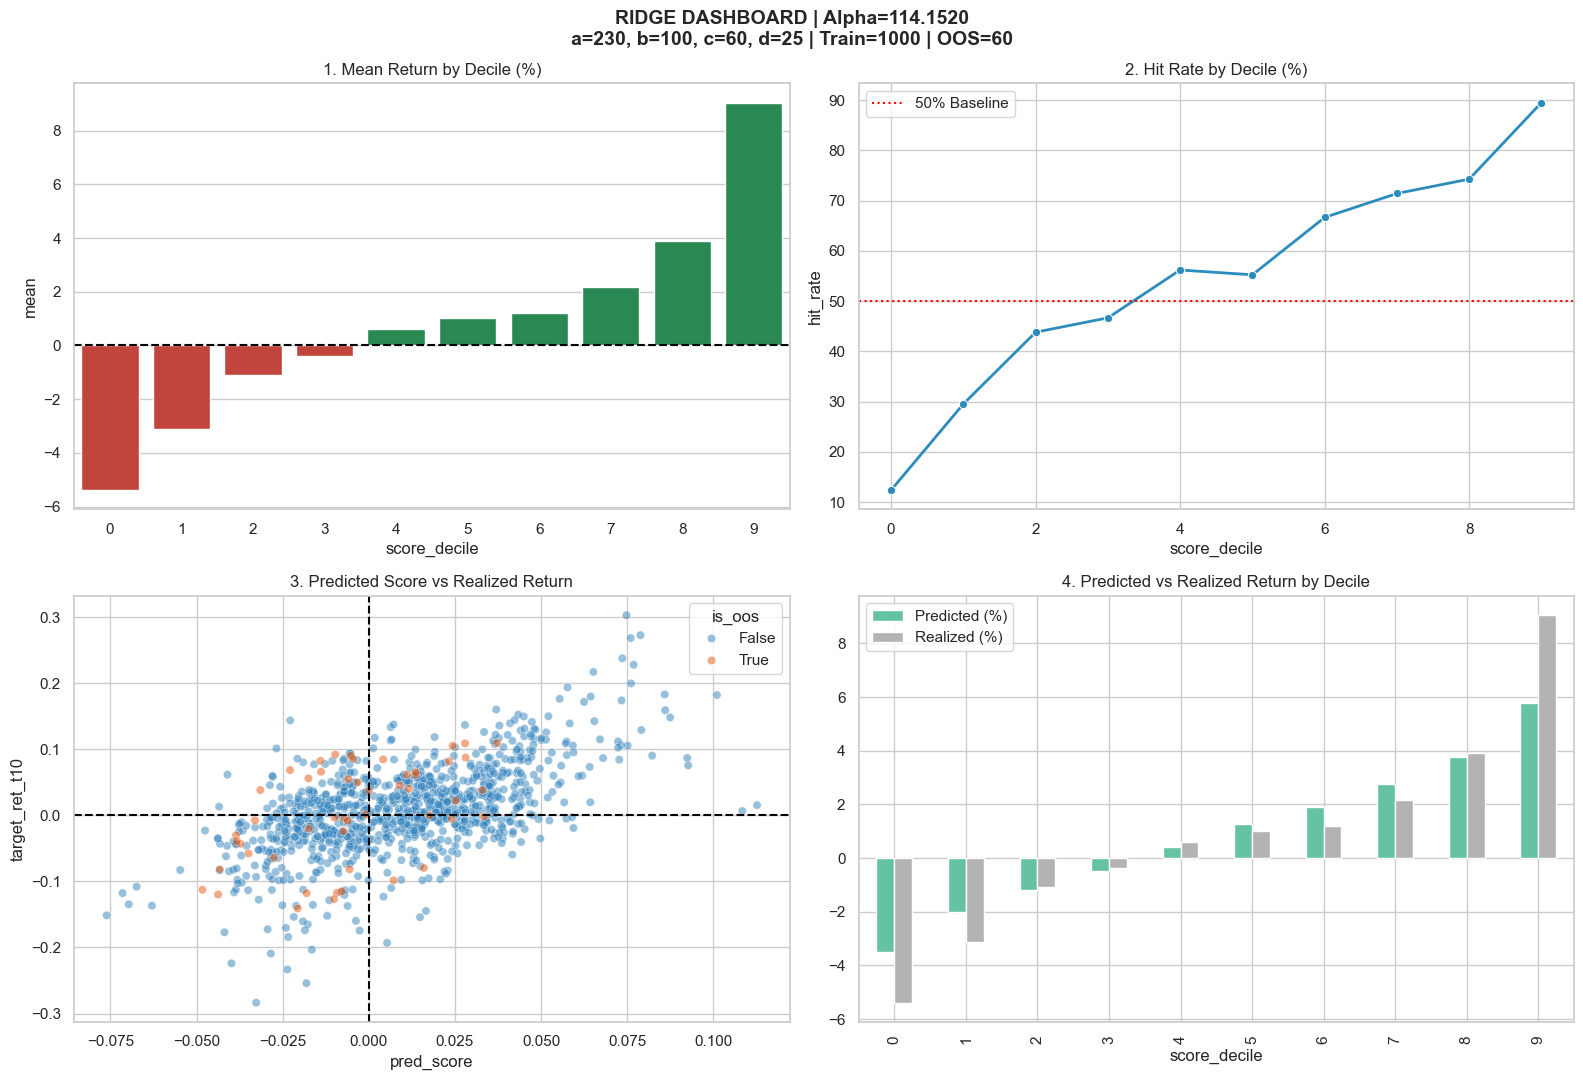

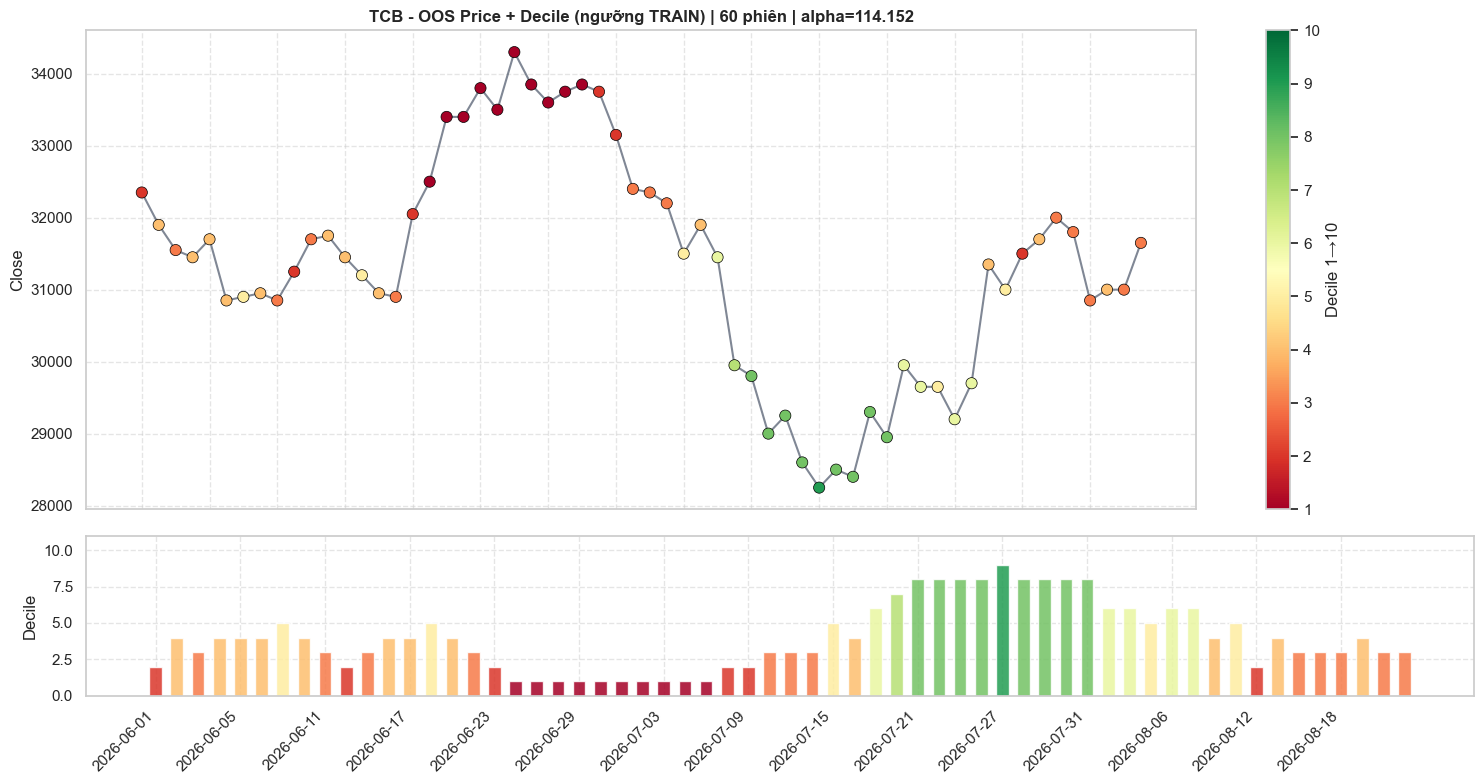

In [7]:
# ============================================================
# PHÂN TÍCH BEST TRIAL (Ridge + Decile Monotonicity)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import kendalltau, spearmanr
from sklearn.linear_model import Ridge
from sklearn.preprocessing import RobustScaler

# ----------------------------------------------------------
# 1. LẤY BEST PARAMS TỪ OPTUNA
# ----------------------------------------------------------
best = study.best_trial
a = best.user_attrs["a"]
b = best.user_attrs["b"]
c = best.user_attrs["c"]
d = best.user_attrs["d"]
alpha = best.user_attrs.get("alpha", best.user_attrs.get("chosen_alpha", 1.0))

print("=" * 70)
print("BEST PARAMS FROM OPTUNA")
print("=" * 70)
print(f"a={a}, b={b}, c={c}, d={d}")
print(f"Alpha (từ Optuna): {alpha:.4f}")
print(f"Train IC: {best.user_attrs.get('train_ic', np.nan):.4f} | "
      f"Top Hit: {best.user_attrs.get('top_hit', np.nan):.4f} | "
      f"Bot Hit: {best.user_attrs.get('bot_hit', np.nan):.4f} | "
      f"Mono: {best.user_attrs.get('mono_score', np.nan):.4f}")
print("=" * 70)

# ----------------------------------------------------------
# 2. TẠO FEATURE + TARGET
# ----------------------------------------------------------
df_feat = build_features(df_vni_raw, investor_groups, a, b, c, d)
target = df_vni_raw["close"].ffill().shift(-10) / df_vni_raw["close"].ffill() - 1
target.name = "target_ret_t10"

model_data = pd.concat([df_feat, target], axis=1)
model_data = model_data.replace([np.inf, -np.inf], np.nan)

# Thêm close để vẽ biểu đồ giá
model_data["close"] = df_vni_raw["close"].ffill().reindex(model_data.index)

X_cols = list(df_feat.columns)
y_col = "target_ret_t10"

print(f"Số feature: {len(X_cols)} | Tổng quan sát hợp lệ: {len(model_data)}")

# ----------------------------------------------------------
# 3. CẮT TRAIN / OOS
# ----------------------------------------------------------
total_needed = LOOKBACK_DAYS + OOS_DAYS
train_data = model_data.iloc[-total_needed:-OOS_DAYS].copy()
oos_data = model_data.iloc[-OOS_DAYS:].copy()

print(f"TRAIN: {len(train_data)} | OOS: {len(oos_data)}")

X_train = train_data[X_cols].values
y_train = train_data[y_col].values
X_oos = oos_data[X_cols].values
y_oos = oos_data[y_col].values

# ----------------------------------------------------------
# 4. SCALE + SAMPLE WEIGHT + FIT RIDGE (dùng alpha từ Optuna)
# ----------------------------------------------------------
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_oos_scaled = scaler.transform(X_oos)

half_life = 252
decay = np.log(2) / half_life
t = np.arange(len(y_train))
sample_weights = np.exp(decay * (t - (len(y_train) - 1)))

model = Ridge(alpha=alpha, fit_intercept=True)
model.fit(X_train_scaled, y_train, sample_weight=sample_weights)

print(f"\nSử dụng alpha = {alpha:.4f} (do Optuna chọn)")

# ----------------------------------------------------------
# 5. PREDICTION + METRICS CƠ BẢN
# ----------------------------------------------------------
train_data = train_data.copy()
train_data["pred_score"] = model.predict(X_train_scaled)
train_data["actual_ret"] = y_train

ic_train, _ = spearmanr(train_data["pred_score"], train_data["actual_ret"])
mask_train_pos = train_data["pred_score"] > 0
hit_train = (
    (train_data.loc[mask_train_pos, "actual_ret"] > 0).mean()
    if mask_train_pos.sum() > 0 else 0.0
)

print(f"\nTRAIN -> IC: {ic_train:.4f} | Hit Rate: {hit_train:.4f} | Signals: {mask_train_pos.sum()}")

if len(oos_data) > 0:
    oos_data = oos_data.copy()
    oos_data["pred_score"] = model.predict(X_oos_scaled)
    oos_data["actual_ret"] = y_oos

    ic_oos, _ = spearmanr(oos_data["pred_score"], oos_data["actual_ret"])
    mask_oos_pos = oos_data["pred_score"] > 0
    hit_oos = (
        (oos_data.loc[mask_oos_pos, "actual_ret"] > 0).mean()
        if mask_oos_pos.sum() > 0 else 0.0
    )
    print(f"OOS   -> IC: {ic_oos:.4f} | Hit Rate: {hit_oos:.4f} | Signals: {mask_oos_pos.sum()}")

# ----------------------------------------------------------
# 6. HÀM KIỂM TRA ĐƠN ĐIỆU
# ----------------------------------------------------------
def check_decile_monotonicity(eval_data, y_col="target_ret_t10", n_bins=10):
    df_eval = eval_data.copy()
    df_eval["score_decile"] = pd.qcut(
        df_eval["pred_score"], n_bins, labels=False, duplicates="drop"
    )

    analysis = df_eval.groupby("score_decile")[y_col].agg(["mean", "std", "count"])
    analysis["hit_rate"] = df_eval.groupby("score_decile")[y_col].apply(
        lambda x: (x > 0).mean()
    )
    analysis["avg_pred"] = df_eval.groupby("score_decile")["pred_score"].mean()

    decile_indices = analysis.index.values
    mean_returns = analysis["mean"].values

    spearman_corr, spearman_p = spearmanr(decile_indices, mean_returns)
    kendall_corr, kendall_p = kendalltau(decile_indices, mean_returns)

    diffs = np.diff(mean_returns)
    monotonic_steps = int(np.sum(diffs > 0))
    total_steps = len(diffs)
    monotonic_step_ratio = monotonic_steps / total_steps if total_steps > 0 else 0.0

    long_short_spread = mean_returns[-1] - mean_returns[0]

    metrics = {
        "spearman_monotonicity_ic": spearman_corr,
        "spearman_p_value": spearman_p,
        "kendall_tau": kendall_corr,
        "monotonic_step_ratio": monotonic_step_ratio,
        "monotonic_steps": f"{monotonic_steps}/{total_steps}",
        "long_short_spread": long_short_spread,
    }
    return analysis, metrics

# ----------------------------------------------------------
# 7. ĐÁNH GIÁ ĐƠN ĐIỆU
# ----------------------------------------------------------
parts = [train_data[["pred_score", y_col]].assign(is_oos=False)]
if len(oos_data) > 0:
    parts.append(oos_data[["pred_score", y_col]].assign(is_oos=True))

eval_data = pd.concat(parts, axis=0).dropna()

analysis_df, mono_metrics = check_decile_monotonicity(eval_data, y_col=y_col, n_bins=10)

print("\n" + "=" * 70)
print("ĐÁNH GIÁ TÍNH ĐƠN ĐIỆU CỦA DECILE")
print("=" * 70)
print(f"1. Spearman Monotonicity IC : {mono_metrics['spearman_monotonicity_ic']:.4f} "
      f"(p={mono_metrics['spearman_p_value']:.4f})")
print(f"2. Kendall's Tau            : {mono_metrics['kendall_tau']:.4f}")
print(f"3. Monotonic Step Ratio     : {mono_metrics['monotonic_step_ratio']*100:.1f}% "
      f"({mono_metrics['monotonic_steps']} bước tăng)")
print(f"4. Long-Short Spread (D9-D0): {mono_metrics['long_short_spread']*100:.2f}%")

print("\n--- Chi tiết từng Decile ---")
print(analysis_df[["mean", "hit_rate", "avg_pred"]].rename(columns={
    "mean": "Realized_Ret_Mean",
    "hit_rate": "Hit_Rate",
    "avg_pred": "Pred_Score_Mean",
}))

# ----------------------------------------------------------
# 8. DASHBOARD
# ----------------------------------------------------------
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    f"RIDGE DASHBOARD | Alpha={alpha:.4f}\n"
    f"a={a}, b={b}, c={c}, d={d} | Train={len(train_data)} | OOS={len(oos_data)}",
    fontsize=14, fontweight="bold"
)

colors = ["#d73027" if x < 0 else "#1a9850" for x in analysis_df["mean"]]
sns.barplot(x=analysis_df.index, y=analysis_df["mean"] * 100, ax=axes[0, 0], palette=colors)
axes[0, 0].axhline(0, color="black", ls="--")
axes[0, 0].set_title("1. Mean Return by Decile (%)")

sns.lineplot(x=analysis_df.index, y=analysis_df["hit_rate"] * 100,
             ax=axes[0, 1], marker="o", color="#2b8cbe", lw=2)
axes[0, 1].axhline(50, color="red", ls=":", label="50% Baseline")
axes[0, 1].set_title("2. Hit Rate by Decile (%)")
axes[0, 1].legend()

sns.scatterplot(data=eval_data, x="pred_score", y=y_col, hue="is_oos",
                ax=axes[1, 0], alpha=0.5,
                palette={False: "#3182bd", True: "#e6550d"})
axes[1, 0].axhline(0, color="black", ls="--")
axes[1, 0].axvline(0, color="black", ls="--")
axes[1, 0].set_title("3. Predicted Score vs Realized Return")

pd.DataFrame({
    "Predicted (%)": analysis_df["avg_pred"] * 100,
    "Realized (%)": analysis_df["mean"] * 100,
}).plot(kind="bar", ax=axes[1, 1], colormap="Set2")
axes[1, 1].set_title("4. Predicted vs Realized Return by Decile")

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 9. BIỂU ĐỒ GIÁ + DECILE OOS (ngưỡng từ TRAIN)
# ----------------------------------------------------------
if len(oos_data) > 0 and "close" in oos_data.columns:
    train_scores = train_data["pred_score"]
    _, bin_edges = pd.qcut(train_scores, q=10, duplicates="drop", retbins=True)
    bin_edges = bin_edges.copy()
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf
    n_deciles = len(bin_edges) - 1

    oos_data = oos_data.copy()
    oos_data["decile"] = (
        pd.cut(oos_data["pred_score"], bins=bin_edges,
               labels=False, include_lowest=True) + 1
    )

    if "time" in df_vni_raw.columns:
        raw_dates = df_vni_raw.loc[oos_data.index, "time"]
    else:
        raw_dates = oos_data.index

    if pd.api.types.is_datetime64_any_dtype(raw_dates):
        x_dates = pd.to_datetime(raw_dates).dt.strftime("%Y-%m-%d").values
    else:
        x_dates = pd.to_datetime(raw_dates).astype(str).values

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(15, 8), sharex=True,
        gridspec_kw={"height_ratios": [3, 1]}
    )

    ax1.plot(x_dates, oos_data["close"], color="#4A5568", lw=1.5, alpha=0.7, label="Close")
    sc = ax1.scatter(
        x_dates, oos_data["close"],
        c=oos_data["decile"], cmap="RdYlGn",
        vmin=1, vmax=n_deciles, s=65, zorder=5,
        edgecolors="black", linewidth=0.5
    )
    ax1.set_title(
        f"{SYMBOL} - OOS Price + Decile (ngưỡng TRAIN) | {len(oos_data)} phiên | alpha={alpha:.3f}",
        fontweight="bold"
    )
    ax1.set_ylabel("Close")
    ax1.grid(True, ls="--", alpha=0.5)
    plt.colorbar(sc, ax=ax1, label=f"Decile 1→{n_deciles}")

    norm = (n_deciles - 1) if n_deciles > 1 else 1
    bar_colors = plt.cm.RdYlGn((oos_data["decile"].astype(float) - 1) / norm)
    ax2.bar(x_dates, oos_data["decile"], color=bar_colors, alpha=0.85, width=0.6)
    ax2.set_ylabel("Decile")
    ax2.set_ylim(0, n_deciles + 1)
    ax2.grid(True, ls="--", alpha=0.5)
    plt.xticks(
        rotation=45, ha="right",
        ticks=range(0, len(x_dates), max(1, len(x_dates) // 15))
    )

    plt.tight_layout()
    plt.show()

BEST PARAMS FROM OPTUNA
a=80, b=50, c=25, d=25
Chosen Alpha (từ Optuna): 0.10377455397327104
Train IC: 0.7751 | Top Hit: 0.9750 | Bot Hit: 0.0500 | Mono: 1.0000
Số feature: 85 | Tổng quan sát hợp lệ: 1800
TRAIN: 1000 | OOS: 60

RidgeCV chọn alpha = 1.9307 (theo Spearman IC)

TRAIN -> IC: 0.7459 | Hit Rate: 0.8146 | Signals: 534
OOS   -> IC: nan | Hit Rate: 0.3077 | Signals: 39

ĐÁNH GIÁ TÍNH ĐƠN ĐIỆU CỦA DECILE
1. Spearman Monotonicity IC : 1.0000 (p=0.0000)
2. Kendall's Tau            : 1.0000
3. Monotonic Step Ratio     : 100.0% (9/9 bước tăng)
4. Long-Short Spread (D9-D0): 20.22%

--- Chi tiết từng Decile ---
              Realized_Ret_Mean  Hit_Rate  Pred_Score_Mean
score_decile                                              
0                     -0.095631  0.114286        -0.087947
1                     -0.056860  0.085714        -0.054135
2                     -0.026774  0.257143        -0.031076
3                     -0.007231  0.485714        -0.014655
4                      0.0

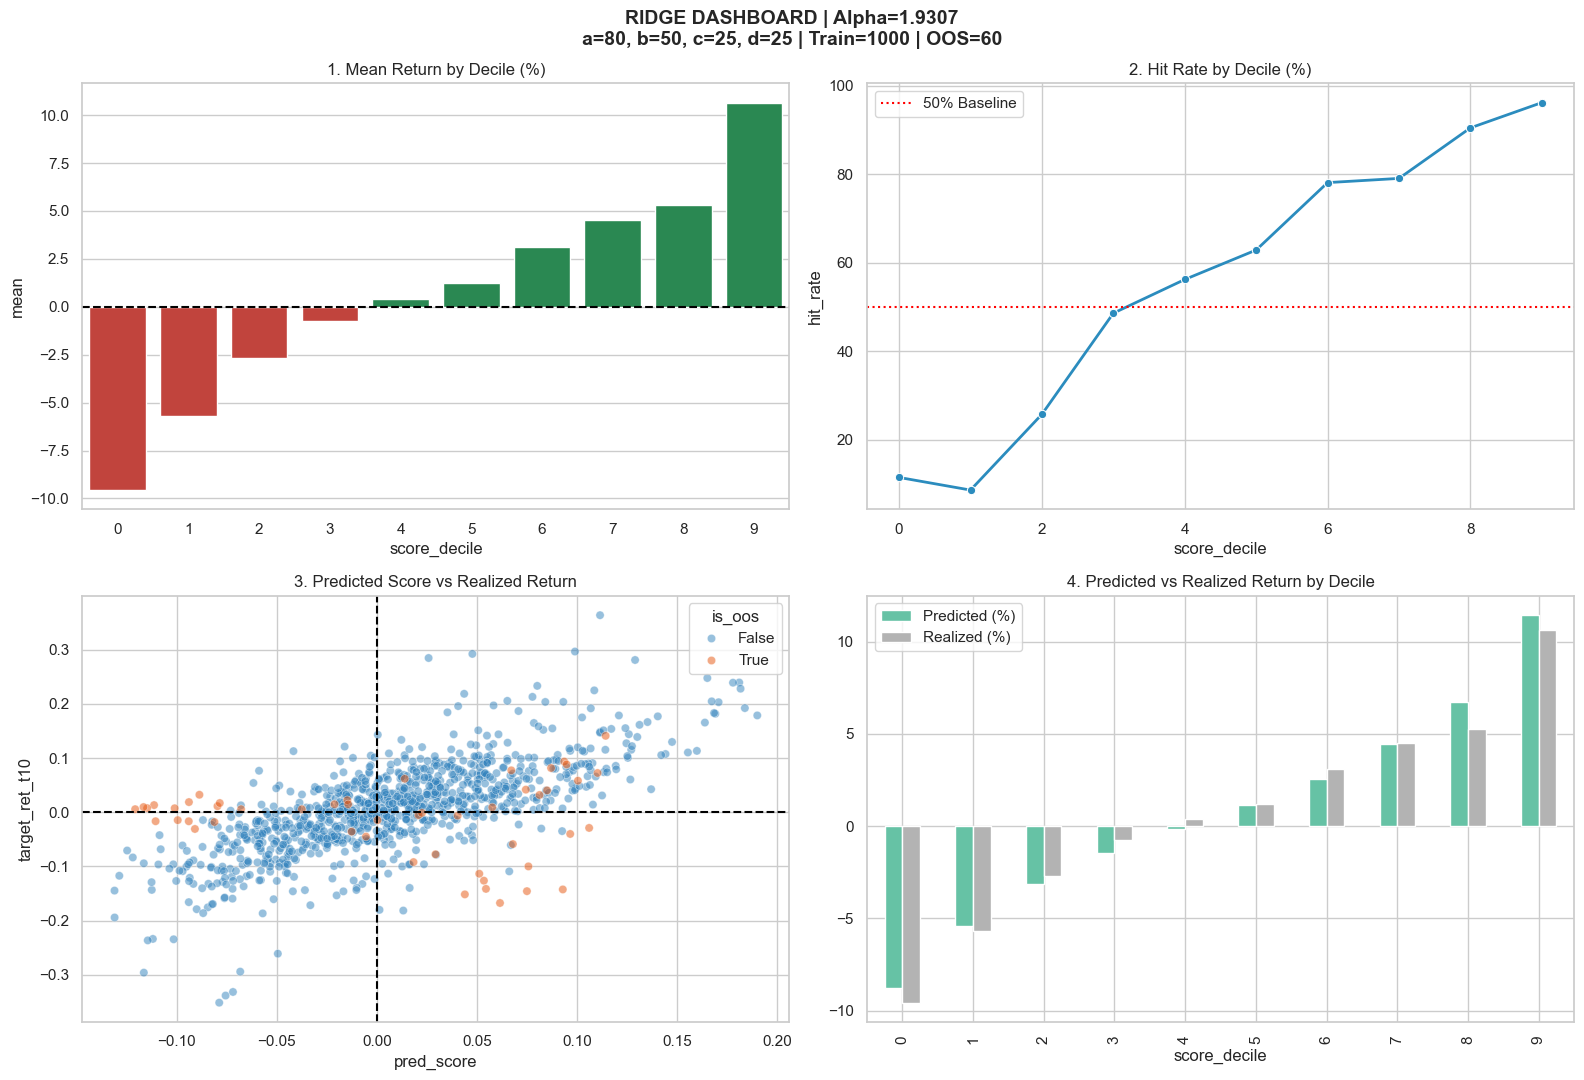

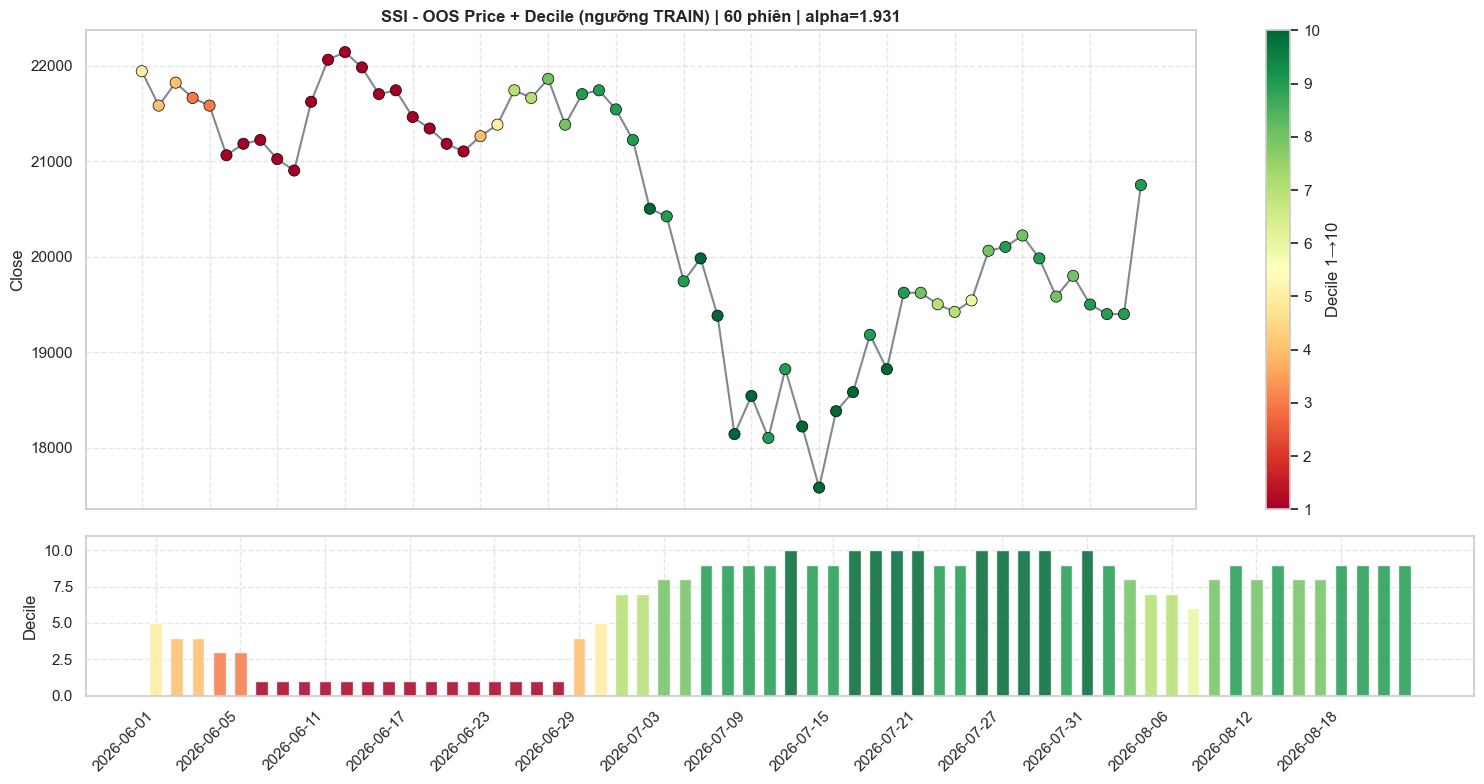

In [12]:
# ============================================================
# PHÂN TÍCH BEST TRIAL (RidgeCV + Spearman IC + Decile Monotonicity)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import kendalltau, spearmanr
from sklearn.linear_model import RidgeCV
from sklearn.metrics import make_scorer
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import RobustScaler

# ----------------------------------------------------------
# 1. LẤY BEST PARAMS TỪ OPTUNA
# ----------------------------------------------------------
best = study.best_trial
a = best.user_attrs["a"]
b = best.user_attrs["b"]
c = best.user_attrs["c"]
d = best.user_attrs["d"]

print("=" * 70)
print("BEST PARAMS FROM OPTUNA")
print("=" * 70)
print(f"a={a}, b={b}, c={c}, d={d}")
print(f"Chosen Alpha (từ Optuna): {best.user_attrs.get('chosen_alpha', 'N/A')}")
print(f"Train IC: {best.user_attrs.get('train_ic', np.nan):.4f} | "
      f"Top Hit: {best.user_attrs.get('top_hit', np.nan):.4f} | "
      f"Bot Hit: {best.user_attrs.get('bot_hit', np.nan):.4f} | "
      f"Mono: {best.user_attrs.get('mono_score', np.nan):.4f}")
print("=" * 70)

# ----------------------------------------------------------
# 2. TẠO FEATURE + TARGET
# ----------------------------------------------------------
df_feat = build_features(df_vni_raw, investor_groups, a, b, c, d)
target = df_vni_raw["close"].ffill().shift(-10) / df_vni_raw["close"].ffill() - 1
target.name = "target_ret_t10"

model_data = pd.concat([df_feat, target], axis=1)
model_data = model_data.replace([np.inf, -np.inf], np.nan)

# Thêm close để vẽ biểu đồ giá
model_data["close"] = df_vni_raw["close"].ffill().reindex(model_data.index)

X_cols = list(df_feat.columns)
y_col = "target_ret_t10"

print(f"Số feature: {len(X_cols)} | Tổng quan sát hợp lệ: {len(model_data)}")

# ----------------------------------------------------------
# 3. CẮT TRAIN / OOS
# ----------------------------------------------------------
total_needed = LOOKBACK_DAYS + OOS_DAYS
train_data = model_data.iloc[-total_needed:-OOS_DAYS].copy()
oos_data = model_data.iloc[-OOS_DAYS:].copy()

print(f"TRAIN: {len(train_data)} | OOS: {len(oos_data)}")

X_train = train_data[X_cols].values
y_train = train_data[y_col].values
X_oos = oos_data[X_cols].values
y_oos = oos_data[y_col].values

# ----------------------------------------------------------
# 4. SCALE + SAMPLE WEIGHT + FIT RIDGECV (theo Spearman IC)
# ----------------------------------------------------------
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_oos_scaled = scaler.transform(X_oos)

half_life = 252
decay = np.log(2) / half_life
t = np.arange(len(y_train))
sample_weights = np.exp(decay * (t - (len(y_train) - 1)))

# Custom scorer: Spearman IC
def spearman_ic_score(y_true, y_pred):
    corr, _ = spearmanr(y_true, y_pred)
    if np.isnan(corr):
        return -1.0
    return float(corr)

spearman_scorer = make_scorer(spearman_ic_score, greater_is_better=True)

tscv = TimeSeriesSplit(n_splits=3)
model = RidgeCV(
    alphas=ALPHAS,
    cv=tscv,
    scoring=spearman_scorer,          # <-- chọn alpha theo Spearman IC
)
model.fit(X_train_scaled, y_train, sample_weight=sample_weights)

chosen_alpha = float(model.alpha_)
print(f"\nRidgeCV chọn alpha = {chosen_alpha:.4f} (theo Spearman IC)")
# ----------------------------------------------------------
# 5. PREDICTION + METRICS CƠ BẢN
# ----------------------------------------------------------
train_data = train_data.copy()
train_data["pred_score"] = model.predict(X_train_scaled)
train_data["actual_ret"] = y_train

ic_train, _ = spearmanr(train_data["pred_score"], train_data["actual_ret"])
mask_train_pos = train_data["pred_score"] > 0
hit_train = (
    (train_data.loc[mask_train_pos, "actual_ret"] > 0).mean()
    if mask_train_pos.sum() > 0 else 0.0
)

print(f"\nTRAIN -> IC: {ic_train:.4f} | Hit Rate: {hit_train:.4f} | Signals: {mask_train_pos.sum()}")

if len(oos_data) > 0:
    oos_data = oos_data.copy()
    oos_data["pred_score"] = model.predict(X_oos_scaled)
    oos_data["actual_ret"] = y_oos

    ic_oos, _ = spearmanr(oos_data["pred_score"], oos_data["actual_ret"])
    mask_oos_pos = oos_data["pred_score"] > 0
    hit_oos = (
        (oos_data.loc[mask_oos_pos, "actual_ret"] > 0).mean()
        if mask_oos_pos.sum() > 0 else 0.0
    )
    print(f"OOS   -> IC: {ic_oos:.4f} | Hit Rate: {hit_oos:.4f} | Signals: {mask_oos_pos.sum()}")

# ----------------------------------------------------------
# 6. HÀM KIỂM TRA ĐƠN ĐIỆU
# ----------------------------------------------------------
def check_decile_monotonicity(eval_data, y_col="target_ret_t10", n_bins=10):
    df_eval = eval_data.copy()
    df_eval["score_decile"] = pd.qcut(
        df_eval["pred_score"], n_bins, labels=False, duplicates="drop"
    )

    analysis = df_eval.groupby("score_decile")[y_col].agg(["mean", "std", "count"])
    analysis["hit_rate"] = df_eval.groupby("score_decile")[y_col].apply(
        lambda x: (x > 0).mean()
    )
    analysis["avg_pred"] = df_eval.groupby("score_decile")["pred_score"].mean()

    decile_indices = analysis.index.values
    mean_returns = analysis["mean"].values

    spearman_corr, spearman_p = spearmanr(decile_indices, mean_returns)
    kendall_corr, kendall_p = kendalltau(decile_indices, mean_returns)

    diffs = np.diff(mean_returns)
    monotonic_steps = int(np.sum(diffs > 0))
    total_steps = len(diffs)
    monotonic_step_ratio = monotonic_steps / total_steps if total_steps > 0 else 0.0

    long_short_spread = mean_returns[-1] - mean_returns[0]

    metrics = {
        "spearman_monotonicity_ic": spearman_corr,
        "spearman_p_value": spearman_p,
        "kendall_tau": kendall_corr,
        "monotonic_step_ratio": monotonic_step_ratio,
        "monotonic_steps": f"{monotonic_steps}/{total_steps}",
        "long_short_spread": long_short_spread,
    }
    return analysis, metrics

# ----------------------------------------------------------
# 7. ĐÁNH GIÁ ĐƠN ĐIỆU
# ----------------------------------------------------------
parts = [train_data[["pred_score", y_col]].assign(is_oos=False)]
if len(oos_data) > 0:
    parts.append(oos_data[["pred_score", y_col]].assign(is_oos=True))

eval_data = pd.concat(parts, axis=0).dropna()

analysis_df, mono_metrics = check_decile_monotonicity(eval_data, y_col=y_col, n_bins=10)

print("\n" + "=" * 70)
print("ĐÁNH GIÁ TÍNH ĐƠN ĐIỆU CỦA DECILE")
print("=" * 70)
print(f"1. Spearman Monotonicity IC : {mono_metrics['spearman_monotonicity_ic']:.4f} "
      f"(p={mono_metrics['spearman_p_value']:.4f})")
print(f"2. Kendall's Tau            : {mono_metrics['kendall_tau']:.4f}")
print(f"3. Monotonic Step Ratio     : {mono_metrics['monotonic_step_ratio']*100:.1f}% "
      f"({mono_metrics['monotonic_steps']} bước tăng)")
print(f"4. Long-Short Spread (D9-D0): {mono_metrics['long_short_spread']*100:.2f}%")

print("\n--- Chi tiết từng Decile ---")
print(analysis_df[["mean", "hit_rate", "avg_pred"]].rename(columns={
    "mean": "Realized_Ret_Mean",
    "hit_rate": "Hit_Rate",
    "avg_pred": "Pred_Score_Mean",
}))

# ----------------------------------------------------------
# 8. DASHBOARD
# ----------------------------------------------------------
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    f"RIDGE DASHBOARD | Alpha={chosen_alpha:.4f}\n"
    f"a={a}, b={b}, c={c}, d={d} | Train={len(train_data)} | OOS={len(oos_data)}",
    fontsize=14, fontweight="bold"
)

colors = ["#d73027" if x < 0 else "#1a9850" for x in analysis_df["mean"]]
sns.barplot(x=analysis_df.index, y=analysis_df["mean"] * 100, ax=axes[0, 0], palette=colors)
axes[0, 0].axhline(0, color="black", ls="--")
axes[0, 0].set_title("1. Mean Return by Decile (%)")

sns.lineplot(x=analysis_df.index, y=analysis_df["hit_rate"] * 100,
             ax=axes[0, 1], marker="o", color="#2b8cbe", lw=2)
axes[0, 1].axhline(50, color="red", ls=":", label="50% Baseline")
axes[0, 1].set_title("2. Hit Rate by Decile (%)")
axes[0, 1].legend()

sns.scatterplot(data=eval_data, x="pred_score", y=y_col, hue="is_oos",
                ax=axes[1, 0], alpha=0.5,
                palette={False: "#3182bd", True: "#e6550d"})
axes[1, 0].axhline(0, color="black", ls="--")
axes[1, 0].axvline(0, color="black", ls="--")
axes[1, 0].set_title("3. Predicted Score vs Realized Return")

pd.DataFrame({
    "Predicted (%)": analysis_df["avg_pred"] * 100,
    "Realized (%)": analysis_df["mean"] * 100,
}).plot(kind="bar", ax=axes[1, 1], colormap="Set2")
axes[1, 1].set_title("4. Predicted vs Realized Return by Decile")

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 9. BIỂU ĐỒ GIÁ + DECILE OOS (ngưỡng từ TRAIN)
# ----------------------------------------------------------
if len(oos_data) > 0 and "close" in oos_data.columns:
    train_scores = train_data["pred_score"]
    _, bin_edges = pd.qcut(train_scores, q=10, duplicates="drop", retbins=True)
    bin_edges = bin_edges.copy()
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf
    n_deciles = len(bin_edges) - 1

    oos_data = oos_data.copy()
    oos_data["decile"] = (
        pd.cut(oos_data["pred_score"], bins=bin_edges,
               labels=False, include_lowest=True) + 1
    )

    # Ngày tháng
    if "time" in df_vni_raw.columns:
        raw_dates = df_vni_raw.loc[oos_data.index, "time"]
    else:
        raw_dates = oos_data.index

    if pd.api.types.is_datetime64_any_dtype(raw_dates):
        x_dates = pd.to_datetime(raw_dates).dt.strftime("%Y-%m-%d").values
    else:
        x_dates = pd.to_datetime(raw_dates).astype(str).values

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(15, 8), sharex=True,
        gridspec_kw={"height_ratios": [3, 1]}
    )

    ax1.plot(x_dates, oos_data["close"], color="#4A5568", lw=1.5, alpha=0.7, label="Close")
    sc = ax1.scatter(
        x_dates, oos_data["close"],
        c=oos_data["decile"], cmap="RdYlGn",
        vmin=1, vmax=n_deciles, s=65, zorder=5,
        edgecolors="black", linewidth=0.5
    )
    ax1.set_title(
        f"{SYMBOL} - OOS Price + Decile (ngưỡng TRAIN) | {len(oos_data)} phiên | alpha={chosen_alpha:.3f}",
        fontweight="bold"
    )
    ax1.set_ylabel("Close")
    ax1.grid(True, ls="--", alpha=0.5)
    plt.colorbar(sc, ax=ax1, label=f"Decile 1→{n_deciles}")

    norm = (n_deciles - 1) if n_deciles > 1 else 1
    bar_colors = plt.cm.RdYlGn((oos_data["decile"].astype(float) - 1) / norm)
    ax2.bar(x_dates, oos_data["decile"], color=bar_colors, alpha=0.85, width=0.6)
    ax2.set_ylabel("Decile")
    ax2.set_ylim(0, n_deciles + 1)
    ax2.grid(True, ls="--", alpha=0.5)
    plt.xticks(
        rotation=45, ha="right",
        ticks=range(0, len(x_dates), max(1, len(x_dates) // 15))
    )

    plt.tight_layout()
    plt.show()

In [6]:
import numpy as np
import pandas as pd
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import RobustScaler

# ============================================================
# ALPHA STABILITY TEST
# ============================================================

# 20 alpha values, từ 10^-1 đến 10^3.5
ALPHAS_STABILITY = np.logspace(-1, 5, 30)

LOOKBACK_DAYS = 1000
VALIDATION_DAYS = 60

# Số rolling windows muốn kiểm tra
N_WINDOWS = 20

results = []

# ------------------------------------------------------------
# Chỉ sử dụng phần dữ liệu đã có target hoàn chỉnh
# ------------------------------------------------------------

data = model_data.dropna(
    subset=X_cols + ["target_ret_t10"]
).copy()

# ------------------------------------------------------------
# Tạo 20 rolling windows
#
# Mỗi window:
#   TRAIN      = 1000 ngày
#   VALIDATION = 60 ngày
#
# Window sau dịch về quá khứ 60 ngày.
# ------------------------------------------------------------

for i in range(N_WINDOWS):

    # Kết thúc validation của window hiện tại
    val_end = len(data) - i * VALIDATION_DAYS

    val_start = val_end - VALIDATION_DAYS
    train_end = val_start
    train_start = train_end - LOOKBACK_DAYS

    # Không đủ dữ liệu thì dừng
    if train_start < 0:
        break

    train_data = data.iloc[train_start:train_end].copy()
    val_data = data.iloc[val_start:val_end].copy()

    # --------------------------------------------------------
    # Features
    # --------------------------------------------------------

    X_train = train_data[X_cols].values
    y_train = train_data["target_ret_t10"].values

    X_val = val_data[X_cols].values
    y_val = val_data["target_ret_t10"].values

    # --------------------------------------------------------
    # Scale: FIT CHỈ TRÊN TRAIN
    # --------------------------------------------------------

    scaler = RobustScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    # --------------------------------------------------------
    # RidgeCV
    # --------------------------------------------------------

    tscv = TimeSeriesSplit(n_splits=3)

    model = RidgeCV(
        alphas=ALPHAS_STABILITY,
        cv=tscv,
        scoring="neg_mean_squared_error"
    )

    model.fit(X_train_scaled, y_train)

    # --------------------------------------------------------
    # Validation performance
    # --------------------------------------------------------

    pred_val = model.predict(X_val_scaled)

    ic = np.corrcoef(pred_val, y_val)[0, 1]

    hit_rate = np.mean(
        np.sign(pred_val) == np.sign(y_val)
    )

    results.append({
        "window": i + 1,
        "train_start": train_data.index[0],
        "train_end": train_data.index[-1],
        "val_start": val_data.index[0],
        "val_end": val_data.index[-1],
        "alpha": model.alpha_,
        "val_ic": ic,
        "val_hit_rate": hit_rate
    })


# ============================================================
# RESULTS
# ============================================================

alpha_results = pd.DataFrame(results)

print("\n" + "=" * 80)
print("ALPHA STABILITY")
print("=" * 80)

print(
    alpha_results[
        [
            "window",
            "train_start",
            "train_end",
            "val_start",
            "val_end",
            "alpha",
            "val_ic",
            "val_hit_rate"
        ]
    ].to_string(index=False)
)

# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("ALPHA SUMMARY")
print("=" * 80)

print(f"Windows tested : {len(alpha_results)}")
print(f"Median alpha   : {alpha_results['alpha'].median():.4f}")
print(f"Mean alpha     : {alpha_results['alpha'].mean():.4f}")
print(f"Min alpha      : {alpha_results['alpha'].min():.4f}")
print(f"Max alpha      : {alpha_results['alpha'].max():.4f}")
print(f"Std alpha      : {alpha_results['alpha'].std():.4f}")

print("\nAlpha distribution:")
print(
    alpha_results["alpha"]
    .value_counts()
    .sort_index()
)

# ============================================================
# CHECK WHETHER ALPHA IS HITTING THE SEARCH BOUNDARIES
# ============================================================

alpha_min = ALPHAS_STABILITY.min()
alpha_max = ALPHAS_STABILITY.max()

lower_boundary = np.isclose(
    alpha_results["alpha"],
    alpha_min
)

upper_boundary = np.isclose(
    alpha_results["alpha"],
    alpha_max
)

print("\n" + "=" * 80)
print("BOUNDARY CHECK")
print("=" * 80)

print(
    f"At lower boundary ({alpha_min:.4f}): "
    f"{lower_boundary.sum()}/{len(alpha_results)} windows"
)

print(
    f"At upper boundary ({alpha_max:.4f}): "
    f"{upper_boundary.sum()}/{len(alpha_results)} windows"
)

from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import RobustScaler
import numpy as np
import pandas as pd

data = (
    model_data
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=X_cols + ["target_ret_t10"])
    .copy()
)
all_results = []

for w in range(N_WINDOWS):

    val_end = len(data) - w * VALIDATION_DAYS
    val_start = val_end - VALIDATION_DAYS
    train_end = val_start
    train_start = train_end - LOOKBACK_DAYS

    if train_start < 0:
        break

    train_data = data.iloc[train_start:train_end]

    X = train_data[X_cols].values
    y = train_data["target_ret_t10"].values

    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)

    tscv = TimeSeriesSplit(n_splits=3)

    for alpha in ALPHAS:

        fold_mse = []

        for tr_idx, cv_idx in tscv.split(X_scaled):

            X_tr = X_scaled[tr_idx]
            X_cv = X_scaled[cv_idx]

            y_tr = y[tr_idx]
            y_cv = y[cv_idx]

            model = Ridge(alpha=alpha)
            model.fit(X_tr, y_tr)

            pred = model.predict(X_cv)

            fold_mse.append(
                mean_squared_error(y_cv, pred)
            )

        all_results.append({
            "window": w + 1,
            "alpha": alpha,
            "cv_mse": np.mean(fold_mse)
        })

mse_df = pd.DataFrame(all_results)

# ============================================================
# BẢNG MSE TRUNG BÌNH QUA 12 WINDOWS
# ============================================================

mse_summary = (
    mse_df
    .groupby("alpha")["cv_mse"]
    .agg(["mean", "median", "std"])
    .reset_index()
    .rename(columns={
        "mean": "mean_cv_mse",
        "median": "median_cv_mse",
        "std": "std_cv_mse"
    })
)

print("\n" + "=" * 80)
print("MSE THEO ALPHA")
print("=" * 80)

print(
    mse_summary.to_string(
        index=False,
        formatters={
            "alpha": "{:.4f}".format,
            "mean_cv_mse": "{:.8f}".format,
            "median_cv_mse": "{:.8f}".format,
            "std_cv_mse": "{:.8f}".format
        }
    )
)


ALPHA STABILITY
 window  train_start  train_end  val_start  val_end         alpha    val_ic  val_hit_rate
      1          730       1729       1730     1789  23950.266200 -0.586430      0.450000
      2          670       1669       1670     1729 100000.000000 -0.593860      0.416667
      3          610       1609       1610     1669 100000.000000 -0.178170      0.516667
      4          550       1549       1550     1609  38566.204212  0.166642      0.383333
      5          490       1489       1490     1549  23950.266200  0.108825      0.883333
      6          430       1429       1430     1489  14873.521073 -0.188140      0.500000
      7          370       1369       1370     1429 100000.000000 -0.319822      0.650000
      8          310       1309       1310     1369 100000.000000 -0.342915      0.400000
      9          250       1249       1250     1309  62101.694189  0.301997      0.383333
     10          190       1189       1190     1249  38566.204212 -0.082605      0.

# Code ploty Phiên bản fixed Scaler

In [ ]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import optuna
from tqdm import tqdm
from itertools import combinations
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import TimeSeriesSplit
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ============================================================
# CẤU HÌNH
# ============================================================
DATA_DIR = r"E:\Document\Tao\FiinGroup\csv_data_2"
RESULT_PATH = r"E:\Document\Tao\FiinGroup\optuna_results_all_symbols.csv"

LOOKBACK_DAYS = 1000
OOS_DAYS = 60
TRIALS = 200               # giảm để chạy nhanh nhiều mã (có thể tăng sau)

# Window parameters
A_MIN, A_MAX = 20, 300
B_MIN, B_MAX = 20, 300
C_MIN, C_MAX = 15, 60
D_MIN, D_MAX = 5, 40

ALPHAS = np.logspace(2, 3.5, 20)          # 10 → 1000

# Trọng số Score
W_HIT = 0.60
W_IC  = 0.40
W_TOP = 0.30
W_BOT = 0.20

# Ngưỡng mong muốn
TOP_HIT_TARGET = 0.85
BOT_HIT_TARGET = 0.15

# Ngưỡng Train
MIN_SIGNALS_TRAIN_SOFT = 30
MIN_SIGNALS_TRAIN_HARD = 15
MIN_HIT_TRAIN_SOFT = 0.55
MIN_HIT_TRAIN_HARD = 0.52
MIN_IC_TRAIN_HARD = 0.02

investor_groups = ["foreign", "prop", "local_inst", "local_ind"]


# ============================================================
# FEATURE ENGINEERING (bản refactor)
# ============================================================
def build_features(df_raw, investor_groups, a, b, c, d):
    df = df_raw.copy()

    keep_cols = [
        "open", "high", "low", "close", "trading_value",
        "foreign_net_val", "prop_net_val", "local_ind_net_val", "local_inst_net_val",
        "foreign_net_vol", "prop_net_vol", "local_ind_net_vol", "local_inst_net_vol",
    ]
    keep_cols = [col for col in keep_cols if col in df.columns]
    df = df[keep_cols]

    df["trading_value"] = df["trading_value"].replace(0, np.nan).ffill()
    df["close"] = df["close"].ffill()
    df["log_ret"] = np.log(df["close"] / df["close"].shift(1)).fillna(0)
    df["abs_ret"] = df["log_ret"].abs()

    tr = np.maximum(
        df["high"] - df["low"],
        np.maximum(
            (df["high"] - df["close"].shift(1)).abs(),
            (df["low"] - df["close"].shift(1)).abs(),
        ),
    )

    # ----- Flow cơ bản -----
    for g in investor_groups:
        net_val = df[f"{g}_net_val"]
        net_ratio = net_val / df["trading_value"]
        df[f"feat_{g}_net_ratio"] = net_ratio.fillna(0)

        prev = net_ratio.shift(1).abs()
        df[f"feat_{g}_price_impact"] = (
            df["abs_ret"].shift(1) / (prev + 1e-6)
        ).rolling(5).median()

        mu = df[f"feat_{g}_net_ratio"].rolling(a).mean()
        sigma = df[f"feat_{g}_net_ratio"].rolling(a).std()
        df[f"feat_{g}_zscore"] = (
            (df[f"feat_{g}_net_ratio"] - mu) / (sigma + 1e-8)
        ).clip(-4, 4).fillna(0)

        rmin = net_val.rolling(a).min()
        rmax = net_val.rolling(a).max()
        df[f"feat_{g}_sentiment"] = (
            2 * (net_val - rmin) / (rmax - rmin + 1e-6) - 1
        ).fillna(0)

    df = df.replace([np.inf, -np.inf], 0).fillna(0)

    feature_dict = {}

    # ----- Technical (chỉ dùng cho interaction) -----
    delta = df["close"].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / (loss + 1e-8)
    rsi = 100 - (100 / (1 + rs))
    feature_dict["ta_rsi_norm"] = (rsi / 100.0) - 0.5

    ma50 = df["close"].rolling(50).mean()
    feature_dict["ta_dist_ma50"] = (df["close"] - ma50) / (ma50 + 1e-8)

    roll_high = df["high"].rolling(c).max()
    roll_low = df["low"].rolling(c).min()
    feature_dict["ta_pos_in_range"] = (df["close"] - roll_low) / (roll_high - roll_low + 1e-8)

    feature_dict["ta_atr_pct"] = tr.ewm(span=b, adjust=False).mean() / df["close"]

    # ----- Flow features + Interaction -----
    for g in investor_groups:
        sent = df[f"feat_{g}_sentiment"]
        sent_ewm = sent.ewm(span=b, adjust=False).mean()
        feature_dict[f"feat_{g}_sentiment_ewm"] = sent_ewm

        sent_mean = sent_ewm.rolling(a, min_periods=10).mean()
        sent_std = sent_ewm.rolling(a, min_periods=10).std().replace(0, np.nan)
        sent_z = ((sent_ewm - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

        feature_dict[f"feat_{g}_sentiment_cubed"] = (sent_z**3 - 3 * sent_z).clip(-10, 10)

        impulse = sent_ewm.diff(d).fillna(0)
        feature_dict[f"feat_{g}_flow_impulse_{d}d"] = impulse

        imp_mean = impulse.rolling(a, min_periods=10).mean()
        imp_std = impulse.rolling(a, min_periods=10).std().replace(0, np.nan)
        imp_z = ((impulse - imp_mean) / (imp_std + 1e-6)).clip(-3, 3).fillna(0)

        feature_dict[f"feat_{g}_flow_impulse_{d}d_cubed"] = (imp_z**3 - 3 * imp_z).clip(-10, 10)

        feature_dict[f"feat_{g}_eff_flow"] = sent * df[f"feat_{g}_price_impact"]
        feature_dict[f"feat_{g}_val_share"] = df[f"{g}_net_val"].abs() / df["trading_value"]

        implied = np.where(df[f"{g}_net_vol"] != 0, df[f"{g}_net_val"] / df[f"{g}_net_vol"], 0)
        feature_dict[f"feat_{g}_rel_net_price_ewm"] = (
            pd.Series(implied / df["close"], index=df.index).ewm(span=b, adjust=False).mean()
        )

        # Interaction
        feature_dict[f"inter_{g}_sent_x_pos"] = sent_z * feature_dict["ta_pos_in_range"]
        feature_dict[f"inter_{g}_sent_x_distma"] = sent_z * feature_dict["ta_dist_ma50"]
        feature_dict[f"inter_{g}_sent_x_atr"] = sent_z * feature_dict["ta_atr_pct"]
        feature_dict[f"inter_{g}_eff_x_pos"] = feature_dict[f"feat_{g}_eff_flow"] * feature_dict["ta_pos_in_range"]

    # ----- Cross-investor -----
    groups = investor_groups
    sent_ewm = {g: feature_dict[f"feat_{g}_sentiment_ewm"] for g in groups}
    sent_z = {}
    for g in groups:
        sent = df[f"feat_{g}_sentiment"]
        sent_ewm_g = sent.ewm(span=b, adjust=False).mean()
        mu = sent_ewm_g.rolling(a, min_periods=10).mean()
        sigma = sent_ewm_g.rolling(a, min_periods=10).std().replace(0, np.nan)
        sent_z[g] = ((sent_ewm_g - mu) / (sigma + 1e-6)).clip(-3, 3).fillna(0)

    net_ratio = {g: df[f"feat_{g}_net_ratio"] for g in groups}

    for g1, g2 in combinations(groups, 2):
        feature_dict[f"cross_{g1}_minus_{g2}_sent"] = sent_ewm[g1] - sent_ewm[g2]
        feature_dict[f"cross_{g1}_minus_{g2}_sent_z"] = sent_z[g1] - sent_z[g2]
        feature_dict[f"cross_{g1}_minus_{g2}_net"] = net_ratio[g1] - net_ratio[g2]
        feature_dict[f"cross_agree_sign_{g1}_{g2}"] = np.sign(sent_ewm[g1]) * np.sign(sent_ewm[g2])
        feature_dict[f"cross_agree_strength_{g1}_{g2}"] = sent_ewm[g1] * sent_ewm[g2]

    sent_matrix = pd.concat([sent_ewm[g] for g in groups], axis=1)
    feature_dict["cross_dispersion_std"] = sent_matrix.std(axis=1)
    feature_dict["cross_dispersion_range"] = sent_matrix.max(axis=1) - sent_matrix.min(axis=1)
    feature_dict["cross_dispersion_iqr"] = (
        sent_matrix.quantile(0.75, axis=1) - sent_matrix.quantile(0.25, axis=1)
    )

    total_abs_net = sum(df[f"{g}_net_val"].abs() for g in groups) + 1e-8
    for g in groups:
        feature_dict[f"cross_dominance_{g}"] = df[f"{g}_net_val"].abs() / total_abs_net

    return pd.DataFrame(feature_dict, index=df.index)


# ============================================================
# HÀM ĐÁNH GIÁ (RidgeCV + Decile Monotonicity) — dùng cho mọi symbol
# ============================================================
def evaluate_params_ridge(
    a, b, c, d,
    df_raw,
    investor_groups,
    lookback_days=LOOKBACK_DAYS,
    oos_days=OOS_DAYS,
):
    try:
        # ----- Feature + Target -----
        df_feat = build_features(df_raw, investor_groups, a, b, c, d)
        target = df_raw["close"].ffill().shift(-10) / df_raw["close"].ffill() - 1
        target.name = "target_ret_t10"

        model_data = pd.concat([df_feat, target], axis=1)
        model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()

        if len(model_data) < (lookback_days + oos_days + 50):
            return (-999.0,) * 12

        train_data = model_data.iloc[-(lookback_days + oos_days): -oos_days].copy()
        oos_data = model_data.iloc[-oos_days:].copy()

        if len(train_data) < 300 or len(oos_data) < 10:
            return (-999.0,) * 12

        X_train = train_data.drop(columns=["target_ret_t10"]).values
        y_train = train_data["target_ret_t10"].values
        X_oos = oos_data.drop(columns=["target_ret_t10"]).values
        y_oos = oos_data["target_ret_t10"].values

        # ----- Scale -----
        scaler = RobustScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_oos_scaled = scaler.transform(X_oos)

        # ----- Sample weight (time decay) -----
        half_life = 252
        decay = np.log(2) / half_life
        t = np.arange(len(y_train))
        sample_weights = np.exp(decay * (t - (len(y_train) - 1)))

        # ----- Model -----
        tscv = TimeSeriesSplit(n_splits=3)
        model = RidgeCV(alphas=ALPHAS, cv=tscv, scoring="neg_mean_squared_error")
        model.fit(X_train_scaled, y_train, sample_weight=sample_weights)

        chosen_alpha = float(model.alpha_)
        pred_train = model.predict(X_train_scaled)
        pred_oos = model.predict(X_oos_scaled)

        # ----- Metrics Train -----
        train_ic, _ = spearmanr(pred_train, y_train)
        if np.isnan(train_ic):
            train_ic = -1.0

        mask_up_train = pred_train > 0
        n_signals_train = int(mask_up_train.sum())

        if n_signals_train >= MIN_SIGNALS_TRAIN_HARD:
            hit_rate_train = float((y_train[mask_up_train] > 0).mean())
            avg_ret_train = float(y_train[mask_up_train].mean())
        else:
            hit_rate_train = 0.50
            avg_ret_train = 0.0

        # ----- Decile Analysis (Train) -----
        try:
            deciles = pd.qcut(pred_train, 10, labels=False, duplicates="drop")
        except Exception:
            return (-999.0,) * 12

        df_dec = pd.DataFrame({"pred": pred_train, "y": y_train, "decile": deciles})
        decile_stats = (
            df_dec.groupby("decile")["y"]
            .agg(mean_ret="mean", hit_rate=lambda x: (x > 0).mean(), count="count")
            .reindex(range(10))
        )

        top_stats = decile_stats.loc[[8, 9]].dropna()
        bot_stats = decile_stats.loc[[0, 1]].dropna()

        if len(top_stats) < 1 or len(bot_stats) < 1:
            return (-999.0,) * 12

        top_hit = float(top_stats["hit_rate"].mean())
        bot_hit = float(bot_stats["hit_rate"].mean())
        top_mean = float(top_stats["mean_ret"].mean())
        bot_mean = float(bot_stats["mean_ret"].mean())

        valid = decile_stats.dropna()
        if len(valid) >= 5:
            mono_score = spearmanr(valid.index, valid["mean_ret"])[0]
            mono_score = 0.0 if np.isnan(mono_score) else float(mono_score)
        else:
            mono_score = 0.0

        # ----- Metrics OOS (giám sát) -----
        oos_ic, _ = spearmanr(pred_oos, y_oos)
        if np.isnan(oos_ic):
            oos_ic = -1.0

        mask_up_oos = pred_oos > 0
        n_signals_oos = int(mask_up_oos.sum())
        hit_rate_oos = float((y_oos[mask_up_oos] > 0).mean()) if n_signals_oos >= 3 else 0.50
        avg_ret_oos = float(y_oos[mask_up_oos].mean()) if n_signals_oos >= 3 else 0.0

        train_oos_gap = train_ic - oos_ic

        # ----- SCORE -----
        hit_term = (hit_rate_train - 0.50) * 2.0
        ic_term = np.clip(train_ic, -0.15, 0.60)
        top_term = np.clip((top_hit - 0.50) / 0.40, 0, 1.5)
        bot_term = np.clip((0.50 - bot_hit) / 0.40, 0, 1.5)
        mono_term = np.clip(mono_score, 0, 1.0)

        score = (
            W_HIT * hit_term
            + W_IC * ic_term
            + W_TOP * top_term
            + W_BOT * bot_term
            + 0.05 * mono_term
        )

        if top_mean > 0:
            score += 0.02 * np.clip(top_mean * 10, 0, 0.3)
        if bot_mean < 0:
            score += 0.02 * np.clip(-bot_mean * 10, 0, 0.3)

        # Soft penalty
        if n_signals_train < MIN_SIGNALS_TRAIN_SOFT:
            score *= 0.75
        if hit_rate_train < MIN_HIT_TRAIN_SOFT:
            score *= 0.80
        if top_hit < 0.75:
            score *= 0.70
        if bot_hit > 0.25:
            score *= 0.75

        # Hard filter
        if (
            n_signals_train < MIN_SIGNALS_TRAIN_HARD
            or hit_rate_train < MIN_HIT_TRAIN_HARD
            or train_ic < MIN_IC_TRAIN_HARD
            or top_hit < 0.65
            or bot_hit > 0.35
        ):
            score = -999.0

        return (
            float(score),
            float(oos_ic),
            float(hit_rate_oos),
            float(avg_ret_oos),
            n_signals_oos,
            float(chosen_alpha),
            float(train_ic),
            float(hit_rate_train),
            float(train_oos_gap),
            float(top_hit),
            float(bot_hit),
            float(mono_score),
        )

    except Exception as e:
        print(f"[EXCEPTION] a={a}, b={b}, c={c}, d={d} → {type(e).__name__}: {e}")
        return (-999.0,) * 12


# ============================================================
# CHẠY OPTUNA CHO 1 SYMBOL (bản mới, dùng evaluate_params_ridge refactor)
# ============================================================
def run_optuna_for_symbol(symbol: str, df: pd.DataFrame):
    def objective(trial):
        a = trial.suggest_int("window_z", A_MIN, A_MAX, step=10)
        b = trial.suggest_int("window_div", B_MIN, B_MAX, step=10)
        c = trial.suggest_int("pos_range", C_MIN, C_MAX, step=5)
        d = trial.suggest_int("impulse_days", D_MIN, D_MAX, step=5)

        result = evaluate_params_ridge(a, b, c, d, df, investor_groups)
        (
            score, oos_ic, hit_up, avg_ret, n_sig, chosen_alpha,
            train_ic, hit_train, gap, top_hit, bot_hit, mono
        ) = result

        trial.set_user_attr("oos_ic", oos_ic)
        trial.set_user_attr("hit_rate_oos", hit_up)
        trial.set_user_attr("avg_ret_oos", avg_ret)
        trial.set_user_attr("n_signals", n_sig)
        trial.set_user_attr("chosen_alpha", chosen_alpha)
        trial.set_user_attr("train_ic", train_ic)
        trial.set_user_attr("hit_rate_train", hit_train)
        trial.set_user_attr("train_oos_gap", gap)
        trial.set_user_attr("top_hit", top_hit)
        trial.set_user_attr("bot_hit", bot_hit)
        trial.set_user_attr("mono_score", mono)
        trial.set_user_attr("a", a)
        trial.set_user_attr("b", b)
        trial.set_user_attr("c", c)
        trial.set_user_attr("d", d)
        return score

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=20),
    )
    study.optimize(objective, n_trials=TRIALS, show_progress_bar=False)

    best = study.best_trial
    if best.value is None or best.value < -900:
        return None

    return {
        "symbol": symbol,
        "score": best.value,
        "oos_ic": best.user_attrs["oos_ic"],
        "train_ic": best.user_attrs["train_ic"],
        "train_oos_gap": best.user_attrs["train_oos_gap"],
        "hit_rate_oos": best.user_attrs["hit_rate_oos"],
        "hit_rate_train": best.user_attrs["hit_rate_train"],
        "avg_ret_oos": best.user_attrs["avg_ret_oos"],
        "top_hit": best.user_attrs["top_hit"],
        "bot_hit": best.user_attrs["bot_hit"],
        "mono_score": best.user_attrs["mono_score"],
        "n_signals": best.user_attrs["n_signals"],
        "chosen_alpha": best.user_attrs["chosen_alpha"],
        "a": best.user_attrs["a"],
        "b": best.user_attrs["b"],
        "c": best.user_attrs["c"],
        "d": best.user_attrs["d"],
        "alpha_is_high": best.user_attrs["chosen_alpha"] >= 800,
    }


# ============================================================
# CHẠY HÀNG LOẠT CHO TẤT CẢ SYMBOL (giữ nguyên logic load dữ liệu)
# ============================================================
def get_all_symbols(data_dir: str):
    """
    Lấy tất cả symbol từ cả 2 loại tên file
    """
    symbols = set()

    # 1. Các mã cổ phiếu (Phân loại nhà đầu tư)
    pattern1 = os.path.join(data_dir, "Kafi_Phân_Loại_Nhà_Đầu_Tư_*.csv")
    for f in glob.glob(pattern1):
        name = os.path.basename(f)
        sym = name.replace("Kafi_Phân_Loại_Nhà_Đầu_Tư_", "").replace(".csv", "")
        symbols.add(sym)

    # 2. Các index (Giá)
    pattern2 = os.path.join(data_dir, "Kafi_Giá_*.csv")
    for f in glob.glob(pattern2):
        name = os.path.basename(f)
        sym = name.replace("Kafi_Giá_", "").replace(".csv", "")
        symbols.add(sym)

    return sorted(list(symbols))


def get_file_path(symbol: str, data_dir: str):
    """
    Trả về đường dẫn file đúng theo loại symbol
    """
    # Ưu tiên tìm file Phân loại nhà đầu tư trước (cổ phiếu)
    path1 = os.path.join(data_dir, f"Kafi_Phân_Loại_Nhà_Đầu_Tư_{symbol}.csv")
    if os.path.exists(path1):
        return path1

    # Nếu không có thì tìm file Giá (index)
    path2 = os.path.join(data_dir, f"Kafi_Giá_{symbol}.csv")
    if os.path.exists(path2):
        return path2

    return None


def load_symbol_data(symbol: str, data_dir: str = DATA_DIR):
    """
    Load dữ liệu của 1 mã (dù là cổ phiếu hay index)
    NOTE: hàm load_and_map_excel cần được import/định nghĩa từ module xử lý dữ liệu của bạn.
    """
    file_path = get_file_path(symbol, data_dir)
    if file_path is None:
        print(f"[{symbol}] Không tìm thấy file")
        return None

    try:
        df = load_and_map_excel(file_path, df_history=None)  # noqa: F821 (định nghĩa ở nơi khác trong project)

        if df is None or len(df) < 400:
            print(f"[{symbol}] Dữ liệu quá ngắn hoặc None")
            return None

        return df
    except Exception as e:
        print(f"[{symbol}] Lỗi load: {e}")
        return None


if __name__ == "__main__":
    symbols = get_all_symbols(DATA_DIR)
    print(f"Tìm thấy {len(symbols)} mã: {symbols[:10]}...")

    all_results = []

    for sym in tqdm(symbols, desc="Running Optuna"):
        df = load_symbol_data(sym)
        if df is None or len(df) < 400:
            print(f"[{sym}] Bỏ qua (thiếu dữ liệu)")
            continue

        try:
            res = run_optuna_for_symbol(sym, df)
            if res is not None:
                all_results.append(res)
                print(
                    f"[{sym}] Score={res['score']:.3f} | TrainIC={res['train_ic']:.3f} | "
                    f"TopHit={res['top_hit']:.2f} | BotHit={res['bot_hit']:.2f} | "
                    f"Alpha={res['chosen_alpha']:.1f} | Signals={res['n_signals']}"
                )
            else:
                print(f"[{sym}] Không tìm được trial hợp lệ")
        except Exception as e:
            print(f"[{sym}] Lỗi: {e}")

    if all_results:
        df_result = pd.DataFrame(all_results)
        df_result.to_csv(RESULT_PATH, index=False)
        print(f"\nĐã lưu kết quả → {RESULT_PATH}")
        print(df_result.describe())
    else:
        print("Không có kết quả nào được lưu.")

In [13]:
SYMBOL = 'VIC'

# --- BƯỚC 1: CHUẨN BỊ DỮ LIỆU ---
excel_file_path_vni = rf"E:\Document\Tao\FiinGroup\csv_data_2\Kafi_Phân_Loại_Nhà_Đầu_Tư_{SYMBOL}.csv"
excel_file_path_vni_new = rf"E:\Document\Tao\FiinGroup\csv_data_2\Kafi_Giá_{SYMBOL}.csv"
# excel_file_path_vni = rf"E:\Document\Tao\FiinGroup\Kafi_Phân_Loại_Nhà_Đầu_Tư_{SYMBOL}_20260305.xlsx"

investor_groups = ['foreign', 'prop', 'local_ind', 'local_inst']

df_vni_raw = load_and_map_excel(excel_file_path_vni, df_history=None)

## Chưa Refactor

In [14]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import optuna
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ============================================================
# CẤU HÌNH
# ============================================================
DATA_DIR = r"E:\Document\Tao\FiinGroup\csv_data_2"
RESULT_PATH = r"E:\Document\Tao\FiinGroup\optuna_results_all_symbols.csv"

LOOKBACK_DAYS = 1000
OOS_DAYS = 60
TRIALS = 200               # giảm để chạy nhanh 100 mã (có thể tăng sau)

A_MIN, A_MAX = 20, 300
B_MIN, B_MAX = 20, 300
C_MIN, C_MAX = 15, 60
D_MIN, D_MAX = 5, 40

ALPHAS = np.logspace(1, 3, 12)   # 0.1 → 1000

W_HIT = 0.60
W_IC  = 0.40

MIN_SIGNALS_TRAIN_SOFT = 30
MIN_SIGNALS_TRAIN_HARD = 15
MIN_HIT_TRAIN_SOFT = 0.55
MIN_HIT_TRAIN_HARD = 0.52
MIN_SIGNALS_OOS = 6
MAX_GAP = 0.25
MIN_OOS_IC_HARD = -0.08
MIN_IC_TRAIN_HARD = 0.02

W_TOP = 0.30          # Chất lượng 2 decile cao nhất
W_BOT = 0.20          # Chất lượng 2 decile thấp nhất

TOP_HIT_TARGET = 0.85
BOT_HIT_TARGET = 0.15
investor_groups = ["foreign", "prop", "local_inst", "local_ind"]
# ============================================================
# Hàm evaluate (giữ nguyên logic bạn đang dùng)
# ============================================================
def evaluate_params_ridge(
    a, b, c, d,
    df_vni_raw,
    investor_groups,
    lookback_days=LOOKBACK_DAYS,
    oos_days=OOS_DAYS,
    min_signals=5,
):
    try:
        df = df_vni_raw.copy()

        keep_cols = [
            'open', 'high', 'low', 'close', 'trading_value',
            'foreign_net_val', 'prop_net_val', 'local_ind_net_val', 'local_inst_net_val',
            'foreign_net_vol', 'prop_net_vol', 'local_ind_net_vol', 'local_inst_net_vol',
        ]
        keep_cols = [col for col in keep_cols if col in df.columns]
        df = df[keep_cols]

        df['trading_value'] = df['trading_value'].replace(0, np.nan).interpolate()
        df['close'] = df['close'].ffill()
        df['log_ret'] = np.log(df['close'] / df['close'].shift(1)).fillna(0)
        df['abs_ret'] = df['log_ret'].abs()

        tr = np.maximum(
            df['high'] - df['low'],
            np.maximum(
                (df['high'] - df['close'].shift(1)).abs(),
                (df['low'] - df['close'].shift(1)).abs()
            )
        )
        df['target_ret_t10'] = df['close'].shift(-10) / df['close'] - 1

        for g in investor_groups:
            net_val = df[f'{g}_net_val']
            net_ratio = net_val / df['trading_value']
            df[f'feat_{g}_net_ratio'] = net_ratio.fillna(0)

            prev = net_ratio.shift(1).abs()
            df[f'feat_{g}_price_impact'] = (df['abs_ret'].shift(1) / (prev + 1e-6)).rolling(5).median()

            mu = df[f'feat_{g}_net_ratio'].rolling(a).mean()
            sigma = df[f'feat_{g}_net_ratio'].rolling(a).std()
            df[f'feat_{g}_zscore'] = ((df[f'feat_{g}_net_ratio'] - mu) / (sigma + 1e-8)).clip(-4, 4).fillna(0)

            rmin = net_val.rolling(a).min()
            rmax = net_val.rolling(a).max()
            df[f'feat_{g}_sentiment'] = (2 * (net_val - rmin) / (rmax - rmin + 1e-6) - 1).fillna(0)

        df = df.replace([np.inf, -np.inf], 0).fillna(0)

        # ===================== FEATURE FACTORY =====================
        feature_dict = {}

        delta = df["close"].diff()
        gain = delta.clip(lower=0).rolling(14).mean()
        loss = (-delta.clip(upper=0)).rolling(14).mean()
        rs = gain / (loss + 1e-8)
        rsi = 100 - (100 / (1 + rs))
        feature_dict["ta_rsi_norm"] = (rsi / 100.0) - 0.5

        ma20 = df["close"].rolling(50).mean()
        feature_dict["ta_dist_ma50"] = (df["close"] - ma20) / ma20

        roll_high = df["high"].rolling(c).max()
        roll_low = df["low"].rolling(c).min()
        feature_dict["ta_pos_in_range"] = (df["close"] - roll_low) / (roll_high - roll_low + 1e-8)

        feature_dict["ta_atr_pct"] = tr.ewm(span=b, adjust=False).mean() / df["close"]

        for g in investor_groups:
            sent = df[f"feat_{g}_sentiment"]
            sent_ewm = sent.ewm(span=b, adjust=False).mean()
            feature_dict[f"feat_{g}_sentiment_ewm"] = sent_ewm

            sent_mean = sent_ewm.rolling(a, min_periods=10).mean()
            sent_std = sent_ewm.rolling(a, min_periods=10).std().replace(0, np.nan)
            sent_z = ((sent_ewm - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

            # feature_dict[f"feat_{g}_sentiment_sq"] = sent_z**2
            feature_dict[f"feat_{g}_sentiment_cubed"] = (sent_z**3 - 3 * sent_z).clip(-10, 10)

            impulse = sent_ewm.diff(d).fillna(0)
            feature_dict[f"feat_{g}_flow_impulse_{d}d"] = impulse

            imp_mean = impulse.rolling(a, min_periods=10).mean()
            imp_std = impulse.rolling(a, min_periods=10).std().replace(0, np.nan)
            imp_z = ((impulse - imp_mean) / (imp_std + 1e-6)).clip(-3, 3).fillna(0)

            # feature_dict[f"feat_{g}_flow_impulse_{d}d_sq"] = imp_z**2
            feature_dict[f"feat_{g}_flow_impulse_{d}d_cubed"] = (imp_z**3 - 3 * imp_z).clip(-10, 10)

            feature_dict[f"feat_{g}_eff_flow"] = sent * df[f"feat_{g}_price_impact"]
            feature_dict[f"feat_{g}_val_share"] = df[f"{g}_net_val"].abs() / df["trading_value"]

            implied = np.where(df[f"{g}_net_vol"] != 0, df[f"{g}_net_val"] / df[f"{g}_net_vol"], 0)
            feature_dict[f"feat_{g}_rel_net_price_ewm"] = (
                pd.Series(implied / df["close"], index=df.index).ewm(span=b, adjust=False).mean()
            )

            feature_dict[f"inter_{g}_sent_x_pos"]    = sent_z * feature_dict["ta_pos_in_range"]
            # feature_dict[f"inter_{g}_sent_x_rsi"]    = sent_z * feature_dict["ta_rsi_norm"]
            feature_dict[f"inter_{g}_sent_x_distma"] = sent_z * feature_dict["ta_dist_ma50"]
            # feature_dict[f"inter_{g}_imp_x_atr"]     = imp_z  * feature_dict["ta_atr_pct"]
            feature_dict[f"inter_{g}_eff_x_pos"]     = feature_dict[f"feat_{g}_eff_flow"] * feature_dict["ta_pos_in_range"]
            feature_dict[f"inter_{g}_sent_x_atr"]    = sent_z * feature_dict["ta_atr_pct"]
        # ============================================================
        # CROSS-INVESTOR FEATURES (Toàn bộ mối quan hệ)
        # ============================================================
        groups = investor_groups  # ["foreign", "prop", "local_inst", "local_ind"]

        # Lấy các series đã có
        sent_ewm = {g: feature_dict[f"feat_{g}_sentiment_ewm"] for g in groups}
        sent_z   = {}
        for g in groups:
            # tái tạo sent_z nếu cần (hoặc lấy từ biến đã tính trước đó)
            sent = df[f"feat_{g}_sentiment"]
            sent_ewm_g = sent.ewm(span=b, adjust=False).mean()
            sent_mean = sent_ewm_g.rolling(a, min_periods=10).mean()
            sent_std  = sent_ewm_g.rolling(a, min_periods=10).std().replace(0, np.nan)
            sent_z[g] = ((sent_ewm_g - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

        net_ratio = {g: df[f"feat_{g}_net_ratio"] for g in groups}

        # ----------------------------------------------------------
        # 1. Relative Flow (chênh lệch) – tất cả cặp
        # ----------------------------------------------------------
        from itertools import combinations

        for g1, g2 in combinations(groups, 2):
            # Chênh lệch sentiment EWM
            feature_dict[f"cross_{g1}_minus_{g2}_sent"] = sent_ewm[g1] - sent_ewm[g2]
            # Chênh lệch z-score
            feature_dict[f"cross_{g1}_minus_{g2}_sent_z"] = sent_z[g1] - sent_z[g2]
            # Chênh lệch net_ratio
            feature_dict[f"cross_{g1}_minus_{g2}_net"] = net_ratio[g1] - net_ratio[g2]

        # ----------------------------------------------------------
        # 2. Agreement / Disagreement
        # ----------------------------------------------------------
        for g1, g2 in combinations(groups, 2):
            # Cùng chiều hay ngược chiều (sign agreement)
            sign_agree = np.sign(sent_ewm[g1]) * np.sign(sent_ewm[g2])
            feature_dict[f"cross_agree_sign_{g1}_{g2}"] = sign_agree
            
            # Strength-weighted agreement (càng lớn càng đồng thuận mạnh)
            feature_dict[f"cross_agree_strength_{g1}_{g2}"] = sent_ewm[g1] * sent_ewm[g2]

        # ----------------------------------------------------------
        # 3. Dispersion (độ phân tán giữa tất cả nhóm)
        # ----------------------------------------------------------
        # Stack tất cả sentiment_ewm
        sent_matrix = pd.concat([sent_ewm[g] for g in groups], axis=1)
        sent_matrix.columns = groups

        feature_dict["cross_dispersion_std"] = sent_matrix.std(axis=1)           # độ lệch chuẩn giữa 4 nhóm
        feature_dict["cross_dispersion_range"] = sent_matrix.max(axis=1) - sent_matrix.min(axis=1)  # range
        feature_dict["cross_dispersion_iqr"] = sent_matrix.quantile(0.75, axis=1) - sent_matrix.quantile(0.25, axis=1)
        # ----------------------------------------------------------
        # 4. Dominance Ratio (tỷ trọng dòng tiền)
        # ----------------------------------------------------------
        total_abs_net = sum(df[f"{g}_net_val"].abs() for g in groups) + 1e-8

        for g in groups:
            feature_dict[f"cross_dominance_{g}"] = df[f"{g}_net_val"].abs() / total_abs_net

        df_feat = pd.DataFrame(feature_dict, index=df.index)
        model_data = pd.concat([df_feat, df["target_ret_t10"]], axis=1)
        model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()

        if len(model_data) < (lookback_days + oos_days + 50):
            return -999.0, -1.0, 0.0, 0.0, 0, 0.0, -1.0, -1.0, 999.0

        # ----- Tách Train / OOS -----
        train_data = model_data.iloc[-(lookback_days + oos_days):-oos_days].copy()
        oos_data   = model_data.iloc[-oos_days:].copy()

        if len(train_data) < 300 or len(oos_data) < 10:
            return -999.0, -1.0, 0.0, 0.0, 0, 0.0, -1.0, -1.0, 999.0

        X_train = train_data.drop(columns=["target_ret_t10"]).values
        y_train = train_data["target_ret_t10"].values
        X_oos   = oos_data.drop(columns=["target_ret_t10"]).values
        y_oos   = oos_data["target_ret_t10"].values

        # ----- Scale -----
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_oos_scaled   = scaler.transform(X_oos)

        # ============================================================
        # METRICS + SCORE
        # ============================================================
        # ----- Scale tốt hơn với RobustScaler -----
        from sklearn.preprocessing import RobustScaler
        scaler = RobustScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_oos_scaled   = scaler.transform(X_oos)

        # ----- Sample Weights: Suy giảm mũ theo thời gian -----
        half_life_days = 252  # Trọng số giảm một nửa sau mỗi 252 ngày (~1 năm)
        decay_rate = np.log(2) / half_life_days
        time_indices = np.arange(len(y_train))
        sample_weights = np.exp(decay_rate * (time_indices - (len(y_train) - 1)))

        # ============================================================
        # MODEL (Fit trên Train với TimeSeriesSplit gap=10 và Sample Weights)
        # ============================================================
        # gap=10 để chống rò rỉ nhãn chồng lấp (t10 return)
        tscv = TimeSeriesSplit(n_splits=3)

        model = RidgeCV(
            alphas=ALPHAS, 
            cv=tscv, 
            scoring="neg_mean_squared_error"
        )
        # Truyền sample_weight vào fit
        model.fit(X_train_scaled, y_train, sample_weight=sample_weights)
        chosen_alpha = float(model.alpha_)

        chosen_alpha = float(model.alpha_)
        pred_train = model.predict(X_train_scaled)
        pred_oos   = model.predict(X_oos_scaled)

        # ============================================================
        # METRICS TRÊN TRAIN
        # ============================================================
        train_ic, _ = spearmanr(pred_train, y_train)
        if np.isnan(train_ic):
            train_ic = -1.0

        mask_up_train = pred_train > 0
        n_signals_train = int(mask_up_train.sum())

        if n_signals_train >= MIN_SIGNALS_TRAIN_HARD:
            hit_rate_train = float((y_train[mask_up_train] > 0).mean())
            avg_ret_train  = float(y_train[mask_up_train].mean())
        else:
            hit_rate_train = 0.50
            avg_ret_train  = 0.0

        # ============================================================
        # DECILE ANALYSIS TRÊN TRAIN (quan trọng cho đơn điệu)
        # ============================================================
        try:
            deciles = pd.qcut(pred_train, 10, labels=False, duplicates="drop")
        except Exception:
            return -999.0, -1.0, 0.0, 0.0, 0, 0.0, -1.0, 0.0, 999.0, 0.0, 1.0, 0.0

        df_dec = pd.DataFrame({"pred": pred_train, "y": y_train, "decile": deciles})
        decile_stats = df_dec.groupby("decile")["y"].agg(
            mean_ret="mean",
            hit_rate=lambda x: (x > 0).mean(),
            count="count"
        ).reindex(range(10))

        # 2 decile cao nhất và 2 decile thấp nhất
        top_stats = decile_stats.loc[[8, 9]].dropna()
        bot_stats = decile_stats.loc[[0, 1]].dropna()

        if len(top_stats) < 1 or len(bot_stats) < 1:
            return -999.0, -1.0, 0.0, 0.0, 0, 0.0, -1.0, 0.0, 999.0, 0.0, 1.0, 0.0

        top_hit = float(top_stats["hit_rate"].mean())
        bot_hit = float(bot_stats["hit_rate"].mean())
        top_mean = float(top_stats["mean_ret"].mean())
        bot_mean = float(bot_stats["mean_ret"].mean())

        # Monotonicity (Spearman giữa thứ tự decile và mean return)
        valid = decile_stats.dropna()
        if len(valid) >= 5:
            mono_score = spearmanr(valid.index, valid["mean_ret"])[0]
            if np.isnan(mono_score):
                mono_score = 0.0
        else:
            mono_score = 0.0

        # ============================================================
        # METRICS OOS (chỉ theo dõi)
        # ============================================================
        oos_ic, _ = spearmanr(pred_oos, y_oos)
        if np.isnan(oos_ic):
            oos_ic = -1.0

        mask_up_oos = pred_oos > 0
        n_signals_oos = int(mask_up_oos.sum())

        if n_signals_oos >= 3:
            hit_rate_oos = float((y_oos[mask_up_oos] > 0).mean())
            avg_ret_oos  = float(y_oos[mask_up_oos].mean())
        else:
            hit_rate_oos = 0.50
            avg_ret_oos  = 0.0

        train_oos_gap = train_ic - oos_ic

        # ============================================================
        # SCORE TỐI ƯU (ưu tiên đơn điệu + extreme deciles)
        # ============================================================
        hit_term = (hit_rate_train - 0.50) * 2.0
        ic_term  = np.clip(train_ic, -0.15, 0.60)

        # Top 2 decile (càng cao càng tốt)
        top_term = np.clip((top_hit - 0.50) / 0.40, 0, 1.5)

        # Bottom 2 decile (càng thấp càng tốt)
        bot_term = np.clip((0.50 - bot_hit) / 0.40, 0, 1.5)

        # Monotonicity
        mono_term = np.clip(mono_score, 0, 1.0)

        score = (
            W_HIT * hit_term +
            W_IC  * ic_term +
            W_TOP * top_term +
            W_BOT * bot_term +
            0.05  * mono_term
        )

        # Thưởng nhẹ nếu top mean return cao và bot mean return thấp
        if top_mean > 0:
            score += 0.02 * np.clip(top_mean * 10, 0, 0.3)
        if bot_mean < 0:
            score += 0.02 * np.clip(-bot_mean * 10, 0, 0.3)

        # Soft penalties
        if n_signals_train < MIN_SIGNALS_TRAIN_SOFT:
            score *= 0.75
        if hit_rate_train < MIN_HIT_TRAIN_SOFT:
            score *= 0.80
        if top_hit < 0.75:
            score *= 0.70
        if bot_hit > 0.25:
            score *= 0.75

        # Hard filters
        if (
            n_signals_train < MIN_SIGNALS_TRAIN_HARD
            or hit_rate_train < MIN_HIT_TRAIN_HARD
            or train_ic < MIN_IC_TRAIN_HARD
            or top_hit < 0.65
            or bot_hit > 0.35
        ):
            score = -999.0

        return (
            float(score),
            float(oos_ic),
            float(hit_rate_oos),
            float(avg_ret_oos),
            n_signals_oos,
            float(chosen_alpha),
            float(train_ic),
            float(hit_rate_train),
            float(train_oos_gap),
            float(top_hit),
            float(bot_hit),
            float(mono_score),
        )
    except Exception as e:
        # Tạm thời in lỗi ra để biết nguyên nhân
        print(f"[EXCEPTION] a={a}, b={b}, c={c}, d={d} → {type(e).__name__}: {e}")
        return -999.0, -1.0, 0.0, 0.0, 0, 0.0, -1.0, -1.0, 999.0


# ============================================================
# OBJECTIVE – Không còn suggest alpha
# ============================================================
def objective(trial):
    a = trial.suggest_int("window_z", A_MIN, A_MAX, step=10)
    b = trial.suggest_int("window_div", B_MIN, B_MAX, step=10)
    c = trial.suggest_int("pos_range", C_MIN, C_MAX, step=5)
    d = trial.suggest_int("impulse_days", D_MIN, D_MAX, step=5)

    result = evaluate_params_ridge(
        a, b, c, d,
        df_vni_raw,
        investor_groups,
        lookback_days=LOOKBACK_DAYS,
        oos_days=OOS_DAYS,
    )

    if not isinstance(result, (list, tuple)) or len(result) < 9:
        return -999.0

    if len(result) >= 12:
        (score, oos_ic, hit_up, avg_ret, n_sig, chosen_alpha,
         train_ic, hit_train, gap, top_hit, bot_hit, mono) = result
    else:
        score, oos_ic, hit_up, avg_ret, n_sig, chosen_alpha, train_ic, hit_train, gap = result[:9]
        top_hit = bot_hit = mono = np.nan

    trial.set_user_attr("ic", oos_ic)
    trial.set_user_attr("hit_rate_up", hit_up)
    trial.set_user_attr("avg_ret_when_up", avg_ret)
    trial.set_user_attr("n_signals", n_sig)
    trial.set_user_attr("chosen_alpha", chosen_alpha)
    trial.set_user_attr("train_ic", train_ic)
    trial.set_user_attr("hit_rate_train", hit_train)
    trial.set_user_attr("train_oos_gap", gap)
    trial.set_user_attr("top_hit", top_hit)
    trial.set_user_attr("bot_hit", bot_hit)
    trial.set_user_attr("mono_score", mono)
    trial.set_user_attr("a", a)
    trial.set_user_attr("b", b)
    trial.set_user_attr("c", c)
    trial.set_user_attr("d", d)

    return score


# ============================================================
# CHẠY OPTUNA
# ============================================================
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_startup_trials= 20),
)

study.optimize(objective, n_trials=TRIALS, show_progress_bar=True)

# ============================================================
# KẾT QUẢ
# ============================================================
best = study.best_trial
print("\n" + "="*70)
print("BEST TRIAL – RidgeCV (tự chọn alpha)")
print("="*70)
print(f"Score              : {best.value:.4f}")
print(f"OOS IC             : {best.user_attrs['ic']:.4f}")
print(f"Train IC           : {best.user_attrs['train_ic']:.4f}")
print(f"Train-OOS Gap      : {best.user_attrs['train_oos_gap']:.4f}")
print(f"Hit Rate Up (OOS)  : {best.user_attrs['hit_rate_up']:.4f}")
print(f"Avg Ret when Up    : {best.user_attrs['avg_ret_when_up']:.5f}")
print(f"n_signals          : {best.user_attrs['n_signals']}")
print(f"Chosen Alpha       : {best.user_attrs['chosen_alpha']:.4f}")
print(f"\nParams:")
print(f"  a = {best.user_attrs['a']}, b = {best.user_attrs['b']}, "
      f"c = {best.user_attrs['c']}, d = {best.user_attrs['d']}")
print("Alphás đang dùng:", ALPHAS)
print("Alpha được chọn :", best.user_attrs["chosen_alpha"])
# print("CV scores       :", model.cv_results_ if hasattr(model, "cv_results_") else "Không có")

  0%|          | 0/200 [00:00<?, ?it/s]


BEST TRIAL – RidgeCV (tự chọn alpha)
Score              : 0.9804
OOS IC             : 0.1919
Train IC           : 0.6363
Train-OOS Gap      : 0.4443
Hit Rate Up (OOS)  : 1.0000
Avg Ret when Up    : 0.15648
n_signals          : 3
Chosen Alpha       : 10.0000

Params:
  a = 300, b = 150, c = 35, d = 40
Alphás đang dùng: [  10.           15.19911083   23.101297     35.11191734   53.36699231
   81.11308308  123.28467394  187.38174229  284.80358684  432.87612811
  657.93322466 1000.        ]
Alpha được chọn : 10.0


In [15]:
from itertools import combinations
import numpy as np
import pandas as pd


def build_features(df_raw, a, b, c, d, investor_groups):
  df = df_raw.copy()

  # 1. Lọc và chuẩn hóa dữ liệu thô
  keep_cols = [
      'open',
      'high',
      'low',
      'close',
      'trading_value',
      'foreign_net_val',
      'prop_net_val',
      'local_ind_net_val',
      'local_inst_net_val',
      'foreign_net_vol',
      'prop_net_vol',
      'local_ind_net_vol',
      'local_inst_net_vol',
  ]
  keep_cols = [col for col in keep_cols if col in df.columns]
  df = df[keep_cols]

  df['trading_value'] = df['trading_value'].replace(0, np.nan).interpolate()
  df['close'] = df['close'].ffill()
  df['log_ret'] = np.log(df['close'] / df['close'].shift(1)).fillna(0)
  df['abs_ret'] = df['log_ret'].abs()

  tr = np.maximum(
      df['high'] - df['low'],
      np.maximum(
          (df['high'] - df['close'].shift(1)).abs(),
          (df['low'] - df['close'].shift(1)).abs(),
      ),
  )
  df['target_ret_t10'] = df['close'].shift(-10) / df['close'] - 1

  # Base Metrics từng nhóm nhà đầu tư
  for g in investor_groups:
    net_val = df[f'{g}_net_val']
    net_ratio = net_val / df['trading_value']
    df[f'feat_{g}_net_ratio'] = net_ratio.fillna(0)

    prev = net_ratio.shift(1).abs()
    df[f'feat_{g}_price_impact'] = (
        (df['abs_ret'].shift(1) / (prev + 1e-6)).rolling(5).median()
    )

    mu = df[f'feat_{g}_net_ratio'].rolling(a).mean()
    sigma = df[f'feat_{g}_net_ratio'].rolling(a).std()
    df[f'feat_{g}_zscore'] = (
        ((df[f'feat_{g}_net_ratio'] - mu) / (sigma + 1e-8))
        .clip(-4, 4)
        .fillna(0)
    )

    rmin = net_val.rolling(a).min()
    rmax = net_val.rolling(a).max()
    df[f'feat_{g}_sentiment'] = (
        2 * (net_val - rmin) / (rmax - rmin + 1e-6) - 1
    ).fillna(0)

  df = df.replace([np.inf, -np.inf], 0).fillna(0)

  # ===================== FEATURE FACTORY =====================
  feature_dict = {}

  # 1. Technical Features
  delta = df['close'].diff()
  gain = delta.clip(lower=0).rolling(14).mean()
  loss = (-delta.clip(upper=0)).rolling(14).mean()
  rs = gain / (loss + 1e-8)
  rsi = 100 - (100 / (1 + rs))
  feature_dict['ta_rsi_norm'] = (rsi / 100.0) - 0.5

  ma20 = df['close'].rolling(50).mean()
  feature_dict['ta_dist_ma50'] = (df['close'] - ma20) / ma20

  roll_high = df['high'].rolling(c).max()
  roll_low = df['low'].rolling(c).min()
  feature_dict['ta_pos_in_range'] = (df['close'] - roll_low) / (
      roll_high - roll_low + 1e-8
  )

  feature_dict['ta_atr_pct'] = (
      tr.ewm(span=b, adjust=False).mean() / df['close']
  )

  # 2. Group Features
  for g in investor_groups:
    sent = df[f'feat_{g}_sentiment']
    sent_ewm = sent.ewm(span=b, adjust=False).mean()
    feature_dict[f'feat_{g}_sentiment_ewm'] = sent_ewm

    sent_mean = sent_ewm.rolling(a, min_periods=10).mean()
    sent_std = sent_ewm.rolling(a, min_periods=10).std().replace(0, np.nan)
    sent_z = ((sent_ewm - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

    feature_dict[f'feat_{g}_sentiment_cubed'] = (
        sent_z**3 - 3 * sent_z
    ).clip(-10, 10)

    impulse = sent_ewm.diff(d).fillna(0)
    feature_dict[f'feat_{g}_flow_impulse_{d}d'] = impulse

    imp_mean = impulse.rolling(a, min_periods=10).mean()
    imp_std = impulse.rolling(a, min_periods=10).std().replace(0, np.nan)
    imp_z = ((impulse - imp_mean) / (imp_std + 1e-6)).clip(-3, 3).fillna(0)

    feature_dict[f'feat_{g}_flow_impulse_{d}d_cubed'] = (
        imp_z**3 - 3 * imp_z
    ).clip(-10, 10)

    feature_dict[f'feat_{g}_eff_flow'] = sent * df[f'feat_{g}_price_impact']
    feature_dict[f'feat_{g}_val_share'] = (
        df[f'{g}_net_val'].abs() / df['trading_value']
    )

    implied = np.where(
        df[f'{g}_net_vol'] != 0, df[f'{g}_net_val'] / df[f'{g}_net_vol'], 0
    )
    feature_dict[f'feat_{g}_rel_net_price_ewm'] = (
        pd.Series(implied / df['close'], index=df.index)
        .ewm(span=b, adjust=False)
        .mean()
    )

    feature_dict[f'inter_{g}_sent_x_pos'] = (
        sent_z * feature_dict['ta_pos_in_range']
    )
    feature_dict[f'inter_{g}_sent_x_distma'] = (
        sent_z * feature_dict['ta_dist_ma50']
    )
    feature_dict[f'inter_{g}_eff_x_pos'] = (
        feature_dict[f'feat_{g}_eff_flow'] * feature_dict['ta_pos_in_range']
    )
    feature_dict[f'inter_{g}_sent_x_atr'] = sent_z * feature_dict['ta_atr_pct']

  # 3. Cross-Investor Features
  groups = investor_groups
  sent_ewm_dict = {
      g: feature_dict[f'feat_{g}_sentiment_ewm'] for g in groups
  }
  sent_z_dict = {}
  for g in groups:
    sent = df[f'feat_{g}_sentiment']
    sent_ewm_g = sent.ewm(span=b, adjust=False).mean()
    sent_mean = sent_ewm_g.rolling(a, min_periods=10).mean()
    sent_std = sent_ewm_g.rolling(a, min_periods=10).std().replace(0, np.nan)
    sent_z_dict[g] = (
        ((sent_ewm_g - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)
    )

  net_ratio_dict = {g: df[f'feat_{g}_net_ratio'] for g in groups}

  for g1, g2 in combinations(groups, 2):
    feature_dict[f'cross_{g1}_minus_{g2}_sent'] = (
        sent_ewm_dict[g1] - sent_ewm_dict[g2]
    )
    feature_dict[f'cross_{g1}_minus_{g2}_sent_z'] = (
        sent_z_dict[g1] - sent_z_dict[g2]
    )
    feature_dict[f'cross_{g1}_minus_{g2}_net'] = (
        net_ratio_dict[g1] - net_ratio_dict[g2]
    )

  for g1, g2 in combinations(groups, 2):
    sign_agree = np.sign(sent_ewm_dict[g1]) * np.sign(sent_ewm_dict[g2])
    feature_dict[f'cross_agree_sign_{g1}_{g2}'] = sign_agree
    feature_dict[f'cross_agree_strength_{g1}_{g2}'] = (
        sent_ewm_dict[g1] * sent_ewm_dict[g2]
    )

  sent_matrix = pd.concat([sent_ewm_dict[g] for g in groups], axis=1)
  sent_matrix.columns = groups

  feature_dict['cross_dispersion_std'] = sent_matrix.std(axis=1)
  feature_dict['cross_dispersion_range'] = sent_matrix.max(
      axis=1
  ) - sent_matrix.min(axis=1)
  feature_dict['cross_dispersion_iqr'] = sent_matrix.quantile(
      0.75, axis=1
  ) - sent_matrix.quantile(0.25, axis=1)

  total_abs_net = sum(df[f'{g}_net_val'].abs() for g in groups) + 1e-8
  for g in groups:
    feature_dict[f'cross_dominance_{g}'] = (
        df[f'{g}_net_val'].abs() / total_abs_net
    )

  df_feat = pd.DataFrame(feature_dict, index=df.index)
  model_data = pd.concat(
      [df_feat, df[['close', 'target_ret_t10']]], axis=1
  ).replace([np.inf, -np.inf], np.nan)
  model_data = model_data.dropna()

  feature_cols = list(df_feat.columns)
  return model_data, feature_cols

BEST TRIAL RESULTS (RidgeCV - alpha=10.0000)
TRAIN -> IC: 0.6363 | Hit Rate: 0.6612
OOS   -> IC: 0.1919 | Hit Rate: 1.0000 | Signals: 3
ĐÁNH GIÁ TÍNH ĐƠN ĐIỆU CỦA DECILE (MONOTONICITY METRICS)
1. Decile Spearman Monotonicity IC : 0.9515 (p-val: 0.0000)
2. Kendall's Tau                   : 0.8667
3. Monotonic Step Ratio            : 77.8% (7/9 bước tăng)
4. Long-Short Spread (D9 - D0)      : 22.71%

--- Chi tiết từng Decile ---
              Realized_Ret_Mean  Hit_Rate  Pred_Score_Mean
score_decile                                              
0                     -0.032259  0.264151        -0.105277
1                     -0.052452  0.122642        -0.056872
2                     -0.033298  0.169811        -0.029915
3                     -0.020834  0.311321        -0.012355
4                      0.000923  0.443396         0.004745
5                      0.000743  0.471698         0.020944
6                      0.007725  0.575472         0.039628
7                      0.028974  0.575

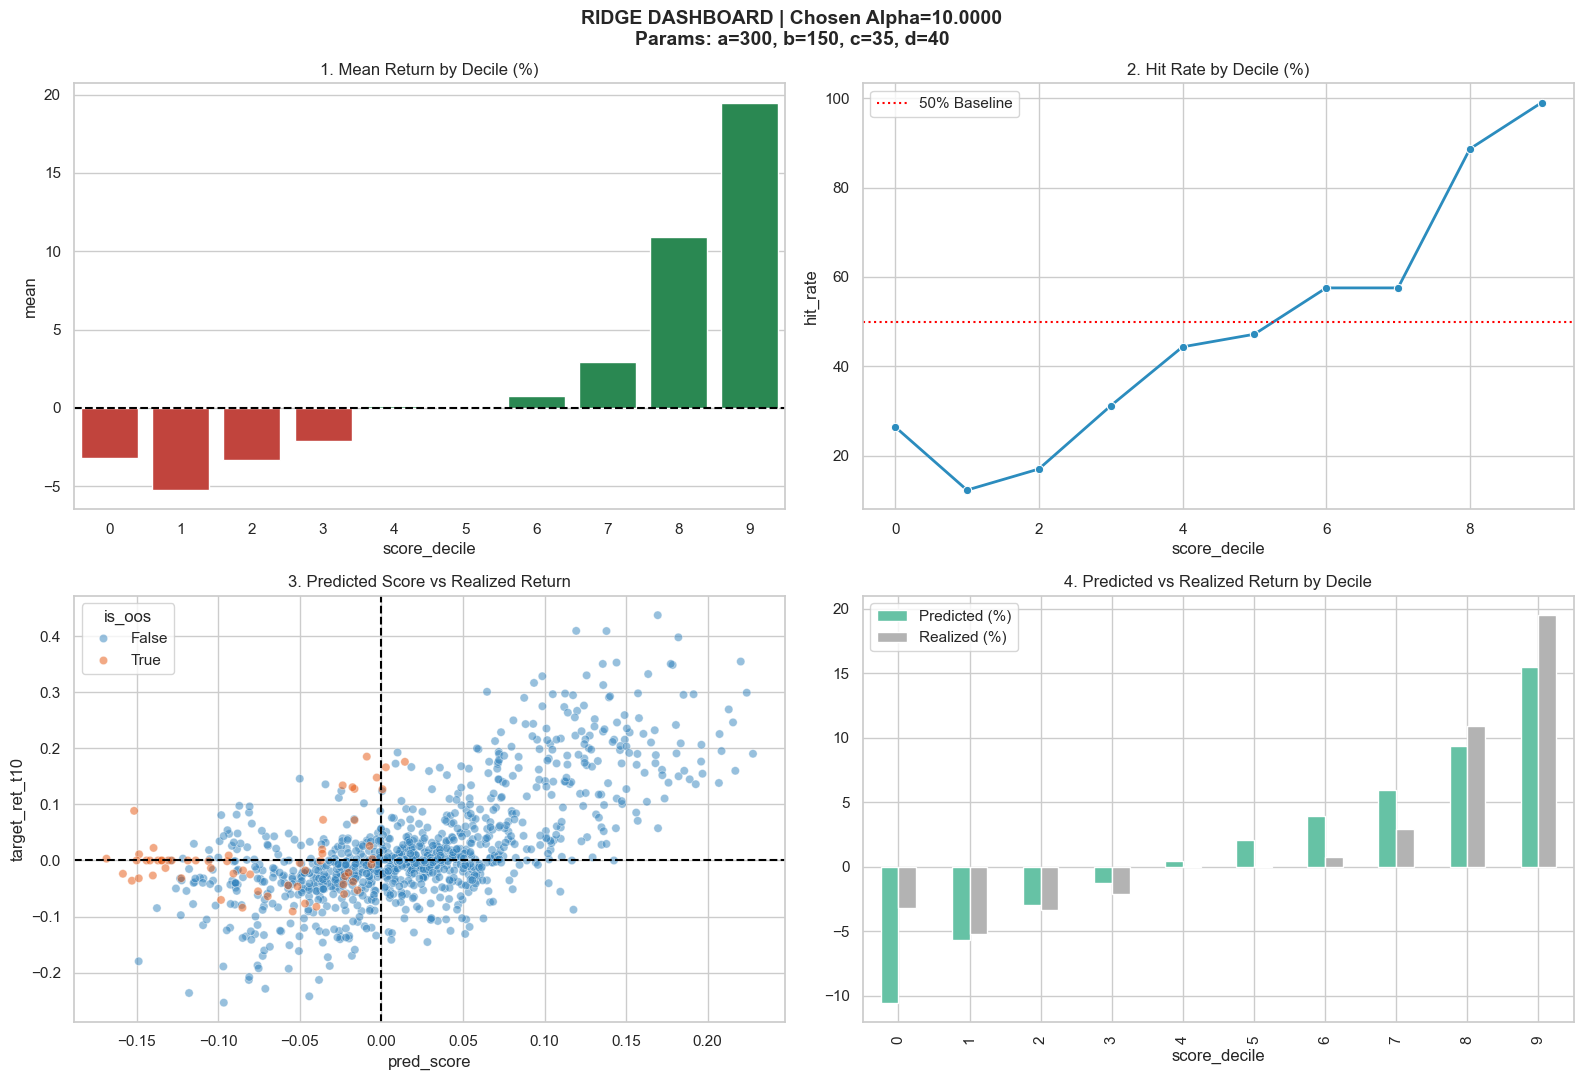

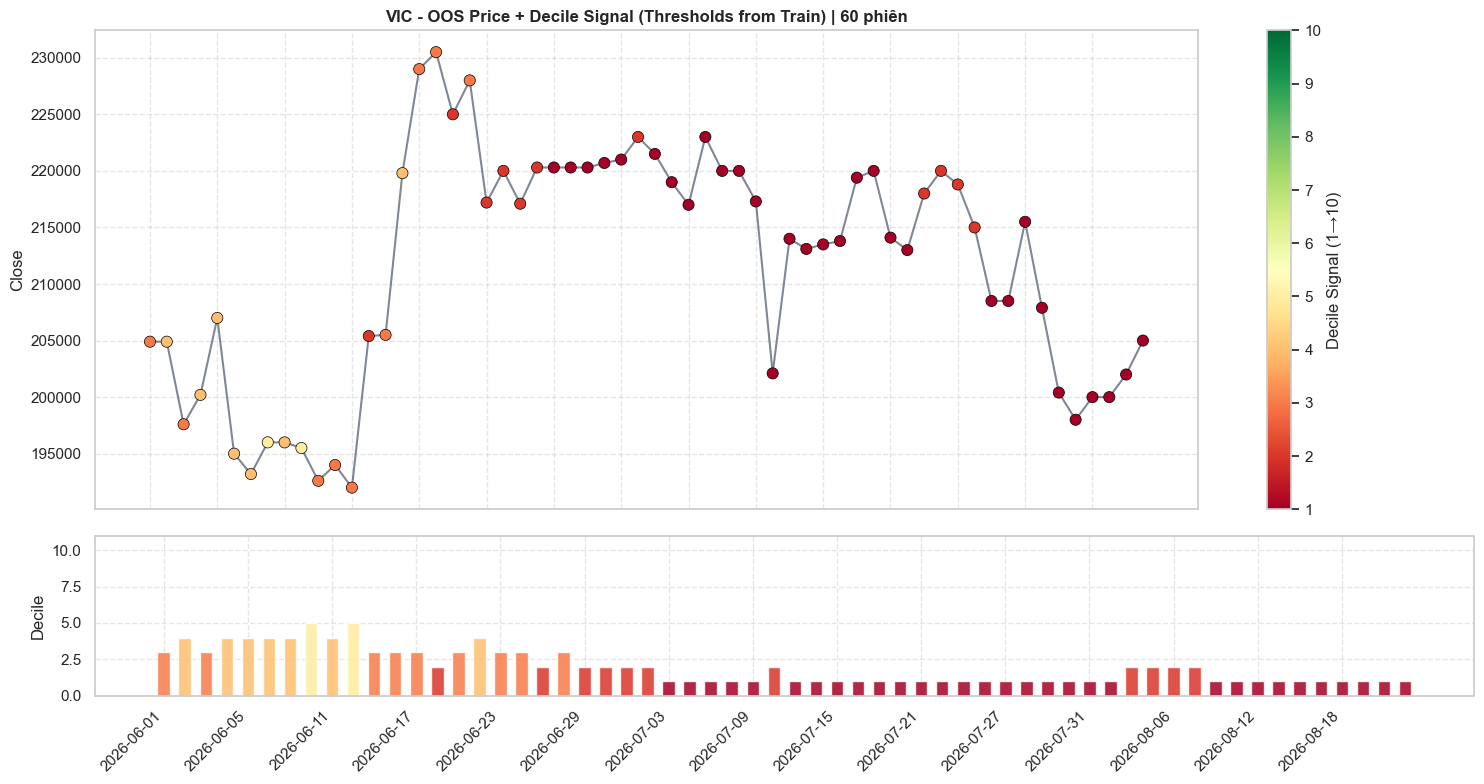

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import seaborn as sns
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import RobustScaler

SYMBOL = globals().get('SYMBOL', 'VN-INDEX')

# 1. LẤY BEST PARAMS TỪ OPTUNA
best = study.best_trial
a = best.user_attrs['a']
b = best.user_attrs['b']
c = best.user_attrs['c']
d = best.user_attrs['d']

y_col = 'target_ret_t10'

# 2. TẠO DỮ LIỆU & CẮT TRAIN/OOS THEO ĐÚNG MẪU
model_data, X_cols = build_features(df_vni_raw, a, b, c, d, investor_groups)

train_data = model_data.iloc[-(LOOKBACK_DAYS + OOS_DAYS) : -OOS_DAYS].copy()
oos_data = model_data.iloc[-OOS_DAYS:].copy()

X_train = train_data[X_cols].values
y_train = train_data[y_col].values
X_oos = oos_data[X_cols].values
y_oos = oos_data[y_col].values

# 3. SCALING BẰNG ROBUSTSCALER VÀ MẪU TRỌNG SỐ TỰA MẪU
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_oos_scaled = scaler.transform(X_oos)

half_life_days = 252
decay_rate = np.log(2) / half_life_days
time_indices = np.arange(len(y_train))
sample_weights = np.exp(decay_rate * (time_indices - (len(y_train) - 1)))

# 4. FIT RIDGECV VỚI TIMESERIES SPLIT VÀ SAMPLE WEIGHTS
tscv = TimeSeriesSplit(n_splits=3)
model = RidgeCV(
    alphas=ALPHAS, cv=tscv, scoring='neg_mean_squared_error'
)
model.fit(X_train_scaled, y_train, sample_weight=sample_weights)

chosen_alpha = float(model.alpha_)

train_data = train_data.copy()
train_data['pred_score'] = model.predict(X_train_scaled)
train_data['actual_ret'] = y_train

ic_train, _ = spearmanr(train_data['pred_score'], train_data['actual_ret'])
mask_train_pos = train_data['pred_score'] > 0
hit_train = (
    (train_data.loc[mask_train_pos, 'actual_ret'] > 0).mean()
    if mask_train_pos.sum() > 0
    else 0.0
)

print('=' * 70)
print(f'BEST TRIAL RESULTS (RidgeCV - alpha={chosen_alpha:.4f})')
print('=' * 70)
print(f'TRAIN -> IC: {ic_train:.4f} | Hit Rate: {hit_train:.4f}')

# 5. ĐÁNH GIÁ OOS
if len(oos_data) > 0:
  oos_data = oos_data.copy()
  oos_data['pred_score'] = model.predict(X_oos_scaled)
  oos_data['actual_ret'] = y_oos

  ic_oos, _ = spearmanr(oos_data['pred_score'], oos_data['actual_ret'])
  mask_oos_pos = oos_data['pred_score'] > 0
  hit_oos = (
      (oos_data.loc[mask_oos_pos, 'actual_ret'] > 0).mean()
      if mask_oos_pos.sum() > 0
      else 0.0
  )
  print(
      f'OOS   -> IC: {ic_oos:.4f} | Hit Rate: {hit_oos:.4f} | Signals:'
      f' {mask_oos_pos.sum()}'
  )

import numpy as np
import pandas as pd
from scipy.stats import kendalltau, spearmanr


def check_decile_monotonicity(eval_data, y_col='target_ret_t10', n_bins=10):
  """Kiểm tra tính đơn điệu của các nhóm Decile theo Score dự báo.

  Parameters:
  -----------
  eval_data : pd.DataFrame
      Chứa cột 'pred_score' và cột y_col (target return).
  y_col : str
      Tên cột lợi nhuận mục tiêu.
  n_bins : int
      Số lượng decile (mặc định 10).

  Returns:
  --------
  analysis : pd.DataFrame
      Bảng thống kê từng Decile.
  metrics : dict
      Các chỉ số đo lường tính đơn điệu.
  """
  df_eval = eval_data.copy()

  # 1. Phân chia Decile
  df_eval['score_decile'] = pd.qcut(
      df_eval['pred_score'], n_bins, labels=False, duplicates='drop'
  )

  # 2. Thống kê theo từng Decile
  analysis = df_eval.groupby('score_decile')[y_col].agg(
      ['mean', 'std', 'count']
  )
  analysis['hit_rate'] = df_eval.groupby('score_decile')[y_col].apply(
      lambda x: (x > 0).mean()
  )
  analysis['avg_pred'] = df_eval.groupby('score_decile')['pred_score'].mean()

  # 3. Tính toán các chỉ số đơn điệu (Monotonicity Metrics)
  decile_indices = analysis.index.values
  mean_returns = analysis['mean'].values
  hit_rates = analysis['hit_rate'].values

  # a. Spearman Correlation giữa thứ hạng Decile và Mean Return
  spearman_corr, spearman_p = spearmanr(decile_indices, mean_returns)

  # b. Kendall's Tau
  kendall_corr, kendall_p = kendalltau(decile_indices, mean_returns)

  # c. Monotonic Step Ratio (Tỷ lệ bước tăng liên tục: D_{i+1} > D_i)
  diffs = np.diff(mean_returns)
  monotonic_steps_count = np.sum(diffs > 0)
  total_steps = len(diffs)
  monotonic_step_ratio = monotonic_steps_count / total_steps

  # d. Chênh lệch Spread (Decile top - Decile bottom)
  long_short_spread = (
      mean_returns[-1] - mean_returns[0]
  )  # Top Decile - Bottom Decile

  metrics = {
      'spearman_monotonicity_ic': spearman_corr,
      'spearman_p_value': spearman_p,
      'kendall_tau': kendall_corr,
      'monotonic_step_ratio': monotonic_step_ratio,
      'monotonic_steps': f'{monotonic_steps_count}/{total_steps}',
      'long_short_spread': long_short_spread,
  }

  return analysis, metrics

# ============================================================
# KIỂM TRA TÍNH ĐƠN ĐIỆU (MONOTONICITY EVALUATION)
# ============================================================
eval_data = (
    pd.concat([
        train_data[['pred_score', y_col]].assign(is_oos=False),
        (
            oos_data[['pred_score', y_col]].assign(is_oos=True)
            if len(oos_data) > 0
            else pd.DataFrame()
        ),
    ],
              axis=0)
    .dropna()
)

# Gọi hàm kiểm tra tính đơn điệu
analysis_df, mono_metrics = check_decile_monotonicity(
    eval_data, y_col=y_col, n_bins=10
)

print('=' * 70)
print('ĐÁNH GIÁ TÍNH ĐƠN ĐIỆU CỦA DECILE (MONOTONICITY METRICS)')
print('=' * 70)
print(
    f"1. Decile Spearman Monotonicity IC : {mono_metrics['spearman_monotonicity_ic']:.4f} (p-val: {mono_metrics['spearman_p_value']:.4f})"
)
print(
    f"2. Kendall's Tau                   : {mono_metrics['kendall_tau']:.4f}"
)
print(
    f"3. Monotonic Step Ratio            : {mono_metrics['monotonic_step_ratio']*100:.1f}% ({mono_metrics['monotonic_steps']} bước tăng)"
)
print(
    f"4. Long-Short Spread (D9 - D0)      : {mono_metrics['long_short_spread']*100:.2f}%\n"
)

print('--- Chi tiết từng Decile ---')
print(
    analysis_df[['mean', 'hit_rate', 'avg_pred']].rename(
        columns={
            'mean': 'Realized_Ret_Mean',
            'hit_rate': 'Hit_Rate',
            'avg_pred': 'Pred_Score_Mean',
        }
    )
)


# 6. DECILE ANALYSIS & DASHBOARD
eval_data = pd.concat([
    train_data[['pred_score', y_col]].assign(is_oos=False),
    oos_data[['pred_score', y_col]].assign(is_oos=True),
]).dropna()

eval_data['score_decile'] = pd.qcut(
    eval_data['pred_score'], 10, labels=False, duplicates='drop'
)
analysis = eval_data.groupby('score_decile')[y_col].agg(
    ['mean', 'std', 'count']
)
analysis['hit_rate'] = eval_data.groupby('score_decile')[y_col].apply(
    lambda x: (x > 0).mean()
)
analysis['avg_pred'] = eval_data.groupby('score_decile')['pred_score'].mean()

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    f'RIDGE DASHBOARD | Chosen Alpha={chosen_alpha:.4f}\nParams: a={a}, b={b},'
    f' c={c}, d={d}',
    fontsize=14,
    fontweight='bold',
)

colors = ['#d73027' if x < 0 else '#1a9850' for x in analysis['mean']]
sns.barplot(
    x=analysis.index, y=analysis['mean'] * 100, ax=axes[0, 0], palette=colors
)
axes[0, 0].axhline(0, color='black', ls='--')
axes[0, 0].set_title('1. Mean Return by Decile (%)')

sns.lineplot(
    x=analysis.index,
    y=analysis['hit_rate'] * 100,
    ax=axes[0, 1],
    marker='o',
    color='#2b8cbe',
    lw=2,
)
axes[0, 1].axhline(50, color='red', ls=':', label='50% Baseline')
axes[0, 1].set_title('2. Hit Rate by Decile (%)')
axes[0, 1].legend()

sns.scatterplot(
    data=eval_data,
    x='pred_score',
    y=y_col,
    hue='is_oos',
    ax=axes[1, 0],
    alpha=0.5,
    palette={False: '#3182bd', True: '#e6550d'},
)
axes[1, 0].axhline(0, color='black', ls='--')
axes[1, 0].axvline(0, color='black', ls='--')
axes[1, 0].set_title('3. Predicted Score vs Realized Return')

pd.DataFrame({
    'Predicted (%)': analysis['avg_pred'] * 100,
    'Realized (%)': analysis['mean'] * 100,
}).plot(kind='bar', ax=axes[1, 1], colormap='Set2')
axes[1, 1].set_title('4. Predicted vs Realized Return by Decile')

plt.tight_layout()
plt.show()

# ============================================================
# 7. BIỂU ĐỒ GIÁ + DECILE OOS (Dùng ngưỡng từ TRAIN)
# ============================================================
if len(oos_data) > 0:
  train_scores = train_data['pred_score']
  _, bin_edges = pd.qcut(train_scores, q=10, duplicates='drop', retbins=True)
  bin_edges = bin_edges.copy()
  bin_edges[0] = -np.inf
  bin_edges[-1] = np.inf
  n_deciles = len(bin_edges) - 1

  oos_data = oos_data.copy()
  oos_data['decile'] = (
      pd.cut(
          oos_data['pred_score'],
          bins=bin_edges,
          labels=False,
          include_lowest=True,
      )
      + 1
  )

  # Xác định nhãn thời gian
  if 'time' in df_vni_raw.columns:
    raw_dates = df_vni_raw.loc[oos_data.index, 'time']
  else:
    raw_dates = oos_data.index

  if pd.api.types.is_datetime64_any_dtype(raw_dates):
    x_dates = pd.to_datetime(raw_dates).dt.strftime('%Y-%m-%d').values
  else:
    x_dates = pd.to_datetime(raw_dates).astype(str).values

  fig, (ax1, ax2) = plt.subplots(
      2,
      1,
      figsize=(15, 8),
      sharex=True,
      gridspec_kw={'height_ratios': [3, 1]},
  )

  ax1.plot(
      x_dates,
      oos_data['close'],
      color='#4A5568',
      lw=1.5,
      alpha=0.7,
      label='Close Price',
  )
  sc = ax1.scatter(
      x_dates,
      oos_data['close'],
      c=oos_data['decile'],
      cmap='RdYlGn',
      vmin=1,
      vmax=n_deciles,
      s=65,
      zorder=5,
      edgecolors='black',
      linewidth=0.5,
  )
  ax1.set_title(
      f'{SYMBOL} - OOS Price + Decile Signal (Thresholds from Train) |'
      f' {len(oos_data)} phiên',
      fontweight='bold',
  )
  ax1.set_ylabel('Close')
  ax1.grid(True, ls='--', alpha=0.5)
  plt.colorbar(sc, ax=ax1, label=f'Decile Signal (1→{n_deciles})')

  norm = (n_deciles - 1) if n_deciles > 1 else 1
  bar_colors = plt.cm.RdYlGn((oos_data['decile'] - 1) / norm)
  ax2.bar(x_dates, oos_data['decile'], color=bar_colors, alpha=0.85, width=0.6)
  ax2.set_ylabel('Decile')
  ax2.set_ylim(0, n_deciles + 1)
  ax2.grid(True, ls='--', alpha=0.5)
  plt.xticks(
      rotation=45,
      ha='right',
      ticks=range(0, len(x_dates), max(1, len(x_dates) // 15)),
  )

  plt.tight_layout()
  plt.show()

# Code ploty

In [ ]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import optuna
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ============================================================
# CẤU HÌNH
# ============================================================
DATA_DIR = r"E:\hoctap\NLP\source_ck\data\csv_data"
RESULT_PATH = r"E:\hoctap\NLP\source_ck\data\optuna_results_all_symbols.csv"

LOOKBACK_DAYS = 1000
OOS_DAYS = 60
TRIALS = 200               # giảm để chạy nhanh 100 mã (có thể tăng sau)

A_MIN, A_MAX = 20, 300
B_MIN, B_MAX = 20, 300
C_MIN, C_MAX = 15, 60
D_MIN, D_MAX = 5, 40

ALPHAS = np.logspace(-1, 3, 12)   # 0.1 → 1000

W_HIT = 0.60
W_IC  = 0.40

MIN_SIGNALS_TRAIN_SOFT = 30
MIN_SIGNALS_TRAIN_HARD = 15
MIN_HIT_TRAIN_SOFT = 0.55
MIN_HIT_TRAIN_HARD = 0.52
MIN_SIGNALS_OOS = 6
MAX_GAP = 0.25
MIN_OOS_IC_HARD = -0.08

investor_groups = ["foreign", "prop", "local_inst", "local_ind"]
# ============================================================
# Hàm evaluate (giữ nguyên logic bạn đang dùng)
# ============================================================
def evaluate_params_ridge(
    a, b, c, d,
    df_vni_raw,
    investor_groups,
    lookback_days=LOOKBACK_DAYS,
    oos_days=OOS_DAYS,
    min_signals=5,
):
    try:
        df = df_vni_raw.copy()

        keep_cols = [
            'open', 'high', 'low', 'close', 'trading_value',
            'foreign_net_val', 'prop_net_val', 'local_ind_net_val', 'local_inst_net_val',
            'foreign_net_vol', 'prop_net_vol', 'local_ind_net_vol', 'local_inst_net_vol',
        ]
        keep_cols = [col for col in keep_cols if col in df.columns]
        df = df[keep_cols]

        df['trading_value'] = df['trading_value'].replace(0, np.nan).interpolate()
        df['close'] = df['close'].ffill()
        df['log_ret'] = np.log(df['close'] / df['close'].shift(1)).fillna(0)
        df['abs_ret'] = df['log_ret'].abs()

        tr = np.maximum(
            df['high'] - df['low'],
            np.maximum(
                (df['high'] - df['close'].shift(1)).abs(),
                (df['low'] - df['close'].shift(1)).abs()
            )
        )
        df['target_ret_t10'] = df['close'].shift(-10) / df['close'] - 1

        for g in investor_groups:
            net_val = df[f'{g}_net_val']
            net_ratio = net_val / df['trading_value']
            df[f'feat_{g}_net_ratio'] = net_ratio.fillna(0)

            prev = net_ratio.shift(1).abs()
            df[f'feat_{g}_price_impact'] = (df['abs_ret'].shift(1) / (prev + 1e-6)).rolling(5).median()

            mu = df[f'feat_{g}_net_ratio'].rolling(a).mean()
            sigma = df[f'feat_{g}_net_ratio'].rolling(a).std()
            df[f'feat_{g}_zscore'] = ((df[f'feat_{g}_net_ratio'] - mu) / (sigma + 1e-8)).clip(-4, 4).fillna(0)

            rmin = net_val.rolling(a).min()
            rmax = net_val.rolling(a).max()
            df[f'feat_{g}_sentiment'] = (2 * (net_val - rmin) / (rmax - rmin + 1e-6) - 1).fillna(0)

        df = df.replace([np.inf, -np.inf], 0).fillna(0)

        # ===================== FEATURE FACTORY =====================
        feature_dict = {}

        delta = df["close"].diff()
        gain = delta.clip(lower=0).rolling(14).mean()
        loss = (-delta.clip(upper=0)).rolling(14).mean()
        rs = gain / (loss + 1e-8)
        rsi = 100 - (100 / (1 + rs))
        feature_dict["ta_rsi_norm"] = (rsi / 100.0) - 0.5

        ma20 = df["close"].rolling(20).mean()
        feature_dict["ta_dist_ma20"] = (df["close"] - ma20) / ma20

        roll_high = df["high"].rolling(c).max()
        roll_low = df["low"].rolling(c).min()
        feature_dict["ta_pos_in_range"] = (df["close"] - roll_low) / (roll_high - roll_low + 1e-8)

        feature_dict["ta_atr_pct"] = tr.ewm(span=b, adjust=False).mean() / df["close"]

        for g in investor_groups:
            sent = df[f"feat_{g}_sentiment"]
            sent_ewm = sent.ewm(span=b, adjust=False).mean()
            feature_dict[f"feat_{g}_sentiment_ewm"] = sent_ewm

            sent_mean = sent_ewm.rolling(a, min_periods=10).mean()
            sent_std = sent_ewm.rolling(a, min_periods=10).std().replace(0, np.nan)
            sent_z = ((sent_ewm - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

            # feature_dict[f"feat_{g}_sentiment_sq"] = sent_z**2
            feature_dict[f"feat_{g}_sentiment_cubed"] = (sent_z**3 - 3 * sent_z).clip(-10, 10)

            impulse = sent_ewm.diff(d).fillna(0)
            feature_dict[f"feat_{g}_flow_impulse_{d}d"] = impulse

            imp_mean = impulse.rolling(a, min_periods=10).mean()
            imp_std = impulse.rolling(a, min_periods=10).std().replace(0, np.nan)
            imp_z = ((impulse - imp_mean) / (imp_std + 1e-6)).clip(-3, 3).fillna(0)

            # feature_dict[f"feat_{g}_flow_impulse_{d}d_sq"] = imp_z**2
            feature_dict[f"feat_{g}_flow_impulse_{d}d_cubed"] = (imp_z**3 - 3 * imp_z).clip(-10, 10)

            feature_dict[f"feat_{g}_eff_flow"] = sent * df[f"feat_{g}_price_impact"]
            feature_dict[f"feat_{g}_val_share"] = df[f"{g}_net_val"].abs() / df["trading_value"]

            implied = np.where(df[f"{g}_net_vol"] != 0, df[f"{g}_net_val"] / df[f"{g}_net_vol"], 0)
            feature_dict[f"feat_{g}_rel_net_price_ewm"] = (
                pd.Series(implied / df["close"], index=df.index).ewm(span=b, adjust=False).mean()
            )

            feature_dict[f"inter_{g}_sent_x_pos"]    = sent_z * feature_dict["ta_pos_in_range"]
            # feature_dict[f"inter_{g}_sent_x_rsi"]    = sent_z * feature_dict["ta_rsi_norm"]
            feature_dict[f"inter_{g}_sent_x_distma"] = sent_z * feature_dict["ta_dist_ma20"]
            # feature_dict[f"inter_{g}_imp_x_atr"]     = imp_z  * feature_dict["ta_atr_pct"]
            feature_dict[f"inter_{g}_eff_x_pos"]     = feature_dict[f"feat_{g}_eff_flow"] * feature_dict["ta_pos_in_range"]
            feature_dict[f"inter_{g}_sent_x_atr"]    = sent_z * feature_dict["ta_atr_pct"]
        # ============================================================
        # CROSS-INVESTOR FEATURES (Toàn bộ mối quan hệ)
        # ============================================================
        groups = investor_groups  # ["foreign", "prop", "local_inst", "local_ind"]

        # Lấy các series đã có
        sent_ewm = {g: feature_dict[f"feat_{g}_sentiment_ewm"] for g in groups}
        sent_z   = {}
        for g in groups:
            # tái tạo sent_z nếu cần (hoặc lấy từ biến đã tính trước đó)
            sent = df[f"feat_{g}_sentiment"]
            sent_ewm_g = sent.ewm(span=b, adjust=False).mean()
            sent_mean = sent_ewm_g.rolling(a, min_periods=10).mean()
            sent_std  = sent_ewm_g.rolling(a, min_periods=10).std().replace(0, np.nan)
            sent_z[g] = ((sent_ewm_g - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

        net_ratio = {g: df[f"feat_{g}_net_ratio"] for g in groups}

        # ----------------------------------------------------------
        # 1. Relative Flow (chênh lệch) – tất cả cặp
        # ----------------------------------------------------------
        from itertools import combinations

        for g1, g2 in combinations(groups, 2):
            # Chênh lệch sentiment EWM
            feature_dict[f"cross_{g1}_minus_{g2}_sent"] = sent_ewm[g1] - sent_ewm[g2]
            
            # Chênh lệch z-score
            feature_dict[f"cross_{g1}_minus_{g2}_sent_z"] = sent_z[g1] - sent_z[g2]
            
            # Chênh lệch net_ratio
            feature_dict[f"cross_{g1}_minus_{g2}_net"] = net_ratio[g1] - net_ratio[g2]
            
            # Absolute difference (độ lớn sự khác biệt)
            # feature_dict[f"cross_abs_{g1}_{g2}_sent"] = (sent_ewm[g1] - sent_ewm[g2]).abs()

        # ----------------------------------------------------------
        # 2. Agreement / Disagreement
        # ----------------------------------------------------------
        for g1, g2 in combinations(groups, 2):
            # Cùng chiều hay ngược chiều (sign agreement)
            sign_agree = np.sign(sent_ewm[g1]) * np.sign(sent_ewm[g2])
            feature_dict[f"cross_agree_sign_{g1}_{g2}"] = sign_agree
            
            # Strength-weighted agreement (càng lớn càng đồng thuận mạnh)
            feature_dict[f"cross_agree_strength_{g1}_{g2}"] = sent_ewm[g1] * sent_ewm[g2]
            
        #     # Disagreement magnitude
        #     feature_dict[f"cross_disagree_{g1}_{g2}"] = (sent_ewm[g1] - sent_ewm[g2]).abs() * (1 - sign_agree.abs())

        # ----------------------------------------------------------
        # 3. Dispersion (độ phân tán giữa tất cả nhóm)
        # ----------------------------------------------------------
        # Stack tất cả sentiment_ewm
        sent_matrix = pd.concat([sent_ewm[g] for g in groups], axis=1)
        sent_matrix.columns = groups

        feature_dict["cross_dispersion_std"] = sent_matrix.std(axis=1)           # độ lệch chuẩn giữa 4 nhóm
        feature_dict["cross_dispersion_range"] = sent_matrix.max(axis=1) - sent_matrix.min(axis=1)  # range
        feature_dict["cross_dispersion_iqr"] = sent_matrix.quantile(0.75, axis=1) - sent_matrix.quantile(0.25, axis=1)

        # # Dispersion của net_ratio
        # net_matrix = pd.concat([net_ratio[g] for g in groups], axis=1)
        # net_matrix.columns = groups
        # feature_dict["cross_net_dispersion_std"] = net_matrix.std(axis=1)
        # feature_dict["cross_net_dispersion_range"] = net_matrix.max(axis=1) - net_matrix.min(axis=1)

        # ----------------------------------------------------------
        # 4. Dominance Ratio (tỷ trọng dòng tiền)
        # ----------------------------------------------------------
        total_abs_net = sum(df[f"{g}_net_val"].abs() for g in groups) + 1e-8

        for g in groups:
            feature_dict[f"cross_dominance_{g}"] = df[f"{g}_net_val"].abs() / total_abs_net

        # # Dominance của nhóm tổ chức vs cá nhân
        # inst_abs = df["local_inst_net_val"].abs() + df["foreign_net_val"].abs()
        # ind_abs  = df["local_ind_net_val"].abs() + df["prop_net_val"].abs()
        # feature_dict["cross_dominance_inst_vs_ind"] = (inst_abs - ind_abs) / (inst_abs + ind_abs + 1e-8)

        # # ----------------------------------------------------------
        # # 5. Pairwise rolling agreement (tương quan ngắn hạn)
        # # ----------------------------------------------------------
        # for g1, g2 in combinations(groups, 2):
        #     # Rolling correlation của sentiment (cửa sổ cố định 10 & 20)
        #     for win in [10, 20]:
        #         corr = sent_ewm[g1].rolling(win, min_periods=5).corr(sent_ewm[g2])
        #         feature_dict[f"cross_corr_{g1}_{g2}_{win}d"] = corr.fillna(0)

        # # ----------------------------------------------------------
        # # 6. Net Pressure & Composite Signals
        # # ----------------------------------------------------------
        # # Tổng dòng tiền có trọng số (foreign + local_inst mạnh hơn)
        # feature_dict["cross_net_pressure_smart"] = (
        #     1.5 * sent_ewm["foreign"] +
        #     1.2 * sent_ewm["local_inst"] +
        #     1.0 * sent_ewm["prop"] +
        #     0.7 * sent_ewm["local_ind"]
        # )

        # # Pure institutional pressure
        # feature_dict["cross_inst_pressure"] = sent_ewm["foreign"] + sent_ewm["local_inst"]

        # # Pure retail pressure
        # feature_dict["cross_retail_pressure"] = sent_ewm["prop"] + sent_ewm["local_ind"]

        # # Smart vs Retail
        # feature_dict["cross_smart_minus_retail"] = (
        #     feature_dict["cross_inst_pressure"] - feature_dict["cross_retail_pressure"]
        # )

        # # ----------------------------------------------------------
        # # 7. Extreme Disagreement flags (optional, có thể hữu ích)
        # # ----------------------------------------------------------
        # feature_dict["cross_extreme_disagree"] = (
        #     (feature_dict["cross_dispersion_std"] > feature_dict["cross_dispersion_std"].rolling(60).quantile(0.9))
        # ).astype(float)

        df_feat = pd.DataFrame(feature_dict, index=df.index)
        model_data = pd.concat([df_feat, df["target_ret_t10"]], axis=1)
        model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()

        if len(model_data) < (lookback_days + oos_days + 50):
            return -999.0, -1.0, 0.0, 0.0, 0, 0.0, -1.0, -1.0, 999.0

        # ----- Tách Train / OOS -----
        train_data = model_data.iloc[-(lookback_days + oos_days):-oos_days].copy()
        oos_data   = model_data.iloc[-oos_days:].copy()

        if len(train_data) < 300 or len(oos_data) < 10:
            return -999.0, -1.0, 0.0, 0.0, 0, 0.0, -1.0, -1.0, 999.0

        X_train = train_data.drop(columns=["target_ret_t10"]).values
        y_train = train_data["target_ret_t10"].values
        X_oos   = oos_data.drop(columns=["target_ret_t10"]).values
        y_oos   = oos_data["target_ret_t10"].values

        # ----- Scale -----
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_oos_scaled   = scaler.transform(X_oos)

        # ============================================================
        # METRICS + SCORE
        # ============================================================
        # ============================================================
        # MODEL (chỉ fit trên Train)
        # ============================================================
        model = RidgeCV(alphas=ALPHAS, cv=3, scoring="neg_mean_squared_error")
        model.fit(X_train_scaled, y_train)
        chosen_alpha = float(model.alpha_)

        pred_train = model.predict(X_train_scaled)
        pred_oos   = model.predict(X_oos_scaled)

        # ============================================================
        # METRICS TRÊN TRAIN (dùng để tính SCORE chính)
        # ============================================================
        train_ic, _ = spearmanr(pred_train, y_train)
        if np.isnan(train_ic):
            train_ic = -1.0

        mask_up_train = pred_train > 0
        n_signals_train = int(mask_up_train.sum())

        if n_signals_train >= MIN_SIGNALS_TRAIN_HARD:
            hit_rate_train = (y_train[mask_up_train] > 0).mean()
            avg_ret_train = float(y_train[mask_up_train].mean())
        else:
            hit_rate_train = 0.50
            avg_ret_train = 0.0

        # ============================================================
        # METRICS TRÊN OOS (chỉ để giám sát)
        # ============================================================
        oos_ic, _ = spearmanr(pred_oos, y_oos)
        if np.isnan(oos_ic):
            oos_ic = -1.0

        mask_up_oos = pred_oos > 0
        n_signals_oos = int(mask_up_oos.sum())

        if n_signals_oos >= 3:
            hit_rate_oos = (y_oos[mask_up_oos] > 0).mean()
            avg_ret_oos = float(y_oos[mask_up_oos].mean())
        else:
            hit_rate_oos = 0.50
            avg_ret_oos = 0.0

        train_oos_gap = train_ic - oos_ic

        # ============================================================
        # SCORE CHÍNH (dựa trên TRAIN)
        # ============================================================
        hit_term = (hit_rate_train - 0.50) * 2.0
        ic_term  = np.clip(train_ic, -0.15, 0.60)

        score = W_HIT * hit_term + W_IC * ic_term

        # Thưởng nhẹ lợi nhuận trên train
        if avg_ret_train > 0:
            score += 0.03 * np.clip(avg_ret_train * 8, 0, 0.25)

        # Soft penalty trên Train
        if n_signals_train < MIN_SIGNALS_TRAIN_SOFT:
            score *= 0.75
        if hit_rate_train < MIN_HIT_TRAIN_SOFT:
            score *= 0.80

        # ============================================================
        # GIÁM SÁT OOS (chỉ phạt nhẹ hoặc loại khi quá tệ)
        # ============================================================
        # Phạt nếu gap quá lớn (overfit rõ)
        if train_oos_gap > MAX_GAP:
            score *= 0.70

        # Phạt nếu OOS quá kém
        if oos_ic < 0:
            score *= 0.80
        if n_signals_oos < MIN_SIGNALS_OOS:
            score *= 0.85

        # Hard filter (chỉ loại những case thực sự xấu)
        if (
            n_signals_train < MIN_SIGNALS_TRAIN_HARD
            or hit_rate_train < MIN_HIT_TRAIN_HARD
            or oos_ic < MIN_OOS_IC_HARD
        ):
            score = -999.0

        return (
            float(score),
            float(oos_ic),                 # vẫn trả OOS IC để theo dõi
            float(hit_rate_oos),           # Hit Rate OOS để theo dõi
            float(avg_ret_oos),
            n_signals_oos,
            chosen_alpha,
            float(train_ic),
            float(hit_rate_train),         # thêm hit train nếu muốn
            float(train_oos_gap),
        )
    except Exception as e:
        # Tạm thời in lỗi ra để biết nguyên nhân
        print(f"[EXCEPTION] a={a}, b={b}, c={c}, d={d} → {type(e).__name__}: {e}")
        return -999.0, -1.0, 0.0, 0.0, 0, 0.0, -1.0, -1.0, 999.0


def run_optuna_for_symbol(symbol: str, df: pd.DataFrame):
    def objective(trial):
        a = trial.suggest_int("window_z", A_MIN, A_MAX, step=10)
        b = trial.suggest_int("window_div", B_MIN, B_MAX, step=10)
        c = trial.suggest_int("pos_range", C_MIN, C_MAX, step=5)
        d = trial.suggest_int("impulse_days", D_MIN, D_MAX, step=5)

        result = evaluate_params_ridge(a, b, c, d, df, investor_groups)
        score, oos_ic, hit_up, avg_ret, n_sig, chosen_alpha, train_ic, hit_train, gap = result

        trial.set_user_attr("oos_ic", oos_ic)
        trial.set_user_attr("hit_rate_oos", hit_up)
        trial.set_user_attr("n_signals", n_sig)
        trial.set_user_attr("chosen_alpha", chosen_alpha)
        trial.set_user_attr("train_ic", train_ic)
        trial.set_user_attr("hit_rate_train", hit_train)
        trial.set_user_attr("train_oos_gap", gap)
        trial.set_user_attr("a", a)
        trial.set_user_attr("b", b)
        trial.set_user_attr("c", c)
        trial.set_user_attr("d", d)
        return score

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=20)
    )
    study.optimize(objective, n_trials=TRIALS, show_progress_bar=False)

    best = study.best_trial
    if best.value is None or best.value < -900:
        return None

    return {
        "symbol": symbol,
        "score": best.value,
        "oos_ic": best.user_attrs["oos_ic"],
        "train_ic": best.user_attrs["train_ic"],
        "train_oos_gap": best.user_attrs["train_oos_gap"],
        "hit_rate_oos": best.user_attrs["hit_rate_oos"],
        "hit_rate_train": best.user_attrs["hit_rate_train"],
        "n_signals": best.user_attrs["n_signals"],
        "chosen_alpha": best.user_attrs["chosen_alpha"],
        "a": best.user_attrs["a"],
        "b": best.user_attrs["b"],
        "c": best.user_attrs["c"],
        "d": best.user_attrs["d"],
        "alpha_is_high": best.user_attrs["chosen_alpha"] >= 800,
    }


# ============================================================
# CHẠY HÀNG LOẠT
# ============================================================
def load_and_map_excel(excel_path, df_history=None):
    """
    Đọc file Excel mới, chuyển đổi format và gộp với dữ liệu lịch sử.
    """
    # 1. Đọc Excel
    df_new = pd.read_csv(excel_path)
    
    # 2. Mapping cột Tiếng Việt -> English
    mapping = {
        'NGÀY': 'time',
        'GIÁ': 'close',
        'MỞ': 'open',
        'CAO': 'high',
        'THẤP': 'low',
        'KL KHỚP': 'volume',
        'GT KHỚP': 'trading_value',
        'GT Nước Ngoài Khớp Ròng': 'foreign_net_val',
        'GT Tự doanh Khớp Ròng': 'prop_net_val',
        'GT Cá Nhân Khớp Ròng': 'local_ind_net_val',
        'GT Tổ chức Khớp Ròng': 'local_inst_net_val',
        'KL Nước Ngoài Khớp Ròng': 'foreign_net_vol',
        'KL Tự doanh Khớp Ròng': 'prop_net_vol',
        'KL Cá Nhân Khớp Ròng': 'local_ind_net_vol',
        'KL Tổ chức Khớp Ròng': 'local_inst_net_vol',
    }
    
    df_new = df_new.rename(columns=mapping)
    df_new['time'] = pd.to_datetime(df_new['time'], format='%d/%m/%Y')
    
    if df_history is not None and not df_history.empty:
        df_combined = pd.concat([df_history, df_new], axis=0).drop_duplicates(subset=['time']).sort_values('time')
        return df_combined.reset_index(drop=True)
    
    return df_new.drop_duplicates(subset=['time']).sort_values('time').reset_index(drop=True)


def get_all_symbols(data_dir: str):
    """
    Lấy tất cả symbol từ cả 2 loại tên file
    """
    symbols = set()

    # 1. Các mã cổ phiếu (Phân loại nhà đầu tư)
    pattern1 = os.path.join(data_dir, "Kafi_Phân_Loại_Nhà_Đầu_Tư_*.csv")
    for f in glob.glob(pattern1):
        name = os.path.basename(f)
        sym = name.replace("Kafi_Phân_Loại_Nhà_Đầu_Tư_", "").replace(".csv", "")
        symbols.add(sym)

    # 2. Các index (Giá)
    pattern2 = os.path.join(data_dir, "Kafi_Giá_*.csv")
    for f in glob.glob(pattern2):
        name = os.path.basename(f)
        sym = name.replace("Kafi_Giá_", "").replace(".csv", "")
        symbols.add(sym)

    return sorted(list(symbols))


def get_file_path(symbol: str, data_dir: str):
    """
    Trả về đường dẫn file đúng theo loại symbol
    """
    # Ưu tiên tìm file Phân loại nhà đầu tư trước (cổ phiếu)
    path1 = os.path.join(data_dir, f"Kafi_Phân_Loại_Nhà_Đầu_Tư_{symbol}.csv")
    if os.path.exists(path1):
        return path1

    # Nếu không có thì tìm file Giá (index)
    path2 = os.path.join(data_dir, f"Kafi_Giá_{symbol}.csv")
    if os.path.exists(path2):
        return path2

    return None


def load_symbol_data(symbol: str, data_dir: str = DATA_DIR):
    """
    Load dữ liệu của 1 mã (dù là cổ phiếu hay index)
    """
    file_path = get_file_path(symbol, data_dir)
    if file_path is None:
        print(f"[{symbol}] Không tìm thấy file")
        return None

    try:
        # Dùng đúng hàm load của bạn
        df = load_and_map_excel(file_path, df_history=None)
        
        if df is None or len(df) < 400:
            print(f"[{symbol}] Dữ liệu quá ngắn hoặc None")
            return None
            
        return df
    except Exception as e:
        print(f"[{symbol}] Lỗi load: {e}")
        return None


if __name__ == "__main__":
    symbols = get_all_symbols(DATA_DIR)
    print(f"Tìm thấy {len(symbols)} mã: {symbols[:10]}...")

    all_results = []

    for sym in tqdm(symbols, desc="Running Optuna"):
        df = load_symbol_data(sym)
        if df is None or len(df) < 400:
            print(f"[{sym}] Bỏ qua (thiếu dữ liệu)")
            continue

        try:
            res = run_optuna_for_symbol(sym, df)
            if res is not None:
                all_results.append(res)
                print(f"[{sym}] Score={res['score']:.3f} | Alpha={res['chosen_alpha']:.1f} | Signals={res['n_signals']}")
            else:
                print(f"[{sym}] Không tìm được trial hợp lệ")
        except Exception as e:
            print(f"[{sym}] Lỗi: {e}")

    if all_results:
        df_result = pd.DataFrame(all_results)
        df_result.to_csv(RESULT_PATH, index=False)
        print(f"\nĐã lưu kết quả → {RESULT_PATH}")
        print(df_result.describe())
    else:
        print("Không có kết quả nào được lưu.")

Tìm thấy 108 mã: ['AAA', 'ACB', 'AGG', 'ANV', 'ASM', 'BAF', 'BCM', 'BID', 'BMP', 'BSI']...


Running Optuna: 100%|██████████| 108/108 [00:00<00:00, 21280.88it/s]

[AAA] Lỗi load: name 'load_and_map_excel' is not defined
[AAA] Bỏ qua (thiếu dữ liệu)
[ACB] Lỗi load: name 'load_and_map_excel' is not defined
[ACB] Bỏ qua (thiếu dữ liệu)
[AGG] Lỗi load: name 'load_and_map_excel' is not defined
[AGG] Bỏ qua (thiếu dữ liệu)
[ANV] Lỗi load: name 'load_and_map_excel' is not defined
[ANV] Bỏ qua (thiếu dữ liệu)
[ASM] Lỗi load: name 'load_and_map_excel' is not defined
[ASM] Bỏ qua (thiếu dữ liệu)
[BAF] Lỗi load: name 'load_and_map_excel' is not defined
[BAF] Bỏ qua (thiếu dữ liệu)
[BCM] Lỗi load: name 'load_and_map_excel' is not defined
[BCM] Bỏ qua (thiếu dữ liệu)
[BID] Lỗi load: name 'load_and_map_excel' is not defined
[BID] Bỏ qua (thiếu dữ liệu)
[BMP] Lỗi load: name 'load_and_map_excel' is not defined
[BMP] Bỏ qua (thiếu dữ liệu)
[BSI] Lỗi load: name 'load_and_map_excel' is not defined
[BSI] Bỏ qua (thiếu dữ liệu)
[BVH] Lỗi load: name 'load_and_map_excel' is not defined
[BVH] Bỏ qua (thiếu dữ liệu)
[BWE] Lỗi load: name 'load_and_map_excel' is not defin

Có mã chạy được có mã như cẹc

In [1]:
"""
Dashboard Plotly (Dash) cho hệ thống Optuna + Ridge nhiều mã.

Yêu cầu cài đặt:
    pip install dash plotly pandas scikit-learn scipy

Chạy:
    python dashboard_app.py
Rồi mở: http://127.0.0.1:8050

CẤU TRÚC APP
------------
1. Tab "Tổng quan": bảng + biểu đồ tổng hợp toàn bộ mã trong RESULT_PATH,
   mỗi mã được phân loại tín hiệu MỚI NHẤT dựa theo decile:
       decile 8-9  -> "Tăng mạnh"
       decile 2-7  -> "Trung tính"
       decile 0-1  -> "Giảm mạnh"
2. Tab "Chi tiết theo mã": chọn 1 mã từ dropdown -> hiển thị lại đúng những gì
   file Ridge dashboard (matplotlib) của bạn từng vẽ, nhưng bằng Plotly:
       - Dashboard 1: 4 ô (Mean Return theo Decile / Hit Rate theo Decile /
         Score vs Realized / Predicted vs Realized)
       - Dashboard 2: Giá + scatter tô màu theo decile (ngưỡng lấy từ TRAIN) + bar decile

QUAN TRỌNG: hàm `load_and_map_excel` KHÔNG có trong 2 file bạn gửi (nó được
dùng trong script batch Optuna nhưng định nghĩa nằm ở module khác của bạn).
Ở đây mình để 1 wrapper `load_and_map_excel(...)` gọi tới hàm thật của bạn -
BẠN CẦN SỬA IMPORT Ở PHẦN "LOADER DỮ LIỆU" bên dưới cho khớp với project thật.
"""

import os
import glob
import warnings
import numpy as np
import pandas as pd
from itertools import combinations
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr

import plotly.graph_objects as go
from plotly.subplots import make_subplots

import dash
from dash import dcc, html, dash_table, Input, Output

warnings.filterwarnings("ignore")

# ============================================================
# CẤU HÌNH (đồng bộ với script batch Optuna - doc 3)
# ============================================================
DATA_DIR = r"E:\hoctap\NLP\source_ck\data\csv_data"
RESULT_PATH = r"E:\hoctap\NLP\source_ck\data\optuna_results_all_symbols.csv"

LOOKBACK_DAYS = 1000
OOS_DAYS = 60

investor_groups = ["foreign", "prop", "local_inst", "local_ind"]

# ----- Ngưỡng phân loại decile (0..9, do pd.qcut labels=False) -----
DECILE_STRONG_UP = {8, 9}
DECILE_NEUTRAL = {2, 3, 4, 5, 6, 7}
DECILE_STRONG_DOWN = {0, 1}

CLASS_COLOR = {
    "Tăng mạnh": "#1a9850",
    "Trung tính": "#fee08b",
    "Giảm mạnh": "#d73027",
    "Không xác định": "#999999",
}


def classify_decile(dec):
    if dec is None or (isinstance(dec, float) and np.isnan(dec)):
        return "Không xác định"
    dec = int(dec)
    if dec in DECILE_STRONG_UP:
        return "Tăng mạnh"
    if dec in DECILE_STRONG_DOWN:
        return "Giảm mạnh"
    return "Trung tính"


# ============================================================
# LOADER DỮ LIỆU (copy từ doc 3 - CHỈNH LẠI import load_and_map_excel!)
# ============================================================
try:
    def load_and_map_excel(excel_path, df_history):
        """
        Đọc file Excel mới, chuyển đổi format và gộp với dữ liệu lịch sử.
        """
        # 1. Đọc Excel
        df_new = pd.read_csv(excel_path)
        
        # 2. Mapping cột Tiếng Việt -> English
        mapping = {
            'NGÀY': 'time',
            'GIÁ': 'close',
            'MỞ': 'open',
            'CAO': 'high',
            'THẤP': 'low',
            'KL KHỚP': 'volume',
            'GT KHỚP': 'trading_value',
            'GT Nước Ngoài Khớp Ròng': 'foreign_net_val',
            'GT Tự doanh Khớp Ròng': 'prop_net_val',
            'GT Cá Nhân Khớp Ròng': 'local_ind_net_val',
            'GT Tổ chức Khớp Ròng': 'local_inst_net_val', # Nếu cần
            'KL Nước Ngoài Khớp Ròng': 'foreign_net_vol',
            'KL Tự doanh Khớp Ròng': 'prop_net_vol',
            'KL Cá Nhân Khớp Ròng': 'local_ind_net_vol',
            'KL Tổ chức Khớp Ròng': 'local_inst_net_vol', # Nếu cần
        }
        
        df_new = df_new.rename(columns=mapping)
        df_new['time'] = pd.to_datetime(df_new['time'], format='%d/%m/%Y')
        
        # Tính toán các cột bổ trợ để không làm lỗi hàm Feature Engineering cũ
        # Vì Excel chỉ có Net, ta giả định Buy/Sell dựa trên Net để hàm không lỗi
        # for g in investor_groups:
        #     if f'{g}_net_val' in df_new.columns:
        #         # Fake buy/sell để tránh lỗi chia cho 0 khi tính sentiment
        #         # Logic: Buy = Net nếu Net > 0, Sell = |Net| nếu Net < 0
        #         df_new[f'{g}_buy_val'] = df_new[f'{g}_net_val'].apply(lambda x: x if x > 0 else 0)
        #         df_new[f'{g}_sell_val'] = df_new[f'{g}_net_val'].apply(lambda x: abs(x) if x < 0 else 0)
        
        # 3. Gộp với lịch sử để tính được các chỉ số MA20, MA50, Accu_20d
        # Chỉ lấy các cột cần thiết từ df_history
        df_combined = pd.concat([df_history, df_new], axis=0).drop_duplicates(subset=['time']).sort_values('time')
        
        return df_combined.reset_index(drop=True)
except ImportError:
    def load_and_map_excel(file_path, df_history=None):
        raise NotImplementedError(
            "Chưa import được load_and_map_excel thật của bạn. "
            "Hãy sửa phần LOADER DỮ LIỆU ở đầu file dashboard_app.py."
        )


def get_all_symbols(data_dir: str):
    symbols = set()
    pattern1 = os.path.join(data_dir, "Kafi_Phân_Loại_Nhà_Đầu_Tư_*.csv")
    for f in glob.glob(pattern1):
        name = os.path.basename(f)
        sym = name.replace("Kafi_Phân_Loại_Nhà_Đầu_Tư_", "").replace(".csv", "")
        symbols.add(sym)
    pattern2 = os.path.join(data_dir, "Kafi_Giá_*.csv")
    for f in glob.glob(pattern2):
        name = os.path.basename(f)
        sym = name.replace("Kafi_Giá_", "").replace(".csv", "")
        symbols.add(sym)
    return sorted(list(symbols))


def get_file_path(symbol: str, data_dir: str):
    path1 = os.path.join(data_dir, f"Kafi_Phân_Loại_Nhà_Đầu_Tư_{symbol}.csv")
    if os.path.exists(path1):
        return path1
    path2 = os.path.join(data_dir, f"Kafi_Giá_{symbol}.csv")
    if os.path.exists(path2):
        return path2
    return None


def load_symbol_data(symbol: str, data_dir: str = DATA_DIR):
    file_path = get_file_path(symbol, data_dir)
    if file_path is None:
        return None
    try:
        df = load_and_map_excel(file_path, df_history=None)
        if df is None or len(df) < 400:
            return None
        return df
    except Exception as e:
        print(f"[{symbol}] Lỗi load: {e}")
        return None


# ============================================================
# BUILD FEATURES (tách nguyên logic feature engineering từ
# evaluate_params_ridge ở doc 3, để dashboard dùng ĐÚNG feature set
# mà Optuna đã dùng khi tìm best params)
# ============================================================
def build_features(df_vni_raw, a, b, c, d, investor_groups):
    df = df_vni_raw.copy()

    keep_cols = [
        'open', 'high', 'low', 'close', 'trading_value',
        'foreign_net_val', 'prop_net_val', 'local_ind_net_val', 'local_inst_net_val',
        'foreign_net_vol', 'prop_net_vol', 'local_ind_net_vol', 'local_inst_net_vol',
    ]
    keep_cols = [col for col in keep_cols if col in df.columns]
    df = df[keep_cols]

    df['trading_value'] = df['trading_value'].replace(0, np.nan).interpolate()
    df['close'] = df['close'].ffill()
    df['log_ret'] = np.log(df['close'] / df['close'].shift(1)).fillna(0)
    df['abs_ret'] = df['log_ret'].abs()

    tr = np.maximum(
        df['high'] - df['low'],
        np.maximum(
            (df['high'] - df['close'].shift(1)).abs(),
            (df['low'] - df['close'].shift(1)).abs()
        )
    )
    df['target_ret_t10'] = df['close'].shift(-10) / df['close'] - 1

    for g in investor_groups:
        net_val = df[f'{g}_net_val']
        net_ratio = net_val / df['trading_value']
        df[f'feat_{g}_net_ratio'] = net_ratio.fillna(0)

        prev = net_ratio.shift(1).abs()
        df[f'feat_{g}_price_impact'] = (df['abs_ret'].shift(1) / (prev + 1e-6)).rolling(5).median()

        mu = df[f'feat_{g}_net_ratio'].rolling(a).mean()
        sigma = df[f'feat_{g}_net_ratio'].rolling(a).std()
        df[f'feat_{g}_zscore'] = ((df[f'feat_{g}_net_ratio'] - mu) / (sigma + 1e-8)).clip(-4, 4).fillna(0)

        rmin = net_val.rolling(a).min()
        rmax = net_val.rolling(a).max()
        df[f'feat_{g}_sentiment'] = (2 * (net_val - rmin) / (rmax - rmin + 1e-6) - 1).fillna(0)

    df = df.replace([np.inf, -np.inf], 0).fillna(0)

    feature_dict = {}

    delta = df["close"].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / (loss + 1e-8)
    rsi = 100 - (100 / (1 + rs))
    feature_dict["ta_rsi_norm"] = (rsi / 100.0) - 0.5

    ma20 = df["close"].rolling(20).mean()
    feature_dict["ta_dist_ma20"] = (df["close"] - ma20) / ma20

    roll_high = df["high"].rolling(c).max()
    roll_low = df["low"].rolling(c).min()
    feature_dict["ta_pos_in_range"] = (df["close"] - roll_low) / (roll_high - roll_low + 1e-8)

    feature_dict["ta_atr_pct"] = tr.ewm(span=b, adjust=False).mean() / df["close"]

    for g in investor_groups:
        sent = df[f"feat_{g}_sentiment"]
        sent_ewm = sent.ewm(span=b, adjust=False).mean()
        feature_dict[f"feat_{g}_sentiment_ewm"] = sent_ewm

        sent_mean = sent_ewm.rolling(a, min_periods=10).mean()
        sent_std = sent_ewm.rolling(a, min_periods=10).std().replace(0, np.nan)
        sent_z = ((sent_ewm - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

        feature_dict[f"feat_{g}_sentiment_cubed"] = (sent_z**3 - 3 * sent_z).clip(-10, 10)

        impulse = sent_ewm.diff(d).fillna(0)
        feature_dict[f"feat_{g}_flow_impulse_{d}d"] = impulse

        imp_mean = impulse.rolling(a, min_periods=10).mean()
        imp_std = impulse.rolling(a, min_periods=10).std().replace(0, np.nan)
        imp_z = ((impulse - imp_mean) / (imp_std + 1e-6)).clip(-3, 3).fillna(0)

        feature_dict[f"feat_{g}_flow_impulse_{d}d_cubed"] = (imp_z**3 - 3 * imp_z).clip(-10, 10)

        feature_dict[f"feat_{g}_eff_flow"] = sent * df[f"feat_{g}_price_impact"]
        feature_dict[f"feat_{g}_val_share"] = df[f"{g}_net_val"].abs() / df["trading_value"]

        implied = np.where(df[f"{g}_net_vol"] != 0, df[f"{g}_net_val"] / df[f"{g}_net_vol"], 0)
        feature_dict[f"feat_{g}_rel_net_price_ewm"] = (
            pd.Series(implied / df["close"], index=df.index).ewm(span=b, adjust=False).mean()
        )

        feature_dict[f"inter_{g}_sent_x_pos"] = sent_z * feature_dict["ta_pos_in_range"]
        feature_dict[f"inter_{g}_sent_x_distma"] = sent_z * feature_dict["ta_dist_ma20"]
        feature_dict[f"inter_{g}_eff_x_pos"] = feature_dict[f"feat_{g}_eff_flow"] * feature_dict["ta_pos_in_range"]
        feature_dict[f"inter_{g}_sent_x_atr"] = sent_z * feature_dict["ta_atr_pct"]

    groups = investor_groups
    sent_ewm_dict = {g: feature_dict[f"feat_{g}_sentiment_ewm"] for g in groups}
    sent_z_dict = {}
    for g in groups:
        sent = df[f"feat_{g}_sentiment"]
        sent_ewm_g = sent.ewm(span=b, adjust=False).mean()
        sent_mean = sent_ewm_g.rolling(a, min_periods=10).mean()
        sent_std = sent_ewm_g.rolling(a, min_periods=10).std().replace(0, np.nan)
        sent_z_dict[g] = ((sent_ewm_g - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

    net_ratio_dict = {g: df[f"feat_{g}_net_ratio"] for g in groups}

    for g1, g2 in combinations(groups, 2):
        feature_dict[f"cross_{g1}_minus_{g2}_sent"] = sent_ewm_dict[g1] - sent_ewm_dict[g2]
        feature_dict[f"cross_{g1}_minus_{g2}_sent_z"] = sent_z_dict[g1] - sent_z_dict[g2]
        feature_dict[f"cross_{g1}_minus_{g2}_net"] = net_ratio_dict[g1] - net_ratio_dict[g2]

    for g1, g2 in combinations(groups, 2):
        sign_agree = np.sign(sent_ewm_dict[g1]) * np.sign(sent_ewm_dict[g2])
        feature_dict[f"cross_agree_sign_{g1}_{g2}"] = sign_agree
        feature_dict[f"cross_agree_strength_{g1}_{g2}"] = sent_ewm_dict[g1] * sent_ewm_dict[g2]

    sent_matrix = pd.concat([sent_ewm_dict[g] for g in groups], axis=1)
    sent_matrix.columns = groups
    feature_dict["cross_dispersion_std"] = sent_matrix.std(axis=1)
    feature_dict["cross_dispersion_range"] = sent_matrix.max(axis=1) - sent_matrix.min(axis=1)
    feature_dict["cross_dispersion_iqr"] = sent_matrix.quantile(0.75, axis=1) - sent_matrix.quantile(0.25, axis=1)

    total_abs_net = sum(df[f"{g}_net_val"].abs() for g in groups) + 1e-8
    for g in groups:
        feature_dict[f"cross_dominance_{g}"] = df[f"{g}_net_val"].abs() / total_abs_net

    df_feat = pd.DataFrame(feature_dict, index=df.index)
    df_feat["close"] = df["close"]  # giữ lại close để vẽ biểu đồ giá
    model_data = pd.concat([df_feat, df["target_ret_t10"]], axis=1)
    model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()

    feature_cols = [c_ for c_ in df_feat.columns if c_ != "close"]
    return model_data, feature_cols


# ============================================================
# PHÂN TÍCH 1 MÃ (tương đương toàn bộ logic doc 2, nhưng trả data thay vì vẽ matplotlib)
# ============================================================
def analyze_symbol(symbol, a, b, c, d, alpha, cols_to_exclude=None,
                    lookback_days=LOOKBACK_DAYS, oos_days=OOS_DAYS):
    cols_to_exclude = cols_to_exclude or []
    y_col = "target_ret_t10"

    df_raw = load_symbol_data(symbol)
    if df_raw is None:
        return None

    model_data, all_feature_cols = build_features(df_raw, a, b, c, d, investor_groups)
    X_cols = [c_ for c_ in all_feature_cols if c_ not in cols_to_exclude]

    total_needed = lookback_days + oos_days
    if len(model_data) >= total_needed:
        train_data = model_data.iloc[-total_needed:-oos_days].copy()
        oos_data = model_data.iloc[-oos_days:].copy()
    else:
        train_data = model_data.iloc[:-oos_days].copy() if len(model_data) > oos_days else model_data.copy()
        oos_data = model_data.iloc[-oos_days:].copy() if len(model_data) > oos_days else pd.DataFrame()

    if len(train_data) < 50 or len(X_cols) == 0:
        return None

    X_train = train_data[X_cols]
    y_train = train_data[y_col]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    model = Ridge(alpha=alpha, random_state=42)
    model.fit(X_train_scaled, y_train)

    train_data = train_data.copy()
    train_data["pred_score"] = model.predict(X_train_scaled)
    train_data["actual_ret"] = y_train

    ic_train, _ = spearmanr(train_data["pred_score"], train_data["actual_ret"])
    hit_train = (train_data.loc[train_data["pred_score"] > 0, "actual_ret"] > 0).mean()

    ic_oos = hit_oos = n_sig_oos = np.nan
    if len(oos_data) > 0:
        X_oos = oos_data[X_cols]
        X_oos_scaled = scaler.transform(X_oos)
        oos_data = oos_data.copy()
        oos_data["pred_score"] = model.predict(X_oos_scaled)
        oos_data["actual_ret"] = oos_data[y_col]

        ic_oos, _ = spearmanr(oos_data["pred_score"], oos_data["actual_ret"])
        n_sig_oos = int((oos_data["pred_score"] > 0).sum())
        hit_oos = (oos_data.loc[oos_data["pred_score"] > 0, "actual_ret"] > 0).mean() if n_sig_oos > 0 else np.nan

    eval_data = pd.concat([
        train_data[["pred_score", y_col]].assign(is_oos=False),
        (oos_data[["pred_score", y_col]].assign(is_oos=True) if len(oos_data) > 0 else pd.DataFrame())
    ], axis=0).dropna()
    eval_data["score_decile"] = pd.qcut(eval_data["pred_score"], 10, labels=False, duplicates="drop")

    analysis = eval_data.groupby("score_decile")[y_col].agg(["mean", "std", "count"])
    analysis["hit_rate"] = eval_data.groupby("score_decile")[y_col].apply(lambda x: (x > 0).mean())
    analysis["avg_pred"] = eval_data.groupby("score_decile")["pred_score"].mean()
    rank_ic = eval_data["pred_score"].corr(eval_data[y_col], method="spearman")

    # ----- Decile OOS theo ngưỡng TRAIN (dùng cho biểu đồ giá + tín hiệu mới nhất) -----
    latest_signal, latest_decile = "Không xác định", np.nan
    oos_price_data = pd.DataFrame()
    if len(oos_data) > 0:
        train_scores = train_data["pred_score"]
        _, bin_edges = pd.qcut(train_scores, q=10, duplicates="drop", retbins=True)
        bin_edges = bin_edges.copy()
        bin_edges[0] = -np.inf
        bin_edges[-1] = np.inf

        oos_price_data = oos_data.copy()
        oos_price_data["decile"] = pd.cut(
            oos_price_data["pred_score"], bins=bin_edges, labels=False, include_lowest=True
        )

        if "time" in df_raw.columns:
            oos_price_data["date"] = pd.to_datetime(df_raw.loc[oos_price_data.index, "time"])
        else:
            oos_price_data["date"] = pd.to_datetime(oos_price_data.index)

        latest_decile = oos_price_data["decile"].iloc[-1]
        latest_signal = classify_decile(latest_decile)

    return {
        "symbol": symbol, "a": a, "b": b, "c": c, "d": d, "alpha": alpha,
        "train_data": train_data, "oos_data": oos_data, "eval_data": eval_data,
        "analysis": analysis, "rank_ic": rank_ic,
        "ic_train": ic_train, "hit_train": hit_train,
        "ic_oos": ic_oos, "hit_oos": hit_oos, "n_signals_oos": n_sig_oos,
        "oos_price_data": oos_price_data,
        "latest_decile": latest_decile, "latest_signal": latest_signal,
    }


# ============================================================
# PLOTLY FIGURES
# ============================================================
def make_dashboard_fig1(res):
    analysis = res["analysis"]
    eval_data = res["eval_data"]

    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=(
            "1. Mean Return theo Decile", "2. Hit Rate theo Decile",
            "3. Score vs Realized Return", "4. Predicted vs Realized",
        ),
    )

    colors = ["#d73027" if v < 0 else "#1a9850" for v in analysis["mean"]]
    fig.add_trace(
        go.Bar(x=analysis.index, y=analysis["mean"] * 100, marker_color=colors, name="Mean Ret %"),
        row=1, col=1,
    )
    fig.add_hline(y=0, line_dash="dash", line_color="black", row=1, col=1)

    fig.add_trace(
        go.Scatter(x=analysis.index, y=analysis["hit_rate"] * 100, mode="lines+markers", name="Hit Rate %"),
        row=1, col=2,
    )
    fig.add_hline(y=50, line_dash="dot", line_color="red", row=1, col=2)

    for flag, name, color in [(False, "Train", "#4C72B0"), (True, "OOS", "#DD8452")]:
        sub = eval_data[eval_data["is_oos"] == flag]
        if len(sub) > 0:
            fig.add_trace(
                go.Scatter(
                    x=sub["pred_score"], y=sub["target_ret_t10"], mode="markers", name=name,
                    marker=dict(color=color, opacity=0.4, size=6),
                ),
                row=2, col=1,
            )

    fig.add_trace(go.Bar(x=analysis.index, y=analysis["avg_pred"] * 100, name="Predicted %"), row=2, col=2)
    fig.add_trace(go.Bar(x=analysis.index, y=analysis["mean"] * 100, name="Realized %"), row=2, col=2)

    fig.update_layout(
        title=(
            f"RIDGE DASHBOARD | {res['symbol']} | IC={res['rank_ic']:.3f} | alpha={res['alpha']:.3f}<br>"
            f"a={res['a']}, b={res['b']}, c={res['c']}, d={res['d']} | "
            f"Train={len(res['train_data'])} | OOS={len(res['oos_data'])}"
        ),
        height=800,
        barmode="group",
        showlegend=True,
        template="plotly_white",
    )
    return fig


def make_dashboard_fig2(res):
    odata = res["oos_price_data"]
    if odata.empty:
        fig = go.Figure()
        fig.update_layout(title="Không đủ dữ liệu OOS", template="plotly_white")
        return fig

    n_deciles = int(odata["decile"].max()) + 1

    fig = make_subplots(
        rows=2, cols=1, shared_xaxes=True, row_heights=[0.75, 0.25], vertical_spacing=0.05,
    )

    fig.add_trace(
        go.Scatter(
            x=odata["date"], y=odata["close"], mode="lines",
            line=dict(color="#4A5568", width=1.5), opacity=0.7, name="Close",
        ),
        row=1, col=1,
    )
    fig.add_trace(
        go.Scatter(
            x=odata["date"], y=odata["close"], mode="markers", name="Decile",
            marker=dict(
                size=9, color=odata["decile"], colorscale="RdYlGn",
                cmin=0, cmax=n_deciles - 1, showscale=True,
                colorbar=dict(title=f"Decile 0→{n_deciles - 1}"),
                line=dict(width=0.5, color="black"),
            ),
            showlegend=False,
        ),
        row=1, col=1,
    )
    fig.add_trace(
        go.Bar(
            x=odata["date"], y=odata["decile"], showlegend=False,
            marker=dict(color=odata["decile"], colorscale="RdYlGn", cmin=0, cmax=n_deciles - 1),
        ),
        row=2, col=1,
    )

    fig.update_yaxes(title_text="Close", row=1, col=1)
    fig.update_yaxes(title_text="Decile", range=[-0.5, n_deciles - 0.5], row=2, col=1)
    fig.update_layout(
        title=f"{res['symbol']} – OOS Price + Decile (ngưỡng từ TRAIN) | {len(odata)} phiên",
        height=650,
        template="plotly_white",
    )
    return fig


# ============================================================
# TẢI KẾT QUẢ OPTUNA + TÍNH TÍN HIỆU MỚI NHẤT CHO TOÀN BỘ MÃ (chạy 1 lần khi khởi động app)
# ============================================================
def load_results_and_build_overview():
    if not os.path.exists(RESULT_PATH):
        print(f"Không tìm thấy {RESULT_PATH}. Hãy chạy script batch Optuna trước.")
        return pd.DataFrame(), {}

    df_result = pd.read_csv(RESULT_PATH)
    overview_rows = []
    cache = {}

    for _, row in df_result.iterrows():
        symbol = row["symbol"]
        try:
            res = analyze_symbol(
                symbol,
                a=int(row["a"]), b=int(row["b"]), c=int(row["c"]), d=int(row["d"]),
                alpha=float(row["chosen_alpha"]),
                cols_to_exclude=[],  # nếu bạn có lưu cols_to_exclude trong CSV, đọc và truyền vào đây
            )
        except Exception as e:
            print(f"[{symbol}] Lỗi khi phân tích cho dashboard: {e}")
            res = None

        if res is None:
            continue

        cache[symbol] = res
        overview_rows.append({
            "symbol": symbol,
            "tin_hieu": res["latest_signal"],
            "decile": res["latest_decile"],
            "rank_ic": res["rank_ic"],
            "ic_train": res["ic_train"],
            "hit_rate_train": res["hit_train"],
            "ic_oos": res["ic_oos"],
            "hit_rate_oos": res["hit_oos"],
            "n_signals_oos": res["n_signals_oos"],
            "alpha": res["alpha"],
            "a": res["a"], "b": res["b"], "c": res["c"], "d": res["d"],
        })

    df_overview = pd.DataFrame(overview_rows)
    return df_overview, cache


print("Đang tải kết quả Optuna và tính tín hiệu cho toàn bộ mã (chạy 1 lần)...")
DF_OVERVIEW, SYMBOL_CACHE = load_results_and_build_overview()
ALL_SYMBOLS = sorted(SYMBOL_CACHE.keys())
print(f"Đã sẵn sàng {len(ALL_SYMBOLS)} mã.")


# ============================================================
# DASH APP
# ============================================================
app = dash.Dash(__name__, title="Investor Flow Dashboard")

overview_summary_fig = go.Figure()
if not DF_OVERVIEW.empty:
    counts = DF_OVERVIEW["tin_hieu"].value_counts()
    overview_summary_fig = go.Figure(
        go.Bar(
            x=counts.index, y=counts.values,
            marker_color=[CLASS_COLOR.get(k, "#999999") for k in counts.index],
        )
    )
    overview_summary_fig.update_layout(
        title="Số lượng mã theo tín hiệu mới nhất", template="plotly_white", height=350
    )

overview_scatter_fig = go.Figure()
if not DF_OVERVIEW.empty:
    for cls, color in CLASS_COLOR.items():
        sub = DF_OVERVIEW[DF_OVERVIEW["tin_hieu"] == cls]
        if len(sub) == 0:
            continue
        overview_scatter_fig.add_trace(
            go.Scatter(
                x=sub["ic_oos"], y=sub["hit_rate_oos"], mode="markers", name=cls,
                marker=dict(color=color, size=10, line=dict(width=1, color="black")),
                text=sub["symbol"], hovertemplate="%{text}<br>IC OOS=%{x:.3f}<br>Hit OOS=%{y:.3f}",
            )
        )
    overview_scatter_fig.update_layout(
        title="OOS IC vs OOS Hit Rate theo tín hiệu",
        xaxis_title="OOS IC", yaxis_title="OOS Hit Rate",
        template="plotly_white", height=450,
    )

overview_table_columns = [
    {"name": "Mã", "id": "symbol"},
    {"name": "Tín hiệu", "id": "tin_hieu"},
    {"name": "Decile", "id": "decile"},
    {"name": "Rank IC", "id": "rank_ic", "type": "numeric", "format": {"specifier": ".3f"}},
    {"name": "IC Train", "id": "ic_train", "type": "numeric", "format": {"specifier": ".3f"}},
    {"name": "Hit Train", "id": "hit_rate_train", "type": "numeric", "format": {"specifier": ".3f"}},
    {"name": "IC OOS", "id": "ic_oos", "type": "numeric", "format": {"specifier": ".3f"}},
    {"name": "Hit OOS", "id": "hit_rate_oos", "type": "numeric", "format": {"specifier": ".3f"}},
    {"name": "N Signals OOS", "id": "n_signals_oos"},
    {"name": "Alpha", "id": "alpha", "type": "numeric", "format": {"specifier": ".2f"}},
]

overview_tab = html.Div([
    html.H3("Tổng quan tín hiệu toàn bộ mã"),
    dcc.Graph(figure=overview_summary_fig),
    dcc.Graph(figure=overview_scatter_fig),
    html.H4("Bảng chi tiết (bấm vào cột để sắp xếp / lọc)"),
    dash_table.DataTable(
        id="overview-table",
        columns=overview_table_columns,
        data=DF_OVERVIEW.to_dict("records"),
        sort_action="native",
        filter_action="native",
        page_size=25,
        style_cell={"textAlign": "center", "fontFamily": "Arial", "fontSize": 13},
        style_header={"fontWeight": "bold", "backgroundColor": "#f0f0f0"},
        style_data_conditional=[
            {
                "if": {"filter_query": f'{{tin_hieu}} = "{cls}"'},
                "backgroundColor": color, "color": "black",
            }
            for cls, color in CLASS_COLOR.items()
        ],
    ),
], style={"padding": "20px"})

detail_tab = html.Div([
    html.H3("Chi tiết theo mã"),
    dcc.Dropdown(
        id="symbol-dropdown",
        options=[{"label": s, "value": s} for s in ALL_SYMBOLS],
        value=ALL_SYMBOLS[0] if ALL_SYMBOLS else None,
        style={"width": "300px"},
    ),
    html.Div(id="symbol-summary", style={"margin": "15px 0", "fontSize": 16}),
    dcc.Graph(id="dashboard-fig1"),
    dcc.Graph(id="dashboard-fig2"),
], style={"padding": "20px"})

app.layout = html.Div([
    html.H1("Investor Flow Dashboard"),
    dcc.Tabs([
        dcc.Tab(label="Tổng quan", children=[overview_tab]),
        dcc.Tab(label="Chi tiết theo mã", children=[detail_tab]),
    ]),
])


@app.callback(
    Output("dashboard-fig1", "figure"),
    Output("dashboard-fig2", "figure"),
    Output("symbol-summary", "children"),
    Input("symbol-dropdown", "value"),
)
def update_symbol_dashboard(symbol):
    if symbol is None or symbol not in SYMBOL_CACHE:
        return go.Figure(), go.Figure(), "Không có dữ liệu."

    res = SYMBOL_CACHE[symbol]
    summary = html.Div([
        html.Span(f"Tín hiệu mới nhất: ", style={"fontWeight": "bold"}),
        html.Span(
            res["latest_signal"],
            style={
                "backgroundColor": CLASS_COLOR.get(res["latest_signal"], "#999"),
                "padding": "3px 10px", "borderRadius": "5px", "fontWeight": "bold",
            },
        ),
        html.Span(
            f"   |  Decile: {res['latest_decile']}   |  a={res['a']}, b={res['b']}, "
            f"c={res['c']}, d={res['d']}, alpha={res['alpha']:.2f}"
        ),
    ])
    return make_dashboard_fig1(res), make_dashboard_fig2(res), summary


if __name__ == "__main__":
    app.run(debug=True, port=8050)

Đang tải kết quả Optuna và tính tín hiệu cho toàn bộ mã (chạy 1 lần)...
Đã sẵn sàng 104 mã.


# Elastis

In [113]:
SYMBOL = 'VIC'

# --- BƯỚC 1: CHUẨN BỊ DỮ LIỆU ---
excel_file_path_vni = rf"E:\Document\Tao\FiinGroup\csv_data\Kafi_Phân_Loại_Nhà_Đầu_Tư_{SYMBOL}.csv"
excel_file_path_vni_new = rf"E:\Document\Tao\FiinGroup\csv_data\Kafi_Giá_{SYMBOL}.csv"
# excel_file_path_vni = rf"E:\Document\Tao\FiinGroup\Kafi_Phân_Loại_Nhà_Đầu_Tư_{SYMBOL}_20260305.xlsx"

investor_groups = ['foreign', 'prop', 'local_ind', 'local_inst']

df_vni_raw = load_and_map_excel(excel_file_path_vni, df_history=None)

In [114]:
import optuna
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from scipy.stats import spearmanr
import warnings

# ============================================================
# CẤU HÌNH
# ============================================================
investor_groups = ["foreign", "prop", "local_inst", "local_ind"]
ALPHAS = np.logspace(-1, 2.5, 12)   # 0.1 → 1000
LOOKBACK_DAYS = 1000
OOS_DAYS = 60
TRIALS = 250

A_MIN, A_MAX = 10, 200
B_MIN, B_MAX = 10, 200
C_MIN, C_MAX = 15, 70
D_MIN, D_MAX = 5, 40

# Trọng số score (chỉ trên Train)
W_HIT = 0.60
W_IC  = 0.40

# Ngưỡng trên TRAIN
MIN_SIGNALS_TRAIN_SOFT = 30
MIN_SIGNALS_TRAIN_HARD = 15
MIN_HIT_TRAIN_SOFT = 0.55
MIN_HIT_TRAIN_HARD = 0.52
MIN_IC_TRAIN_HARD = 0.02
# ============================================================
# Hàm đánh giá – Ridge + Metrics đơn giản (ưu tiên Hit Rate)
# ============================================================
def evaluate_params_ridge(
    a, b, c, d,
    df_vni_raw,
    investor_groups,
    lookback_days=LOOKBACK_DAYS,
    oos_days=OOS_DAYS,
    min_signals=5,
):
    try:
        df = df_vni_raw.copy()

        keep_cols = [
            'open', 'high', 'low', 'close', 'trading_value',
            'foreign_net_val', 'prop_net_val', 'local_ind_net_val', 'local_inst_net_val',
            'foreign_net_vol', 'prop_net_vol', 'local_ind_net_vol', 'local_inst_net_vol',
        ]
        keep_cols = [col for col in keep_cols if col in df.columns]
        df = df[keep_cols]

        df['trading_value'] = df['trading_value'].replace(0, np.nan).interpolate()
        df['close'] = df['close'].ffill()
        df['log_ret'] = np.log(df['close'] / df['close'].shift(1)).fillna(0)
        df['abs_ret'] = df['log_ret'].abs()

        tr = np.maximum(
            df['high'] - df['low'],
            np.maximum(
                (df['high'] - df['close'].shift(1)).abs(),
                (df['low'] - df['close'].shift(1)).abs()
            )
        )
        df['target_ret_t10'] = df['close'].shift(-10) / df['close'] - 1

        for g in investor_groups:
            net_val = df[f'{g}_net_val']
            net_ratio = net_val / df['trading_value']
            df[f'feat_{g}_net_ratio'] = net_ratio.fillna(0)

            prev = net_ratio.shift(1).abs()
            df[f'feat_{g}_price_impact'] = (df['abs_ret'].shift(1) / (prev + 1e-6)).rolling(5).median()

            mu = df[f'feat_{g}_net_ratio'].rolling(a).mean()
            sigma = df[f'feat_{g}_net_ratio'].rolling(a).std()
            df[f'feat_{g}_zscore'] = ((df[f'feat_{g}_net_ratio'] - mu) / (sigma + 1e-8)).clip(-4, 4).fillna(0)

            rmin = net_val.rolling(a).min()
            rmax = net_val.rolling(a).max()
            df[f'feat_{g}_sentiment'] = (2 * (net_val - rmin) / (rmax - rmin + 1e-6) - 1).fillna(0)

        df = df.replace([np.inf, -np.inf], 0).fillna(0)

        # ===================== FEATURE FACTORY =====================
        feature_dict = {}

        delta = df["close"].diff()
        gain = delta.clip(lower=0).rolling(14).mean()
        loss = (-delta.clip(upper=0)).rolling(14).mean()
        rs = gain / (loss + 1e-8)
        rsi = 100 - (100 / (1 + rs))
        feature_dict["ta_rsi_norm"] = (rsi / 100.0) - 0.5

        ma20 = df["close"].rolling(20).mean()
        feature_dict["ta_dist_ma20"] = (df["close"] - ma20) / ma20

        roll_high = df["high"].rolling(c).max()
        roll_low = df["low"].rolling(c).min()
        feature_dict["ta_pos_in_range"] = (df["close"] - roll_low) / (roll_high - roll_low + 1e-8)

        feature_dict["ta_atr_pct"] = tr.ewm(span=b, adjust=False).mean() / df["close"]

        for g in investor_groups:
            sent = df[f"feat_{g}_sentiment"]
            sent_ewm = sent.ewm(span=b, adjust=False).mean()
            feature_dict[f"feat_{g}_sentiment_ewm"] = sent_ewm

            sent_mean = sent_ewm.rolling(a, min_periods=10).mean()
            sent_std = sent_ewm.rolling(a, min_periods=10).std().replace(0, np.nan)
            sent_z = ((sent_ewm - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

            # feature_dict[f"feat_{g}_sentiment_sq"] = sent_z**2
            # feature_dict[f"feat_{g}_sentiment_cubed"] = (sent_z**3 - 3 * sent_z).clip(-10, 10)

            impulse = sent_ewm.diff(d).fillna(0)
            feature_dict[f"feat_{g}_flow_impulse_{d}d"] = impulse

            imp_mean = impulse.rolling(a, min_periods=10).mean()
            imp_std = impulse.rolling(a, min_periods=10).std().replace(0, np.nan)
            imp_z = ((impulse - imp_mean) / (imp_std + 1e-6)).clip(-3, 3).fillna(0)

            # feature_dict[f"feat_{g}_flow_impulse_{d}d_sq"] = imp_z**2
            # feature_dict[f"feat_{g}_flow_impulse_{d}d_cubed"] = (imp_z**3 - 3 * imp_z).clip(-10, 10)

            feature_dict[f"feat_{g}_eff_flow"] = sent * df[f"feat_{g}_price_impact"]
            feature_dict[f"feat_{g}_val_share"] = df[f"{g}_net_val"].abs() / df["trading_value"]

            implied = np.where(df[f"{g}_net_vol"] != 0, df[f"{g}_net_val"] / df[f"{g}_net_vol"], 0)
            feature_dict[f"feat_{g}_rel_net_price_ewm"] = (
                pd.Series(implied / df["close"], index=df.index).ewm(span=b, adjust=False).mean()
            )

            feature_dict[f"inter_{g}_sent_x_pos"]    = sent_z * feature_dict["ta_pos_in_range"]
            # feature_dict[f"inter_{g}_sent_x_rsi"]    = sent_z * feature_dict["ta_rsi_norm"]
            feature_dict[f"inter_{g}_sent_x_distma"] = sent_z * feature_dict["ta_dist_ma20"]
            # feature_dict[f"inter_{g}_imp_x_atr"]     = imp_z  * feature_dict["ta_atr_pct"]
            feature_dict[f"inter_{g}_eff_x_pos"]     = feature_dict[f"feat_{g}_eff_flow"] * feature_dict["ta_pos_in_range"]
            feature_dict[f"inter_{g}_sent_x_atr"]    = sent_z * feature_dict["ta_atr_pct"]
        # ============================================================
        # CROSS-INVESTOR FEATURES (Toàn bộ mối quan hệ)
        # ============================================================
        groups = investor_groups  # ["foreign", "prop", "local_inst", "local_ind"]

        # Lấy các series đã có
        sent_ewm = {g: feature_dict[f"feat_{g}_sentiment_ewm"] for g in groups}
        sent_z   = {}
        for g in groups:
            # tái tạo sent_z nếu cần (hoặc lấy từ biến đã tính trước đó)
            sent = df[f"feat_{g}_sentiment"]
            sent_ewm_g = sent.ewm(span=b, adjust=False).mean()
            sent_mean = sent_ewm_g.rolling(a, min_periods=10).mean()
            sent_std  = sent_ewm_g.rolling(a, min_periods=10).std().replace(0, np.nan)
            sent_z[g] = ((sent_ewm_g - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

        net_ratio = {g: df[f"feat_{g}_net_ratio"] for g in groups}

        # ----------------------------------------------------------
        # 1. Relative Flow (chênh lệch) – tất cả cặp
        # ----------------------------------------------------------
        from itertools import combinations

        for g1, g2 in combinations(groups, 2):
            # Chênh lệch z-score
            feature_dict[f"cross_{g1}_minus_{g2}_sent_z"] = sent_z[g1] - sent_z[g2]


        # ----------------------------------------------------------
        # 2. Agreement / Disagreement
        # ----------------------------------------------------------
        for g1, g2 in combinations(groups, 2):
            # Cùng chiều hay ngược chiều (sign agreement)
            sign_agree = np.sign(sent_ewm[g1]) * np.sign(sent_ewm[g2])
            feature_dict[f"cross_agree_sign_{g1}_{g2}"] = sign_agree
            
            # Strength-weighted agreement (càng lớn càng đồng thuận mạnh)
            feature_dict[f"cross_agree_strength_{g1}_{g2}"] = sent_ewm[g1] * sent_ewm[g2]

        # ----------------------------------------------------------
        # 3. Dispersion (độ phân tán giữa tất cả nhóm)
        # ----------------------------------------------------------
        # Stack tất cả sentiment_ewm
        sent_matrix = pd.concat([sent_ewm[g] for g in groups], axis=1)
        sent_matrix.columns = groups

        feature_dict["cross_dispersion_std"] = sent_matrix.std(axis=1)           # độ lệch chuẩn giữa 4 nhóm
        # ----------------------------------------------------------
        # 4. Dominance Ratio (tỷ trọng dòng tiền)
        # ----------------------------------------------------------
        total_abs_net = sum(df[f"{g}_net_val"].abs() for g in groups) + 1e-8

        for g in groups:
            feature_dict[f"cross_dominance_{g}"] = df[f"{g}_net_val"].abs() / total_abs_net

        # Dominance của nhóm tổ chức vs cá nhân
        inst_abs = df["local_inst_net_val"].abs() + df["foreign_net_val"].abs()
        ind_abs  = df["local_ind_net_val"].abs() + df["prop_net_val"].abs()
        feature_dict["cross_dominance_inst_vs_ind"] = (inst_abs - ind_abs) / (inst_abs + ind_abs + 1e-8)

        # ----------------------------------------------------------
        # 6. Net Pressure & Composite Signals
        # ----------------------------------------------------------
        # Tổng dòng tiền có trọng số (foreign + local_inst mạnh hơn)
        feature_dict["cross_net_pressure_smart"] = (
            1.5 * sent_ewm["foreign"] +
            1.2 * sent_ewm["local_inst"] +
            1.0 * sent_ewm["prop"] +
            0.7 * sent_ewm["local_ind"]
        )

        # Pure institutional pressure
        feature_dict["cross_inst_pressure"] = sent_ewm["foreign"] + sent_ewm["local_inst"]

        # Pure retail pressure
        feature_dict["cross_retail_pressure"] = sent_ewm["prop"] + sent_ewm["local_ind"]

        # Smart vs Retail
        feature_dict["cross_smart_minus_retail"] = (
            feature_dict["cross_inst_pressure"] - feature_dict["cross_retail_pressure"]
        )

        df_feat = pd.DataFrame(feature_dict, index=df.index)
        model_data = pd.concat([df_feat, df["target_ret_t10"]], axis=1)
        model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()

        if len(model_data) < (lookback_days + oos_days + 50):
            return -999.0, -1.0, 0.0, 0.0, 0, 0.0, -1.0, -1.0, 999.0

        # ----- Tách Train / OOS -----
        train_data = model_data.iloc[-(lookback_days + oos_days):-oos_days].copy()
        oos_data   = model_data.iloc[-oos_days:].copy()

        if len(train_data) < 300 or len(oos_data) < 10:
            return -999.0, -1.0, 0.0, 0.0, 0, 0.0, -1.0, -1.0, 999.0

        X_train = train_data.drop(columns=["target_ret_t10"]).values
        y_train = train_data["target_ret_t10"].values
        X_oos   = oos_data.drop(columns=["target_ret_t10"]).values
        y_oos   = oos_data["target_ret_t10"].values

        # ----- Scale -----
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_oos_scaled   = scaler.transform(X_oos)

        # ============================================================
        # METRICS + SCORE
        # ============================================================
        # ============================================================
        # MODEL (chỉ fit trên Train)
        # ============================================================
        from sklearn.model_selection import TimeSeriesSplit

        tscv = TimeSeriesSplit(n_splits=5)
        model = RidgeCV(alphas=ALPHAS, cv=tscv, scoring="neg_mean_squared_error")
        model.fit(X_train_scaled, y_train)
        chosen_alpha = float(model.alpha_)

        pred_train = model.predict(X_train_scaled)
        pred_oos   = model.predict(X_oos_scaled)

        # ============================================================
        # METRICS TRAIN (dùng để tính SCORE)
        # ============================================================
        train_ic, _ = spearmanr(pred_train, y_train)
        if np.isnan(train_ic):
            train_ic = -1.0

        mask_up_train = pred_train > 0
        n_signals_train = int(mask_up_train.sum())

        if n_signals_train >= MIN_SIGNALS_TRAIN_HARD:
            hit_rate_train = float((y_train[mask_up_train] > 0).mean())
            avg_ret_train = float(y_train[mask_up_train].mean())
        else:
            hit_rate_train = 0.50
            avg_ret_train = 0.0

        # ============================================================
        # METRICS OOS (chỉ theo dõi, KHÔNG đưa vào score)
        # ============================================================
        oos_ic, _ = spearmanr(pred_oos, y_oos)
        if np.isnan(oos_ic):
            oos_ic = -1.0

        mask_up_oos = pred_oos > 0
        n_signals_oos = int(mask_up_oos.sum())
        if n_signals_oos >= 3:
            hit_rate_oos = float((y_oos[mask_up_oos] > 0).mean())
            avg_ret_oos = float(y_oos[mask_up_oos].mean())
        else:
            hit_rate_oos = 0.50
            avg_ret_oos = 0.0

        train_oos_gap = train_ic - oos_ic

        # ============================================================
        # SCORE – CHỈ DỰA TRÊN TRAIN
        # ============================================================
        hit_term = (hit_rate_train - 0.50) * 2.0
        ic_term  = np.clip(train_ic, -0.15, 0.60)

        score = W_HIT * hit_term + W_IC * ic_term

        if avg_ret_train > 0:
            score += 0.03 * np.clip(avg_ret_train * 8, 0, 0.25)

        # Soft penalty trên Train
        if n_signals_train < MIN_SIGNALS_TRAIN_SOFT:
            score *= 0.75
        if hit_rate_train < MIN_HIT_TRAIN_SOFT:
            score *= 0.80

        # Hard filter – chỉ trên Train
        if (
            n_signals_train < MIN_SIGNALS_TRAIN_HARD
            or hit_rate_train < MIN_HIT_TRAIN_HARD
            or train_ic < MIN_IC_TRAIN_HARD
        ):
            score = -999.0

        return (
            float(score),
            float(oos_ic),                 # vẫn trả OOS IC để theo dõi
            float(hit_rate_oos),           # Hit Rate OOS để theo dõi
            float(avg_ret_oos),
            n_signals_oos,
            chosen_alpha,
            float(train_ic),
            float(hit_rate_train),         # thêm hit train nếu muốn
            float(train_oos_gap),
        )
    except Exception as e:
        # Tạm thời in lỗi ra để biết nguyên nhân
        print(f"[EXCEPTION] a={a}, b={b}, c={c}, d={d} → {type(e).__name__}: {e}")
        return -999.0, -1.0, 0.0, 0.0, 0, 0.0, -1.0, -1.0, 999.0


# ============================================================
# OBJECTIVE – Không còn suggest alpha
# ============================================================
def objective(trial):
    a = trial.suggest_int("window_z", A_MIN, A_MAX, step=10)
    b = trial.suggest_int("window_div", B_MIN, B_MAX, step=10)
    c = trial.suggest_int("pos_range", C_MIN, C_MAX, step=10)
    d = trial.suggest_int("impulse_days", D_MIN, D_MAX, step=5)

    result = evaluate_params_ridge(
        a, b, c, d,
        df_vni_raw,
        investor_groups,
        lookback_days=LOOKBACK_DAYS,
        oos_days=OOS_DAYS,
    )

    score, oos_ic, hit_up, avg_ret, n_sig, chosen_alpha, train_ic, _, gap = result

    # Lưu thông tin giám sát
    trial.set_user_attr("ic", oos_ic)
    trial.set_user_attr("hit_rate_up", hit_up)
    trial.set_user_attr("avg_ret_when_up", avg_ret)
    trial.set_user_attr("n_signals", n_sig)
    trial.set_user_attr("chosen_alpha", chosen_alpha)
    trial.set_user_attr("train_ic", train_ic)
    trial.set_user_attr("train_oos_gap", gap)
    trial.set_user_attr("a", a)
    trial.set_user_attr("b", b)
    trial.set_user_attr("c", c)
    trial.set_user_attr("d", d)

    return score


# ============================================================
# CHẠY OPTUNA
# ============================================================
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_startup_trials= 30, n_warmup_steps=10),
)

study.optimize(objective, n_trials=TRIALS, show_progress_bar=True)

# ============================================================
# KẾT QUẢ
# ============================================================
best = study.best_trial
print("\n" + "="*70)
print("BEST TRIAL – RidgeCV (tự chọn alpha)")
print("="*70)
print(f"Score              : {best.value:.4f}")
print(f"OOS IC             : {best.user_attrs['ic']:.4f}")
print(f"Train IC           : {best.user_attrs['train_ic']:.4f}")
print(f"Train-OOS Gap      : {best.user_attrs['train_oos_gap']:.4f}")
print(f"Hit Rate Up (OOS)  : {best.user_attrs['hit_rate_up']:.4f}")
print(f"Avg Ret when Up    : {best.user_attrs['avg_ret_when_up']:.5f}")
print(f"n_signals          : {best.user_attrs['n_signals']}")
print(f"Chosen Alpha       : {best.user_attrs['chosen_alpha']:.4f}")
print(f"\nParams:")
print(f"  a = {best.user_attrs['a']}, b = {best.user_attrs['b']}, "
      f"c = {best.user_attrs['c']}, d = {best.user_attrs['d']}")
print("Alphás đang dùng:", ALPHAS)
print("Alpha được chọn :", best.user_attrs["chosen_alpha"])
# print("CV scores       :", model.cv_results_ if hasattr(model, "cv_results_") else "Không có")

[I 2026-08-24 10:50:32,082] A new study created in memory with name: no-name-be7ed2bc-a685-4b9b-927b-eb891641a926


  0%|          | 0/250 [00:00<?, ?it/s]

[I 2026-08-24 10:50:32,265] Trial 0 finished with value: 0.32443848601961883 and parameters: {'window_z': 80, 'window_div': 200, 'pos_range': 55, 'impulse_days': 25}. Best is trial 0 with value: 0.32443848601961883.
[I 2026-08-24 10:50:32,477] Trial 1 finished with value: 0.27754349491273567 and parameters: {'window_z': 40, 'window_div': 40, 'pos_range': 15, 'impulse_days': 35}. Best is trial 0 with value: 0.32443848601961883.
[I 2026-08-24 10:50:32,644] Trial 2 finished with value: 0.31541232086889415 and parameters: {'window_z': 130, 'window_div': 150, 'pos_range': 15, 'impulse_days': 40}. Best is trial 0 with value: 0.32443848601961883.
[I 2026-08-24 10:50:32,813] Trial 3 finished with value: 0.3442227572493529 and parameters: {'window_z': 170, 'window_div': 50, 'pos_range': 25, 'impulse_days': 10}. Best is trial 3 with value: 0.3442227572493529.
[I 2026-08-24 10:50:32,946] Trial 4 finished with value: 0.3058776753057622 and parameters: {'window_z': 70, 'window_div': 110, 'pos_range

In [116]:
def build_features(df_raw, a, b, c, d, investor_groups):
    df = df_vni_raw.copy()

    keep_cols = [
        'open', 'high', 'low', 'close', 'trading_value',
        'foreign_net_val', 'prop_net_val', 'local_ind_net_val', 'local_inst_net_val',
        'foreign_net_vol', 'prop_net_vol', 'local_ind_net_vol', 'local_inst_net_vol',
    ]
    keep_cols = [col for col in keep_cols if col in df.columns]
    df = df[keep_cols]

    df['trading_value'] = df['trading_value'].replace(0, np.nan).interpolate()
    df['close'] = df['close'].ffill()
    df['log_ret'] = np.log(df['close'] / df['close'].shift(1)).fillna(0)
    df['abs_ret'] = df['log_ret'].abs()

    tr = np.maximum(
        df['high'] - df['low'],
        np.maximum(
            (df['high'] - df['close'].shift(1)).abs(),
            (df['low'] - df['close'].shift(1)).abs()
        )
    )
    df['target_ret_t10'] = df['close'].shift(-10) / df['close'] - 1

    for g in investor_groups:
        net_val = df[f'{g}_net_val']
        net_ratio = net_val / df['trading_value']
        df[f'feat_{g}_net_ratio'] = net_ratio.fillna(0)

        prev = net_ratio.shift(1).abs()
        df[f'feat_{g}_price_impact'] = (df['abs_ret'].shift(1) / (prev + 1e-6)).rolling(5).median()

        mu = df[f'feat_{g}_net_ratio'].rolling(a).mean()
        sigma = df[f'feat_{g}_net_ratio'].rolling(a).std()
        df[f'feat_{g}_zscore'] = ((df[f'feat_{g}_net_ratio'] - mu) / (sigma + 1e-8)).clip(-4, 4).fillna(0)

        rmin = net_val.rolling(a).min()
        rmax = net_val.rolling(a).max()
        df[f'feat_{g}_sentiment'] = (2 * (net_val - rmin) / (rmax - rmin + 1e-6) - 1).fillna(0)

    df = df.replace([np.inf, -np.inf], 0).fillna(0)

    # ===================== FEATURE FACTORY =====================
    feature_dict = {}

    delta = df["close"].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / (loss + 1e-8)
    rsi = 100 - (100 / (1 + rs))
    feature_dict["ta_rsi_norm"] = (rsi / 100.0) - 0.5

    ma20 = df["close"].rolling(20).mean()
    feature_dict["ta_dist_ma20"] = (df["close"] - ma20) / ma20

    roll_high = df["high"].rolling(c).max()
    roll_low = df["low"].rolling(c).min()
    feature_dict["ta_pos_in_range"] = (df["close"] - roll_low) / (roll_high - roll_low + 1e-8)

    feature_dict["ta_atr_pct"] = tr.ewm(span=b, adjust=False).mean() / df["close"]

    for g in investor_groups:
        sent = df[f"feat_{g}_sentiment"]
        sent_ewm = sent.ewm(span=b, adjust=False).mean()
        feature_dict[f"feat_{g}_sentiment_ewm"] = sent_ewm

        sent_mean = sent_ewm.rolling(a, min_periods=10).mean()
        sent_std = sent_ewm.rolling(a, min_periods=10).std().replace(0, np.nan)
        sent_z = ((sent_ewm - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

        # feature_dict[f"feat_{g}_sentiment_sq"] = sent_z**2
        # feature_dict[f"feat_{g}_sentiment_cubed"] = (sent_z**3 - 3 * sent_z).clip(-10, 10)

        impulse = sent_ewm.diff(d).fillna(0)
        feature_dict[f"feat_{g}_flow_impulse_{d}d"] = impulse

        imp_mean = impulse.rolling(a, min_periods=10).mean()
        imp_std = impulse.rolling(a, min_periods=10).std().replace(0, np.nan)
        imp_z = ((impulse - imp_mean) / (imp_std + 1e-6)).clip(-3, 3).fillna(0)

        # feature_dict[f"feat_{g}_flow_impulse_{d}d_sq"] = imp_z**2
        # feature_dict[f"feat_{g}_flow_impulse_{d}d_cubed"] = (imp_z**3 - 3 * imp_z).clip(-10, 10)

        feature_dict[f"feat_{g}_eff_flow"] = sent * df[f"feat_{g}_price_impact"]
        feature_dict[f"feat_{g}_val_share"] = df[f"{g}_net_val"].abs() / df["trading_value"]

        implied = np.where(df[f"{g}_net_vol"] != 0, df[f"{g}_net_val"] / df[f"{g}_net_vol"], 0)
        feature_dict[f"feat_{g}_rel_net_price_ewm"] = (
            pd.Series(implied / df["close"], index=df.index).ewm(span=b, adjust=False).mean()
        )

        feature_dict[f"inter_{g}_sent_x_pos"]    = sent_z * feature_dict["ta_pos_in_range"]
        # feature_dict[f"inter_{g}_sent_x_rsi"]    = sent_z * feature_dict["ta_rsi_norm"]
        feature_dict[f"inter_{g}_sent_x_distma"] = sent_z * feature_dict["ta_dist_ma20"]
        # feature_dict[f"inter_{g}_imp_x_atr"]     = imp_z  * feature_dict["ta_atr_pct"]
        feature_dict[f"inter_{g}_eff_x_pos"]     = feature_dict[f"feat_{g}_eff_flow"] * feature_dict["ta_pos_in_range"]
        feature_dict[f"inter_{g}_sent_x_atr"]    = sent_z * feature_dict["ta_atr_pct"]
    # ============================================================
    # CROSS-INVESTOR FEATURES (Toàn bộ mối quan hệ)
    # ============================================================
    groups = investor_groups  # ["foreign", "prop", "local_inst", "local_ind"]

    # Lấy các series đã có
    sent_ewm = {g: feature_dict[f"feat_{g}_sentiment_ewm"] for g in groups}
    sent_z   = {}
    for g in groups:
        # tái tạo sent_z nếu cần (hoặc lấy từ biến đã tính trước đó)
        sent = df[f"feat_{g}_sentiment"]
        sent_ewm_g = sent.ewm(span=b, adjust=False).mean()
        sent_mean = sent_ewm_g.rolling(a, min_periods=10).mean()
        sent_std  = sent_ewm_g.rolling(a, min_periods=10).std().replace(0, np.nan)
        sent_z[g] = ((sent_ewm_g - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

    net_ratio = {g: df[f"feat_{g}_net_ratio"] for g in groups}

    # ----------------------------------------------------------
    # 1. Relative Flow (chênh lệch) – tất cả cặp
    # ----------------------------------------------------------
    from itertools import combinations

    for g1, g2 in combinations(groups, 2):
        # Chênh lệch z-score
        feature_dict[f"cross_{g1}_minus_{g2}_sent_z"] = sent_z[g1] - sent_z[g2]


    # ----------------------------------------------------------
    # 2. Agreement / Disagreement
    # ----------------------------------------------------------
    for g1, g2 in combinations(groups, 2):
        # Cùng chiều hay ngược chiều (sign agreement)
        sign_agree = np.sign(sent_ewm[g1]) * np.sign(sent_ewm[g2])
        feature_dict[f"cross_agree_sign_{g1}_{g2}"] = sign_agree
        
        # Strength-weighted agreement (càng lớn càng đồng thuận mạnh)
        feature_dict[f"cross_agree_strength_{g1}_{g2}"] = sent_ewm[g1] * sent_ewm[g2]

    # ----------------------------------------------------------
    # 3. Dispersion (độ phân tán giữa tất cả nhóm)
    # ----------------------------------------------------------
    # Stack tất cả sentiment_ewm
    sent_matrix = pd.concat([sent_ewm[g] for g in groups], axis=1)
    sent_matrix.columns = groups

    feature_dict["cross_dispersion_std"] = sent_matrix.std(axis=1)           # độ lệch chuẩn giữa 4 nhóm
    # ----------------------------------------------------------
    # 4. Dominance Ratio (tỷ trọng dòng tiền)
    # ----------------------------------------------------------
    total_abs_net = sum(df[f"{g}_net_val"].abs() for g in groups) + 1e-8

    for g in groups:
        feature_dict[f"cross_dominance_{g}"] = df[f"{g}_net_val"].abs() / total_abs_net

    # Dominance của nhóm tổ chức vs cá nhân
    inst_abs = df["local_inst_net_val"].abs() + df["foreign_net_val"].abs()
    ind_abs  = df["local_ind_net_val"].abs() + df["prop_net_val"].abs()
    feature_dict["cross_dominance_inst_vs_ind"] = (inst_abs - ind_abs) / (inst_abs + ind_abs + 1e-8)

    # ----------------------------------------------------------
    # 6. Net Pressure & Composite Signals
    # ----------------------------------------------------------
    # Tổng dòng tiền có trọng số (foreign + local_inst mạnh hơn)
    feature_dict["cross_net_pressure_smart"] = (
        1.5 * sent_ewm["foreign"] +
        1.2 * sent_ewm["local_inst"] +
        1.0 * sent_ewm["prop"] +
        0.7 * sent_ewm["local_ind"]
    )

    # Pure institutional pressure
    feature_dict["cross_inst_pressure"] = sent_ewm["foreign"] + sent_ewm["local_inst"]

    # Pure retail pressure
    feature_dict["cross_retail_pressure"] = sent_ewm["prop"] + sent_ewm["local_ind"]

    # Smart vs Retail
    feature_dict["cross_smart_minus_retail"] = (
        feature_dict["cross_inst_pressure"] - feature_dict["cross_retail_pressure"]
    )

    df_feat = pd.DataFrame(feature_dict, index=df.index)

    model_data = pd.concat(
        [df_feat, df[["close", "target_ret_t10"]]],
        axis=1
    )

    model_data = model_data.replace(
        [np.inf, -np.inf], np.nan
    ).dropna()

    feature_cols = [
        col for col in df_feat.columns
        if col != "close"
    ]

    return model_data, feature_cols


BEST PARAMS (Ridge)
a = 120 | b = 70 | c = 55 | d = 25
ridge_alpha = 316.2278
LOOKBACK = 1000 | OOS = 60
TRAIN: 1000 | OOS: 60 | Số feature: 68

========== TRAIN ==========
IC          : 0.5944
Hit Rate    : 0.6383
Số quan sát : 1000

========== OOS ==========
IC          : 0.3153
Hit Rate    : 0.3167
Signals     : 60
Số quan sát : 60

=== Rank IC (Train+OOS) = 0.5751 ===
                  mean       std  count  hit_rate  avg_pred
score_decile                                               
0            -0.069317  0.064520    106  0.113208 -0.042868
1            -0.023897  0.052569    106  0.273585 -0.018239
2            -0.024645  0.062509    106  0.254717 -0.007892
3            -0.011001  0.051932    106  0.396226  0.001465
4            -0.002950  0.058934    106  0.500000  0.010101
5             0.025106  0.080894    106  0.490566  0.021314
6             0.023127  0.087441    106  0.490566  0.032513
7             0.041095  0.110799    106  0.537736  0.044259
8             0.114791  0

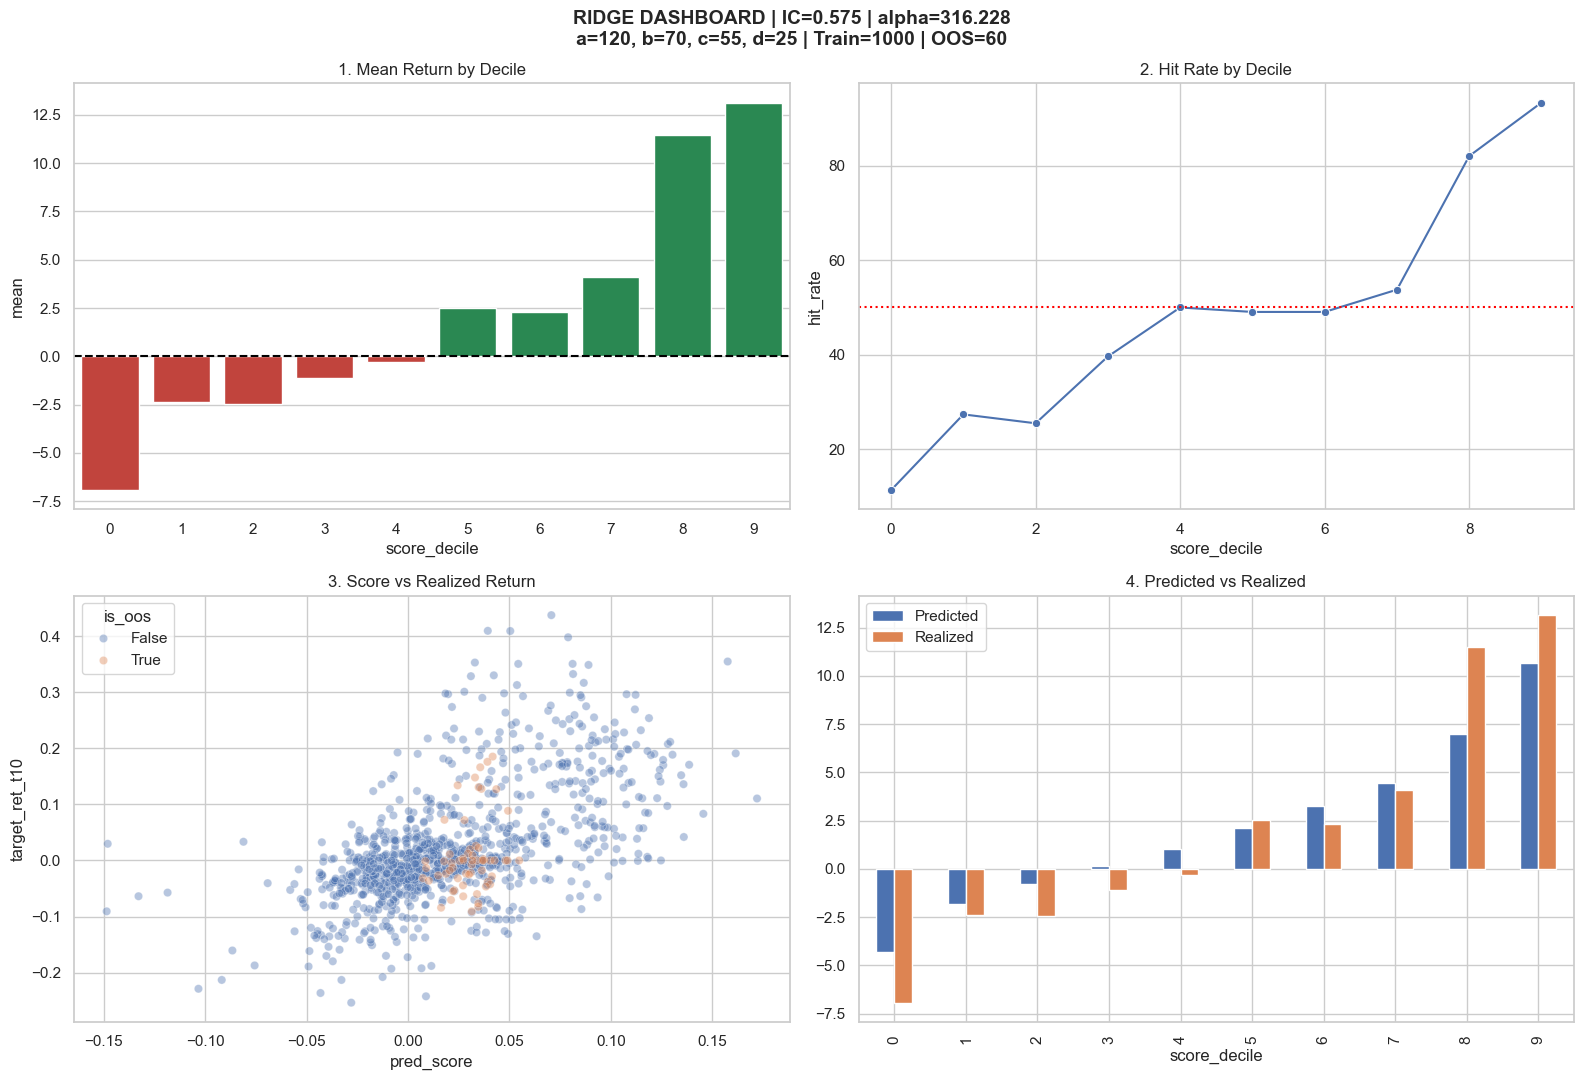

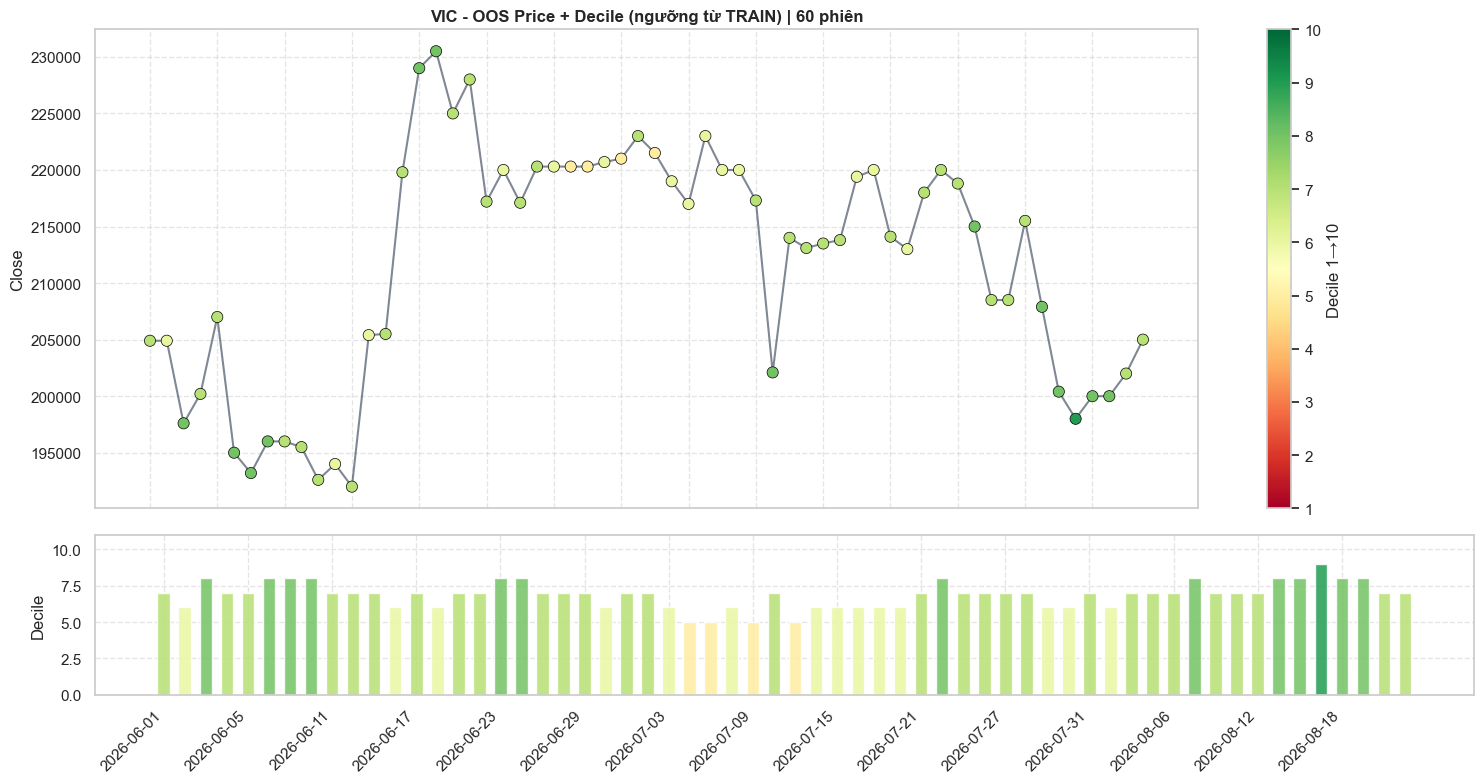

In [117]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# 1. LẤY BEST PARAMS TỪ OPTUNA (Ridge)
# ============================================================
best = study.best_trial

a = best.user_attrs["a"]
b = best.user_attrs["b"]
c = best.user_attrs["c"]
d = best.user_attrs["d"]
alpha = best.user_attrs["chosen_alpha"]
cols_to_exclude = best.user_attrs.get("cols_to_exclude", [])

print("="*70)
print("BEST PARAMS (Ridge)")
print("="*70)
print(f"a = {a} | b = {b} | c = {c} | d = {d}")
print(f"ridge_alpha = {alpha:.4f}")
print(f"LOOKBACK = {LOOKBACK_DAYS} | OOS = {OOS_DAYS}")
print("="*70)

y_col = "target_ret_t10"

# ============================================================
# 3. TẠO DỮ LIỆU + CẮT TRAIN / OOS
# ============================================================
model_data, all_feature_cols = build_features(df_vni_raw, a, b, c, d, investor_groups)

X_cols = [col for col in all_feature_cols if col not in cols_to_exclude]

total_needed = LOOKBACK_DAYS + OOS_DAYS
if len(model_data) >= total_needed:
    train_data = model_data.iloc[-total_needed:-OOS_DAYS].copy()
    oos_data = model_data.iloc[-OOS_DAYS:].copy()
else:
    train_data = model_data.iloc[:-OOS_DAYS].copy() if len(model_data) > OOS_DAYS else model_data.copy()
    oos_data = model_data.iloc[-OOS_DAYS:].copy() if len(model_data) > OOS_DAYS else pd.DataFrame()

print(f"TRAIN: {len(train_data)} | OOS: {len(oos_data)} | Số feature: {len(X_cols)}")


# ============================================================
# 4. FIT RIDGE TRÊN TRAIN
# ============================================================
X_train = train_data[X_cols]
y_train = train_data[y_col]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

model = Ridge(alpha=alpha, random_state=42)
model.fit(X_train_scaled, y_train)

train_data = train_data.copy()
train_data["pred_score"] = model.predict(X_train_scaled)
train_data["actual_ret"] = y_train

ic_train, _ = spearmanr(train_data["pred_score"], train_data["actual_ret"])
hit_train = (train_data.loc[train_data["pred_score"] > 0, "actual_ret"] > 0).mean()

print("\n========== TRAIN ==========")
print(f"IC          : {ic_train:.4f}")
print(f"Hit Rate    : {hit_train:.4f}")
print(f"Số quan sát : {len(train_data)}")


# ============================================================
# 5. ĐÁNH GIÁ OOS
# ============================================================
if len(oos_data) > 0:
    X_oos = oos_data[X_cols]
    X_oos_scaled = scaler.transform(X_oos)

    oos_data = oos_data.copy()
    oos_data["pred_score"] = model.predict(X_oos_scaled)
    oos_data["actual_ret"] = oos_data[y_col]

    ic_oos, _ = spearmanr(oos_data["pred_score"], oos_data["actual_ret"])
    n_sig = int((oos_data["pred_score"] > 0).sum())
    hit_oos = (oos_data.loc[oos_data["pred_score"] > 0, "actual_ret"] > 0).mean() if n_sig > 0 else np.nan

    print("\n========== OOS ==========")
    print(f"IC          : {ic_oos:.4f}")
    print(f"Hit Rate    : {hit_oos:.4f}")
    print(f"Signals     : {n_sig}")
    print(f"Số quan sát : {len(oos_data)}")
else:
    print("\n[OOS] Không đủ dữ liệu")


# ============================================================
# 6. DECILE ANALYSIS (Train + OOS)
# ============================================================
eval_data = pd.concat([
    train_data[["pred_score", y_col]].assign(is_oos=False),
    oos_data[["pred_score", y_col]].assign(is_oos=True) if len(oos_data) > 0 else pd.DataFrame()
], axis=0).dropna()

eval_data["score_decile"] = pd.qcut(eval_data["pred_score"], 10, labels=False, duplicates="drop")

analysis = eval_data.groupby("score_decile")[y_col].agg(["mean", "std", "count"])
analysis["hit_rate"] = eval_data.groupby("score_decile")[y_col].apply(lambda x: (x > 0).mean())
analysis["avg_pred"] = eval_data.groupby("score_decile")["pred_score"].mean()

rank_ic = eval_data["pred_score"].corr(eval_data[y_col], method="spearman")
print(f"\n=== Rank IC (Train+OOS) = {rank_ic:.4f} ===")
print(analysis)


# ============================================================
# 7. DASHBOARD
# ============================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    f"RIDGE DASHBOARD | IC={rank_ic:.3f} | alpha={alpha:.3f}\n"
    f"a={a}, b={b}, c={c}, d={d} | Train={len(train_data)} | OOS={len(oos_data)}",
    fontsize=14, fontweight="bold"
)

colors = ["#d73027" if x < 0 else "#1a9850" for x in analysis["mean"]]
sns.barplot(x=analysis.index, y=analysis["mean"]*100, ax=axes[0,0], palette=colors)
axes[0,0].axhline(0, color="black", ls="--")
axes[0,0].set_title("1. Mean Return by Decile")

sns.lineplot(x=analysis.index, y=analysis["hit_rate"]*100, ax=axes[0,1], marker="o")
axes[0,1].axhline(50, color="red", ls=":")
axes[0,1].set_title("2. Hit Rate by Decile")

sns.scatterplot(data=eval_data, x="pred_score", y=y_col, hue="is_oos", ax=axes[1,0], alpha=0.4)
axes[1,0].set_title("3. Score vs Realized Return")

pd.DataFrame({
    "Predicted": analysis["avg_pred"]*100,
    "Realized": analysis["mean"]*100
}).plot(kind="bar", ax=axes[1,1])
axes[1,1].set_title("4. Predicted vs Realized")

plt.tight_layout()
plt.show()


# ============================================================
# 8. BIỂU ĐỒ GIÁ + DECILE OOS (ngưỡng lấy từ TRAIN)
# ============================================================
if len(oos_data) > 0:
    # Ngưỡng decile từ TRAIN
    train_scores = train_data["pred_score"]
    _, bin_edges = pd.qcut(train_scores, q=10, duplicates="drop", retbins=True)
    bin_edges = bin_edges.copy()
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf
    n_deciles = len(bin_edges) - 1

    oos_data = oos_data.copy()
    oos_data["decile"] = pd.cut(oos_data["pred_score"], bins=bin_edges, labels=False, include_lowest=True) + 1

    # Trục thời gian
    if "time" in df_vni_raw.columns:
        raw_dates = df_vni_raw.loc[oos_data.index, "time"]
    else:
        raw_dates = oos_data.index

    if pd.api.types.is_datetime64_any_dtype(raw_dates):
        x_dates = pd.to_datetime(raw_dates).dt.strftime("%Y-%m-%d").values
    else:
        x_dates = pd.to_datetime(raw_dates).strftime("%Y-%m-%d").values

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True,
                                   gridspec_kw={"height_ratios": [3, 1]})

    ax1.plot(x_dates, oos_data["close"], color="#4A5568", lw=1.5, alpha=0.7, label="Close")
    sc = ax1.scatter(x_dates, oos_data["close"], c=oos_data["decile"],
                     cmap="RdYlGn", vmin=1, vmax=n_deciles, s=65, zorder=5, edgecolors="black", linewidth=0.5)
    ax1.set_title(f"{SYMBOL} - OOS Price + Decile (ngưỡng từ TRAIN) | {len(oos_data)} phiên", fontweight="bold")
    ax1.set_ylabel("Close")
    ax1.grid(True, ls="--", alpha=0.5)
    plt.colorbar(sc, ax=ax1, label=f"Decile 1→{n_deciles}")

    norm = (n_deciles - 1) if n_deciles > 1 else 1
    bar_colors = plt.cm.RdYlGn((oos_data["decile"] - 1) / norm)
    ax2.bar(x_dates, oos_data["decile"], color=bar_colors, alpha=0.85, width=0.6)
    ax2.set_ylabel("Decile")
    ax2.set_ylim(0, n_deciles + 1)
    ax2.grid(True, ls="--", alpha=0.5)
    plt.xticks(rotation=45, ha="right", ticks=range(0, len(x_dates), max(1, len(x_dates)//15)))

    plt.tight_layout()
    plt.show()

In [ ]:
import optuna
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import TimeSeriesSplit
from scipy.stats import spearmanr
from itertools import combinations
import warnings

# ============================================================
# CẤU HÌNH
# ============================================================
investor_groups = ["foreign", "prop", "local_inst", "local_ind"]
ALPHAS = np.logspace(-1, 2.5, 12)   # 0.1 → 1000
LOOKBACK_DAYS = 1000
OOS_DAYS = 60
TRIALS = 250

A_MIN, A_MAX = 10, 200
B_MIN, B_MAX = 10, 200
C_MIN, C_MAX = 15, 70
D_MIN, D_MAX = 5, 40

# Trọng số score (chỉ trên Train)
W_HIT = 0.60
W_IC  = 0.40

# Ngưỡng trên TRAIN
MIN_SIGNALS_TRAIN_SOFT = 30
MIN_SIGNALS_TRAIN_HARD = 15
MIN_HIT_TRAIN_SOFT = 0.55
MIN_HIT_TRAIN_HARD = 0.52
MIN_IC_TRAIN_HARD = 0.02


# ============================================================
# HÀM TÁCH RIÊNG: FEATURE ENGINEERING
# ============================================================
def build_features(df_vni_raw, investor_groups, a, b, c, d):
    """
    Tính toàn bộ feature (TA + investor-flow + cross-investor) từ dữ liệu thô.

    Params
    ------
    df_vni_raw : DataFrame gốc (open, high, low, close, trading_value,
                 {group}_net_val, {group}_net_vol, ...)
    investor_groups : list các nhóm nhà đầu tư, vd ["foreign","prop","local_inst","local_ind"]
    a, b, c, d : các tham số cửa sổ (zscore window, ewm span, range window, impulse days)

    Returns
    -------
    df_feat : DataFrame chỉ chứa các cột feature (index = index gốc của df_vni_raw),
              KHÔNG bao gồm target.
    """
    df = df_vni_raw.copy()

    keep_cols = [
        'open', 'high', 'low', 'close', 'trading_value',
        'foreign_net_val', 'prop_net_val', 'local_ind_net_val', 'local_inst_net_val',
        'foreign_net_vol', 'prop_net_vol', 'local_ind_net_vol', 'local_inst_net_vol',
    ]
    keep_cols = [col for col in keep_cols if col in df.columns]
    df = df[keep_cols]

    df['trading_value'] = df['trading_value'].replace(0, np.nan).interpolate()
    df['close'] = df['close'].ffill()
    df['log_ret'] = np.log(df['close'] / df['close'].shift(1)).fillna(0)
    df['abs_ret'] = df['log_ret'].abs()

    tr = np.maximum(
        df['high'] - df['low'],
        np.maximum(
            (df['high'] - df['close'].shift(1)).abs(),
            (df['low'] - df['close'].shift(1)).abs()
        )
    )

    for g in investor_groups:
        net_val = df[f'{g}_net_val']
        net_ratio = net_val / df['trading_value']
        df[f'feat_{g}_net_ratio'] = net_ratio.fillna(0)

        prev = net_ratio.shift(1).abs()
        df[f'feat_{g}_price_impact'] = (df['abs_ret'].shift(1) / (prev + 1e-6)).rolling(5).median()

        mu = df[f'feat_{g}_net_ratio'].rolling(a).mean()
        sigma = df[f'feat_{g}_net_ratio'].rolling(a).std()
        df[f'feat_{g}_zscore'] = ((df[f'feat_{g}_net_ratio'] - mu) / (sigma + 1e-8)).clip(-4, 4).fillna(0)

        rmin = net_val.rolling(a).min()
        rmax = net_val.rolling(a).max()
        df[f'feat_{g}_sentiment'] = (2 * (net_val - rmin) / (rmax - rmin + 1e-6) - 1).fillna(0)

    df = df.replace([np.inf, -np.inf], 0).fillna(0)

    # ===================== FEATURE FACTORY =====================
    feature_dict = {}

    delta = df["close"].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / (loss + 1e-8)
    rsi = 100 - (100 / (1 + rs))
    feature_dict["ta_rsi_norm"] = (rsi / 100.0) - 0.5

    ma20 = df["close"].rolling(20).mean()
    feature_dict["ta_dist_ma20"] = (df["close"] - ma20) / ma20

    roll_high = df["high"].rolling(c).max()
    roll_low = df["low"].rolling(c).min()
    feature_dict["ta_pos_in_range"] = (df["close"] - roll_low) / (roll_high - roll_low + 1e-8)

    feature_dict["ta_atr_pct"] = tr.ewm(span=b, adjust=False).mean() / df["close"]

    for g in investor_groups:
        sent = df[f"feat_{g}_sentiment"]
        sent_ewm = sent.ewm(span=b, adjust=False).mean()
        feature_dict[f"feat_{g}_sentiment_ewm"] = sent_ewm

        sent_mean = sent_ewm.rolling(a, min_periods=10).mean()
        sent_std = sent_ewm.rolling(a, min_periods=10).std().replace(0, np.nan)
        sent_z = ((sent_ewm - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

        impulse = sent_ewm.diff(d).fillna(0)
        feature_dict[f"feat_{g}_flow_impulse_{d}d"] = impulse

        imp_mean = impulse.rolling(a, min_periods=10).mean()
        imp_std = impulse.rolling(a, min_periods=10).std().replace(0, np.nan)
        imp_z = ((impulse - imp_mean) / (imp_std + 1e-6)).clip(-3, 3).fillna(0)

        feature_dict[f"feat_{g}_eff_flow"] = sent * df[f"feat_{g}_price_impact"]
        feature_dict[f"feat_{g}_val_share"] = df[f"{g}_net_val"].abs() / df["trading_value"]

        implied = np.where(df[f"{g}_net_vol"] != 0, df[f"{g}_net_val"] / df[f"{g}_net_vol"], 0)
        feature_dict[f"feat_{g}_rel_net_price_ewm"] = (
            pd.Series(implied / df["close"], index=df.index).ewm(span=b, adjust=False).mean()
        )

        feature_dict[f"inter_{g}_sent_x_pos"]    = sent_z * feature_dict["ta_pos_in_range"]
        feature_dict[f"inter_{g}_sent_x_distma"] = sent_z * feature_dict["ta_dist_ma20"]
        feature_dict[f"inter_{g}_eff_x_pos"]     = feature_dict[f"feat_{g}_eff_flow"] * feature_dict["ta_pos_in_range"]
        feature_dict[f"inter_{g}_sent_x_atr"]    = sent_z * feature_dict["ta_atr_pct"]

    # ============================================================
    # CROSS-INVESTOR FEATURES (Toàn bộ mối quan hệ)
    # ============================================================
    groups = investor_groups  # ["foreign", "prop", "local_inst", "local_ind"]

    sent_ewm = {g: feature_dict[f"feat_{g}_sentiment_ewm"] for g in groups}
    sent_z = {}
    for g in groups:
        sent = df[f"feat_{g}_sentiment"]
        sent_ewm_g = sent.ewm(span=b, adjust=False).mean()
        sent_mean = sent_ewm_g.rolling(a, min_periods=10).mean()
        sent_std = sent_ewm_g.rolling(a, min_periods=10).std().replace(0, np.nan)
        sent_z[g] = ((sent_ewm_g - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

    net_ratio = {g: df[f"feat_{g}_net_ratio"] for g in groups}

    # 1. Relative Flow (chênh lệch) – tất cả cặp
    for g1, g2 in combinations(groups, 2):
        feature_dict[f"cross_{g1}_minus_{g2}_sent_z"] = sent_z[g1] - sent_z[g2]

    # 2. Agreement / Disagreement
    for g1, g2 in combinations(groups, 2):
        sign_agree = np.sign(sent_ewm[g1]) * np.sign(sent_ewm[g2])
        feature_dict[f"cross_agree_sign_{g1}_{g2}"] = sign_agree
        feature_dict[f"cross_agree_strength_{g1}_{g2}"] = sent_ewm[g1] * sent_ewm[g2]

    # 3. Dispersion (độ phân tán giữa tất cả nhóm)
    sent_matrix = pd.concat([sent_ewm[g] for g in groups], axis=1)
    sent_matrix.columns = groups
    feature_dict["cross_dispersion_std"] = sent_matrix.std(axis=1)

    # 4. Dominance Ratio (tỷ trọng dòng tiền)
    total_abs_net = sum(df[f"{g}_net_val"].abs() for g in groups) + 1e-8
    for g in groups:
        feature_dict[f"cross_dominance_{g}"] = df[f"{g}_net_val"].abs() / total_abs_net

    inst_abs = df["local_inst_net_val"].abs() + df["foreign_net_val"].abs()
    ind_abs  = df["local_ind_net_val"].abs() + df["prop_net_val"].abs()
    feature_dict["cross_dominance_inst_vs_ind"] = (inst_abs - ind_abs) / (inst_abs + ind_abs + 1e-8)

    # 6. Net Pressure & Composite Signals
    feature_dict["cross_net_pressure_smart"] = (
        1.5 * sent_ewm["foreign"] +
        1.2 * sent_ewm["local_inst"] +
        1.0 * sent_ewm["prop"] +
        0.7 * sent_ewm["local_ind"]
    )
    feature_dict["cross_inst_pressure"] = sent_ewm["foreign"] + sent_ewm["local_inst"]
    feature_dict["cross_retail_pressure"] = sent_ewm["prop"] + sent_ewm["local_ind"]
    feature_dict["cross_smart_minus_retail"] = (
        feature_dict["cross_inst_pressure"] - feature_dict["cross_retail_pressure"]
    )

    df_feat = pd.DataFrame(feature_dict, index=df.index)
    return df_feat


def build_target(df_vni_raw, horizon=10):
    """Target: log-return forward `horizon` ngày, tính trên giá close đã ffill."""
    close = df_vni_raw['close'].ffill()
    target = close.shift(-horizon) / close - 1
    target.name = f"target_ret_t{horizon}"
    return target


# ============================================================
# Hàm đánh giá – Ridge + Metrics đơn giản (ưu tiên Hit Rate)
# ============================================================
def evaluate_params_ridge(
    a, b, c, d,
    df_vni_raw,
    investor_groups,
    lookback_days=LOOKBACK_DAYS,
    oos_days=OOS_DAYS,
    min_signals=5,
):
    try:
        df_feat = build_features(df_vni_raw, investor_groups, a, b, c, d)
        target = build_target(df_vni_raw, horizon=10)

        model_data = pd.concat([df_feat, target], axis=1)
        model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()

        if len(model_data) < (lookback_days + oos_days + 50):
            return -999.0, -1.0, 0.0, 0.0, 0, 0.0, -1.0, -1.0, 999.0

        # ----- Tách Train / OOS -----
        train_data = model_data.iloc[-(lookback_days + oos_days):-oos_days].copy()
        oos_data   = model_data.iloc[-oos_days:].copy()

        if len(train_data) < 300 or len(oos_data) < 10:
            return -999.0, -1.0, 0.0, 0.0, 0, 0.0, -1.0, -1.0, 999.0

        target_col = target.name
        X_train = train_data.drop(columns=[target_col]).values
        y_train = train_data[target_col].values
        X_oos   = oos_data.drop(columns=[target_col]).values
        y_oos   = oos_data[target_col].values

        # ----- Scale -----
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_oos_scaled   = scaler.transform(X_oos)

        # ============================================================
        # MODEL (chỉ fit trên Train)
        # ============================================================
        tscv = TimeSeriesSplit(n_splits=5)
        model = RidgeCV(alphas=ALPHAS, cv=tscv, scoring="neg_mean_squared_error")
        model.fit(X_train_scaled, y_train)
        chosen_alpha = float(model.alpha_)

        pred_train = model.predict(X_train_scaled)
        pred_oos   = model.predict(X_oos_scaled)

        # ============================================================
        # METRICS TRAIN (dùng để tính SCORE)
        # ============================================================
        train_ic, _ = spearmanr(pred_train, y_train)
        if np.isnan(train_ic):
            train_ic = -1.0

        mask_up_train = pred_train > 0
        n_signals_train = int(mask_up_train.sum())

        if n_signals_train >= MIN_SIGNALS_TRAIN_HARD:
            hit_rate_train = float((y_train[mask_up_train] > 0).mean())
            avg_ret_train = float(y_train[mask_up_train].mean())
        else:
            hit_rate_train = 0.50
            avg_ret_train = 0.0

        # ============================================================
        # METRICS OOS (chỉ theo dõi, KHÔNG đưa vào score)
        # ============================================================
        oos_ic, _ = spearmanr(pred_oos, y_oos)
        if np.isnan(oos_ic):
            oos_ic = -1.0

        mask_up_oos = pred_oos > 0
        n_signals_oos = int(mask_up_oos.sum())
        if n_signals_oos >= 3:
            hit_rate_oos = float((y_oos[mask_up_oos] > 0).mean())
            avg_ret_oos = float(y_oos[mask_up_oos].mean())
        else:
            hit_rate_oos = 0.50
            avg_ret_oos = 0.0

        train_oos_gap = train_ic - oos_ic

        # ============================================================
        # SCORE – CHỈ DỰA TRÊN TRAIN
        # ============================================================
        hit_term = (hit_rate_train - 0.50) * 2.0
        ic_term  = np.clip(train_ic, -0.15, 0.60)

        score = W_HIT * hit_term + W_IC * ic_term

        if avg_ret_train > 0:
            score += 0.03 * np.clip(avg_ret_train * 8, 0, 0.25)

        # Soft penalty trên Train
        if n_signals_train < MIN_SIGNALS_TRAIN_SOFT:
            score *= 0.75
        if hit_rate_train < MIN_HIT_TRAIN_SOFT:
            score *= 0.80

        # Hard filter – chỉ trên Train
        if (
            n_signals_train < MIN_SIGNALS_TRAIN_HARD
            or hit_rate_train < MIN_HIT_TRAIN_HARD
            or train_ic < MIN_IC_TRAIN_HARD
        ):
            score = -999.0

        return (
            float(score),
            float(oos_ic),                 # vẫn trả OOS IC để theo dõi
            float(hit_rate_oos),           # Hit Rate OOS để theo dõi
            float(avg_ret_oos),
            n_signals_oos,
            chosen_alpha,
            float(train_ic),
            float(hit_rate_train),         # thêm hit train nếu muốn
            float(train_oos_gap),
        )
    except Exception as e:
        # Tạm thời in lỗi ra để biết nguyên nhân
        print(f"[EXCEPTION] a={a}, b={b}, c={c}, d={d} → {type(e).__name__}: {e}")
        return -999.0, -1.0, 0.0, 0.0, 0, 0.0, -1.0, -1.0, 999.0


# ============================================================
# OBJECTIVE – Không còn suggest alpha
# ============================================================
def objective(trial):
    a = trial.suggest_int("window_z", A_MIN, A_MAX, step=10)
    b = trial.suggest_int("window_div", B_MIN, B_MAX, step=10)
    c = trial.suggest_int("pos_range", C_MIN, C_MAX, step=10)
    d = trial.suggest_int("impulse_days", D_MIN, D_MAX, step=5)

    result = evaluate_params_ridge(
        a, b, c, d,
        df_vni_raw,
        investor_groups,
        lookback_days=LOOKBACK_DAYS,
        oos_days=OOS_DAYS,
    )

    score, oos_ic, hit_up, avg_ret, n_sig, chosen_alpha, train_ic, _, gap = result

    # Lưu thông tin giám sát
    trial.set_user_attr("ic", oos_ic)
    trial.set_user_attr("hit_rate_up", hit_up)
    trial.set_user_attr("avg_ret_when_up", avg_ret)
    trial.set_user_attr("n_signals", n_sig)
    trial.set_user_attr("chosen_alpha", chosen_alpha)
    trial.set_user_attr("train_ic", train_ic)
    trial.set_user_attr("train_oos_gap", gap)
    trial.set_user_attr("a", a)
    trial.set_user_attr("b", b)
    trial.set_user_attr("c", c)
    trial.set_user_attr("d", d)

    return score


# ============================================================
# CHẠY OPTUNA
# ============================================================
if __name__ == "__main__":
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=30, n_warmup_steps=10),
    )

    study.optimize(objective, n_trials=TRIALS, show_progress_bar=True)

    # ============================================================
    # KẾT QUẢ
    # ============================================================
    best = study.best_trial
    print("\n" + "="*70)
    print("BEST TRIAL – RidgeCV (tự chọn alpha)")
    print("="*70)
    print(f"Score              : {best.value:.4f}")
    print(f"OOS IC             : {best.user_attrs['ic']:.4f}")
    print(f"Train IC           : {best.user_attrs['train_ic']:.4f}")
    print(f"Train-OOS Gap      : {best.user_attrs['train_oos_gap']:.4f}")
    print(f"Hit Rate Up (OOS)  : {best.user_attrs['hit_rate_up']:.4f}")
    print(f"Avg Ret when Up    : {best.user_attrs['avg_ret_when_up']:.5f}")
    print(f"n_signals          : {best.user_attrs['n_signals']}")
    print(f"Chosen Alpha       : {best.user_attrs['chosen_alpha']:.4f}")
    print(f"\nParams:")
    print(f"  a = {best.user_attrs['a']}, b = {best.user_attrs['b']}, "
          f"c = {best.user_attrs['c']}, d = {best.user_attrs['d']}")
    print("Alphás đang dùng:", ALPHAS)
    print("Alpha được chọn :", best.user_attrs["chosen_alpha"])

# PLS

In [297]:
SYMBOL = 'PNJ'

# --- BƯỚC 1: CHUẨN BỊ DỮ LIỆU ---
excel_file_path_vni = rf"E:\Document\Tao\FiinGroup\csv_data_2\Kafi_Phân_Loại_Nhà_Đầu_Tư_{SYMBOL}.csv"
excel_file_path_vni_new = rf"E:\Document\Tao\FiinGroup\csv_data_2\Kafi_Giá_{SYMBOL}.csv"
# excel_file_path_vni = rf"E:\Document\Tao\FiinGroup\Kafi_Phân_Loại_Nhà_Đầu_Tư_{SYMBOL}_20260305.xlsx"

investor_groups = ['foreign', 'prop', 'local_ind', 'local_inst']

df_vni_raw = load_and_map_excel(excel_file_path_vni, df_history=None)

# Chưa fixed ncomp

In [298]:
import optuna
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from scipy.stats import spearmanr
from itertools import combinations
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# CẤU HÌNH
# ============================================================
investor_groups = ["foreign", "prop", "local_inst", "local_ind"]
LOOKBACK_DAYS = 1000
OOS_DAYS = 30
TRIALS = 300

A_MIN, A_MAX = 50, 150
B_MIN, B_MAX = 50, 150
C_MIN, C_MAX = 15, 70
D_MIN, D_MAX = 15, 60

# Số thành phần PLS (Optuna sẽ chọn trong khoảng này)
N_COMP_MIN, N_COMP_MAX = 12, 25

# Trọng số score (chỉ trên Train)
W_HIT = 0.60
W_IC = 0.40
W_TOP = 0.20          # Chất lượng 2 decile cao nhất
W_BOT = 0.20          # Chất lượng 2 decile thấp nhất

# Ngưỡng mong muốn
TOP_HIT_TARGET = 0.88         # 2 decile cao nhất nên ≥ 85% return dương
BOT_HIT_TARGET = 0.12         # 2 decile thấp nhất nên ≤ 15% return dương

# Ngưỡng trên TRAIN
MIN_SIGNALS_TRAIN_SOFT = 30
MIN_SIGNALS_TRAIN_HARD = 15
MIN_HIT_TRAIN_SOFT = 0.65
MIN_HIT_TRAIN_HARD = 0.6
MIN_IC_TRAIN_HARD = 0.02

# bad_result: đủ 9 phần tử, khớp unpack trong objective
BAD_RESULT = (-999.0, -1.0, 0.0, 0.0, 0, 0, -1.0, 0.0, 999.0)

# ============================================================
# FEATURE ENGINEERING (giữ nguyên logic của bạn)
# ============================================================
def build_features(df_vni_raw, investor_groups, a, b, c, d):
    df = df_vni_raw.copy()
    keep_cols = [
        "open", "high", "low", "close", "trading_value",
        "foreign_net_val", "prop_net_val", "local_ind_net_val", "local_inst_net_val",
        "foreign_net_vol", "prop_net_vol", "local_ind_net_vol", "local_inst_net_vol",
    ]
    keep_cols = [col for col in keep_cols if col in df.columns]
    df = df[keep_cols]

    df["trading_value"] = df["trading_value"].replace(0, np.nan).interpolate()
    df["close"] = df["close"].ffill()
    df["log_ret"] = np.log(df["close"] / df["close"].shift(1)).fillna(0)
    df["abs_ret"] = df["log_ret"].abs()

    tr = np.maximum(
        df["high"] - df["low"],
        np.maximum(
            (df["high"] - df["close"].shift(1)).abs(),
            (df["low"] - df["close"].shift(1)).abs(),
        ),
    )

    # ===== Flow cơ bản =====
    for g in investor_groups:
        net_val = df[f"{g}_net_val"]
        net_ratio = net_val / df["trading_value"]
        df[f"feat_{g}_net_ratio"] = net_ratio.fillna(0)

        prev = net_ratio.shift(1).abs()
        df[f"feat_{g}_price_impact"] = (
            df["abs_ret"].shift(1) / (prev + 1e-6)
        ).rolling(5).median()

        mu = df[f"feat_{g}_net_ratio"].rolling(a).mean()
        sigma = df[f"feat_{g}_net_ratio"].rolling(a).std()
        df[f"feat_{g}_zscore"] = (
            (df[f"feat_{g}_net_ratio"] - mu) / (sigma + 1e-8)
        ).clip(-4, 4).fillna(0)

        rmin = net_val.rolling(a).min()
        rmax = net_val.rolling(a).max()
        df[f"feat_{g}_sentiment"] = (
            2 * (net_val - rmin) / (rmax - rmin + 1e-6) - 1
        ).fillna(0)

    df = df.replace([np.inf, -np.inf], 0).fillna(0)

    feature_dict = {}

    # ===== Technical chỉ dùng để tạo interaction (không đưa vào model trực tiếp) =====
    roll_high = df["high"].rolling(c).max()
    roll_low  = df["low"].rolling(c).min()
    ta_pos_in_range = (df["close"] - roll_low) / (roll_high - roll_low + 1e-8)

    ta_atr_pct = tr.ewm(span=b, adjust=False).mean() / df["close"]

    # (Nếu sau này muốn dùng RSI / dist_ma20 để interaction thì tính ở đây)
    delta = df["close"].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / (loss + 1e-8)
    ta_rsi_norm = (100 - (100 / (1 + rs))) / 100.0 - 0.5

    # ===== Flow features + Interaction với technical =====
    for g in investor_groups:
        sent = df[f"feat_{g}_sentiment"]
        sent_ewm = sent.ewm(span=b, adjust=False).mean()
        feature_dict[f"feat_{g}_sentiment_ewm"] = sent_ewm

        sent_mean = sent_ewm.rolling(a, min_periods=10).mean()
        sent_std  = sent_ewm.rolling(a, min_periods=10).std().replace(0, np.nan)
        sent_z = ((sent_ewm - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

        # Polynomial nhẹ (có thể giữ hoặc bỏ)
        # feature_dict[f"feat_{g}_sentiment_sq"] = sent_z**2
        feature_dict[f"feat_{g}_sentiment_cubed"] = (sent_z**3 - 3*sent_z).clip(-10, 10)

        # Impulse
        impulse = sent_ewm.diff(d).fillna(0)
        feature_dict[f"feat_{g}_flow_impulse_{d}d"] = impulse

        imp_mean = impulse.rolling(a, min_periods=10).mean()
        imp_std  = impulse.rolling(a, min_periods=10).std().replace(0, np.nan)
        imp_z = ((impulse - imp_mean) / (imp_std + 1e-6)).clip(-3, 3).fillna(0)

        # Effective flow & share
        feature_dict[f"feat_{g}_eff_flow"] = sent * df[f"feat_{g}_price_impact"]
        feature_dict[f"feat_{g}_val_share"] = df[f"{g}_net_val"].abs() / df["trading_value"]


        feature_dict[f"feat_{g}_eff_flow"] = sent * df[f"feat_{g}_price_impact"]
        feature_dict[f"feat_{g}_val_share"] = df[f"{g}_net_val"].abs() / df["trading_value"]

        implied = np.where(df[f"{g}_net_vol"] != 0, df[f"{g}_net_val"] / df[f"{g}_net_vol"], 0)
        feature_dict[f"feat_{g}_rel_net_price_ewm"] = (
            pd.Series(implied / df["close"], index=df.index).ewm(span=b, adjust=False).mean()
        )
        # ========== CHỈ GIỮ INTERACTION VỚI TECHNICAL ==========
        feature_dict[f"inter_{g}_sent_x_pos"] = sent_z * ta_pos_in_range
        feature_dict[f"inter_{g}_sent_x_atr"] = sent_z * ta_atr_pct
        feature_dict[f"inter_{g}_imp_x_atr"]  = imp_z  * ta_atr_pct
        feature_dict[f"inter_{g}_eff_x_pos"]  = feature_dict[f"feat_{g}_eff_flow"] * ta_pos_in_range
    # ============================================================
    # ----- Cross-investor -----
    groups = investor_groups
    sent_ewm = {g: feature_dict[f"feat_{g}_sentiment_ewm"] for g in groups}
    sent_z = {}
    for g in groups:
        sent = df[f"feat_{g}_sentiment"]
        sent_ewm_g = sent.ewm(span=b, adjust=False).mean()
        mu = sent_ewm_g.rolling(a, min_periods=10).mean()
        sigma = sent_ewm_g.rolling(a, min_periods=10).std().replace(0, np.nan)
        sent_z[g] = ((sent_ewm_g - mu) / (sigma + 1e-6)).clip(-3, 3).fillna(0)

    for g1, g2 in combinations(groups, 2):
        feature_dict[f"cross_{g1}_minus_{g2}_sent_z"] = sent_z[g1] - sent_z[g2]
        sign_agree = np.sign(sent_ewm[g1]) * np.sign(sent_ewm[g2])
        feature_dict[f"cross_agree_sign_{g1}_{g2}"] = sign_agree
        feature_dict[f"cross_agree_strength_{g1}_{g2}"] = sent_ewm[g1] * sent_ewm[g2]

    sent_matrix = pd.concat([sent_ewm[g] for g in groups], axis=1)
    feature_dict["cross_dispersion_std"] = sent_matrix.std(axis=1)
    feature_dict["cross_dispersion_range"] = sent_matrix.max(axis=1) - sent_matrix.min(axis=1)  # range
    feature_dict["cross_dispersion_iqr"] = sent_matrix.quantile(0.75, axis=1) - sent_matrix.quantile(0.25, axis=1)

    # total_abs_net = sum(df[f"{g}_net_val"].abs() for g in groups) + 1e-8
    # for g in groups:
    #     feature_dict[f"cross_dominance_{g}"] = df[f"{g}_net_val"].abs() / total_abs_net
    #     feature_dict["cross_dispersion_range"] = sent_matrix.max(axis=1) - sent_matrix.min(axis=1)  # range
    #     feature_dict["cross_dispersion_iqr"] = sent_matrix.quantile(0.75, axis=1) - sent_matrix.quantile(0.25, axis=1)

    # inst_abs = df["local_inst_net_val"].abs() + df["foreign_net_val"].abs()
    # ind_abs = df["local_ind_net_val"].abs() + df["prop_net_val"].abs()
    # feature_dict["cross_dominance_inst_vs_ind"] = (inst_abs - ind_abs) / (
    #     inst_abs + ind_abs + 1e-8
    # )

    # feature_dict["cross_net_pressure_smart"] = (
    #     1.5 * sent_ewm["foreign"]
    #     + 1.2 * sent_ewm["local_inst"]
    #     + 1.0 * sent_ewm["prop"]
    #     + 0.7 * sent_ewm["local_ind"]
    # )
    # feature_dict["cross_inst_pressure"] = sent_ewm["foreign"] + sent_ewm["local_inst"]
    # feature_dict["cross_retail_pressure"] = sent_ewm["prop"] + sent_ewm["local_ind"]
    # feature_dict["cross_smart_minus_retail"] = (
    #     feature_dict["cross_inst_pressure"] - feature_dict["cross_retail_pressure"]
    # )

    return pd.DataFrame(feature_dict, index=df.index)


def build_target(df_vni_raw, horizon=10):
    close = df_vni_raw["close"].ffill()
    target = close.shift(-horizon) / close - 1
    target.name = f"target_ret_t{horizon}"
    return target

# ============================================================
# Hàm đánh giá – PLS + score ưu tiên đơn điệu
# ============================================================
def evaluate_params_pls(
    a, b, c, d, n_components,
    df_vni_raw,
    investor_groups,
    lookback_days=LOOKBACK_DAYS,
    oos_days=OOS_DAYS,
):
    try:
        df_feat = build_features(df_vni_raw, investor_groups, a, b, c, d)
        target = build_target(df_vni_raw, horizon=10)
        model_data = pd.concat([df_feat, target], axis=1)
        model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()

        if len(model_data) < (lookback_days + oos_days + 50):
            return BAD_RESULT

        train_data = model_data.iloc[-(lookback_days + oos_days) : -oos_days].copy()
        oos_data   = model_data.iloc[-oos_days:].copy()

        if len(train_data) < 300 or len(oos_data) < 10:
            return BAD_RESULT

        target_col = target.name
        X_train = train_data.drop(columns=[target_col]).values
        y_train = train_data[target_col].values
        X_oos   = oos_data.drop(columns=[target_col]).values
        y_oos   = oos_data[target_col].values

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_oos_scaled   = scaler.transform(X_oos)

        # ----- PLS -----
        n_feat = X_train_scaled.shape[1]
        n_samp = X_train_scaled.shape[0]
        n_comp = int(max(1, min(n_components, n_feat, n_samp - 1)))

        model = PLSRegression(n_components=n_comp, scale=False)
        model.fit(X_train_scaled, y_train)

        pred_train = model.predict(X_train_scaled).ravel()
        pred_oos   = model.predict(X_oos_scaled).ravel()

        if np.std(pred_train) < 1e-8:
            return BAD_RESULT

        # ============================================================
        # METRICS CƠ BẢN TRÊN TRAIN
        # ============================================================
        train_ic, _ = spearmanr(pred_train, y_train)
        if np.isnan(train_ic):
            train_ic = -1.0

        mask_up_train = pred_train > 0
        n_signals_train = int(mask_up_train.sum())

        if n_signals_train >= MIN_SIGNALS_TRAIN_HARD:
            hit_rate_train = float((y_train[mask_up_train] > 0).mean())
            avg_ret_train  = float(y_train[mask_up_train].mean())
        else:
            hit_rate_train = 0.50
            avg_ret_train  = 0.0

        # ============================================================
        # DECILE ANALYSIS TRÊN TRAIN (quan trọng)
        # ============================================================
        try:
            deciles = pd.qcut(pred_train, 10, labels=False, duplicates="drop")
        except Exception:
            return BAD_RESULT

        df_dec = pd.DataFrame({"pred": pred_train, "y": y_train, "decile": deciles})
        decile_stats = df_dec.groupby("decile")["y"].agg(
            mean_ret="mean",
            hit_rate=lambda x: (x > 0).mean(),
            count="count"
        ).reindex(range(10))

        # 2 decile cao nhất (8, 9) và 2 decile thấp nhất (0, 1)
        top_stats = decile_stats.loc[[8, 9]].dropna()
        bot_stats = decile_stats.loc[[0, 1]].dropna()

        if len(top_stats) < 1 or len(bot_stats) < 1:
            return BAD_RESULT

        top_hit = top_stats["hit_rate"].mean()          # mong muốn ≥ 0.85
        bot_hit = bot_stats["hit_rate"].mean()          # mong muốn ≤ 0.15
        top_mean = top_stats["mean_ret"].mean()
        bot_mean = bot_stats["mean_ret"].mean()

        # Tính đơn điệu tổng thể (Spearman giữa decile và mean return)
        valid = decile_stats.dropna()
        if len(valid) >= 5:
            mono_score = spearmanr(valid.index, valid["mean_ret"])[0]
            if np.isnan(mono_score):
                mono_score = 0.0
        else:
            mono_score = 0.0

        # ============================================================
        # METRICS OOS (chỉ theo dõi)
        # ============================================================
        oos_ic, _ = spearmanr(pred_oos, y_oos)
        if np.isnan(oos_ic):
            oos_ic = -1.0

        mask_up_oos = pred_oos > 0
        n_signals_oos = int(mask_up_oos.sum())
        hit_rate_oos = float((y_oos[mask_up_oos] > 0).mean()) if n_signals_oos >= 3 else 0.50
        avg_ret_oos  = float(y_oos[mask_up_oos].mean()) if n_signals_oos >= 3 else 0.0

        train_oos_gap = train_ic - oos_ic

        # ============================================================
        # SCORE (ưu tiên đơn điệu + extreme deciles)
        # ============================================================
        # 1. Hit rate tổng
        hit_term = (hit_rate_train - 0.50) * 2.0

        # 2. IC
        ic_term = np.clip(train_ic, -0.15, 0.60)

        # 3. Top 2 decile (càng cao càng tốt)
        #    0.85 → 1.0 | 0.90 → 1.25 | dưới 0.70 thì thấp
        top_term = np.clip((top_hit - 0.50) / 0.40, 0, 1.5)

        # 4. Bottom 2 decile (càng thấp càng tốt)
        #    0.15 → 1.0 | 0.10 → 1.25 | trên 0.30 thì kém
        bot_term = np.clip((0.50 - bot_hit) / 0.40, 0, 1.5)

        # 5. Monotonicity
        mono_term = np.clip(mono_score, 0, 1.0)

        score = (
            W_HIT * hit_term +
            W_IC  * ic_term +
            W_TOP * top_term +
            W_BOT * bot_term +
            0.05  * mono_term          # thưởng nhẹ thêm cho đơn điệu tổng thể
        )

        # Thưởng nhẹ nếu top mean return cao và bot mean return thấp
        if top_mean > 0:
            score += 0.02 * np.clip(top_mean * 10, 0, 0.3)
        if bot_mean < 0:
            score += 0.02 * np.clip(-bot_mean * 10, 0, 0.3)

        # Soft penalty
        if n_signals_train < MIN_SIGNALS_TRAIN_SOFT:
            score *= 0.75
        if hit_rate_train < MIN_HIT_TRAIN_SOFT:
            score *= 0.80
        if top_hit < 0.75:                     # top chưa đủ mạnh
            score *= 0.70
        if bot_hit > 0.25:                     # bottom chưa đủ yếu
            score *= 0.75

        # Hard filter
        if (
            n_signals_train < MIN_SIGNALS_TRAIN_HARD
            or hit_rate_train < MIN_HIT_TRAIN_HARD
            or train_ic < MIN_IC_TRAIN_HARD
            or top_hit < 0.65
            or bot_hit > 0.35
        ):
            score = -999.0

        return (
            float(score),
            float(oos_ic),
            float(hit_rate_oos),
            float(avg_ret_oos),
            n_signals_oos,
            n_comp,
            float(train_ic),
            float(hit_rate_train),
            float(train_oos_gap),
            float(top_hit),          # thêm để theo dõi
            float(bot_hit),
            float(mono_score),
        )

    except Exception as e:
        print(f"[EXCEPTION] a={a}, b={b}, c={c}, d={d}, n_comp={n_components} → {type(e).__name__}: {e}")
        return BAD_RESULT


# ============================================================
# OBJECTIVE (đã cập nhật theo evaluate_params_pls mới)
# ============================================================
def objective(trial):
    a = trial.suggest_int("window_z", A_MIN, A_MAX, step=10)
    b = trial.suggest_int("window_div", B_MIN, B_MAX, step=10)
    c = trial.suggest_int("pos_range", C_MIN, C_MAX, step=10)
    d = trial.suggest_int("impulse_days", D_MIN, D_MAX, step=5)
    n_components = trial.suggest_int("n_components", N_COMP_MIN, N_COMP_MAX)

    result = evaluate_params_pls(
        a, b, c, d, n_components,
        df_vni_raw,
        investor_groups,
        lookback_days=LOOKBACK_DAYS,
        oos_days=OOS_DAYS,
    )

    # Xử lý cả trường hợp BAD_RESULT (thường trả về tuple ngắn hoặc giá trị đặc biệt)
    if not isinstance(result, (list, tuple)) or len(result) < 9:
        return -999.0

    # Unpack theo đúng thứ tự mới
    if len(result) >= 12:
        (score, oos_ic, hit_up, avg_ret, n_sig, n_comp,
         train_ic, hit_train, gap, top_hit, bot_hit, mono) = result
    else:
        # fallback nếu hàm cũ còn sót
        score, oos_ic, hit_up, avg_ret, n_sig, n_comp, train_ic, hit_train, gap = result[:9]
        top_hit = bot_hit = mono = np.nan

    # Lưu thông tin để phân tích sau
    trial.set_user_attr("ic", oos_ic)
    trial.set_user_attr("hit_rate_up", hit_up)
    trial.set_user_attr("avg_ret_when_up", avg_ret)
    trial.set_user_attr("n_signals", n_sig)
    trial.set_user_attr("n_components", n_comp)
    trial.set_user_attr("train_ic", train_ic)
    trial.set_user_attr("hit_rate_train", hit_train)
    trial.set_user_attr("train_oos_gap", gap)
    trial.set_user_attr("top_hit", top_hit)          # 2 decile cao nhất
    trial.set_user_attr("bot_hit", bot_hit)          # 2 decile thấp nhất
    trial.set_user_attr("mono_score", mono)
    trial.set_user_attr("a", a)
    trial.set_user_attr("b", b)
    trial.set_user_attr("c", c)
    trial.set_user_attr("d", d)

    return score


# ============================================================
# CHẠY
# ============================================================
if __name__ == "__main__":
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=30, n_warmup_steps=10),
    )
    study.optimize(objective, n_trials=TRIALS, show_progress_bar=True)

    best = study.best_trial
    print("\n" + "=" * 70)
    print("BEST TRIAL – PLS Regression (ưu tiên đơn điệu)")
    print("=" * 70)
    print(f"Score              : {best.value:.4f}")
    print(f"Train IC           : {best.user_attrs['train_ic']:.4f}")
    print(f"Train Hit Rate     : {best.user_attrs['hit_rate_train']:.4f}")
    print(f"Top-2 Decile Hit   : {best.user_attrs.get('top_hit', np.nan):.4f}")
    print(f"Bottom-2 Decile Hit: {best.user_attrs.get('bot_hit', np.nan):.4f}")
    print(f"Mono Score         : {best.user_attrs.get('mono_score', np.nan):.4f}")
    print(f"Train-OOS Gap      : {best.user_attrs['train_oos_gap']:.4f}")
    print(f"OOS IC (theo dõi)  : {best.user_attrs['ic']:.4f}")
    print(f"Hit Rate OOS       : {best.user_attrs['hit_rate_up']:.4f}")
    print(f"n_signals OOS      : {best.user_attrs['n_signals']}")
    print(f"n_components       : {best.user_attrs['n_components']}")
    print(
        f"\nParams: a={best.user_attrs['a']}, b={best.user_attrs['b']}, "
        f"c={best.user_attrs['c']}, d={best.user_attrs['d']}"
    )

[I 2026-08-24 22:52:55,142] A new study created in memory with name: no-name-27d69e6f-3033-446b-b32e-d7e91dec27eb


  0%|          | 0/300 [00:00<?, ?it/s]

[I 2026-08-24 22:52:55,274] Trial 0 finished with value: 0.5881533778263297 and parameters: {'window_z': 90, 'window_div': 150, 'pos_range': 55, 'impulse_days': 40, 'n_components': 14}. Best is trial 0 with value: 0.5881533778263297.
[I 2026-08-24 22:52:55,388] Trial 1 finished with value: 0.8602857142857143 and parameters: {'window_z': 60, 'window_div': 50, 'pos_range': 65, 'impulse_days': 45, 'n_components': 21}. Best is trial 1 with value: 0.8602857142857143.
[I 2026-08-24 22:52:55,499] Trial 2 finished with value: 0.7867971966059748 and parameters: {'window_z': 50, 'window_div': 150, 'pos_range': 55, 'impulse_days': 25, 'n_components': 14}. Best is trial 1 with value: 0.8602857142857143.
[I 2026-08-24 22:52:55,634] Trial 3 finished with value: 0.8111827348673872 and parameters: {'window_z': 70, 'window_div': 80, 'pos_range': 45, 'impulse_days': 35, 'n_components': 16}. Best is trial 1 with value: 0.8602857142857143.
[I 2026-08-24 22:52:55,763] Trial 4 finished with value: 0.5947159

# Fixed ncomps

In [ ]:
# import optuna
# import numpy as np
# import pandas as pd
# from sklearn.preprocessing import StandardScaler
# from sklearn.cross_decomposition import PLSRegression
# from scipy.stats import spearmanr
# from itertools import combinations
# import warnings
# warnings.filterwarnings("ignore")

# # ============================================================
# # CẤU HÌNH
# # ============================================================
# investor_groups = ["foreign", "prop", "local_inst", "local_ind"]
# LOOKBACK_DAYS = 1000
# OOS_DAYS = 60
# TRIALS = 100

# A_MIN, A_MAX = 20, 100
# B_MIN, B_MAX = 20, 80
# C_MIN, C_MAX = 15, 70
# D_MIN, D_MAX = 5, 40

# FIXED_N_COMP = 20          # hoặc 5 / 8; chọn một mức trung bình

# # Trọng số score (chỉ trên Train)
# W_HIT = 0.60
# W_IC = 0.40

# # Ngưỡng trên TRAIN
# MIN_SIGNALS_TRAIN_SOFT = 30
# MIN_SIGNALS_TRAIN_HARD = 15
# MIN_HIT_TRAIN_SOFT = 0.65
# MIN_HIT_TRAIN_HARD = 0.6
# MIN_IC_TRAIN_HARD = 0.02

# # bad_result: đủ 9 phần tử, khớp unpack trong objective
# BAD_RESULT = (-999.0, -1.0, 0.0, 0.0, 0, 0, -1.0, 0.0, 999.0)

# # ============================================================
# # FEATURE ENGINEERING (giữ nguyên logic của bạn)
# # ============================================================
# def build_features(df_vni_raw, investor_groups, a, b, c, d):
#     df = df_vni_raw.copy()
#     keep_cols = [
#         "open", "high", "low", "close", "trading_value",
#         "foreign_net_val", "prop_net_val", "local_ind_net_val", "local_inst_net_val",
#         "foreign_net_vol", "prop_net_vol", "local_ind_net_vol", "local_inst_net_vol",
#     ]
#     keep_cols = [col for col in keep_cols if col in df.columns]
#     df = df[keep_cols]

#     df["trading_value"] = df["trading_value"].replace(0, np.nan).interpolate()
#     df["close"] = df["close"].ffill()
#     df["log_ret"] = np.log(df["close"] / df["close"].shift(1)).fillna(0)
#     df["abs_ret"] = df["log_ret"].abs()

#     tr = np.maximum(
#         df["high"] - df["low"],
#         np.maximum(
#             (df["high"] - df["close"].shift(1)).abs(),
#             (df["low"] - df["close"].shift(1)).abs(),
#         ),
#     )

#     for g in investor_groups:
#         net_val = df[f"{g}_net_val"]
#         net_ratio = net_val / df["trading_value"]
#         df[f"feat_{g}_net_ratio"] = net_ratio.fillna(0)
#         prev = net_ratio.shift(1).abs()
#         df[f"feat_{g}_price_impact"] = (
#             df["abs_ret"].shift(1) / (prev + 1e-6)
#         ).rolling(5).median()
#         mu = df[f"feat_{g}_net_ratio"].rolling(a).mean()
#         sigma = df[f"feat_{g}_net_ratio"].rolling(a).std()
#         df[f"feat_{g}_zscore"] = (
#             (df[f"feat_{g}_net_ratio"] - mu) / (sigma + 1e-8)
#         ).clip(-4, 4).fillna(0)
#         rmin = net_val.rolling(a).min()
#         rmax = net_val.rolling(a).max()
#         df[f"feat_{g}_sentiment"] = (
#             2 * (net_val - rmin) / (rmax - rmin + 1e-6) - 1
#         ).fillna(0)

#     df = df.replace([np.inf, -np.inf], 0).fillna(0)

#     feature_dict = {}

#     delta = df["close"].diff()
#     gain = delta.clip(lower=0).rolling(14).mean()
#     loss = (-delta.clip(upper=0)).rolling(14).mean()
#     rs = gain / (loss + 1e-8)
#     rsi = 100 - (100 / (1 + rs))
#     feature_dict["ta_rsi_norm"] = (rsi / 100.0) - 0.5

#     ma20 = df["close"].rolling(20).mean()
#     feature_dict["ta_dist_ma20"] = (df["close"] - ma20) / ma20

#     roll_high = df["high"].rolling(c).max()
#     roll_low = df["low"].rolling(c).min()
#     feature_dict["ta_pos_in_range"] = (df["close"] - roll_low) / (
#         roll_high - roll_low + 1e-8
#     )
#     feature_dict["ta_atr_pct"] = tr.ewm(span=b, adjust=False).mean() / df["close"]

#     for g in investor_groups:
#         sent = df[f"feat_{g}_sentiment"]
#         sent_ewm = sent.ewm(span=b, adjust=False).mean()
#         feature_dict[f"feat_{g}_sentiment_ewm"] = sent_ewm

#         sent_mean = sent_ewm.rolling(a, min_periods=10).mean()
#         sent_std = sent_ewm.rolling(a, min_periods=10).std().replace(0, np.nan)
#         sent_z = ((sent_ewm - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

#         # feature_dict[f"feat_{g}_sentiment_sq"] = sent_z**2
#         feature_dict[f"feat_{g}_sentiment_cubed"] = (sent_z**3 - 3 * sent_z).clip(-10, 10)

#         impulse = sent_ewm.diff(d).fillna(0)
#         feature_dict[f"feat_{g}_flow_impulse_{d}d"] = impulse

#         imp_mean = impulse.rolling(a, min_periods=10).mean()
#         imp_std = impulse.rolling(a, min_periods=10).std().replace(0, np.nan)
#         imp_z = ((impulse - imp_mean) / (imp_std + 1e-6)).clip(-3, 3).fillna(0)

#         # feature_dict[f"feat_{g}_flow_impulse_{d}d_sq"] = imp_z**2
#         # feature_dict[f"feat_{g}_flow_impulse_{d}d_cubed"] = (imp_z**3 - 3 * imp_z).clip(-10, 10)

#         feature_dict[f"feat_{g}_eff_flow"] = sent * df[f"feat_{g}_price_impact"]
#         feature_dict[f"feat_{g}_val_share"] = df[f"{g}_net_val"].abs() / df["trading_value"]

#         implied = np.where(df[f"{g}_net_vol"] != 0, df[f"{g}_net_val"] / df[f"{g}_net_vol"], 0)
#         feature_dict[f"feat_{g}_rel_net_price_ewm"] = (
#             pd.Series(implied / df["close"], index=df.index).ewm(span=b, adjust=False).mean()
#         )

#         feature_dict[f"inter_{g}_sent_x_pos"]    = sent_z * feature_dict["ta_pos_in_range"]
#         feature_dict[f"inter_{g}_sent_x_rsi"]    = sent_z * feature_dict["ta_rsi_norm"]
#         feature_dict[f"inter_{g}_sent_x_distma"] = sent_z * feature_dict["ta_dist_ma20"]
#         feature_dict[f"inter_{g}_imp_x_atr"]     = imp_z  * feature_dict["ta_atr_pct"]
#         feature_dict[f"inter_{g}_eff_x_pos"]     = feature_dict[f"feat_{g}_eff_flow"] * feature_dict["ta_pos_in_range"]
#         feature_dict[f"inter_{g}_sent_x_atr"]    = sent_z * feature_dict["ta_atr_pct"]
#         # ============================================================
#     # ----- Cross-investor -----
#     groups = investor_groups
#     sent_ewm = {g: feature_dict[f"feat_{g}_sentiment_ewm"] for g in groups}
#     sent_z = {}
#     for g in groups:
#         sent = df[f"feat_{g}_sentiment"]
#         sent_ewm_g = sent.ewm(span=b, adjust=False).mean()
#         mu = sent_ewm_g.rolling(a, min_periods=10).mean()
#         sigma = sent_ewm_g.rolling(a, min_periods=10).std().replace(0, np.nan)
#         sent_z[g] = ((sent_ewm_g - mu) / (sigma + 1e-6)).clip(-3, 3).fillna(0)

#     for g1, g2 in combinations(groups, 2):
#         feature_dict[f"cross_{g1}_minus_{g2}_sent_z"] = sent_z[g1] - sent_z[g2]
#         sign_agree = np.sign(sent_ewm[g1]) * np.sign(sent_ewm[g2])
#         feature_dict[f"cross_agree_sign_{g1}_{g2}"] = sign_agree
#         feature_dict[f"cross_agree_strength_{g1}_{g2}"] = sent_ewm[g1] * sent_ewm[g2]

#     sent_matrix = pd.concat([sent_ewm[g] for g in groups], axis=1)
#     feature_dict["cross_dispersion_std"] = sent_matrix.std(axis=1)
#     feature_dict["cross_dispersion_range"] = sent_matrix.max(axis=1) - sent_matrix.min(axis=1)  # range
#     feature_dict["cross_dispersion_iqr"] = sent_matrix.quantile(0.75, axis=1) - sent_matrix.quantile(0.25, axis=1)

#     total_abs_net = sum(df[f"{g}_net_val"].abs() for g in groups) + 1e-8
#     for g in groups:
#         feature_dict[f"cross_dominance_{g}"] = df[f"{g}_net_val"].abs() / total_abs_net
#         feature_dict["cross_dispersion_range"] = sent_matrix.max(axis=1) - sent_matrix.min(axis=1)  # range
#         feature_dict["cross_dispersion_iqr"] = sent_matrix.quantile(0.75, axis=1) - sent_matrix.quantile(0.25, axis=1)

#     inst_abs = df["local_inst_net_val"].abs() + df["foreign_net_val"].abs()
#     ind_abs = df["local_ind_net_val"].abs() + df["prop_net_val"].abs()
#     feature_dict["cross_dominance_inst_vs_ind"] = (inst_abs - ind_abs) / (
#         inst_abs + ind_abs + 1e-8
#     )

#     feature_dict["cross_net_pressure_smart"] = (
#         1.5 * sent_ewm["foreign"]
#         + 1.2 * sent_ewm["local_inst"]
#         + 1.0 * sent_ewm["prop"]
#         + 0.7 * sent_ewm["local_ind"]
#     )
#     feature_dict["cross_inst_pressure"] = sent_ewm["foreign"] + sent_ewm["local_inst"]
#     feature_dict["cross_retail_pressure"] = sent_ewm["prop"] + sent_ewm["local_ind"]
#     feature_dict["cross_smart_minus_retail"] = (
#         feature_dict["cross_inst_pressure"] - feature_dict["cross_retail_pressure"]
#     )

#     return pd.DataFrame(feature_dict, index=df.index)


# def build_target(df_vni_raw, horizon=10):
#     close = df_vni_raw["close"].ffill()
#     target = close.shift(-horizon) / close - 1
#     target.name = f"target_ret_t{horizon}"
#     return target


# # ============================================================
# # Hàm đánh giá – PLS + score chỉ trên Train
# # ============================================================
# def evaluate_params_pls(
#     a, b, c, d, n_components,
#     df_vni_raw,
#     investor_groups,
#     lookback_days=LOOKBACK_DAYS,
#     oos_days=OOS_DAYS,
# ):
#     try:
#         df_feat = build_features(df_vni_raw, investor_groups, a, b, c, d)
#         target = build_target(df_vni_raw, horizon=10)
#         model_data = pd.concat([df_feat, target], axis=1)
#         model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()

#         if len(model_data) < (lookback_days + oos_days + 50):
#             return BAD_RESULT

#         train_data = model_data.iloc[-(lookback_days + oos_days) : -oos_days].copy()
#         oos_data = model_data.iloc[-oos_days:].copy()

#         if len(train_data) < 300 or len(oos_data) < 10:
#             return BAD_RESULT

#         target_col = target.name
#         X_train = train_data.drop(columns=[target_col]).values
#         y_train = train_data[target_col].values
#         X_oos = oos_data.drop(columns=[target_col]).values
#         y_oos = oos_data[target_col].values

#         scaler = StandardScaler()
#         X_train_scaled = scaler.fit_transform(X_train)
#         X_oos_scaled = scaler.transform(X_oos)

#         # ----- PLS: n_components không vượt quá số feature / sample -----
#         n_feat = X_train_scaled.shape[1]
#         n_samp = X_train_scaled.shape[0]
#         n_comp = int(max(1, min(n_components, n_feat, n_samp - 1)))

#         model = PLSRegression(n_components=n_comp, scale=False)
#         model.fit(X_train_scaled, y_train)

#         pred_train = model.predict(X_train_scaled).ravel()
#         pred_oos = model.predict(X_oos_scaled).ravel()

#         # Model sụp (pred hằng số)
#         if np.std(pred_train) < 1e-8:
#             return BAD_RESULT

#         # ----- Metrics TRAIN (score) -----
#         train_ic, _ = spearmanr(pred_train, y_train)
#         if np.isnan(train_ic):
#             train_ic = -1.0

#         mask_up_train = pred_train > 0
#         n_signals_train = int(mask_up_train.sum())
#         if n_signals_train >= MIN_SIGNALS_TRAIN_HARD:
#             hit_rate_train = float((y_train[mask_up_train] > 0).mean())
#             avg_ret_train = float(y_train[mask_up_train].mean())
#         else:
#             hit_rate_train = 0.50
#             avg_ret_train = 0.0

#         # ----- Metrics OOS (chỉ theo dõi) -----
#         oos_ic, _ = spearmanr(pred_oos, y_oos)
#         if np.isnan(oos_ic):
#             oos_ic = -1.0

#         mask_up_oos = pred_oos > 0
#         n_signals_oos = int(mask_up_oos.sum())
#         if n_signals_oos >= 3:
#             hit_rate_oos = float((y_oos[mask_up_oos] > 0).mean())
#             avg_ret_oos = float(y_oos[mask_up_oos].mean())
#         else:
#             hit_rate_oos = 0.50
#             avg_ret_oos = 0.0

#         train_oos_gap = train_ic - oos_ic

#         # ----- SCORE chỉ trên Train -----
#         hit_term = (hit_rate_train - 0.50) * 2.0
#         ic_term = np.clip(train_ic, -0.15, 0.60)
#         score = W_HIT * hit_term + W_IC * ic_term

#         if avg_ret_train > 0:
#             score += 0.03 * np.clip(avg_ret_train * 8, 0, 0.25)

#         if n_signals_train < MIN_SIGNALS_TRAIN_SOFT:
#             score *= 0.75
#         if hit_rate_train < MIN_HIT_TRAIN_SOFT:
#             score *= 0.80

#         if (
#             n_signals_train < MIN_SIGNALS_TRAIN_HARD
#             or hit_rate_train < MIN_HIT_TRAIN_HARD
#             or train_ic < MIN_IC_TRAIN_HARD
#         ):
#             score = -999.0

#         return (
#             float(score),
#             float(oos_ic),
#             float(hit_rate_oos),
#             float(avg_ret_oos),
#             n_signals_oos,
#             n_comp,                 # thay cho chosen_alpha
#             float(train_ic),
#             float(hit_rate_train),
#             float(train_oos_gap),
#         )

#     except Exception as e:
#         print(f"[EXCEPTION] a={a}, b={b}, c={c}, d={d}, n_comp={n_components} → {type(e).__name__}: {e}")
#         return BAD_RESULT


# # ============================================================
# # OBJECTIVE
# # ============================================================
# def objective_stage1(trial):
#     a = trial.suggest_int("window_z", A_MIN, A_MAX, step=10)
#     b = trial.suggest_int("window_div", B_MIN, B_MAX, step=10)
#     c = trial.suggest_int("pos_range", C_MIN, C_MAX, step=10)
#     d = trial.suggest_int("impulse_days", D_MIN, D_MAX, step=5)

#     # n_comp cố định — không đưa vào search
#     result = evaluate_params_pls(
#         a, b, c, d,
#         FIXED_N_COMP,
#         df_vni_raw,
#         investor_groups,
#         lookback_days=LOOKBACK_DAYS,
#         oos_days=OOS_DAYS,
#     )

#     score, oos_ic, hit_up, avg_ret, n_sig, n_comp, train_ic, hit_train, gap = result

#     trial.set_user_attr("ic", oos_ic)
#     trial.set_user_attr("hit_rate_up", hit_up)
#     trial.set_user_attr("avg_ret_when_up", avg_ret)
#     trial.set_user_attr("n_signals", n_sig)
#     trial.set_user_attr("n_components", n_comp)  # = FIXED_N_COMP
#     trial.set_user_attr("train_ic", train_ic)
#     trial.set_user_attr("hit_rate_train", hit_train)
#     trial.set_user_attr("train_oos_gap", gap)
#     trial.set_user_attr("a", a)
#     trial.set_user_attr("b", b)
#     trial.set_user_attr("c", c)
#     trial.set_user_attr("d", d)

#     return score


# # ============================================================
# # CHẠY
# # ============================================================
# if __name__ == "__main__":
#     study_abcd = optuna.create_study(
#         direction="maximize",
#         sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
#         pruner=optuna.pruners.MedianPruner(n_startup_trials=30, n_warmup_steps=10),
#     )
#     study_abcd.optimize(objective_stage1, n_trials=TRIALS, show_progress_bar=True)

#     best = study_abcd.best_trial
#     print("\n" + "=" * 70)
#     print("BEST TRIAL – PLS Regression")
#     print("=" * 70)
#     print(f"Score            : {best.value:.4f}")
#     print(f"OOS IC (theo dõi): {best.user_attrs['ic']:.4f}")
#     print(f"Train IC         : {best.user_attrs['train_ic']:.4f}")
#     print(f"Train Hit Rate   : {best.user_attrs['hit_rate_train']:.4f}")
#     print(f"Train-OOS Gap    : {best.user_attrs['train_oos_gap']:.4f}")
#     print(f"Hit Rate OOS     : {best.user_attrs['hit_rate_up']:.4f}")
#     print(f"Avg Ret when Up  : {best.user_attrs['avg_ret_when_up']:.5f}")
#     print(f"n_signals OOS    : {best.user_attrs['n_signals']}")
#     print(f"n_components     : {best.user_attrs['n_components']}")
#     print(
#         f"\nParams: a={best.user_attrs['a']}, b={best.user_attrs['b']}, "
#         f"c={best.user_attrs['c']}, d={best.user_attrs['d']}"
#     )

Fixed: a=90, b=60, c=45, d=20
 n_components  oos_ic  oos_up_acc  oos_down_acc  oos_dir_acc  oos_n_up  oos_n_down  train_ic  gap_ic
            1  0.6641      0.4583        1.0000       0.5667        24           6    0.2462 -0.4178
            2 -0.0002      0.3571        0.6250       0.5000        14          16    0.3590  0.3592
            3 -0.2111      0.3125        0.5714       0.4333        16          14    0.4269  0.6380
            4 -0.0140      0.5000        0.6667       0.6333         6          24    0.4473  0.4614
            5  0.0941      0.4545        0.6842       0.6000        11          19    0.4629  0.3688
            6  0.0122      0.5000        0.6818       0.6333         8          22    0.4744  0.4621
            7  0.0501      0.6000        0.6800       0.6667         5          25    0.5013  0.4512
            8 -0.1003      0.4286        0.6522       0.6000         7          23    0.5062  0.6065
            9 -0.1453      0.3333        0.6000       0.4667 

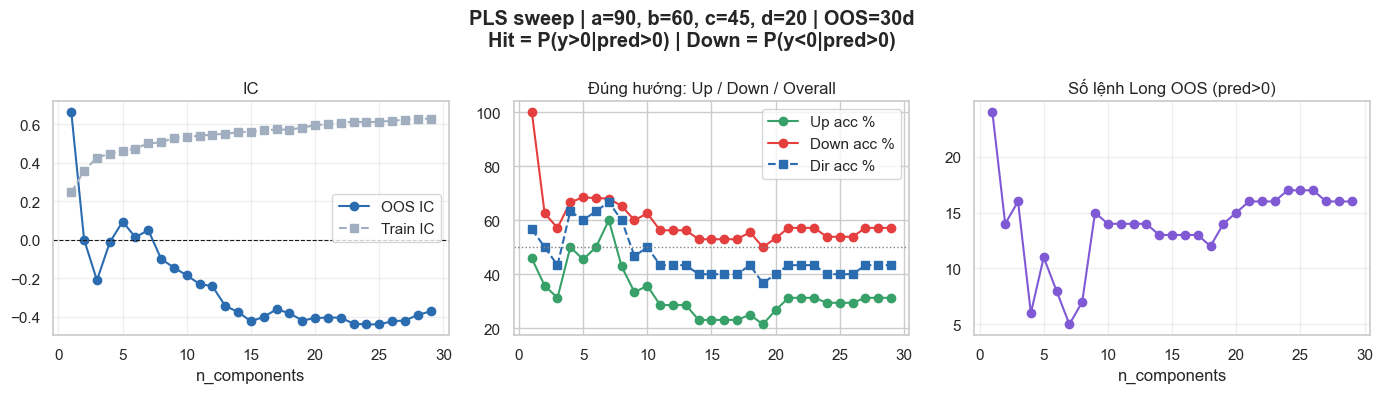

In [303]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# ============================================================
# PARAMS
# ============================================================
best = study.best_trial
a = best.user_attrs["a"]
b = best.user_attrs["b"]
c = best.user_attrs["c"]
d = best.user_attrs["d"]

N_COMP_LIST = list(range(1, 30))
LOOKBACK = LOOKBACK_DAYS
OOS = OOS_DAYS
MIN_SIGNALS = 3  # tối thiểu số lệnh long để tính hit/down

print(f"Fixed: a={a}, b={b}, c={c}, d={d}")
print("=" * 70)

# ============================================================
# DATA
# ============================================================
df_feat = build_features(df_vni_raw, investor_groups, a, b, c, d)
target = build_target(df_vni_raw, horizon=10)
model_data = pd.concat([df_feat, target], axis=1)
model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()

y_col = target.name
X_cols = list(df_feat.columns)

total_needed = LOOKBACK + OOS
train_data = model_data.iloc[-total_needed:-OOS].copy()
oos_data = model_data.iloc[-OOS:].copy()

X_train = StandardScaler().fit_transform(train_data[X_cols].values)
y_train = train_data[y_col].values
scaler = StandardScaler().fit(train_data[X_cols].values)
X_train = scaler.transform(train_data[X_cols].values)
X_oos = scaler.transform(oos_data[X_cols].values)
y_oos = oos_data[y_col].values

n_feat, n_samp = X_train.shape[1], X_train.shape[0]

def direction_stats(pred, y, min_sig=3):
    """
    Up accuracy  = P(y>0 | pred>0)
    Down accuracy = P(y<0 | pred<0)
    """
    mask_up = pred > 0
    mask_dn = pred < 0
    n_up = int(mask_up.sum())
    n_dn = int(mask_dn.sum())

    up_acc = float((y[mask_up] > 0).mean()) if n_up >= min_sig else np.nan
    dn_acc = float((y[mask_dn] < 0).mean()) if n_dn >= min_sig else np.nan

    # optional: overall directional accuracy (bỏ pred≈0)
    mask_dir = pred != 0
    if mask_dir.sum() >= min_sig:
        correct = ((pred > 0) & (y > 0)) | ((pred < 0) & (y < 0))
        dir_acc = float(correct[mask_dir].mean())
    else:
        dir_acc = np.nan

    return dict(
        n_up=n_up,
        n_down=n_dn,
        up_acc=up_acc,      # đúng khi đoán UP
        down_acc=dn_acc,    # đúng khi đoán DOWN
        dir_acc=dir_acc,    # đúng hướng tổng (up hoặc down)
    )

# ============================================================
# SWEEP
# ============================================================
rows = []
for n_comp in N_COMP_LIST:
    n_comp_eff = int(max(1, min(n_comp, n_feat, n_samp - 1)))
    try:
        model = PLSRegression(n_components=n_comp_eff, scale=False)
        model.fit(X_train, y_train)
        pred_tr = model.predict(X_train).ravel()
        pred_oos = model.predict(X_oos).ravel()

        if np.std(pred_oos) < 1e-8:
            rows.append({"n_components": n_comp_eff, "oos_ic": np.nan})
            continue

        tr_ic, _ = spearmanr(pred_tr, y_train)
        oos_ic, _ = spearmanr(pred_oos, y_oos)
        st_oos = direction_stats(pred_oos, y_oos, min_sig=MIN_SIGNALS)
        st_tr  = direction_stats(pred_tr, y_train, min_sig=15)

        rows.append({
            "n_components": n_comp_eff,
            "train_ic": float(tr_ic) if not np.isnan(tr_ic) else np.nan,
            "oos_ic": float(oos_ic) if not np.isnan(oos_ic) else np.nan,
            "oos_up_acc": st_oos["up_acc"],
            "oos_down_acc": st_oos["down_acc"],
            "oos_dir_acc": st_oos["dir_acc"],
            "oos_n_up": st_oos["n_up"],
            "oos_n_down": st_oos["n_down"],
            "train_up_acc": st_tr["up_acc"],
            "train_down_acc": st_tr["down_acc"],
            "gap_ic": (float(tr_ic) - float(oos_ic))
                if not (np.isnan(tr_ic) or np.isnan(oos_ic)) else np.nan,
        })
    except Exception as e:
        rows.append({"n_components": n_comp, "error": str(e)})

df_sweep = pd.DataFrame(rows)

# In bảng chính
cols_show = [
    "n_components", "oos_ic",
    "oos_up_acc", "oos_down_acc", "oos_dir_acc",
    "oos_n_up", "oos_n_down",
    "train_ic", "gap_ic",
]
print(df_sweep[cols_show].to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# cols_show = [c for c in cols_show if c in df_sweep.columns]
# print("\n=== OOS IC / Hit / Down theo n_components ===\n")
# print(df_sweep[cols_show].to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ============================================================
# PLOT
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.plot(df_sweep["n_components"], df_sweep["oos_ic"], "o-", label="OOS IC", color="#2b6cb0")
ax.plot(df_sweep["n_components"], df_sweep["train_ic"], "s--", label="Train IC", color="#a0aec0")
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.set_title("IC")
ax.set_xlabel("n_components")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(df_sweep["n_components"], df_sweep["oos_up_acc"] * 100, "o-", label="Up acc %", color="#38a169")
ax.plot(df_sweep["n_components"], df_sweep["oos_down_acc"] * 100, "o-", label="Down acc %", color="#e53e3e")
ax.plot(df_sweep["n_components"], df_sweep["oos_dir_acc"] * 100, "s--", label="Dir acc %", color="#2b6cb0")
ax.axhline(50, color="gray", ls=":", lw=1)
ax.set_title("Đúng hướng: Up / Down / Overall")
ax.legend()

ax = axes[2]
ax.plot(df_sweep["n_components"], df_sweep["oos_n_up"], "o-", color="#805ad5")
ax.set_title("Số lệnh Long OOS (pred>0)")
ax.set_xlabel("n_components")
ax.grid(True, alpha=0.3)

fig.suptitle(
    f"PLS sweep | a={a}, b={b}, c={c}, d={d} | OOS={OOS}d\n"
    f"Hit = P(y>0|pred>0) | Down = P(y<0|pred>0)",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

BEST PARAMS (PLS)
a = 90 | b = 60 | c = 45 | d = 20
n_components = 25
LOOKBACK = 1000 | OOS = 30
Số feature: 61 | Số dòng hợp lệ: 1746
TRAIN: 1000 | OOS: 30

========== TRAIN ==========
IC           : 0.6141
Hit Rate     : 0.7060
n_components : 25
Số quan sát  : 1000
Pred std     : 0.037044

========== OOS ==========
IC          : -0.4407
Hit Rate    : 0.2941
Signals     : 17
Số quan sát : 30

=== Rank IC (Train+OOS) = 0.5479 ===
                mean    std  count  hit_rate  avg_pred
score_decile                                          
0            -0.0607 0.0823    103    0.1748   -0.0772
1            -0.0368 0.0541    103    0.1068   -0.0329
2            -0.0202 0.0320    103    0.2330   -0.0205
3            -0.0113 0.0342    103    0.3495   -0.0107
4            -0.0072 0.0437    103    0.3786   -0.0038
5             0.0183 0.0424    103    0.6408    0.0051
6             0.0051 0.0356    103    0.5340    0.0143
7             0.0187 0.0517    103    0.6699    0.0237
8             0.

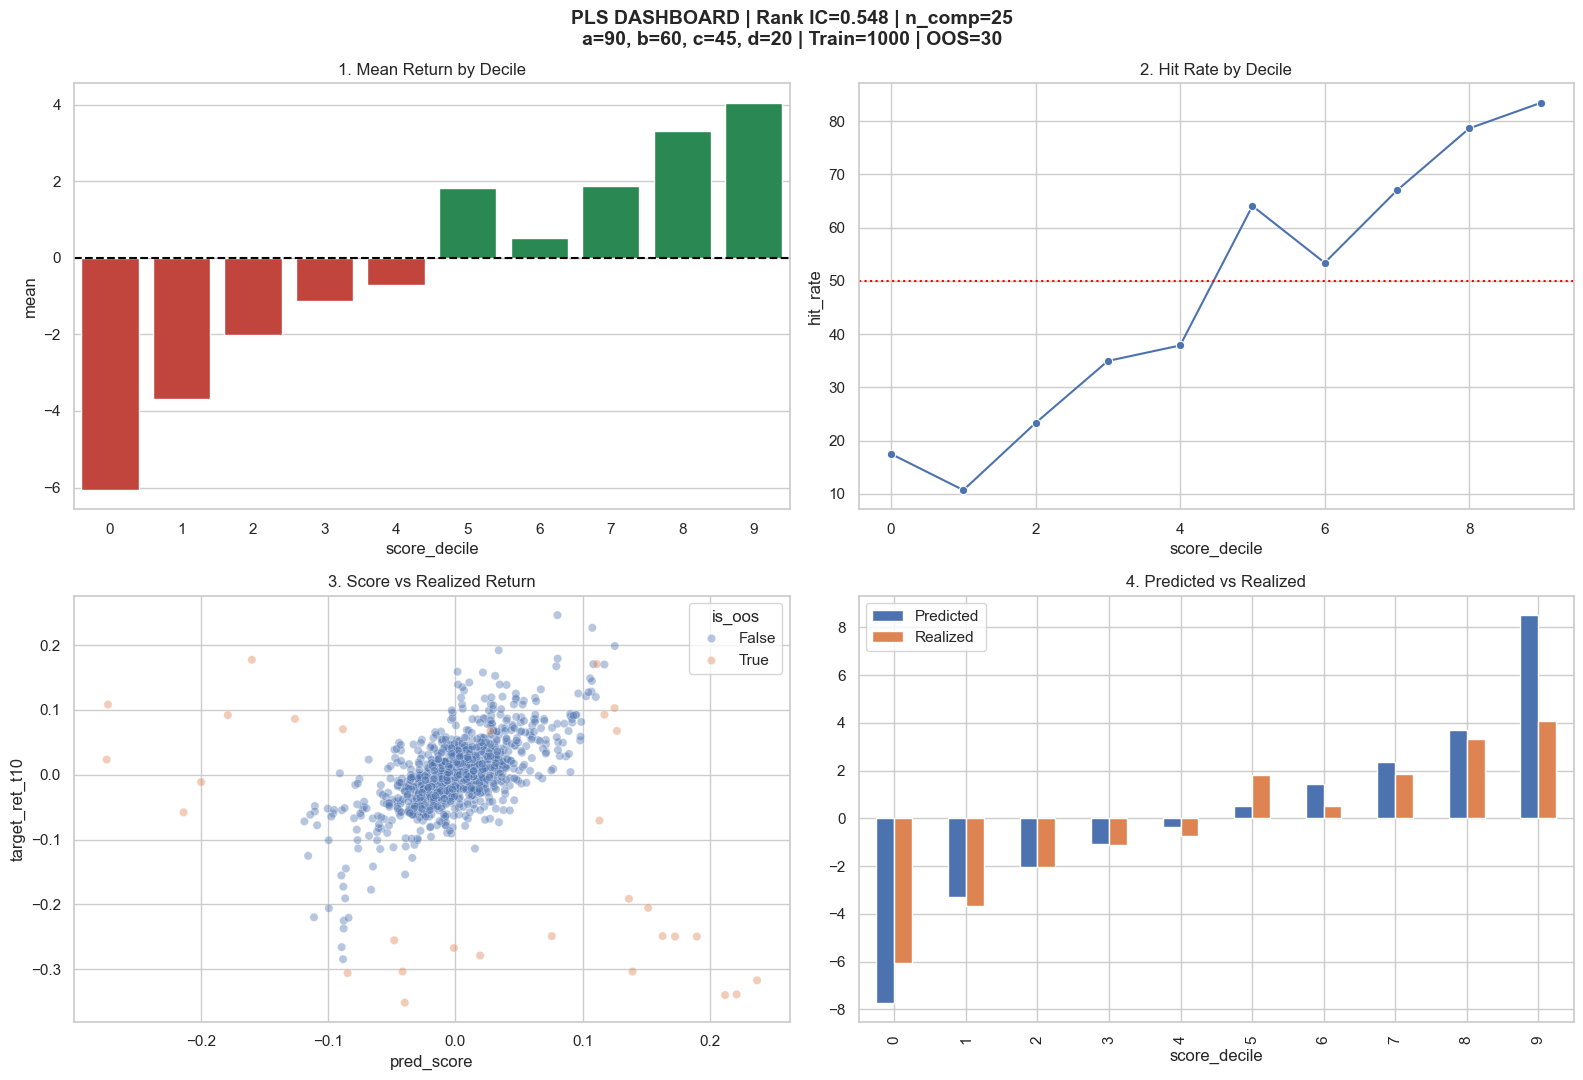

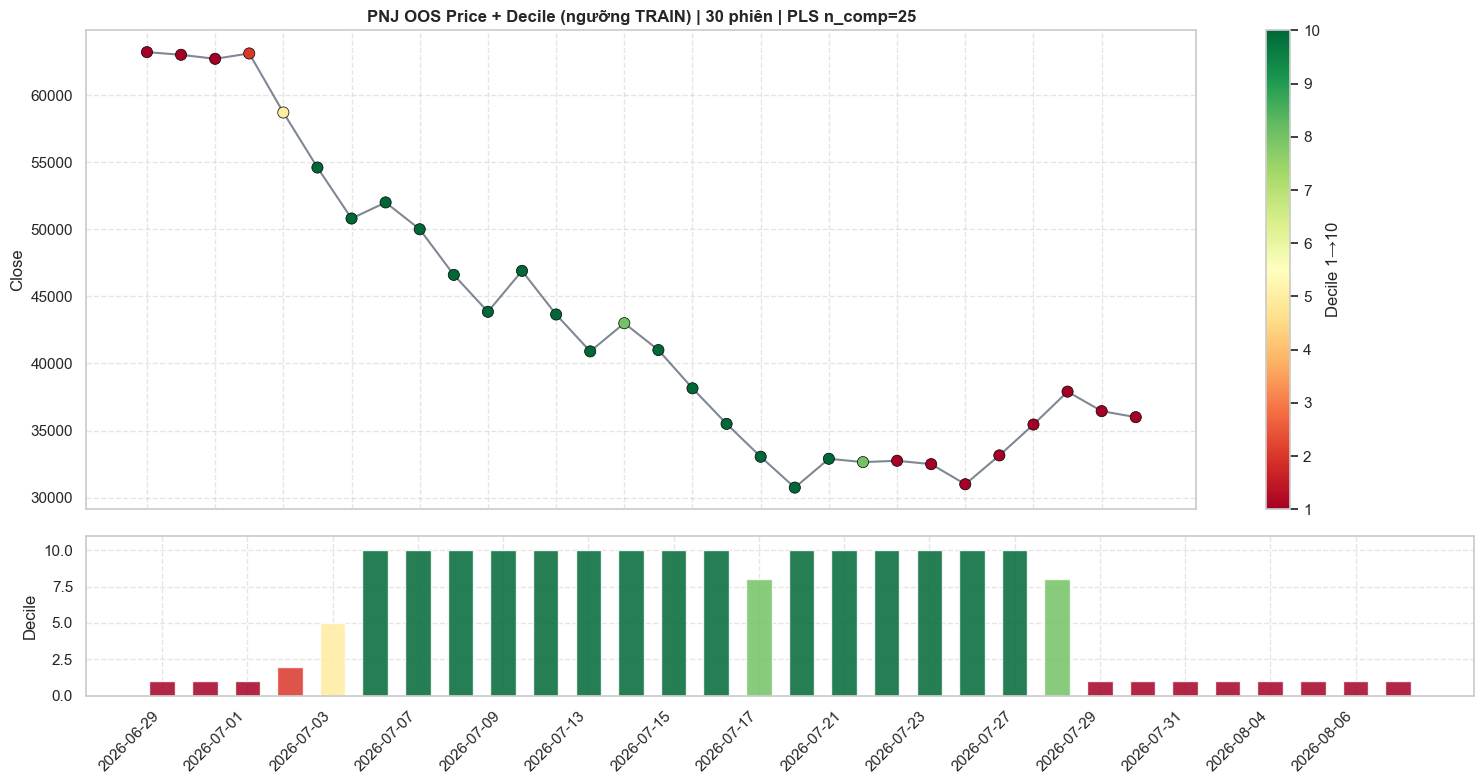

In [304]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# 1. LẤY BEST PARAMS TỪ OPTUNA (PLS)
# ============================================================
best = study.best_trial

a = best.user_attrs["a"]
b = best.user_attrs["b"]
c = best.user_attrs["c"]
d = best.user_attrs["d"]
n_components = int(best.user_attrs["n_components"])

print("=" * 70)
print("BEST PARAMS (PLS)")
print("=" * 70)
print(f"a = {a} | b = {b} | c = {c} | d = {d}")
print(f"n_components = {n_components}")
print(f"LOOKBACK = {LOOKBACK_DAYS} | OOS = {OOS_DAYS}")
print("=" * 70)

y_col = "target_ret_t10"

# ============================================================
# 2. TẠO FEATURE + TARGET (đúng chữ ký build_features của bạn)
# ============================================================
df_feat = build_features(df_vni_raw, investor_groups, a, b, c, d)
target = build_target(df_vni_raw, horizon=10)

model_data = pd.concat([df_feat, target], axis=1)
model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()

# Thêm close để vẽ biểu đồ giá (không dùng để train)
close_aligned = df_vni_raw["close"].ffill().reindex(model_data.index)
model_data["close"] = close_aligned

X_cols = list(df_feat.columns)
print(f"Số feature: {len(X_cols)} | Số dòng hợp lệ: {len(model_data)}")

# ============================================================
# 3. CẮT TRAIN / OOS
# ============================================================
total_needed = LOOKBACK_DAYS + OOS_DAYS

if len(model_data) >= total_needed:
    train_data = model_data.iloc[-total_needed:-OOS_DAYS].copy()
    oos_data = model_data.iloc[-OOS_DAYS:].copy()
else:
    if len(model_data) > OOS_DAYS:
        train_data = model_data.iloc[:-OOS_DAYS].copy()
        oos_data = model_data.iloc[-OOS_DAYS:].copy()
    else:
        train_data = model_data.copy()
        oos_data = pd.DataFrame(columns=model_data.columns)

print(f"TRAIN: {len(train_data)} | OOS: {len(oos_data)}")

# ============================================================
# 4. FIT PLS TRÊN TRAIN
# ============================================================
X_train = train_data[X_cols].values
y_train = train_data[y_col].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

n_feat = X_train_scaled.shape[1]
n_samp = X_train_scaled.shape[0]
n_comp = int(max(1, min(n_components, n_feat, n_samp - 1)))

model = PLSRegression(n_components=n_comp, scale=False)
model.fit(X_train_scaled, y_train)

train_data = train_data.copy()
train_data["pred_score"] = model.predict(X_train_scaled).ravel()
train_data["actual_ret"] = y_train

ic_train, _ = spearmanr(train_data["pred_score"], train_data["actual_ret"])
hit_train = (
    train_data.loc[train_data["pred_score"] > 0, "actual_ret"] > 0
).mean()

print("\n========== TRAIN ==========")
print(f"IC           : {ic_train:.4f}")
print(f"Hit Rate     : {hit_train:.4f}")
print(f"n_components : {n_comp}")
print(f"Số quan sát  : {len(train_data)}")
print(f"Pred std     : {train_data['pred_score'].std():.6f}")

# ============================================================
# 5. ĐÁNH GIÁ OOS
# ============================================================
if len(oos_data) > 0:
    X_oos = oos_data[X_cols].values
    X_oos_scaled = scaler.transform(X_oos)

    oos_data = oos_data.copy()
    oos_data["pred_score"] = model.predict(X_oos_scaled).ravel()
    oos_data["actual_ret"] = oos_data[y_col].values

    ic_oos, _ = spearmanr(oos_data["pred_score"], oos_data["actual_ret"])
    n_sig = int((oos_data["pred_score"] > 0).sum())
    hit_oos = (
        (oos_data.loc[oos_data["pred_score"] > 0, "actual_ret"] > 0).mean()
        if n_sig > 0
        else np.nan
    )

    print("\n========== OOS ==========")
    print(f"IC          : {ic_oos:.4f}")
    print(f"Hit Rate    : {hit_oos:.4f}")
    print(f"Signals     : {n_sig}")
    print(f"Số quan sát : {len(oos_data)}")
else:
    print("\n[OOS] Không đủ dữ liệu")

# ============================================================
# 6. DECILE ANALYSIS (Train + OOS)
# ============================================================
parts = [train_data[["pred_score", y_col]].assign(is_oos=False)]
if len(oos_data) > 0:
    parts.append(oos_data[["pred_score", y_col]].assign(is_oos=True))

eval_data = pd.concat(parts, axis=0).dropna()
eval_data["score_decile"] = pd.qcut(
    eval_data["pred_score"], 10, labels=False, duplicates="drop"
)

analysis = eval_data.groupby("score_decile")[y_col].agg(["mean", "std", "count"])
analysis["hit_rate"] = eval_data.groupby("score_decile")[y_col].apply(
    lambda x: (x > 0).mean()
)
analysis["avg_pred"] = eval_data.groupby("score_decile")["pred_score"].mean()

rank_ic = eval_data["pred_score"].corr(eval_data[y_col], method="spearman")
print(f"\n=== Rank IC (Train+OOS) = {rank_ic:.4f} ===")
print(analysis)

# ============================================================
# 7. DASHBOARD
# ============================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    f"PLS DASHBOARD | Rank IC={rank_ic:.3f} | n_comp={n_comp}\n"
    f"a={a}, b={b}, c={c}, d={d} | Train={len(train_data)} | OOS={len(oos_data)}",
    fontsize=14,
    fontweight="bold",
)

colors = ["#d73027" if x < 0 else "#1a9850" for x in analysis["mean"]]
sns.barplot(x=analysis.index, y=analysis["mean"] * 100, ax=axes[0, 0], palette=colors)
axes[0, 0].axhline(0, color="black", ls="--")
axes[0, 0].set_title("1. Mean Return by Decile")

sns.lineplot(x=analysis.index, y=analysis["hit_rate"] * 100, ax=axes[0, 1], marker="o")
axes[0, 1].axhline(50, color="red", ls=":")
axes[0, 1].set_title("2. Hit Rate by Decile")

sns.scatterplot(
    data=eval_data, x="pred_score", y=y_col, hue="is_oos", ax=axes[1, 0], alpha=0.4
)
axes[1, 0].set_title("3. Score vs Realized Return")

pd.DataFrame(
    {
        "Predicted": analysis["avg_pred"] * 100,
        "Realized": analysis["mean"] * 100,
    }
).plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("4. Predicted vs Realized")

plt.tight_layout()
plt.show()

# ============================================================
# 8. BIỂU ĐỒ GIÁ + DECILE OOS (ngưỡng decile từ TRAIN)
# ============================================================
if len(oos_data) > 0 and "close" in oos_data.columns:
    train_scores = train_data["pred_score"]
    _, bin_edges = pd.qcut(train_scores, q=10, duplicates="drop", retbins=True)
    bin_edges = bin_edges.copy()
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf
    n_deciles = len(bin_edges) - 1

    oos_data = oos_data.copy()
    oos_data["decile"] = (
        pd.cut(
            oos_data["pred_score"],
            bins=bin_edges,
            labels=False,
            include_lowest=True,
        )
        + 1
    )

    if "time" in df_vni_raw.columns:
        raw_dates = df_vni_raw.loc[oos_data.index, "time"]
    else:
        raw_dates = oos_data.index

    if pd.api.types.is_datetime64_any_dtype(raw_dates):
        x_dates = pd.to_datetime(raw_dates).dt.strftime("%Y-%m-%d").values
    else:
        x_dates = pd.to_datetime(raw_dates).strftime("%Y-%m-%d").values

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
    )

    ax1.plot(
        x_dates, oos_data["close"], color="#4A5568", lw=1.5, alpha=0.7, label="Close"
    )
    sc = ax1.scatter(
        x_dates,
        oos_data["close"],
        c=oos_data["decile"],
        cmap="RdYlGn",
        vmin=1,
        vmax=n_deciles,
        s=65,
        zorder=5,
        edgecolors="black",
        linewidth=0.5,
    )
    title_sym = globals().get("SYMBOL", "")
    ax1.set_title(
        f"{title_sym} OOS Price + Decile (ngưỡng TRAIN) | {len(oos_data)} phiên | PLS n_comp={n_comp}",
        fontweight="bold",
    )
    ax1.set_ylabel("Close")
    ax1.grid(True, ls="--", alpha=0.5)
    plt.colorbar(sc, ax=ax1, label=f"Decile 1→{n_deciles}")

    norm = (n_deciles - 1) if n_deciles > 1 else 1
    bar_colors = plt.cm.RdYlGn((oos_data["decile"].astype(float) - 1) / norm)
    ax2.bar(x_dates, oos_data["decile"], color=bar_colors, alpha=0.85, width=0.6)
    ax2.set_ylabel("Decile")
    ax2.set_ylim(0, n_deciles + 1)
    ax2.grid(True, ls="--", alpha=0.5)
    plt.xticks(
        rotation=45,
        ha="right",
        ticks=range(0, len(x_dates), max(1, len(x_dates) // 15)),
    )

    plt.tight_layout()
    plt.show()

In [301]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ============================================================
# OLS – Kiểm tra độ lớn & ý nghĩa của các biến
# ============================================================
def run_ols_analysis(train_data, X_cols, y_col="target_ret_t10", top_n=30):
    """
    Chạy OLS trên tập TRAIN (đã scale) để xem độ lớn hệ số và p-value.
    """
    X = train_data[X_cols].copy()
    y = train_data[y_col].copy()

    # Scale để so sánh độ lớn hệ số công bằng
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(
        scaler.fit_transform(X),
        columns=X_cols,
        index=X.index
    )

    # Thêm hằng số
    X_const = sm.add_constant(X_scaled)

    # Fit OLS
    ols_model = sm.OLS(y, X_const).fit()

    print("=" * 70)
    print("OLS SUMMARY (Train – Standardized Coefficients)")
    print("=" * 70)
    print(ols_model.summary().tables[1])   # bảng hệ số

    # ----- Bảng hệ số đẹp hơn -----
    coef_df = pd.DataFrame({
        "feature": ols_model.params.index,
        "coef": ols_model.params.values,
        "std_err": ols_model.bse.values,
        "t": ols_model.tvalues.values,
        "p_value": ols_model.pvalues.values,
        "abs_coef": np.abs(ols_model.params.values)
    })
    coef_df = coef_df[coef_df["feature"] != "const"]
    coef_df = coef_df.sort_values("abs_coef", ascending=False)

    print("\n" + "=" * 70)
    print(f"TOP {top_n} BIẾN CÓ |HỆ SỐ| LỚN NHẤT")
    print("=" * 70)
    print(coef_df.head(top_n)[["feature", "coef", "t", "p_value"]].to_string(index=False))

    # ----- Các biến có p-value < 0.05 -----
    sig = coef_df[coef_df["p_value"] < 0.05].sort_values("abs_coef", ascending=False)
    print("\n" + "=" * 70)
    print(f"BIẾN CÓ Ý NGHĨA THỐNG KÊ (p < 0.05) – {len(sig)} biến")
    print("=" * 70)
    if len(sig) > 0:
        print(sig[["feature", "coef", "t", "p_value"]].head(20).to_string(index=False))
    else:
        print("Không có biến nào p < 0.05")

    # ----- VIF (kiểm tra đa cộng tuyến) -----
    print("\n" + "=" * 70)
    print("VIF (Top 15 cao nhất)")
    print("=" * 70)
    vif_data = []
    X_vif = X_scaled.copy()
    for i, col in enumerate(X_vif.columns):
        try:
            vif = variance_inflation_factor(X_vif.values, i)
        except:
            vif = np.nan
        vif_data.append({"feature": col, "VIF": vif})
    vif_df = pd.DataFrame(vif_data).sort_values("VIF", ascending=False)
    print(vif_df.head(15).to_string(index=False))

    return ols_model, coef_df, vif_df


# ============================================================
# GỌI HÀM (chạy sau khi đã có train_data và X_cols)
# ============================================================
ols_model, coef_df, vif_df = run_ols_analysis(
    train_data=train_data,
    X_cols=X_cols,
    y_col=y_col,
    top_n=30
)

OLS SUMMARY (Train – Standardized Coefficients)
                                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
const                                         0.0014      0.001      1.067      0.286      -0.001       0.004
feat_foreign_sentiment_ewm                    0.0472      0.012      4.011      0.000       0.024       0.070
feat_foreign_sentiment_cubed                  0.0103      0.003      3.515      0.000       0.005       0.016
feat_foreign_flow_impulse_20d                -0.0245      0.007     -3.750      0.000      -0.037      -0.012
feat_foreign_eff_flow                        -0.0053      0.003     -1.738      0.083      -0.011       0.001
feat_foreign_val_share                       -0.0007      0.002     -0.398      0.690      -0.004       0.003
feat_foreign_rel_net_price_ewm               -0.0131      0.004     -3.0

In [302]:
import numpy as np
import pandas as pd

# Giả sử bạn đã fit xong:
# model = PLSRegression(...).fit(X_train_scaled, y_train)
# X_cols = list feature

# ----- 1. Hệ số PLS (độ lớn ảnh hưởng) -----
coef = model.coef_.ravel()          # shape (n_features,)
coef_df = pd.DataFrame({
    "feature": X_cols,
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)

print("=" * 60)
print("TOP 20 BIẾN CÓ |HỆ SỐ PLS| LỚN NHẤT")
print("=" * 60)
print(coef_df.head(20).to_string(index=False))


# ----- 2. VIP (Variable Importance in Projection) – chuẩn của PLS -----
def compute_vip(model, X, y):
    """
    Tính VIP score cho PLS
    """
    t = model.x_scores_              # (n_samples, n_components)
    w = model.x_weights_             # (n_features, n_components)
    q = model.y_loadings_            # (n_components,) hoặc (1, n_components)
    
    p, h = w.shape
    
    # Đảm bảo y là numpy array 2D
    y = np.asarray(y).reshape(-1, 1)
    
    # Đảm bảo q đúng shape
    q = np.asarray(q).reshape(-1)    # (n_components,)
    
    # SS cho từng component
    ssy = np.sum((t * q) ** 2, axis=0)   # (n_components,)
    total_ssy = np.sum(ssy)
    
    vip = np.zeros(p)
    for i in range(p):
        weight = np.array([w[i, j]**2 for j in range(h)])
        vip[i] = np.sqrt(p * (np.sum(weight * ssy) / total_ssy))
    
    return vip

vip_scores = compute_vip(model, X_train_scaled, y_train)

vip_df = pd.DataFrame({
    "feature": X_cols,
    "VIP": vip_scores,
    "abs_coef": np.abs(coef)
}).sort_values("VIP", ascending=False)

print("\n" + "=" * 60)
print("TOP 20 BIẾN THEO VIP (PLS)")
print("=" * 60)
print(vip_df.head(20).to_string(index=False))

print("\nSố biến có VIP > 1 :", (vip_df["VIP"] > 1).sum())
print("Số biến có VIP > 0.8:", (vip_df["VIP"] > 0.8).sum())

TOP 20 BIẾN CÓ |HỆ SỐ PLS| LỚN NHẤT
                                  feature    coef  abs_coef
            feat_local_inst_sentiment_ewm  0.0977    0.0977
        cross_agree_strength_foreign_prop  0.0713    0.0713
                 inter_foreign_sent_x_atr -0.0649    0.0649
              feat_prop_rel_net_price_ewm  0.0629    0.0629
  cross_agree_strength_foreign_local_inst  0.0602    0.0602
                    inter_prop_sent_x_atr  0.0488    0.0488
             feat_local_ind_sentiment_ewm  0.0478    0.0478
   cross_agree_strength_foreign_local_ind  0.0462    0.0462
          feat_local_ind_flow_impulse_20d -0.0448    0.0448
cross_agree_strength_local_inst_local_ind  0.0436    0.0436
      cross_agree_strength_prop_local_ind  0.0426    0.0426
    cross_foreign_minus_local_inst_sent_z  0.0387    0.0387
     cross_agree_strength_prop_local_inst  0.0386    0.0386
          cross_foreign_minus_prop_sent_z  0.0378    0.0378
               feat_foreign_sentiment_ewm  0.0328    0.0328
    

# cân nhác thêm ridge

In [172]:
SYMBOL = 'VIC'

# --- BƯỚC 1: CHUẨN BỊ DỮ LIỆU ---
excel_file_path_vni = rf"E:\Document\Tao\FiinGroup\csv_data_2\Kafi_Phân_Loại_Nhà_Đầu_Tư_{SYMBOL}.csv"
excel_file_path_vni_new = rf"E:\Document\Tao\FiinGroup\csv_data_2\Kafi_Giá_{SYMBOL}.csv"
# excel_file_path_vni = rf"E:\Document\Tao\FiinGroup\Kafi_Phân_Loại_Nhà_Đầu_Tư_{SYMBOL}_20260305.xlsx"

investor_groups = ['foreign', 'prop', 'local_ind', 'local_inst']

df_vni_raw = load_and_map_excel(excel_file_path_vni, df_history=None)

In [288]:
import optuna
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from scipy.stats import spearmanr
from itertools import combinations
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# CẤU HÌNH
# ============================================================
investor_groups = ["foreign", "prop", "local_inst", "local_ind"]
LOOKBACK_DAYS = 1000
OOS_DAYS = 30
TRIALS = 300

A_MIN, A_MAX = 50, 200
B_MIN, B_MAX = 50, 200
C_MIN, C_MAX = 10, 80
D_MIN, D_MAX = 15, 50

# Số thành phần PLS (Optuna sẽ chọn trong khoảng này)
N_COMP_MIN, N_COMP_MAX = 2, 15

# Trọng số score (chỉ trên Train)
W_HIT = 0.8
W_IC = 0.2
W_TOP = 0.35          # Chất lượng 2 decile cao nhất
W_BOT = 0.25          # Chất lượng 2 decile thấp nhất

# Ngưỡng mong muốn
TOP_HIT_TARGET = 0.8         # 2 decile cao nhất nên ≥ 85% return dương
BOT_HIT_TARGET = 0.2         # 2 decile thấp nhất nên ≤ 15% return dương

# Ngưỡng trên TRAIN
MIN_SIGNALS_TRAIN_SOFT = 20
MIN_SIGNALS_TRAIN_HARD = 10
MIN_HIT_TRAIN_SOFT = 0.6
MIN_HIT_TRAIN_HARD = 0.55
MIN_IC_TRAIN_HARD = 0.02

# bad_result: đủ 9 phần tử, khớp unpack trong objective
BAD_RESULT = (-999.0, -1.0, 0.0, 0.0, 0, 0, -1.0, 0.0, 999.0)

# ============================================================
# FEATURE ENGINEERING (giữ nguyên logic của bạn)
# ============================================================
def build_features(df_vni_raw, investor_groups, a, b, c, d):
    df = df_vni_raw.copy()
    keep_cols = [
        "open", "high", "low", "close", "trading_value",
        "foreign_net_val", "prop_net_val", "local_ind_net_val", "local_inst_net_val",
        "foreign_net_vol", "prop_net_vol", "local_ind_net_vol", "local_inst_net_vol",
    ]
    keep_cols = [col for col in keep_cols if col in df.columns]
    df = df[keep_cols]

    # FIX 1: Tránh Data Leakage (thay interpolate bằng ffill)
    df["trading_value"] = df["trading_value"].replace(0, np.nan).ffill().bfill()
    df["close"] = df["close"].ffill()
    df["log_ret"] = np.log(df["close"] / df["close"].shift(1)).fillna(0)
    df["abs_ret"] = df["log_ret"].abs()

    tr = np.maximum(
        df["high"] - df["low"],
        np.maximum(
            (df["high"] - df["close"].shift(1)).abs(),
            (df["low"] - df["close"].shift(1)).abs(),
        ),
    )

    # Technical indicators
    roll_high = df["high"].rolling(c).max()
    roll_low = df["low"].rolling(c).min()
    ta_pos_in_range = ((df["close"] - roll_low) / (roll_high - roll_low + 1e-8)).fillna(0.5)
    ta_atr_pct = (tr.ewm(span=b, adjust=False).mean() / df["close"]).fillna(0)

    feature_dict = {}

    # ===== Group-level features =====
    for g in investor_groups:
        net_val = df[f"{g}_net_val"]
        net_ratio = net_val / df["trading_value"]
        df[f"feat_{g}_net_ratio"] = net_ratio.fillna(0)

        # FIX 2: Sửa Price Impact bị nổ số (nâng floor mẫu số + clip giá trị)
        prev = net_ratio.shift(1).abs().clip(lower=1e-3)
        impact_raw = (df["abs_ret"].shift(1) / prev).rolling(5).median().fillna(0)
        df[f"feat_{g}_price_impact"] = np.clip(impact_raw, 0, 10)

        # Sentiment Min-Max
        rmin = net_val.rolling(a, min_periods=5).min()
        rmax = net_val.rolling(a, min_periods=5).max()
        df[f"feat_{g}_sentiment"] = (
            2 * (net_val - rmin) / (rmax - rmin + 1e-6) - 1
        ).fillna(0)

        # Sentiment EWM & Z-score
        sent = df[f"feat_{g}_sentiment"]
        sent_ewm = sent.ewm(span=b, adjust=False).mean()
        feature_dict[f"feat_{g}_sentiment_ewm"] = sent_ewm

        sent_mean = sent_ewm.rolling(a, min_periods=10).mean()
        sent_std = sent_ewm.rolling(a, min_periods=10).std().replace(0, np.nan)
        sent_z = ((sent_ewm - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

        # Polynomials & Saturation Flag
        feature_dict[f"feat_{g}_sentiment_sq"] = sent_z**2
        feature_dict[f"feat_{g}_sentiment_cubed"] = (sent_z**3 - 3 * sent_z).clip(-10, 10)
        feature_dict[f"flag_{g}_sent_saturated"] = (sent_z.abs() >= 2.8).astype(int)

        # Impulse
        impulse = sent_ewm.diff(d).fillna(0)
        feature_dict[f"feat_{g}_flow_impulse_{d}d"] = impulse

        # FIX 3: Effective flow nén bằng Signed Log Transform
        eff_flow_raw = sent * df[f"feat_{g}_price_impact"]
        feature_dict[f"feat_{g}_eff_flow"] = np.sign(eff_flow_raw) * np.log1p(np.abs(eff_flow_raw))

        # Share & Weighted Sentiment
        val_share = (df[f"{g}_net_val"].abs() / df["trading_value"]).clip(0, 1)
        feature_dict[f"feat_{g}_val_share"] = val_share
        feature_dict[f"feat_{g}_weighted_sent"] = sent_ewm * val_share  # FEATURE MỚI 1

        # Interactions
        feature_dict[f"inter_{g}_sent_x_pos"] = sent_z * ta_pos_in_range
        feature_dict[f"inter_{g}_sent_x_atr"] = sent_z * ta_atr_pct

    # ===== Cross-investor Features =====
    sent_ewm = {g: feature_dict[f"feat_{g}_sentiment_ewm"] for g in investor_groups}
    sent_z = {}
    for g in investor_groups:
        mu = sent_ewm[g].rolling(a, min_periods=10).mean()
        sigma = sent_ewm[g].rolling(a, min_periods=10).std().replace(0, np.nan)
        sent_z[g] = ((sent_ewm[g] - mu) / (sigma + 1e-6)).clip(-3, 3).fillna(0)

    for g1, g2 in combinations(investor_groups, 2):
        feature_dict[f"cross_{g1}_minus_{g2}_sent_z"] = sent_z[g1] - sent_z[g2]
        feature_dict[f"cross_agree_sign_{g1}_{g2}"] = np.sign(sent_ewm[g1]) * np.sign(sent_ewm[g2])
        feature_dict[f"cross_agree_strength_{g1}_{g2}"] = sent_ewm[g1] * sent_ewm[g2]

    # Dispersion
    sent_matrix = pd.concat([sent_ewm[g] for g in investor_groups], axis=1)
    disp_std = sent_matrix.std(axis=1)
    feature_dict["cross_dispersion_std"] = disp_std
    feature_dict["cross_dispersion_range"] = sent_matrix.max(axis=1) - sent_matrix.min(axis=1)
    feature_dict["cross_dispersion_iqr"] = sent_matrix.quantile(0.75, axis=1) - sent_matrix.quantile(0.25, axis=1)

    # FEATURE MỚI 2: Smart Money vs Retail Spread
    smart_cols = [g for g in ["foreign", "prop", "local_inst"] if g in investor_groups]
    if "local_ind" in investor_groups and len(smart_cols) > 0:
        smart_sent = pd.concat([sent_ewm[g] for g in smart_cols], axis=1).mean(axis=1)
        feature_dict["cross_smart_vs_retail_sent"] = smart_sent - sent_ewm["local_ind"]

    # FEATURE MỚI 3: Volatility-Adjusted Sentiment
    for g in investor_groups:
        feature_dict[f"feat_{g}_vol_adj_sent"] = sent_ewm[g] / (disp_std + 1e-4)
    return pd.DataFrame(feature_dict, index=df.index)


def build_target(df_vni_raw, horizon=10):
    close = df_vni_raw["close"].ffill()
    target = close.shift(-horizon) / close - 1
    target.name = f"target_ret_t{horizon}"
    return target

# ============================================================
# Hàm đánh giá – PLS + score ưu tiên đơn điệu
# ============================================================
def evaluate_params_pls(
    a, b, c, d, n_components,
    df_vni_raw,
    investor_groups,
    lookback_days=LOOKBACK_DAYS,
    oos_days=OOS_DAYS,
):
    try:
        df_feat = build_features(df_vni_raw, investor_groups, a, b, c, d)
        target = build_target(df_vni_raw, horizon=10)
        model_data = pd.concat([df_feat, target], axis=1)
        model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()

        if len(model_data) < (lookback_days + oos_days + 50):
            return BAD_RESULT

        train_data = model_data.iloc[-(lookback_days + oos_days) : -oos_days].copy()
        oos_data   = model_data.iloc[-oos_days:].copy()

        if len(train_data) < 300 or len(oos_data) < 10:
            return BAD_RESULT

        target_col = target.name
        X_train = train_data.drop(columns=[target_col]).values
        y_train = train_data[target_col].values
        X_oos   = oos_data.drop(columns=[target_col]).values
        y_oos   = oos_data[target_col].values

        from sklearn.preprocessing import StandardScaler

        # Scale target
        y_scaler = StandardScaler()
        y_train = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
        y_oos   = y_scaler.transform(y_oos.reshape(-1, 1)).ravel()

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_oos_scaled   = scaler.transform(X_oos)

        # ----- PLS -----
        n_feat = X_train_scaled.shape[1]
        n_samp = X_train_scaled.shape[0]
        n_comp = int(max(1, min(n_components, n_feat, n_samp - 1)))

        model = PLSRegression(n_components=n_comp, scale=False)
        model.fit(X_train_scaled, y_train)

        pred_train = model.predict(X_train_scaled).ravel()
        pred_oos   = model.predict(X_oos_scaled).ravel()


        # Inverse transform để đưa prediction về scale gốc (nếu cần tính avg_ret thật)
        pred_train = y_scaler.inverse_transform(pred_train.reshape(-1, 1)).ravel()
        pred_oos   = y_scaler.inverse_transform(pred_oos.reshape(-1, 1)).ravel()

        if np.std(pred_train) < 1e-8:
            return BAD_RESULT

        # ============================================================
        # METRICS CƠ BẢN TRÊN TRAIN
        # ============================================================
        train_ic, _ = spearmanr(pred_train, y_train)
        if np.isnan(train_ic):
            train_ic = -1.0

        mask_up_train = pred_train > 0
        n_signals_train = int(mask_up_train.sum())

        if n_signals_train >= MIN_SIGNALS_TRAIN_HARD:
            hit_rate_train = float((y_train[mask_up_train] > 0.0005).mean())
            avg_ret_train  = float(y_train[mask_up_train].mean())
        else:
            hit_rate_train = 0.50
            avg_ret_train  = 0.0

        # ============================================================
        # DECILE ANALYSIS TRÊN TRAIN (quan trọng)
        # ============================================================
        try:
            deciles = pd.qcut(pred_train, 10, labels=False, duplicates="drop")
        except Exception:
            return BAD_RESULT

        df_dec = pd.DataFrame({"pred": pred_train, "y": y_train, "decile": deciles})
        decile_stats = df_dec.groupby("decile")["y"].agg(
            mean_ret="mean",
            hit_rate=lambda x: (x > 0).mean(),
            count="count"
        ).reindex(range(10))

        # 2 decile cao nhất (8, 9) và 2 decile thấp nhất (0, 1)
        top_stats = decile_stats.loc[[8, 9]].dropna()
        bot_stats = decile_stats.loc[[0, 1]].dropna()

        if len(top_stats) < 1 or len(bot_stats) < 1:
            return BAD_RESULT

        top_hit = top_stats["hit_rate"].mean()          # mong muốn ≥ 0.85
        bot_hit = bot_stats["hit_rate"].mean()          # mong muốn ≤ 0.15
        top_mean = top_stats["mean_ret"].mean()
        bot_mean = bot_stats["mean_ret"].mean()

        # Tính đơn điệu tổng thể (Spearman giữa decile và mean return)
        valid = decile_stats.dropna()
        if len(valid) >= 5:
            mono_score = spearmanr(valid.index, valid["mean_ret"])[0]
            if np.isnan(mono_score):
                mono_score = 0.0
        else:
            mono_score = 0.0

        # ============================================================
        # METRICS OOS (chỉ theo dõi)
        # ============================================================
        oos_ic, _ = spearmanr(pred_oos, y_oos)
        if np.isnan(oos_ic):
            oos_ic = -1.0

        mask_up_oos = pred_oos > 0
        n_signals_oos = int(mask_up_oos.sum())
        hit_rate_oos = float((y_oos[mask_up_oos] > 0).mean()) if n_signals_oos >= 3 else 0.50
        avg_ret_oos  = float(y_oos[mask_up_oos].mean()) if n_signals_oos >= 3 else 0.0

        train_oos_gap = train_ic - oos_ic

        # ============================================================
        # SCORE (ưu tiên đơn điệu + extreme deciles)
        # ============================================================
        # 1. Hit rate tổng
        hit_term = (hit_rate_train - 0.50) * 2.0

        # 2. IC
        ic_term = np.clip(train_ic, -0.15, 0.60)

        # 3. Top 2 decile (càng cao càng tốt)
        #    0.85 → 1.0 | 0.90 → 1.25 | dưới 0.70 thì thấp
        top_term = np.clip((top_hit - 0.50) / 0.40, 0, 1.5)

        # 4. Bottom 2 decile (càng thấp càng tốt)
        #    0.15 → 1.0 | 0.10 → 1.25 | trên 0.30 thì kém
        bot_term = np.clip((0.50 - bot_hit) / 0.40, 0, 1.5)

        # 5. Monotonicity
        mono_term = np.clip(mono_score, 0, 1.0)

        score = (
            W_HIT * hit_term +
            W_IC  * ic_term +
            W_TOP * top_term +
            W_BOT * bot_term +
            0.05  * mono_term          # thưởng nhẹ thêm cho đơn điệu tổng thể
        )

        # Thưởng nhẹ nếu top mean return cao và bot mean return thấp
        if top_mean > 0:
            score += 0.02 * np.clip(top_mean * 10, 0, 0.3)
        if bot_mean < 0:
            score += 0.02 * np.clip(-bot_mean * 10, 0, 0.3)

        # Soft penalty
        if n_signals_train < MIN_SIGNALS_TRAIN_SOFT:
            score *= 0.75
        if hit_rate_train < MIN_HIT_TRAIN_SOFT:
            score *= 0.80
        if top_hit < 0.75:                     # top chưa đủ mạnh
            score *= 0.70
        if bot_hit > 0.25:                     # bottom chưa đủ yếu
            score *= 0.75

        # Hard filter
        if (
            n_signals_train < MIN_SIGNALS_TRAIN_HARD
            or hit_rate_train < MIN_HIT_TRAIN_HARD
            or train_ic < MIN_IC_TRAIN_HARD
            or top_hit < 0.65
            or bot_hit > 0.35
        ):
            score = -999.0

        return (
            float(score),
            float(oos_ic),
            float(hit_rate_oos),
            float(avg_ret_oos),
            n_signals_oos,
            n_comp,
            float(train_ic),
            float(hit_rate_train),
            float(train_oos_gap),
            float(top_hit),          # thêm để theo dõi
            float(bot_hit),
            float(mono_score),
        )

    except Exception as e:
        print(f"[EXCEPTION] a={a}, b={b}, c={c}, d={d}, n_comp={n_components} → {type(e).__name__}: {e}")
        return BAD_RESULT


# ============================================================
# OBJECTIVE (đã cập nhật theo evaluate_params_pls mới)
# ============================================================
def objective(trial):
    a = trial.suggest_int("window_z", A_MIN, A_MAX, step=10)
    b = trial.suggest_int("window_div", B_MIN, B_MAX, step=10)
    c = trial.suggest_int("pos_range", C_MIN, C_MAX, step=5)
    d = trial.suggest_int("impulse_days", D_MIN, D_MAX, step=5)
    n_components = trial.suggest_int("n_components", N_COMP_MIN, N_COMP_MAX)

    result = evaluate_params_pls(
        a, b, c, d, n_components,
        df_vni_raw,
        investor_groups,
        lookback_days=LOOKBACK_DAYS,
        oos_days=OOS_DAYS,
    )

    # Xử lý cả trường hợp BAD_RESULT (thường trả về tuple ngắn hoặc giá trị đặc biệt)
    if not isinstance(result, (list, tuple)) or len(result) < 9:
        return -999.0

    # Unpack theo đúng thứ tự mới
    if len(result) >= 12:
        (score, oos_ic, hit_up, avg_ret, n_sig, n_comp,
         train_ic, hit_train, gap, top_hit, bot_hit, mono) = result
    else:
        # fallback nếu hàm cũ còn sót
        score, oos_ic, hit_up, avg_ret, n_sig, n_comp, train_ic, hit_train, gap = result[:9]
        top_hit = bot_hit = mono = np.nan

    # Lưu thông tin để phân tích sau
    trial.set_user_attr("ic", oos_ic)
    trial.set_user_attr("hit_rate_up", hit_up)
    trial.set_user_attr("avg_ret_when_up", avg_ret)
    trial.set_user_attr("n_signals", n_sig)
    trial.set_user_attr("n_components", n_comp)
    trial.set_user_attr("train_ic", train_ic)
    trial.set_user_attr("hit_rate_train", hit_train)
    trial.set_user_attr("train_oos_gap", gap)
    trial.set_user_attr("top_hit", top_hit)          # 2 decile cao nhất
    trial.set_user_attr("bot_hit", bot_hit)          # 2 decile thấp nhất
    trial.set_user_attr("mono_score", mono)
    trial.set_user_attr("a", a)
    trial.set_user_attr("b", b)
    trial.set_user_attr("c", c)
    trial.set_user_attr("d", d)

    return score


# ============================================================
# CHẠY
# ============================================================
if __name__ == "__main__":
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=30, n_warmup_steps=10),
    )
    study.optimize(objective, n_trials=TRIALS, show_progress_bar=True)

    best = study.best_trial
    print("\n" + "=" * 70)
    print("BEST TRIAL – PLS Regression (ưu tiên đơn điệu)")
    print("=" * 70)
    print(f"Score              : {best.value:.4f}")
    print(f"Train IC           : {best.user_attrs['train_ic']:.4f}")
    print(f"Train Hit Rate     : {best.user_attrs['hit_rate_train']:.4f}")
    print(f"Top-2 Decile Hit   : {best.user_attrs.get('top_hit', np.nan):.4f}")
    print(f"Bottom-2 Decile Hit: {best.user_attrs.get('bot_hit', np.nan):.4f}")
    print(f"Mono Score         : {best.user_attrs.get('mono_score', np.nan):.4f}")
    print(f"Train-OOS Gap      : {best.user_attrs['train_oos_gap']:.4f}")
    print(f"OOS IC (theo dõi)  : {best.user_attrs['ic']:.4f}")
    print(f"Hit Rate OOS       : {best.user_attrs['hit_rate_up']:.4f}")
    print(f"n_signals OOS      : {best.user_attrs['n_signals']}")
    print(f"n_components       : {best.user_attrs['n_components']}")
    print(
        f"\nParams: a={best.user_attrs['a']}, b={best.user_attrs['b']}, "
        f"c={best.user_attrs['c']}, d={best.user_attrs['d']}"
    )

[I 2026-08-24 22:49:20,551] A new study created in memory with name: no-name-b90da564-0940-4fa3-8176-b0ef4314eb74


  0%|          | 0/300 [00:00<?, ?it/s]

[I 2026-08-24 22:49:20,641] Trial 0 finished with value: 0.38862459005201677 and parameters: {'window_z': 100, 'window_div': 200, 'pos_range': 60, 'impulse_days': 35, 'n_components': 4}. Best is trial 0 with value: 0.38862459005201677.
[I 2026-08-24 22:49:20,706] Trial 1 finished with value: 0.931556601414255 and parameters: {'window_z': 70, 'window_div': 50, 'pos_range': 70, 'impulse_days': 35, 'n_components': 11}. Best is trial 1 with value: 0.931556601414255.
[I 2026-08-24 22:49:20,768] Trial 2 finished with value: 0.7570380851394406 and parameters: {'window_z': 50, 'window_div': 200, 'pos_range': 70, 'impulse_days': 20, 'n_components': 4}. Best is trial 1 with value: 0.931556601414255.
[I 2026-08-24 22:49:20,820] Trial 3 finished with value: 0.815695537960638 and parameters: {'window_z': 70, 'window_div': 90, 'pos_range': 45, 'impulse_days': 30, 'n_components': 6}. Best is trial 1 with value: 0.931556601414255.
[I 2026-08-24 22:49:20,884] Trial 4 finished with value: 0.845808026729

In [230]:
# ============================================================
# QUAN SÁT KHOẢNG GIÁ TRỊ CÁC FEATURES
# ============================================================

# Dùng lại bộ param tốt nhất (hoặc bất kỳ bộ nào bạn muốn xem)
a = best.user_attrs["a"]
b = best.user_attrs["b"]
c = best.user_attrs["c"]
d = best.user_attrs["d"]

df_feat = build_features(df_vni_raw, investor_groups, a, b, c, d)

# Thống kê cơ bản
summary = df_feat.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
summary = summary[["count", "mean", "std", "min", "1%", "5%", "25%", "50%", "75%", "95%", "99%", "max"]]

# Sắp xếp theo độ lớn của |mean| hoặc std để dễ nhìn
summary = summary.reindex(summary["std"].sort_values(ascending=False).index)

pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("=" * 100)
print(f"FEATURE SUMMARY | a={a}, b={b}, c={c}, d={d}")
print(f"Số feature: {df_feat.shape[1]} | Số dòng: {df_feat.shape[0]}")
print("=" * 100)
summary

# # ============================================================
# # (Tuỳ chọn) Xem thêm phân phối cực trị
# # ============================================================
# print("\n\n=== Các feature có giá trị cực đại / cực tiểu bất thường ===")
# extreme = summary[(summary["max"].abs() > 10) | (summary["min"].abs() > 10) | (summary["std"] > 5)]
# extreme[["min", "1%", "99%", "max", "std"]]

FEATURE SUMMARY | a=60, b=200, c=30, d=50
Số feature: 66 | Số dòng: 1800


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
feat_foreign_sentiment_cubed,1800.0000,0.3473,3.3139,-10.0000,-10.0000,-4.0106,-1.5251,0.1385,1.7424,7.0136,10.0000,10.0000
feat_local_ind_sentiment_cubed,1800.0000,-0.2508,3.1493,-10.0000,-10.0000,-6.5121,-1.7009,-0.1622,1.6044,4.1598,10.0000,10.0000
cross_foreign_minus_local_ind_sent_z,1800.0000,0.3381,2.8981,-6.0000,-5.0959,-4.2361,-2.1727,0.4179,2.8021,4.7389,5.4479,5.8286
feat_prop_sentiment_cubed,1800.0000,0.4037,2.8402,-10.0000,-8.7309,-2.7312,-1.1022,0.6365,1.3607,5.2338,10.0000,10.0000
feat_local_inst_sentiment_cubed,1800.0000,0.2071,2.8078,-10.0000,-10.0000,-3.3967,-1.3756,0.0286,1.6520,5.2013,10.0000,10.0000
cross_foreign_minus_local_inst_sent_z,1800.0000,0.2448,2.5283,-4.9834,-4.5449,-3.7804,-1.9369,0.3816,2.3010,4.1548,4.8786,5.5462
cross_foreign_minus_prop_sent_z,1800.0000,0.1512,2.2996,-5.4328,-4.9488,-3.6182,-1.5800,0.2109,1.7832,3.8026,4.5306,4.7253
cross_prop_minus_local_ind_sent_z,1800.0000,0.1869,2.2650,-4.9051,-4.3793,-3.5729,-1.3160,0.2017,1.8038,3.8261,4.6182,5.3478
cross_local_inst_minus_local_ind_sent_z,1800.0000,0.0932,2.1758,-4.8042,-4.1659,-3.4766,-1.3626,-0.0203,1.6062,3.6995,4.4998,5.5552
feat_foreign_sentiment_sq,1800.0000,2.4342,2.1743,0.0000,0.0001,0.0304,0.6319,1.9727,3.5943,6.7842,9.0000,9.0000


Fixed: a=160, b=100, c=70, d=35
 n_components  oos_ic  oos_up_acc  oos_down_acc  oos_dir_acc  oos_n_up  oos_n_down  train_ic  train_up_acc  train_down_acc  gap_ic
            1 -0.3077      0.4231        0.2500       0.4000        26           4    0.1808        0.6074          0.4503  0.4884
            2 -0.2730      0.4667           NaN       0.4667        30           0    0.3543        0.6381          0.5774  0.6273
            3 -0.1831      0.4667           NaN       0.4667        30           0    0.4329        0.6755          0.5758  0.6160
            4 -0.2107      0.4667           NaN       0.4667        30           0    0.4778        0.6979          0.6037  0.6884
            5 -0.2378      0.4483           NaN       0.4333        29           1    0.5108        0.7173          0.6211  0.7487
            6 -0.1849      0.4483           NaN       0.4333        29           1    0.5369        0.7298          0.6310  0.7217
            7 -0.2147      0.4483           NaN    

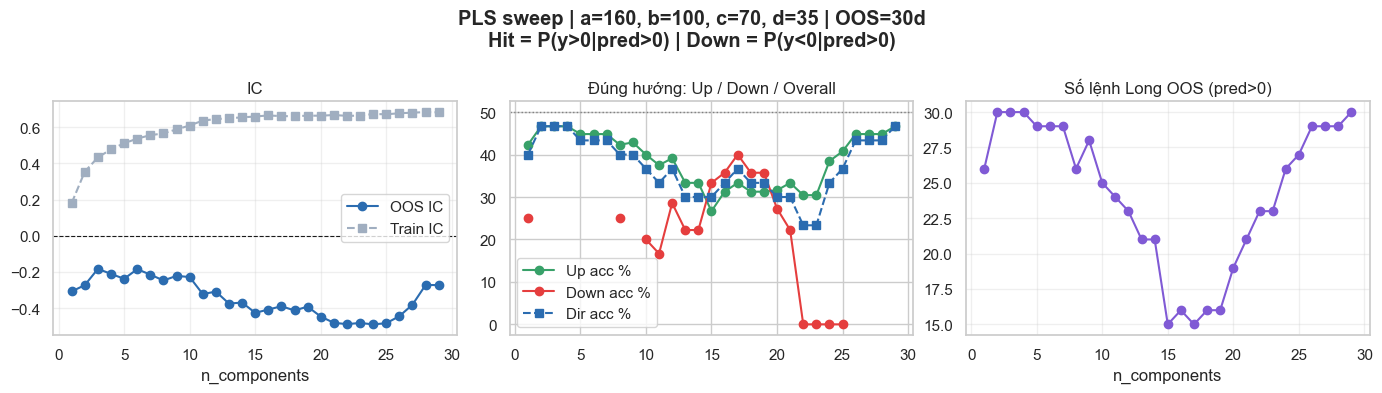

In [289]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# ============================================================
# PARAMS
# ============================================================
best = study.best_trial
a = best.user_attrs["a"]
b = best.user_attrs["b"]
c = best.user_attrs["c"]
d = best.user_attrs["d"]

N_COMP_LIST = list(range(1, 30))
LOOKBACK = LOOKBACK_DAYS
OOS = OOS_DAYS
MIN_SIGNALS = 3  # tối thiểu số lệnh long để tính hit/down

print(f"Fixed: a={a}, b={b}, c={c}, d={d}")
print("=" * 70)

# ============================================================
# DATA
# ============================================================
df_feat = build_features(df_vni_raw, investor_groups, a, b, c, d)
target = build_target(df_vni_raw, horizon=10)
model_data = pd.concat([df_feat, target], axis=1)
model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()

y_col = target.name
X_cols = list(df_feat.columns)

total_needed = LOOKBACK + OOS
train_data = model_data.iloc[-total_needed:-OOS].copy()
oos_data = model_data.iloc[-OOS:].copy()

X_train = StandardScaler().fit_transform(train_data[X_cols].values)
y_train = train_data[y_col].values
scaler = StandardScaler().fit(train_data[X_cols].values)
X_train = scaler.transform(train_data[X_cols].values)
X_oos = scaler.transform(oos_data[X_cols].values)
y_oos = oos_data[y_col].values

n_feat, n_samp = X_train.shape[1], X_train.shape[0]

def direction_stats(pred, y, min_sig=3):
    """
    Up accuracy  = P(y>0 | pred>0)
    Down accuracy = P(y<0 | pred<0)
    """
    mask_up = pred > 0
    mask_dn = pred < 0
    n_up = int(mask_up.sum())
    n_dn = int(mask_dn.sum())

    up_acc = float((y[mask_up] > 0).mean()) if n_up >= min_sig else np.nan
    dn_acc = float((y[mask_dn] < 0).mean()) if n_dn >= min_sig else np.nan

    # optional: overall directional accuracy (bỏ pred≈0)
    mask_dir = pred != 0
    if mask_dir.sum() >= min_sig:
        correct = ((pred > 0) & (y > 0)) | ((pred < 0) & (y < 0))
        dir_acc = float(correct[mask_dir].mean())
    else:
        dir_acc = np.nan

    return dict(
        n_up=n_up,
        n_down=n_dn,
        up_acc=up_acc,      # đúng khi đoán UP
        down_acc=dn_acc,    # đúng khi đoán DOWN
        dir_acc=dir_acc,    # đúng hướng tổng (up hoặc down)
    )

# ============================================================
# SWEEP
# ============================================================
rows = []
for n_comp in N_COMP_LIST:
    n_comp_eff = int(max(1, min(n_comp, n_feat, n_samp - 1)))
    try:
        model = PLSRegression(n_components=n_comp_eff, scale=False)
        model.fit(X_train, y_train)
        pred_tr = model.predict(X_train).ravel()
        pred_oos = model.predict(X_oos).ravel()

        if np.std(pred_oos) < 1e-8:
            rows.append({"n_components": n_comp_eff, "oos_ic": np.nan})
            continue

        tr_ic, _ = spearmanr(pred_tr, y_train)
        oos_ic, _ = spearmanr(pred_oos, y_oos)
        st_oos = direction_stats(pred_oos, y_oos, min_sig=MIN_SIGNALS)
        st_tr  = direction_stats(pred_tr, y_train, min_sig=15)

        rows.append({
            "n_components": n_comp_eff,
            "train_ic": float(tr_ic) if not np.isnan(tr_ic) else np.nan,
            "oos_ic": float(oos_ic) if not np.isnan(oos_ic) else np.nan,
            "oos_up_acc": st_oos["up_acc"],
            "oos_down_acc": st_oos["down_acc"],
            "oos_dir_acc": st_oos["dir_acc"],
            "oos_n_up": st_oos["n_up"],
            "oos_n_down": st_oos["n_down"],
            "train_up_acc": st_tr["up_acc"],
            "train_down_acc": st_tr["down_acc"],
            "gap_ic": (float(tr_ic) - float(oos_ic))
                if not (np.isnan(tr_ic) or np.isnan(oos_ic)) else np.nan,
        })
    except Exception as e:
        rows.append({"n_components": n_comp, "error": str(e)})

df_sweep = pd.DataFrame(rows)

# In bảng chính
cols_show = [
    "n_components", "oos_ic",
    "oos_up_acc", "oos_down_acc", "oos_dir_acc",
    "oos_n_up", "oos_n_down",
    "train_ic", "train_up_acc", "train_down_acc",   # ← thêm 2 dòng này
    "gap_ic",
]
print(df_sweep[cols_show].to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# cols_show = [c for c in cols_show if c in df_sweep.columns]
# print("\n=== OOS IC / Hit / Down theo n_components ===\n")
# print(df_sweep[cols_show].to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ============================================================
# PLOT
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.plot(df_sweep["n_components"], df_sweep["oos_ic"], "o-", label="OOS IC", color="#2b6cb0")
ax.plot(df_sweep["n_components"], df_sweep["train_ic"], "s--", label="Train IC", color="#a0aec0")
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.set_title("IC")
ax.set_xlabel("n_components")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(df_sweep["n_components"], df_sweep["oos_up_acc"] * 100, "o-", label="Up acc %", color="#38a169")
ax.plot(df_sweep["n_components"], df_sweep["oos_down_acc"] * 100, "o-", label="Down acc %", color="#e53e3e")
ax.plot(df_sweep["n_components"], df_sweep["oos_dir_acc"] * 100, "s--", label="Dir acc %", color="#2b6cb0")
ax.axhline(50, color="gray", ls=":", lw=1)
ax.set_title("Đúng hướng: Up / Down / Overall")
ax.legend()

ax = axes[2]
ax.plot(df_sweep["n_components"], df_sweep["oos_n_up"], "o-", color="#805ad5")
ax.set_title("Số lệnh Long OOS (pred>0)")
ax.set_xlabel("n_components")
ax.grid(True, alpha=0.3)

fig.suptitle(
    f"PLS sweep | a={a}, b={b}, c={c}, d={d} | OOS={OOS}d\n"
    f"Hit = P(y>0|pred>0) | Down = P(y<0|pred>0)",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

BEST PARAMS (PLS)
a = 160 | b = 100 | c = 70 | d = 35
n_components = 15
LOOKBACK = 1000 | OOS = 30
Số feature: 66 | Số dòng hợp lệ: 1790
TRAIN: 1000 | OOS: 30

========== TRAIN ==========
IC           : 0.6590
Hit Rate     : 0.7667
n_components : 15
Số quan sát  : 1000
Pred std     : 0.038742

========== OOS ==========
IC          : -0.4260
Hit Rate    : 0.2667
Signals     : 15
Số quan sát : 30

=== Rank IC (Train+OOS) = 0.6218 ===
                mean    std  count  hit_rate  avg_pred
score_decile                                          
0            -0.0486 0.0625    103    0.1748   -0.0625
1            -0.0302 0.0392    103    0.1553   -0.0261
2            -0.0103 0.0376    103    0.3786   -0.0124
3            -0.0032 0.0383    103    0.4660   -0.0021
4             0.0044 0.0384    103    0.4951    0.0067
5             0.0144 0.0339    103    0.6699    0.0148
6             0.0159 0.0401    103    0.7184    0.0222
7             0.0302 0.0348    103    0.8447    0.0324
8             

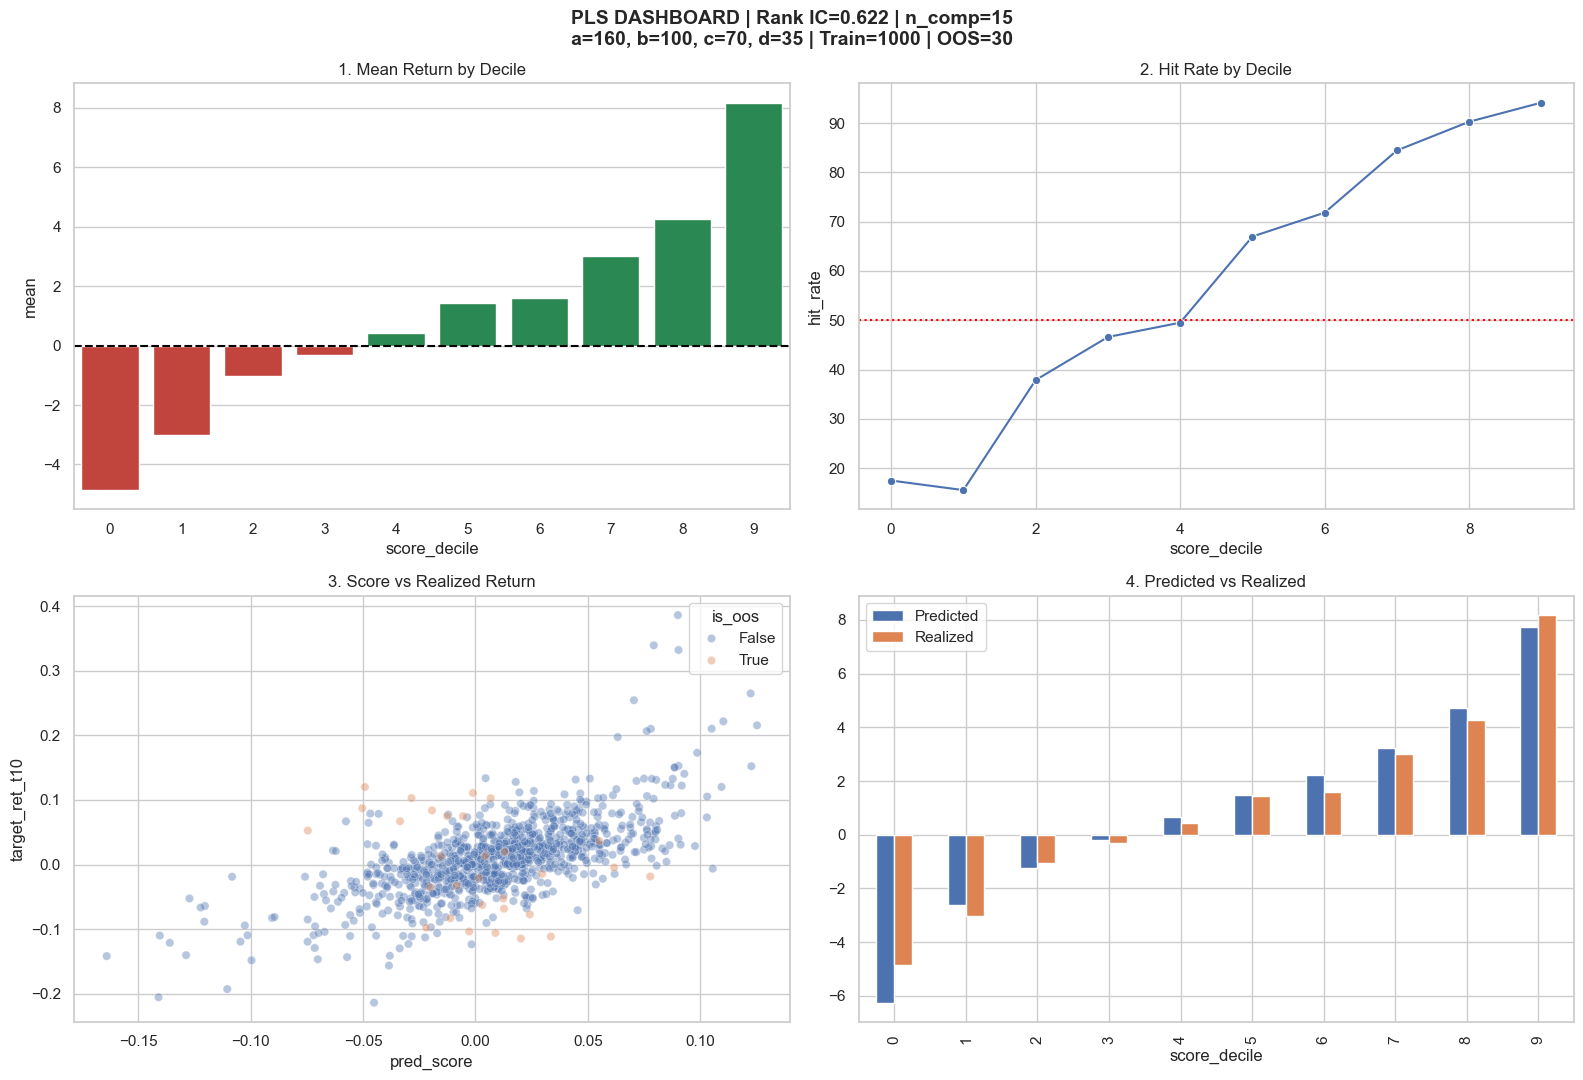

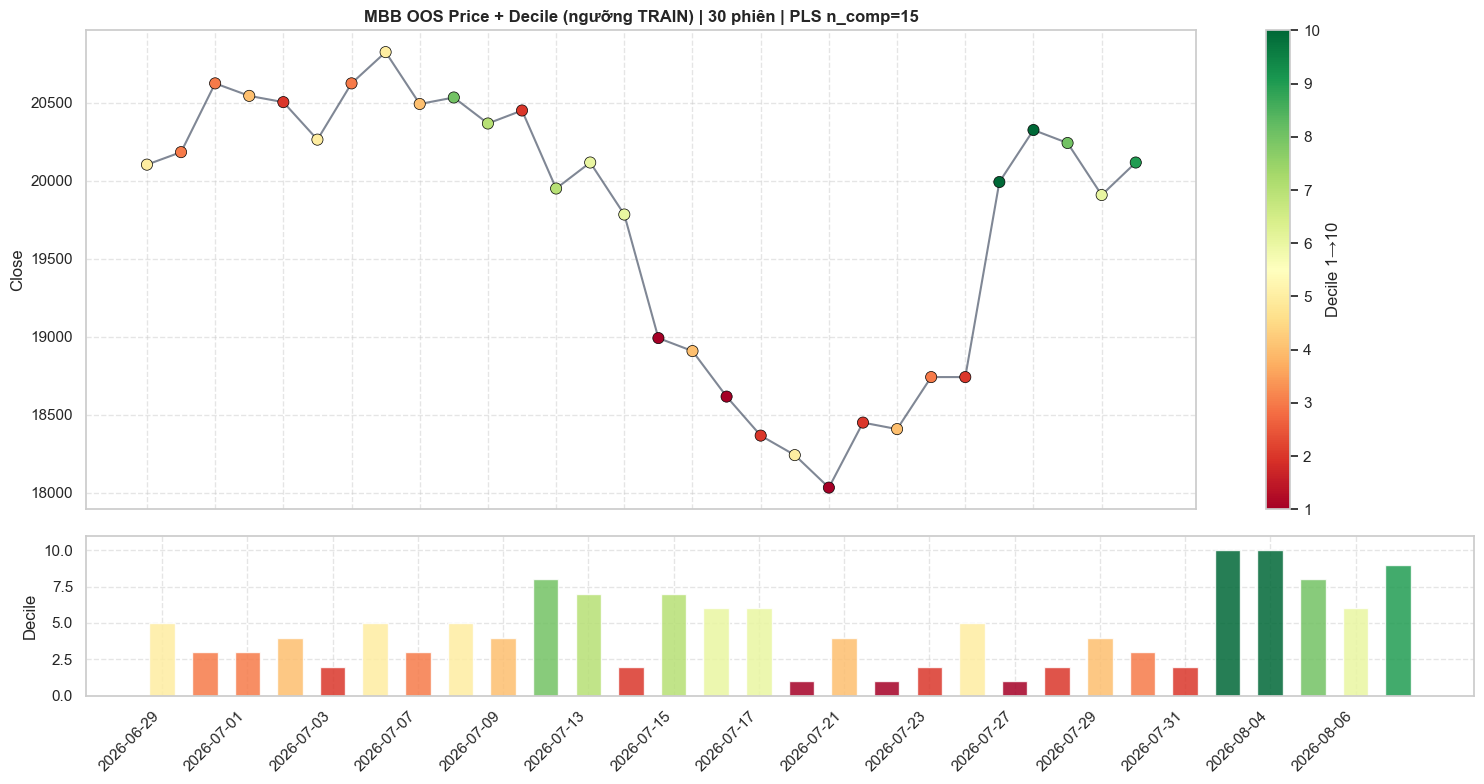

In [290]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# 1. LẤY BEST PARAMS TỪ OPTUNA (PLS)
# ============================================================
best = study.best_trial

a = best.user_attrs["a"]
b = best.user_attrs["b"]
c = best.user_attrs["c"]
d = best.user_attrs["d"]
n_components = int(best.user_attrs["n_components"])

print("=" * 70)
print("BEST PARAMS (PLS)")
print("=" * 70)
print(f"a = {a} | b = {b} | c = {c} | d = {d}")
print(f"n_components = {n_components}")
print(f"LOOKBACK = {LOOKBACK_DAYS} | OOS = {OOS_DAYS}")
print("=" * 70)

y_col = "target_ret_t10"

# ============================================================
# 2. TẠO FEATURE + TARGET (đúng chữ ký build_features của bạn)
# ============================================================
df_feat = build_features(df_vni_raw, investor_groups, a, b, c, d)
target = build_target(df_vni_raw, horizon=10)

model_data = pd.concat([df_feat, target], axis=1)
model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()

# Thêm close để vẽ biểu đồ giá (không dùng để train)
close_aligned = df_vni_raw["close"].ffill().reindex(model_data.index)
model_data["close"] = close_aligned

X_cols = list(df_feat.columns)
print(f"Số feature: {len(X_cols)} | Số dòng hợp lệ: {len(model_data)}")

# ============================================================
# 3. CẮT TRAIN / OOS
# ============================================================
total_needed = LOOKBACK_DAYS + OOS_DAYS

if len(model_data) >= total_needed:
    train_data = model_data.iloc[-total_needed:-OOS_DAYS].copy()
    oos_data = model_data.iloc[-OOS_DAYS:].copy()
else:
    if len(model_data) > OOS_DAYS:
        train_data = model_data.iloc[:-OOS_DAYS].copy()
        oos_data = model_data.iloc[-OOS_DAYS:].copy()
    else:
        train_data = model_data.copy()
        oos_data = pd.DataFrame(columns=model_data.columns)

print(f"TRAIN: {len(train_data)} | OOS: {len(oos_data)}")

# ============================================================
# 4. FIT PLS TRÊN TRAIN
# ============================================================
X_train = train_data[X_cols].values
y_train = train_data[y_col].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

n_feat = X_train_scaled.shape[1]
n_samp = X_train_scaled.shape[0]
n_comp = int(max(1, min(n_components, n_feat, n_samp - 1)))

model = PLSRegression(n_components=n_comp, scale=False)
model.fit(X_train_scaled, y_train)

train_data = train_data.copy()
train_data["pred_score"] = model.predict(X_train_scaled).ravel()
train_data["actual_ret"] = y_train

ic_train, _ = spearmanr(train_data["pred_score"], train_data["actual_ret"])
hit_train = (
    train_data.loc[train_data["pred_score"] > 0, "actual_ret"] > 0
).mean()

print("\n========== TRAIN ==========")
print(f"IC           : {ic_train:.4f}")
print(f"Hit Rate     : {hit_train:.4f}")
print(f"n_components : {n_comp}")
print(f"Số quan sát  : {len(train_data)}")
print(f"Pred std     : {train_data['pred_score'].std():.6f}")

# ============================================================
# 5. ĐÁNH GIÁ OOS
# ============================================================
if len(oos_data) > 0:
    X_oos = oos_data[X_cols].values
    X_oos_scaled = scaler.transform(X_oos)

    oos_data = oos_data.copy()
    oos_data["pred_score"] = model.predict(X_oos_scaled).ravel()
    oos_data["actual_ret"] = oos_data[y_col].values

    ic_oos, _ = spearmanr(oos_data["pred_score"], oos_data["actual_ret"])
    n_sig = int((oos_data["pred_score"] > 0).sum())
    hit_oos = (
        (oos_data.loc[oos_data["pred_score"] > 0, "actual_ret"] > 0).mean()
        if n_sig > 0
        else np.nan
    )

    print("\n========== OOS ==========")
    print(f"IC          : {ic_oos:.4f}")
    print(f"Hit Rate    : {hit_oos:.4f}")
    print(f"Signals     : {n_sig}")
    print(f"Số quan sát : {len(oos_data)}")
else:
    print("\n[OOS] Không đủ dữ liệu")

# ============================================================
# 6. DECILE ANALYSIS (Train + OOS)
# ============================================================
parts = [train_data[["pred_score", y_col]].assign(is_oos=False)]
if len(oos_data) > 0:
    parts.append(oos_data[["pred_score", y_col]].assign(is_oos=True))

eval_data = pd.concat(parts, axis=0).dropna()
eval_data["score_decile"] = pd.qcut(
    eval_data["pred_score"], 10, labels=False, duplicates="drop"
)

analysis = eval_data.groupby("score_decile")[y_col].agg(["mean", "std", "count"])
analysis["hit_rate"] = eval_data.groupby("score_decile")[y_col].apply(
    lambda x: (x > 0).mean()
)
analysis["avg_pred"] = eval_data.groupby("score_decile")["pred_score"].mean()

rank_ic = eval_data["pred_score"].corr(eval_data[y_col], method="spearman")
print(f"\n=== Rank IC (Train+OOS) = {rank_ic:.4f} ===")
print(analysis)

# ============================================================
# 7. DASHBOARD
# ============================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    f"PLS DASHBOARD | Rank IC={rank_ic:.3f} | n_comp={n_comp}\n"
    f"a={a}, b={b}, c={c}, d={d} | Train={len(train_data)} | OOS={len(oos_data)}",
    fontsize=14,
    fontweight="bold",
)

colors = ["#d73027" if x < 0 else "#1a9850" for x in analysis["mean"]]
sns.barplot(x=analysis.index, y=analysis["mean"] * 100, ax=axes[0, 0], palette=colors)
axes[0, 0].axhline(0, color="black", ls="--")
axes[0, 0].set_title("1. Mean Return by Decile")

sns.lineplot(x=analysis.index, y=analysis["hit_rate"] * 100, ax=axes[0, 1], marker="o")
axes[0, 1].axhline(50, color="red", ls=":")
axes[0, 1].set_title("2. Hit Rate by Decile")

sns.scatterplot(
    data=eval_data, x="pred_score", y=y_col, hue="is_oos", ax=axes[1, 0], alpha=0.4
)
axes[1, 0].set_title("3. Score vs Realized Return")

pd.DataFrame(
    {
        "Predicted": analysis["avg_pred"] * 100,
        "Realized": analysis["mean"] * 100,
    }
).plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("4. Predicted vs Realized")

plt.tight_layout()
plt.show()

# ============================================================
# 8. BIỂU ĐỒ GIÁ + DECILE OOS (ngưỡng decile từ TRAIN)
# ============================================================
if len(oos_data) > 0 and "close" in oos_data.columns:
    train_scores = train_data["pred_score"]
    _, bin_edges = pd.qcut(train_scores, q=10, duplicates="drop", retbins=True)
    bin_edges = bin_edges.copy()
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf
    n_deciles = len(bin_edges) - 1

    oos_data = oos_data.copy()
    oos_data["decile"] = (
        pd.cut(
            oos_data["pred_score"],
            bins=bin_edges,
            labels=False,
            include_lowest=True,
        )
        + 1
    )

    if "time" in df_vni_raw.columns:
        raw_dates = df_vni_raw.loc[oos_data.index, "time"]
    else:
        raw_dates = oos_data.index

    if pd.api.types.is_datetime64_any_dtype(raw_dates):
        x_dates = pd.to_datetime(raw_dates).dt.strftime("%Y-%m-%d").values
    else:
        x_dates = pd.to_datetime(raw_dates).strftime("%Y-%m-%d").values

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
    )

    ax1.plot(
        x_dates, oos_data["close"], color="#4A5568", lw=1.5, alpha=0.7, label="Close"
    )
    sc = ax1.scatter(
        x_dates,
        oos_data["close"],
        c=oos_data["decile"],
        cmap="RdYlGn",
        vmin=1,
        vmax=n_deciles,
        s=65,
        zorder=5,
        edgecolors="black",
        linewidth=0.5,
    )
    title_sym = globals().get("SYMBOL", "")
    ax1.set_title(
        f"{title_sym} OOS Price + Decile (ngưỡng TRAIN) | {len(oos_data)} phiên | PLS n_comp={n_comp}",
        fontweight="bold",
    )
    ax1.set_ylabel("Close")
    ax1.grid(True, ls="--", alpha=0.5)
    plt.colorbar(sc, ax=ax1, label=f"Decile 1→{n_deciles}")

    norm = (n_deciles - 1) if n_deciles > 1 else 1
    bar_colors = plt.cm.RdYlGn((oos_data["decile"].astype(float) - 1) / norm)
    ax2.bar(x_dates, oos_data["decile"], color=bar_colors, alpha=0.85, width=0.6)
    ax2.set_ylabel("Decile")
    ax2.set_ylim(0, n_deciles + 1)
    ax2.grid(True, ls="--", alpha=0.5)
    plt.xticks(
        rotation=45,
        ha="right",
        ticks=range(0, len(x_dates), max(1, len(x_dates) // 15)),
    )

    plt.tight_layout()
    plt.show()

In [291]:
import numpy as np
import pandas as pd

# Giả sử bạn đã fit xong:
# model = PLSRegression(...).fit(X_train_scaled, y_train)
# X_cols = list feature

# ----- 1. Hệ số PLS (độ lớn ảnh hưởng) -----
coef = model.coef_.ravel()          # shape (n_features,)
coef_df = pd.DataFrame({
    "feature": X_cols,
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)

print("=" * 60)
print("TOP 20 BIẾN CÓ |HỆ SỐ PLS| LỚN NHẤT")
print("=" * 60)
print(coef_df.head(20).to_string(index=False))


# ----- 2. VIP (Variable Importance in Projection) – chuẩn của PLS -----
def compute_vip(model, X, y):
    """
    Tính VIP score cho PLS
    """
    t = model.x_scores_              # (n_samples, n_components)
    w = model.x_weights_             # (n_features, n_components)
    q = model.y_loadings_            # (n_components,) hoặc (1, n_components)
    
    p, h = w.shape
    
    # Đảm bảo y là numpy array 2D
    y = np.asarray(y).reshape(-1, 1)
    
    # Đảm bảo q đúng shape
    q = np.asarray(q).reshape(-1)    # (n_components,)
    
    # SS cho từng component
    ssy = np.sum((t * q) ** 2, axis=0)   # (n_components,)
    total_ssy = np.sum(ssy)
    
    vip = np.zeros(p)
    for i in range(p):
        weight = np.array([w[i, j]**2 for j in range(h)])
        vip[i] = np.sqrt(p * (np.sum(weight * ssy) / total_ssy))
    
    return vip

vip_scores = compute_vip(model, X_train_scaled, y_train)

vip_df = pd.DataFrame({
    "feature": X_cols,
    "VIP": vip_scores,
    "abs_coef": np.abs(coef)
}).sort_values("VIP", ascending=False)

print("\n" + "=" * 60)
print("TOP 20 BIẾN THEO VIP (PLS)")
print("=" * 60)
print(vip_df.head(20).to_string(index=False))

print("\nSố biến có VIP > 1 :", (vip_df["VIP"] > 1).sum())
print("Số biến có VIP > 0.8:", (vip_df["VIP"] > 0.8).sum())

TOP 20 BIẾN CÓ |HỆ SỐ PLS| LỚN NHẤT
                                  feature    coef  abs_coef
                    inter_prop_sent_x_pos -0.0527    0.0527
                feat_foreign_sentiment_sq -0.0390    0.0390
cross_agree_strength_local_inst_local_ind -0.0257    0.0257
     cross_foreign_minus_local_ind_sent_z -0.0238    0.0238
    cross_foreign_minus_local_inst_sent_z -0.0228    0.0228
         feat_local_inst_flow_impulse_35d  0.0220    0.0220
          cross_foreign_minus_prop_sent_z -0.0214    0.0214
           feat_local_ind_sentiment_cubed -0.0207    0.0207
                    inter_prop_sent_x_atr  0.0206    0.0206
                 inter_foreign_sent_x_pos  0.0203    0.0203
              inter_local_inst_sent_x_atr -0.0194    0.0194
                    feat_foreign_eff_flow -0.0185    0.0185
              feat_local_ind_vol_adj_sent  0.0161    0.0161
               feat_foreign_sentiment_ewm -0.0157    0.0157
                   feat_prop_sentiment_sq -0.0156    0.0156
    

# Lại PLS nhma thay đổi features

In [338]:
SYMBOL = 'HPG'

# --- BƯỚC 1: CHUẨN BỊ DỮ LIỆU ---
excel_file_path_vni = rf"E:\Document\Tao\FiinGroup\csv_data_2\Kafi_Phân_Loại_Nhà_Đầu_Tư_{SYMBOL}.csv"
excel_file_path_vni_new = rf"E:\Document\Tao\FiinGroup\csv_data_2\Kafi_Giá_{SYMBOL}.csv"
# excel_file_path_vni = rf"E:\Document\Tao\FiinGroup\Kafi_Phân_Loại_Nhà_Đầu_Tư_{SYMBOL}_20260305.xlsx"

investor_groups = ['foreign', 'prop', 'local_ind', 'local_inst']

df_vni_raw = load_and_map_excel(excel_file_path_vni, df_history=None)

In [348]:
import optuna
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from scipy.stats import spearmanr
from itertools import combinations
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# CẤU HÌNH
# ============================================================
investor_groups = ["foreign", "prop", "local_inst", "local_ind"]
LOOKBACK_DAYS = 1000
OOS_DAYS = 60
TRIALS = 300

A_MIN, A_MAX = 50, 150
B_MIN, B_MAX = 50, 150
C_MIN, C_MAX = 15, 70
D_MIN, D_MAX = 15, 60

# Số thành phần PLS (Optuna sẽ chọn trong khoảng này)
N_COMP_MIN, N_COMP_MAX = 12, 25

# Trọng số score (chỉ trên Train)
W_HIT = 0.60
W_IC = 0.40
W_TOP = 0.30          # Chất lượng 2 decile cao nhất
W_BOT = 0.20          # Chất lượng 2 decile thấp nhất

# Ngưỡng mong muốn
TOP_HIT_TARGET = 0.85         # 2 decile cao nhất nên ≥ 85% return dương
BOT_HIT_TARGET = 0.15         # 2 decile thấp nhất nên ≤ 15% return dương

# Ngưỡng trên TRAIN
MIN_SIGNALS_TRAIN_SOFT = 30
MIN_SIGNALS_TRAIN_HARD = 15
MIN_HIT_TRAIN_SOFT = 0.65
MIN_HIT_TRAIN_HARD = 0.6
MIN_IC_TRAIN_HARD = 0.02

# bad_result: đủ 9 phần tử, khớp unpack trong objective
BAD_RESULT = (-999.0, -1.0, 0.0, 0.0, 0, 0, -1.0, 0.0, 999.0)

# ============================================================
# FEATURE ENGINEERING (giữ nguyên logic của bạn)
# ============================================================
def build_features(df_vni_raw, investor_groups, a, b, c, d):
    df = df_vni_raw.copy()
    keep_cols = [
        "open", "high", "low", "close", "trading_value",
        "foreign_net_val", "prop_net_val", "local_ind_net_val", "local_inst_net_val",
        "foreign_net_vol", "prop_net_vol", "local_ind_net_vol", "local_inst_net_vol",
    ]
    keep_cols = [col for col in keep_cols if col in df.columns]
    df = df[keep_cols]
# FIX 1: Tránh Data Leakage (thay interpolate bằng ffill)
    df["trading_value"] = df["trading_value"].replace(0, np.nan).ffill().bfill()
    df["close"] = df["close"].ffill()
    df["log_ret"] = np.log(df["close"] / df["close"].shift(1)).fillna(0)
    df["abs_ret"] = df["log_ret"].abs()

    tr = np.maximum(
        df["high"] - df["low"],
        np.maximum(
            (df["high"] - df["close"].shift(1)).abs(),
            (df["low"] - df["close"].shift(1)).abs(),
        ),
    )

    # Technical indicators
    roll_high = df["high"].rolling(c).max()
    roll_low = df["low"].rolling(c).min()
    ta_pos_in_range = ((df["close"] - roll_low) / (roll_high - roll_low + 1e-8)).fillna(0.5)
    ta_atr_pct = (tr.ewm(span=b, adjust=False).mean() / df["close"]).fillna(0)

    feature_dict = {}

    # ===== Group-level features =====
    for g in investor_groups:
        net_val = df[f"{g}_net_val"]
        net_ratio = net_val / df["trading_value"]
        df[f"feat_{g}_net_ratio"] = net_ratio.fillna(0)

        # FIX 2: Sửa Price Impact bị nổ số (nâng floor mẫu số + clip giá trị)
        prev = net_ratio.shift(1).abs().clip(lower=1e-3)
        impact_raw = (df["abs_ret"].shift(1) / prev).rolling(5).median().fillna(0)
        df[f"feat_{g}_price_impact"] = np.clip(impact_raw, 0, 10)

        # Sentiment Min-Max
        rmin = net_val.rolling(a, min_periods=5).min()
        rmax = net_val.rolling(a, min_periods=5).max()
        df[f"feat_{g}_sentiment"] = (
            2 * (net_val - rmin) / (rmax - rmin + 1e-6) - 1
        ).fillna(0)

        # Sentiment EWM & Z-score
        sent = df[f"feat_{g}_sentiment"]
        sent_ewm = sent.ewm(span=b, adjust=False).mean()
        feature_dict[f"feat_{g}_sentiment_ewm"] = sent_ewm

        sent_mean = sent_ewm.rolling(a, min_periods=10).mean()
        sent_std = sent_ewm.rolling(a, min_periods=10).std().replace(0, np.nan)
        sent_z = ((sent_ewm - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

        # Polynomials & Saturation Flag
        feature_dict[f"feat_{g}_sentiment_sq"] = sent_z**2
        feature_dict[f"feat_{g}_sentiment_cubed"] = (sent_z**3 - 3 * sent_z).clip(-10, 10)
        feature_dict[f"flag_{g}_sent_saturated"] = (sent_z.abs() >= 2.8).astype(int)

        # Impulse
        impulse = sent_ewm.diff(d).fillna(0)
        feature_dict[f"feat_{g}_flow_impulse_{d}d"] = impulse

        # FIX 3: Effective flow nén bằng Signed Log Transform
        eff_flow_raw = sent * df[f"feat_{g}_price_impact"]
        feature_dict[f"feat_{g}_eff_flow"] = np.sign(eff_flow_raw) * np.log1p(np.abs(eff_flow_raw))

        # Share & Weighted Sentiment
        val_share = (df[f"{g}_net_val"].abs() / df["trading_value"]).clip(0, 1)
        feature_dict[f"feat_{g}_val_share"] = val_share
        feature_dict[f"feat_{g}_weighted_sent"] = sent_ewm * val_share  # FEATURE MỚI 1

        # Interactions
        feature_dict[f"inter_{g}_sent_x_pos"] = sent_z * ta_pos_in_range
        feature_dict[f"inter_{g}_sent_x_atr"] = sent_z * ta_atr_pct

    # ===== Cross-investor Features =====
    sent_ewm = {g: feature_dict[f"feat_{g}_sentiment_ewm"] for g in investor_groups}
    sent_z = {}
    for g in investor_groups:
        mu = sent_ewm[g].rolling(a, min_periods=10).mean()
        sigma = sent_ewm[g].rolling(a, min_periods=10).std().replace(0, np.nan)
        sent_z[g] = ((sent_ewm[g] - mu) / (sigma + 1e-6)).clip(-3, 3).fillna(0)

    for g1, g2 in combinations(investor_groups, 2):
        feature_dict[f"cross_{g1}_minus_{g2}_sent_z"] = sent_z[g1] - sent_z[g2]
        feature_dict[f"cross_agree_sign_{g1}_{g2}"] = np.sign(sent_ewm[g1]) * np.sign(sent_ewm[g2])
        feature_dict[f"cross_agree_strength_{g1}_{g2}"] = sent_ewm[g1] * sent_ewm[g2]

    # Dispersion
    sent_matrix = pd.concat([sent_ewm[g] for g in investor_groups], axis=1)
    disp_std = sent_matrix.std(axis=1)
    feature_dict["cross_dispersion_std"] = disp_std
    feature_dict["cross_dispersion_range"] = sent_matrix.max(axis=1) - sent_matrix.min(axis=1)
    feature_dict["cross_dispersion_iqr"] = sent_matrix.quantile(0.75, axis=1) - sent_matrix.quantile(0.25, axis=1)

    # FEATURE MỚI 2: Smart Money vs Retail Spread
    smart_cols = [g for g in ["foreign", "prop", "local_inst"] if g in investor_groups]
    if "local_ind" in investor_groups and len(smart_cols) > 0:
        smart_sent = pd.concat([sent_ewm[g] for g in smart_cols], axis=1).mean(axis=1)
        feature_dict["cross_smart_vs_retail_sent"] = smart_sent - sent_ewm["local_ind"]

    # FEATURE MỚI 3: Volatility-Adjusted Sentiment
    for g in investor_groups:
        feature_dict[f"feat_{g}_vol_adj_sent"] = sent_ewm[g] / (disp_std + 1e-4)

    df_feat = pd.DataFrame(feature_dict, index=df.index)
    return df_feat.replace([np.inf, -np.inf], 0).fillna(0)
    return pd.DataFrame(feature_dict, index=df.index)


def build_target(df_vni_raw, horizon=10):
    close = df_vni_raw["close"].ffill()
    target = close.shift(-horizon) / close - 1
    target.name = f"target_ret_t{horizon}"
    return target

# ============================================================
# Hàm đánh giá – PLS + score ưu tiên đơn điệu
# ============================================================
def evaluate_params_pls(
    a, b, c, d, n_components,
    df_vni_raw,
    investor_groups,
    lookback_days=LOOKBACK_DAYS,
    oos_days=OOS_DAYS,
):
    try:
        df_feat = build_features(df_vni_raw, investor_groups, a, b, c, d)
        target = build_target(df_vni_raw, horizon=10)
        model_data = pd.concat([df_feat, target], axis=1)
        model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()

        if len(model_data) < (lookback_days + oos_days + 50):
            return BAD_RESULT

        train_data = model_data.iloc[-(lookback_days + oos_days) : -oos_days].copy()
        oos_data   = model_data.iloc[-oos_days:].copy()

        if len(train_data) < 300 or len(oos_data) < 10:
            return BAD_RESULT

        target_col = target.name
        X_train = train_data.drop(columns=[target_col]).values
        y_train = train_data[target_col].values
        X_oos   = oos_data.drop(columns=[target_col]).values
        y_oos   = oos_data[target_col].values

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_oos_scaled   = scaler.transform(X_oos)

        # ----- PLS -----
        n_feat = X_train_scaled.shape[1]
        n_samp = X_train_scaled.shape[0]
        n_comp = int(max(1, min(n_components, n_feat, n_samp - 1)))

        model = PLSRegression(n_components=n_comp, scale=False)
        model.fit(X_train_scaled, y_train)

        pred_train = model.predict(X_train_scaled).ravel()
        pred_oos   = model.predict(X_oos_scaled).ravel()

        if np.std(pred_train) < 1e-8:
            return BAD_RESULT

        # ============================================================
        # METRICS CƠ BẢN TRÊN TRAIN
        # ============================================================
        train_ic, _ = spearmanr(pred_train, y_train)
        if np.isnan(train_ic):
            train_ic = -1.0

        mask_up_train = pred_train > 0
        n_signals_train = int(mask_up_train.sum())

        if n_signals_train >= MIN_SIGNALS_TRAIN_HARD:
            hit_rate_train = float((y_train[mask_up_train] > 0).mean())
            avg_ret_train  = float(y_train[mask_up_train].mean())
        else:
            hit_rate_train = 0.50
            avg_ret_train  = 0.0

        # ============================================================
        # DECILE ANALYSIS TRÊN TRAIN (quan trọng)
        # ============================================================
        try:
            deciles = pd.qcut(pred_train, 10, labels=False, duplicates="drop")
        except Exception:
            return BAD_RESULT

        df_dec = pd.DataFrame({"pred": pred_train, "y": y_train, "decile": deciles})
        decile_stats = df_dec.groupby("decile")["y"].agg(
            mean_ret="mean",
            hit_rate=lambda x: (x > 0).mean(),
            count="count"
        ).reindex(range(10))

        # 2 decile cao nhất (8, 9) và 2 decile thấp nhất (0, 1)
        top_stats = decile_stats.loc[[7, 9]].dropna()
        bot_stats = decile_stats.loc[[0, 2]].dropna()

        if len(top_stats) < 1 or len(bot_stats) < 1:
            return BAD_RESULT

        top_hit = top_stats["hit_rate"].mean()          # mong muốn ≥ 0.85
        bot_hit = bot_stats["hit_rate"].mean()          # mong muốn ≤ 0.15
        top_mean = top_stats["mean_ret"].mean()
        bot_mean = bot_stats["mean_ret"].mean()

        # Tính đơn điệu tổng thể (Spearman giữa decile và mean return)
        valid = decile_stats.dropna()
        if len(valid) >= 5:
            mono_score = spearmanr(valid.index, valid["mean_ret"])[0]
            if np.isnan(mono_score):
                mono_score = 0.0
        else:
            mono_score = 0.0

        # ============================================================
        # METRICS OOS (chỉ theo dõi)
        # ============================================================
        oos_ic, _ = spearmanr(pred_oos, y_oos)
        if np.isnan(oos_ic):
            oos_ic = -1.0

        mask_up_oos = pred_oos > 0
        n_signals_oos = int(mask_up_oos.sum())
        hit_rate_oos = float((y_oos[mask_up_oos] > 0).mean()) if n_signals_oos >= 3 else 0.50
        avg_ret_oos  = float(y_oos[mask_up_oos].mean()) if n_signals_oos >= 3 else 0.0

        train_oos_gap = train_ic - oos_ic

        # ============================================================
        # SCORE (ưu tiên đơn điệu + extreme deciles)
        # ============================================================
        # 1. Hit rate tổng
        hit_term = (hit_rate_train - 0.50) * 2.0

        # 2. IC
        ic_term = np.clip(train_ic, -0.15, 0.60)

        # 3. Top 2 decile (càng cao càng tốt)
        #    0.85 → 1.0 | 0.90 → 1.25 | dưới 0.70 thì thấp
        top_term = np.clip((top_hit - 0.50) / 0.40, 0, 1.5)

        # 4. Bottom 2 decile (càng thấp càng tốt)
        #    0.15 → 1.0 | 0.10 → 1.25 | trên 0.30 thì kém
        bot_term = np.clip((0.50 - bot_hit) / 0.40, 0, 1.5)

        # 5. Monotonicity
        mono_term = np.clip(mono_score, 0, 1.0)

        score = (
            W_HIT * hit_term +
            W_IC  * ic_term +
            W_TOP * top_term +
            W_BOT * bot_term +
            0.05  * mono_term          # thưởng nhẹ thêm cho đơn điệu tổng thể
        )

        # Thưởng nhẹ nếu top mean return cao và bot mean return thấp
        if top_mean > 0:
            score += 0.02 * np.clip(top_mean * 10, 0, 0.3)
        if bot_mean < 0:
            score += 0.02 * np.clip(-bot_mean * 10, 0, 0.3)

        # Soft penalty
        if n_signals_train < MIN_SIGNALS_TRAIN_SOFT:
            score *= 0.75
        if hit_rate_train < MIN_HIT_TRAIN_SOFT:
            score *= 0.80
        if top_hit < 0.75:                     # top chưa đủ mạnh
            score *= 0.70
        if bot_hit > 0.25:                     # bottom chưa đủ yếu
            score *= 0.75

        # Hard filter
        if (
            n_signals_train < MIN_SIGNALS_TRAIN_HARD
            or hit_rate_train < MIN_HIT_TRAIN_HARD
            or train_ic < MIN_IC_TRAIN_HARD
            or top_hit < 0.65
            or bot_hit > 0.35
        ):
            score = -999.0

        return (
            float(score),
            float(oos_ic),
            float(hit_rate_oos),
            float(avg_ret_oos),
            n_signals_oos,
            n_comp,
            float(train_ic),
            float(hit_rate_train),
            float(train_oos_gap),
            float(top_hit),          # thêm để theo dõi
            float(bot_hit),
            float(mono_score),
        )

    except Exception as e:
        print(f"[EXCEPTION] a={a}, b={b}, c={c}, d={d}, n_comp={n_components} → {type(e).__name__}: {e}")
        return BAD_RESULT


# ============================================================
# OBJECTIVE (đã cập nhật theo evaluate_params_pls mới)
# ============================================================
def objective(trial):
    a = trial.suggest_int("window_z", A_MIN, A_MAX, step=10)
    b = trial.suggest_int("window_div", B_MIN, B_MAX, step=10)
    c = trial.suggest_int("pos_range", C_MIN, C_MAX, step=10)
    d = trial.suggest_int("impulse_days", D_MIN, D_MAX, step=5)
    n_components = trial.suggest_int("n_components", N_COMP_MIN, N_COMP_MAX)

    result = evaluate_params_pls(
        a, b, c, d, n_components,
        df_vni_raw,
        investor_groups,
        lookback_days=LOOKBACK_DAYS,
        oos_days=OOS_DAYS,
    )

    # Xử lý cả trường hợp BAD_RESULT (thường trả về tuple ngắn hoặc giá trị đặc biệt)
    if not isinstance(result, (list, tuple)) or len(result) < 9:
        return -999.0

    # Unpack theo đúng thứ tự mới
    if len(result) >= 12:
        (score, oos_ic, hit_up, avg_ret, n_sig, n_comp,
         train_ic, hit_train, gap, top_hit, bot_hit, mono) = result
    else:
        # fallback nếu hàm cũ còn sót
        score, oos_ic, hit_up, avg_ret, n_sig, n_comp, train_ic, hit_train, gap = result[:9]
        top_hit = bot_hit = mono = np.nan

    # Lưu thông tin để phân tích sau
    trial.set_user_attr("ic", oos_ic)
    trial.set_user_attr("hit_rate_up", hit_up)
    trial.set_user_attr("avg_ret_when_up", avg_ret)
    trial.set_user_attr("n_signals", n_sig)
    trial.set_user_attr("n_components", n_comp)
    trial.set_user_attr("train_ic", train_ic)
    trial.set_user_attr("hit_rate_train", hit_train)
    trial.set_user_attr("train_oos_gap", gap)
    trial.set_user_attr("top_hit", top_hit)          # 2 decile cao nhất
    trial.set_user_attr("bot_hit", bot_hit)          # 2 decile thấp nhất
    trial.set_user_attr("mono_score", mono)
    trial.set_user_attr("a", a)
    trial.set_user_attr("b", b)
    trial.set_user_attr("c", c)
    trial.set_user_attr("d", d)

    return score


# ============================================================
# CHẠY
# ============================================================
if __name__ == "__main__":
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=30, n_warmup_steps=10),
    )
    study.optimize(objective, n_trials=TRIALS, show_progress_bar=True)

    best = study.best_trial
    print("\n" + "=" * 70)
    print("BEST TRIAL – PLS Regression (ưu tiên đơn điệu)")
    print("=" * 70)
    print(f"Score              : {best.value:.4f}")
    print(f"Train IC           : {best.user_attrs['train_ic']:.4f}")
    print(f"Train Hit Rate     : {best.user_attrs['hit_rate_train']:.4f}")
    print(f"Top-2 Decile Hit   : {best.user_attrs.get('top_hit', np.nan):.4f}")
    print(f"Bottom-2 Decile Hit: {best.user_attrs.get('bot_hit', np.nan):.4f}")
    print(f"Mono Score         : {best.user_attrs.get('mono_score', np.nan):.4f}")
    print(f"Train-OOS Gap      : {best.user_attrs['train_oos_gap']:.4f}")
    print(f"OOS IC (theo dõi)  : {best.user_attrs['ic']:.4f}")
    print(f"Hit Rate OOS       : {best.user_attrs['hit_rate_up']:.4f}")
    print(f"n_signals OOS      : {best.user_attrs['n_signals']}")
    print(f"n_components       : {best.user_attrs['n_components']}")
    print(
        f"\nParams: a={best.user_attrs['a']}, b={best.user_attrs['b']}, "
        f"c={best.user_attrs['c']}, d={best.user_attrs['d']}"
    )

[I 2026-08-24 23:26:36,970] A new study created in memory with name: no-name-44d9b281-bce8-4535-b8f3-705720ba2c31


  0%|          | 0/300 [00:00<?, ?it/s]

[I 2026-08-24 23:26:37,101] Trial 0 finished with value: 0.2974488975750478 and parameters: {'window_z': 90, 'window_div': 150, 'pos_range': 55, 'impulse_days': 40, 'n_components': 14}. Best is trial 0 with value: 0.2974488975750478.
[I 2026-08-24 23:26:37,207] Trial 1 finished with value: 0.8203152527097924 and parameters: {'window_z': 60, 'window_div': 50, 'pos_range': 65, 'impulse_days': 45, 'n_components': 21}. Best is trial 1 with value: 0.8203152527097924.
[I 2026-08-24 23:26:37,319] Trial 2 finished with value: 0.4570005093373547 and parameters: {'window_z': 50, 'window_div': 150, 'pos_range': 55, 'impulse_days': 25, 'n_components': 14}. Best is trial 1 with value: 0.8203152527097924.
[I 2026-08-24 23:26:37,402] Trial 3 finished with value: 0.5717721042208678 and parameters: {'window_z': 70, 'window_div': 80, 'pos_range': 45, 'impulse_days': 35, 'n_components': 16}. Best is trial 1 with value: 0.8203152527097924.
[I 2026-08-24 23:26:37,459] Trial 4 finished with value: 0.6004973

Fixed: a=100, b=50, c=35, d=40
 n_components  oos_ic  oos_up_acc  oos_down_acc  oos_dir_acc  oos_n_up  oos_n_down  train_ic  gap_ic
            1 -0.0845      0.2432        0.7391       0.4333        37          23    0.3425  0.4271
            2 -0.1497      0.2500           NaN       0.2500        60           0    0.3353  0.4849
            3 -0.1439      0.2400        0.7000       0.3167        50          10    0.4028  0.5467
            4 -0.1418      0.2449        0.7273       0.3333        49          11    0.4313  0.5730
            5 -0.1724      0.2500           NaN       0.2500        60           0    0.4656  0.6379
            6 -0.1849      0.2500           NaN       0.2500        60           0    0.4811  0.6660
            7 -0.1793      0.2586           NaN       0.2833        58           2    0.4917  0.6710
            8 -0.2400      0.2500           NaN       0.2500        60           0    0.5228  0.7627
            9 -0.1867      0.2586           NaN       0.2833

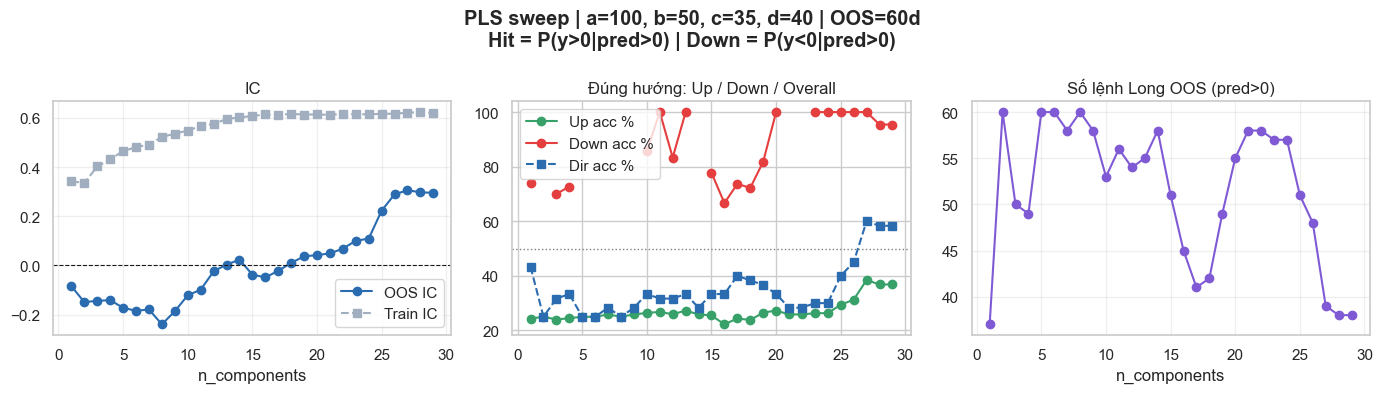

In [349]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# ============================================================
# PARAMS
# ============================================================
best = study.best_trial
a = best.user_attrs["a"]
b = best.user_attrs["b"]
c = best.user_attrs["c"]
d = best.user_attrs["d"]

N_COMP_LIST = list(range(1, 30))
LOOKBACK = LOOKBACK_DAYS
OOS = OOS_DAYS
MIN_SIGNALS = 3  # tối thiểu số lệnh long để tính hit/down

print(f"Fixed: a={a}, b={b}, c={c}, d={d}")
print("=" * 70)

# ============================================================
# DATA
# ============================================================
df_feat = build_features(df_vni_raw, investor_groups, a, b, c, d)
target = build_target(df_vni_raw, horizon=10)
model_data = pd.concat([df_feat, target], axis=1)
model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()

y_col = target.name
X_cols = list(df_feat.columns)

total_needed = LOOKBACK + OOS
train_data = model_data.iloc[-total_needed:-OOS].copy()
oos_data = model_data.iloc[-OOS:].copy()

X_train = StandardScaler().fit_transform(train_data[X_cols].values)
y_train = train_data[y_col].values
scaler = StandardScaler().fit(train_data[X_cols].values)
X_train = scaler.transform(train_data[X_cols].values)
X_oos = scaler.transform(oos_data[X_cols].values)
y_oos = oos_data[y_col].values

n_feat, n_samp = X_train.shape[1], X_train.shape[0]

def direction_stats(pred, y, min_sig=3):
    """
    Up accuracy  = P(y>0 | pred>0)
    Down accuracy = P(y<0 | pred<0)
    """
    mask_up = pred > 0
    mask_dn = pred < 0
    n_up = int(mask_up.sum())
    n_dn = int(mask_dn.sum())

    up_acc = float((y[mask_up] > 0).mean()) if n_up >= min_sig else np.nan
    dn_acc = float((y[mask_dn] < 0).mean()) if n_dn >= min_sig else np.nan

    # optional: overall directional accuracy (bỏ pred≈0)
    mask_dir = pred != 0
    if mask_dir.sum() >= min_sig:
        correct = ((pred > 0) & (y > 0)) | ((pred < 0) & (y < 0))
        dir_acc = float(correct[mask_dir].mean())
    else:
        dir_acc = np.nan

    return dict(
        n_up=n_up,
        n_down=n_dn,
        up_acc=up_acc,      # đúng khi đoán UP
        down_acc=dn_acc,    # đúng khi đoán DOWN
        dir_acc=dir_acc,    # đúng hướng tổng (up hoặc down)
    )

# ============================================================
# SWEEP
# ============================================================
rows = []
for n_comp in N_COMP_LIST:
    n_comp_eff = int(max(1, min(n_comp, n_feat, n_samp - 1)))
    try:
        model = PLSRegression(n_components=n_comp_eff, scale=False)
        model.fit(X_train, y_train)
        pred_tr = model.predict(X_train).ravel()
        pred_oos = model.predict(X_oos).ravel()

        if np.std(pred_oos) < 1e-8:
            rows.append({"n_components": n_comp_eff, "oos_ic": np.nan})
            continue

        tr_ic, _ = spearmanr(pred_tr, y_train)
        oos_ic, _ = spearmanr(pred_oos, y_oos)
        st_oos = direction_stats(pred_oos, y_oos, min_sig=MIN_SIGNALS)
        st_tr  = direction_stats(pred_tr, y_train, min_sig=15)

        rows.append({
            "n_components": n_comp_eff,
            "train_ic": float(tr_ic) if not np.isnan(tr_ic) else np.nan,
            "oos_ic": float(oos_ic) if not np.isnan(oos_ic) else np.nan,
            "oos_up_acc": st_oos["up_acc"],
            "oos_down_acc": st_oos["down_acc"],
            "oos_dir_acc": st_oos["dir_acc"],
            "oos_n_up": st_oos["n_up"],
            "oos_n_down": st_oos["n_down"],
            "train_up_acc": st_tr["up_acc"],
            "train_down_acc": st_tr["down_acc"],
            "gap_ic": (float(tr_ic) - float(oos_ic))
                if not (np.isnan(tr_ic) or np.isnan(oos_ic)) else np.nan,
        })
    except Exception as e:
        rows.append({"n_components": n_comp, "error": str(e)})

df_sweep = pd.DataFrame(rows)

# In bảng chính
cols_show = [
    "n_components", "oos_ic",
    "oos_up_acc", "oos_down_acc", "oos_dir_acc",
    "oos_n_up", "oos_n_down",
    "train_ic", "gap_ic",
]
print(df_sweep[cols_show].to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# cols_show = [c for c in cols_show if c in df_sweep.columns]
# print("\n=== OOS IC / Hit / Down theo n_components ===\n")
# print(df_sweep[cols_show].to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ============================================================
# PLOT
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.plot(df_sweep["n_components"], df_sweep["oos_ic"], "o-", label="OOS IC", color="#2b6cb0")
ax.plot(df_sweep["n_components"], df_sweep["train_ic"], "s--", label="Train IC", color="#a0aec0")
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.set_title("IC")
ax.set_xlabel("n_components")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(df_sweep["n_components"], df_sweep["oos_up_acc"] * 100, "o-", label="Up acc %", color="#38a169")
ax.plot(df_sweep["n_components"], df_sweep["oos_down_acc"] * 100, "o-", label="Down acc %", color="#e53e3e")
ax.plot(df_sweep["n_components"], df_sweep["oos_dir_acc"] * 100, "s--", label="Dir acc %", color="#2b6cb0")
ax.axhline(50, color="gray", ls=":", lw=1)
ax.set_title("Đúng hướng: Up / Down / Overall")
ax.legend()

ax = axes[2]
ax.plot(df_sweep["n_components"], df_sweep["oos_n_up"], "o-", color="#805ad5")
ax.set_title("Số lệnh Long OOS (pred>0)")
ax.set_xlabel("n_components")
ax.grid(True, alpha=0.3)

fig.suptitle(
    f"PLS sweep | a={a}, b={b}, c={c}, d={d} | OOS={OOS}d\n"
    f"Hit = P(y>0|pred>0) | Down = P(y<0|pred>0)",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

BEST PARAMS (OLS)
a = 120 | b = 60 | c = 25 | d = 40
LOOKBACK = 1000 | OOS = 30
TRAIN (Đầy đủ Target): 1000 | OOS (Gồm ngày mới nhất): 30

========== OOS ==========
IC          : 0.5789
Hit Rate    : 1.0000
Signals     : 2
Tổng số phiên OOS hiển thị: 30 (Đã có kết quả: 20)

=== Rank IC (Train+OOS) = 0.6066 ===
                mean    std  count  hit_rate  avg_pred
score_decile                                          
0            -0.0726 0.0883    102    0.0980   -0.0768
1            -0.0264 0.0347    102    0.2059   -0.0361
2            -0.0117 0.0385    102    0.2941   -0.0225
3            -0.0165 0.0372    102    0.2549   -0.0137
4            -0.0047 0.0302    102    0.3824   -0.0062
5            -0.0010 0.0319    102    0.4608    0.0009
6             0.0113 0.0402    102    0.6373    0.0101
7             0.0194 0.0382    102    0.6765    0.0221
8             0.0289 0.0377    102    0.7843    0.0406
9             0.0818 0.0541    102    0.9608    0.0774


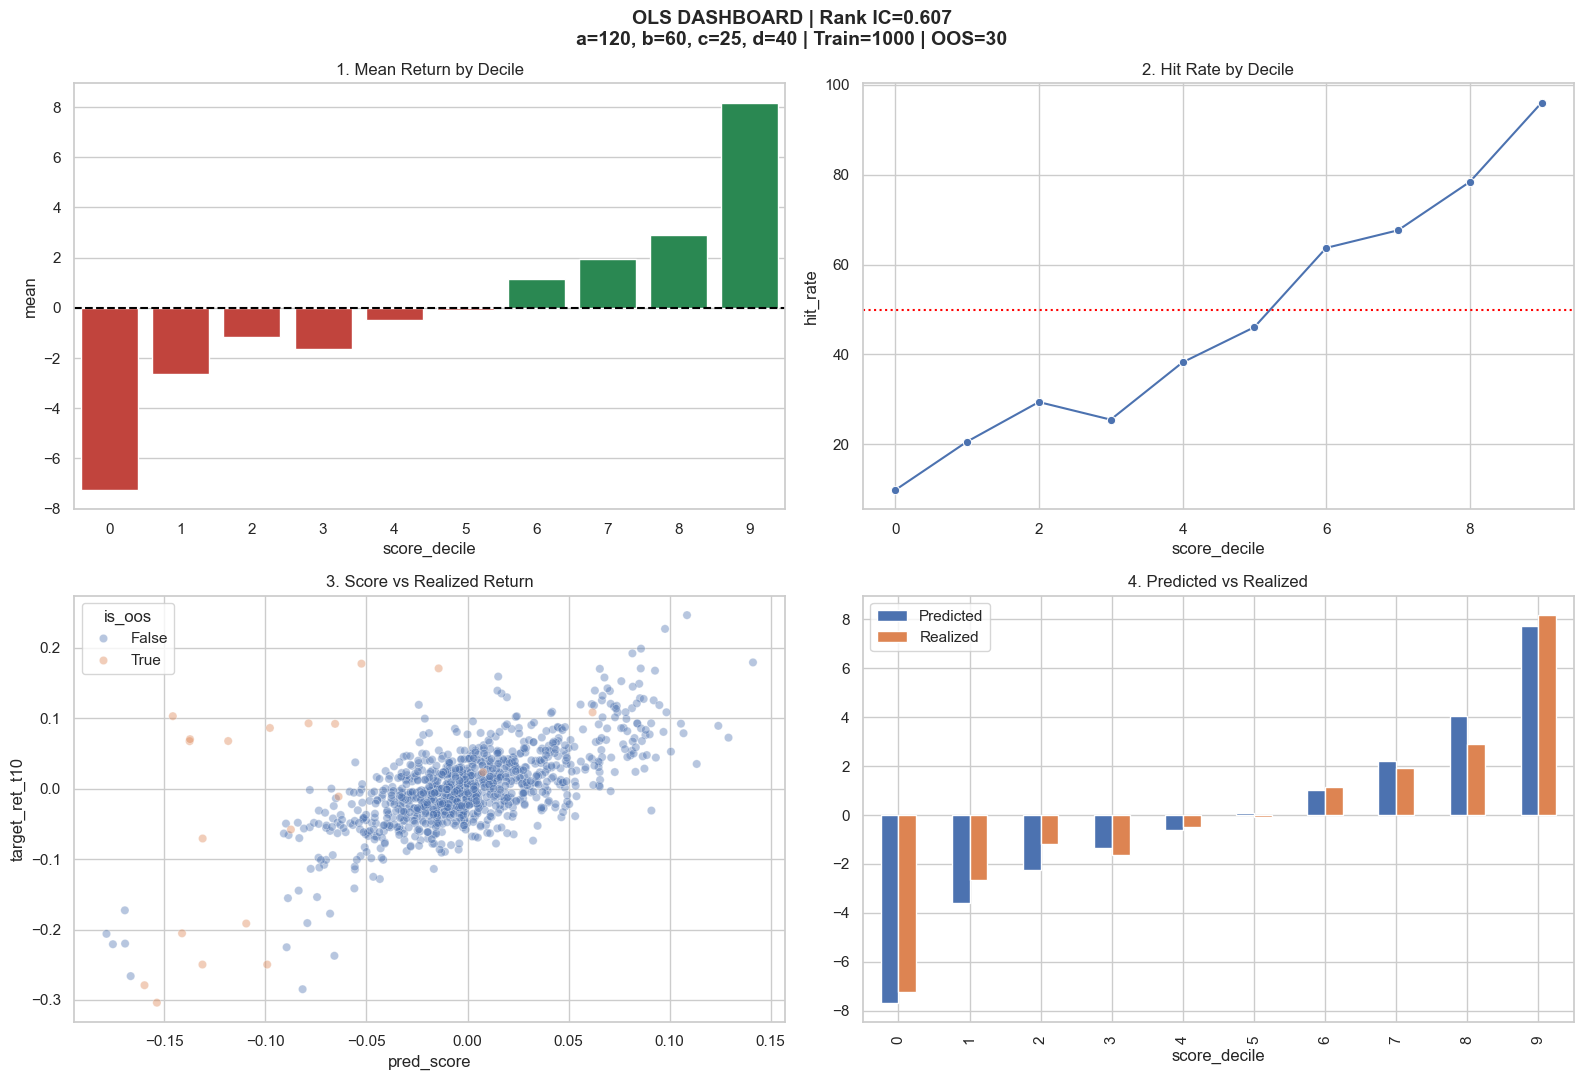

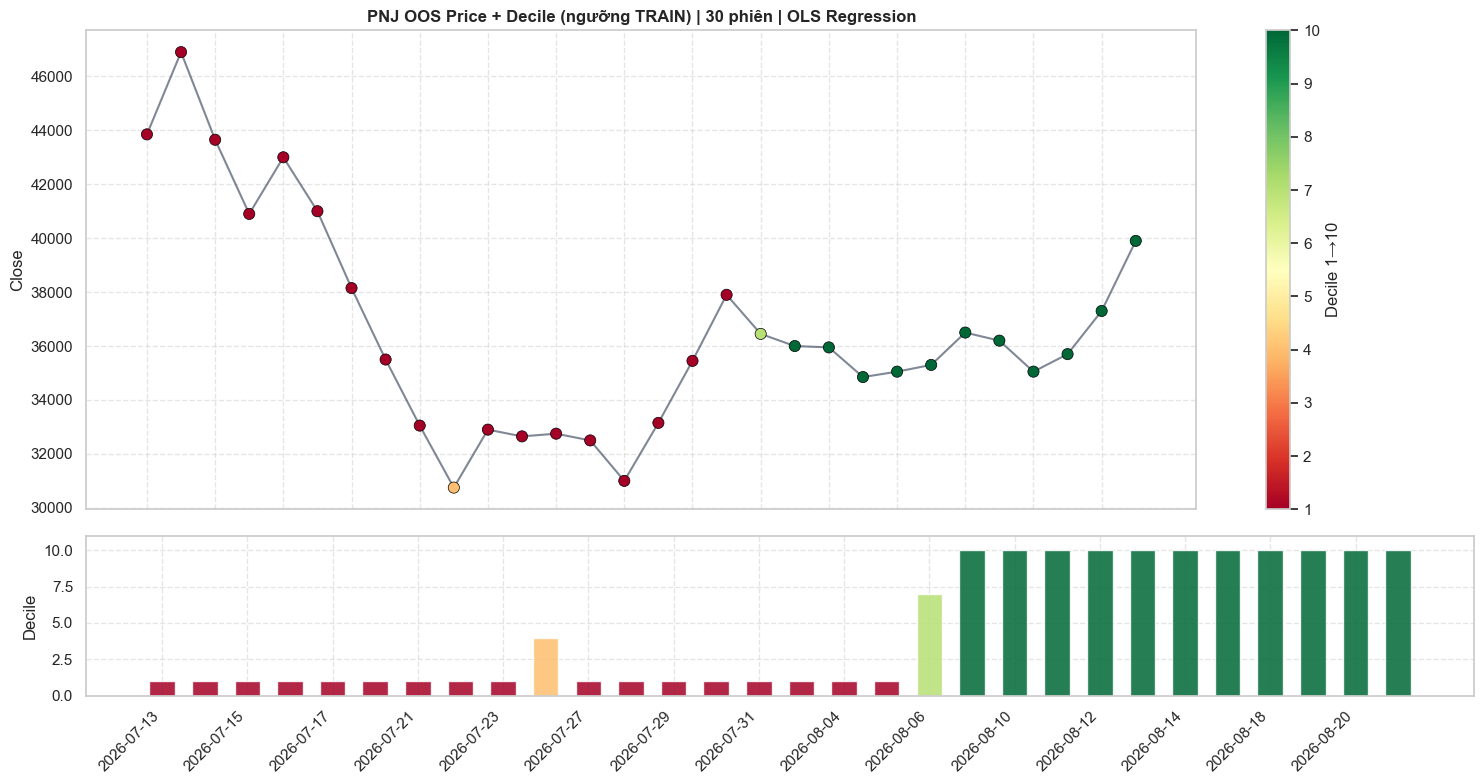

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# 1. LẤY BEST PARAMS TỪ OPTUNA (PLS)
# ============================================================
best = study.best_trial

a = best.user_attrs["a"]
b = best.user_attrs["b"]
c = best.user_attrs["c"]
d = best.user_attrs["d"]
n_components = int(best.user_attrs["n_components"])

print("=" * 70)
print("BEST PARAMS (PLS)")
print("=" * 70)
print(f"a = {a} | b = {b} | c = {c} | d = {d}")
print(f"n_components = {n_components}")
print(f"LOOKBACK = {LOOKBACK_DAYS} | OOS = {OOS_DAYS}")
print("=" * 70)

y_col = "target_ret_t10"

# ============================================================
# 2. TẠO FEATURE + TARGET (đúng chữ ký build_features của bạn)
# ============================================================
df_feat = build_features(df_vni_raw, investor_groups, a, b, c, d)
target = build_target(df_vni_raw, horizon=10)

model_data = pd.concat([df_feat, target], axis=1)
model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()

# Thêm close để vẽ biểu đồ giá (không dùng để train)
close_aligned = df_vni_raw["close"].ffill().reindex(model_data.index)
model_data["close"] = close_aligned

X_cols = list(df_feat.columns)
print(f"Số feature: {len(X_cols)} | Số dòng hợp lệ: {len(model_data)}")

# ============================================================
# 3. CẮT TRAIN / OOS
# ============================================================
total_needed = LOOKBACK_DAYS + OOS_DAYS

if len(model_data) >= total_needed:
    train_data = model_data.iloc[-total_needed:-OOS_DAYS].copy()
    oos_data = model_data.iloc[-OOS_DAYS:].copy()
else:
    if len(model_data) > OOS_DAYS:
        train_data = model_data.iloc[:-OOS_DAYS].copy()
        oos_data = model_data.iloc[-OOS_DAYS:].copy()
    else:
        train_data = model_data.copy()
        oos_data = pd.DataFrame(columns=model_data.columns)

print(f"TRAIN: {len(train_data)} | OOS: {len(oos_data)}")

# ============================================================
# 4. FIT PLS TRÊN TRAIN
# ============================================================
X_train = train_data[X_cols].values
y_train = train_data[y_col].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

n_feat = X_train_scaled.shape[1]
n_samp = X_train_scaled.shape[0]
n_comp = int(max(1, min(n_components, n_feat, n_samp - 1)))

model = PLSRegression(n_components=n_comp, scale=False)
model.fit(X_train_scaled, y_train)

train_data = train_data.copy()
train_data["pred_score"] = model.predict(X_train_scaled).ravel()
train_data["actual_ret"] = y_train

ic_train, _ = spearmanr(train_data["pred_score"], train_data["actual_ret"])
hit_train = (
    train_data.loc[train_data["pred_score"] > 0, "actual_ret"] > 0
).mean()

print("\n========== TRAIN ==========")
print(f"IC           : {ic_train:.4f}")
print(f"Hit Rate     : {hit_train:.4f}")
print(f"n_components : {n_comp}")
print(f"Số quan sát  : {len(train_data)}")
print(f"Pred std     : {train_data['pred_score'].std():.6f}")

# ============================================================
# 5. ĐÁNH GIÁ OOS
# ============================================================
if len(oos_data) > 0:
    X_oos = oos_data[X_cols].values
    X_oos_scaled = scaler.transform(X_oos)

    oos_data = oos_data.copy()
    oos_data["pred_score"] = model.predict(X_oos_scaled).ravel()
    oos_data["actual_ret"] = oos_data[y_col].values

    ic_oos, _ = spearmanr(oos_data["pred_score"], oos_data["actual_ret"])
    n_sig = int((oos_data["pred_score"] > 0).sum())
    hit_oos = (
        (oos_data.loc[oos_data["pred_score"] > 0, "actual_ret"] > 0).mean()
        if n_sig > 0
        else np.nan
    )

    print("\n========== OOS ==========")
    print(f"IC          : {ic_oos:.4f}")
    print(f"Hit Rate    : {hit_oos:.4f}")
    print(f"Signals     : {n_sig}")
    print(f"Số quan sát : {len(oos_data)}")
else:
    print("\n[OOS] Không đủ dữ liệu")

# ============================================================
# 6. DECILE ANALYSIS (Train + OOS)
# ============================================================
parts = [train_data[["pred_score", y_col]].assign(is_oos=False)]
if len(oos_data) > 0:
    parts.append(oos_data[["pred_score", y_col]].assign(is_oos=True))

eval_data = pd.concat(parts, axis=0).dropna()
eval_data["score_decile"] = pd.qcut(
    eval_data["pred_score"], 10, labels=False, duplicates="drop"
)

analysis = eval_data.groupby("score_decile")[y_col].agg(["mean", "std", "count"])
analysis["hit_rate"] = eval_data.groupby("score_decile")[y_col].apply(
    lambda x: (x > 0).mean()
)
analysis["avg_pred"] = eval_data.groupby("score_decile")["pred_score"].mean()

rank_ic = eval_data["pred_score"].corr(eval_data[y_col], method="spearman")
print(f"\n=== Rank IC (Train+OOS) = {rank_ic:.4f} ===")
print(analysis)

# ============================================================
# 7. DASHBOARD
# ============================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    f"PLS DASHBOARD | Rank IC={rank_ic:.3f} | n_comp={n_comp}\n"
    f"a={a}, b={b}, c={c}, d={d} | Train={len(train_data)} | OOS={len(oos_data)}",
    fontsize=14,
    fontweight="bold",
)

colors = ["#d73027" if x < 0 else "#1a9850" for x in analysis["mean"]]
sns.barplot(x=analysis.index, y=analysis["mean"] * 100, ax=axes[0, 0], palette=colors)
axes[0, 0].axhline(0, color="black", ls="--")
axes[0, 0].set_title("1. Mean Return by Decile")

sns.lineplot(x=analysis.index, y=analysis["hit_rate"] * 100, ax=axes[0, 1], marker="o")
axes[0, 1].axhline(50, color="red", ls=":")
axes[0, 1].set_title("2. Hit Rate by Decile")

sns.scatterplot(
    data=eval_data, x="pred_score", y=y_col, hue="is_oos", ax=axes[1, 0], alpha=0.4
)
axes[1, 0].set_title("3. Score vs Realized Return")

pd.DataFrame(
    {
        "Predicted": analysis["avg_pred"] * 100,
        "Realized": analysis["mean"] * 100,
    }
).plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("4. Predicted vs Realized")

plt.tight_layout()
plt.show()

# ============================================================
# 8. BIỂU ĐỒ GIÁ + DECILE OOS (ngưỡng decile từ TRAIN)
# ============================================================
if len(oos_data) > 0 and "close" in oos_data.columns:
    train_scores = train_data["pred_score"]
    _, bin_edges = pd.qcut(train_scores, q=10, duplicates="drop", retbins=True)
    bin_edges = bin_edges.copy()
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf
    n_deciles = len(bin_edges) - 1

    oos_data = oos_data.copy()
    oos_data["decile"] = (
        pd.cut(
            oos_data["pred_score"],
            bins=bin_edges,
            labels=False,
            include_lowest=True,
        )
        + 1
    )

    if "time" in df_vni_raw.columns:
        raw_dates = df_vni_raw.loc[oos_data.index, "time"]
    else:
        raw_dates = oos_data.index

    if pd.api.types.is_datetime64_any_dtype(raw_dates):
        x_dates = pd.to_datetime(raw_dates).dt.strftime("%Y-%m-%d").values
    else:
        x_dates = pd.to_datetime(raw_dates).strftime("%Y-%m-%d").values

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
    )

    ax1.plot(
        x_dates, oos_data["close"], color="#4A5568", lw=1.5, alpha=0.7, label="Close"
    )
    sc = ax1.scatter(
        x_dates,
        oos_data["close"],
        c=oos_data["decile"],
        cmap="RdYlGn",
        vmin=1,
        vmax=n_deciles,
        s=65,
        zorder=5,
        edgecolors="black",
        linewidth=0.5,
    )
    title_sym = globals().get("SYMBOL", "")
    ax1.set_title(
        f"{title_sym} OOS Price + Decile (ngưỡng TRAIN) | {len(oos_data)} phiên | PLS n_comp={n_comp}",
        fontweight="bold",
    )
    ax1.set_ylabel("Close")
    ax1.grid(True, ls="--", alpha=0.5)
    plt.colorbar(sc, ax=ax1, label=f"Decile 1→{n_deciles}")

    norm = (n_deciles - 1) if n_deciles > 1 else 1
    bar_colors = plt.cm.RdYlGn((oos_data["decile"].astype(float) - 1) / norm)
    ax2.bar(x_dates, oos_data["decile"], color=bar_colors, alpha=0.85, width=0.6)
    ax2.set_ylabel("Decile")
    ax2.set_ylim(0, n_deciles + 1)
    ax2.grid(True, ls="--", alpha=0.5)
    plt.xticks(
        rotation=45,
        ha="right",
        ticks=range(0, len(x_dates), max(1, len(x_dates) // 15)),
    )

    plt.tight_layout()
    plt.show()

In [321]:
import numpy as np
import pandas as pd

# Giả sử bạn đã fit xong:
# model = PLSRegression(...).fit(X_train_scaled, y_train)
# X_cols = list feature

# ----- 1. Hệ số PLS (độ lớn ảnh hưởng) -----
coef = model.coef_.ravel()          # shape (n_features,)
coef_df = pd.DataFrame({
    "feature": X_cols,
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)

print("=" * 60)
print("TOP 20 BIẾN CÓ |HỆ SỐ PLS| LỚN NHẤT")
print("=" * 60)
print(coef_df.head(20).to_string(index=False))


# ----- 2. VIP (Variable Importance in Projection) – chuẩn của PLS -----
def compute_vip(model, X, y):
    """
    Tính VIP score cho PLS
    """
    t = model.x_scores_              # (n_samples, n_components)
    w = model.x_weights_             # (n_features, n_components)
    q = model.y_loadings_            # (n_components,) hoặc (1, n_components)
    
    p, h = w.shape
    
    # Đảm bảo y là numpy array 2D
    y = np.asarray(y).reshape(-1, 1)
    
    # Đảm bảo q đúng shape
    q = np.asarray(q).reshape(-1)    # (n_components,)
    
    # SS cho từng component
    ssy = np.sum((t * q) ** 2, axis=0)   # (n_components,)
    total_ssy = np.sum(ssy)
    
    vip = np.zeros(p)
    for i in range(p):
        weight = np.array([w[i, j]**2 for j in range(h)])
        vip[i] = np.sqrt(p * (np.sum(weight * ssy) / total_ssy))
    
    return vip

vip_scores = compute_vip(model, X_train_scaled, y_train)

vip_df = pd.DataFrame({
    "feature": X_cols,
    "VIP": vip_scores,
    "abs_coef": np.abs(coef)
}).sort_values("VIP", ascending=False)

print("\n" + "=" * 60)
print("TOP 20 BIẾN THEO VIP (PLS)")
print("=" * 60)
print(vip_df.head(20).to_string(index=False))

print("\nSố biến có VIP > 1 :", (vip_df["VIP"] > 1).sum())
print("Số biến có VIP > 0.8:", (vip_df["VIP"] > 0.8).sum())

TOP 20 BIẾN CÓ |HỆ SỐ PLS| LỚN NHẤT
                                  feature    coef  abs_coef
                    inter_prop_sent_x_atr  0.1593    0.1593
                   feat_prop_vol_adj_sent  0.0841    0.0841
                feat_foreign_vol_adj_sent -0.0743    0.0743
     cross_agree_strength_prop_local_inst  0.0730    0.0730
               feat_prop_flow_impulse_35d -0.0651    0.0651
               inter_local_ind_sent_x_atr -0.0609    0.0609
        cross_prop_minus_local_ind_sent_z -0.0600    0.0600
               feat_foreign_sentiment_ewm -0.0596    0.0596
          cross_foreign_minus_prop_sent_z  0.0586    0.0586
              feat_local_ind_vol_adj_sent -0.0575    0.0575
cross_agree_strength_local_inst_local_ind  0.0512    0.0512
              inter_local_inst_sent_x_pos  0.0478    0.0478
  cross_local_inst_minus_local_ind_sent_z -0.0460    0.0460
                     cross_dispersion_iqr -0.0454    0.0454
                 inter_foreign_sent_x_atr -0.0442    0.0442
    

# Lại OLS nhma thay đổi features

In [423]:
SYMBOL = 'HPG'

# --- BƯỚC 1: CHUẨN BỊ DỮ LIỆU ---
excel_file_path_vni = rf"E:\Document\Tao\FiinGroup\csv_data_2\Kafi_Phân_Loại_Nhà_Đầu_Tư_{SYMBOL}.csv"
excel_file_path_vni_new = rf"E:\Document\Tao\FiinGroup\csv_data_2\Kafi_Giá_{SYMBOL}.csv"
# excel_file_path_vni = rf"E:\Document\Tao\FiinGroup\Kafi_Phân_Loại_Nhà_Đầu_Tư_{SYMBOL}_20260305.xlsx"

investor_groups = ['foreign', 'prop', 'local_ind', 'local_inst']

df_vni_raw = load_and_map_excel(excel_file_path_vni, df_history=None)

In [430]:
import optuna
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from scipy.stats import spearmanr
from itertools import combinations
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# CẤU HÌNH
# ============================================================
investor_groups = ["foreign", "prop", "local_inst", "local_ind"]
LOOKBACK_DAYS = 1000
OOS_DAYS = 40
TRIALS = 300

A_MIN, A_MAX = 50, 150
B_MIN, B_MAX = 50, 150
C_MIN, C_MAX = 15, 70
D_MIN, D_MAX = 15, 60

# Trọng số score (chỉ trên Train)
W_HIT = 0.60
W_IC = 0.40
W_TOP = 0.30          # Chất lượng 2 decile cao nhất
W_BOT = 0.20          # Chất lượng 2 decile thấp nhất

# Ngưỡng mong muốn
TOP_HIT_TARGET = 0.85         # 2 decile cao nhất nên ≥ 85% return dương
BOT_HIT_TARGET = 0.15         # 2 decile thấp nhất nên ≤ 15% return dương

# Ngưỡng trên TRAIN
MIN_SIGNALS_TRAIN_SOFT = 30
MIN_SIGNALS_TRAIN_HARD = 15
MIN_HIT_TRAIN_SOFT = 0.65
MIN_HIT_TRAIN_HARD = 0.6
MIN_IC_TRAIN_HARD = 0.02

# bad_result: đủ 11 phần tử, khớp unpack trong objective
BAD_RESULT = (-999.0, -1.0, 0.0, 0.0, 0, -1.0, 0.0, 999.0, 0.0, 0.0, 0.0)

# ============================================================
# FEATURE ENGINEERING
# ============================================================
def build_features(df_vni_raw, investor_groups, a, b, c, d):
    df = df_vni_raw.copy()
    keep_cols = [
        "open", "high", "low", "close", "trading_value",
        "foreign_net_val", "prop_net_val", "local_ind_net_val", "local_inst_net_val",
        "foreign_net_vol", "prop_net_vol", "local_ind_net_vol", "local_inst_net_vol",
    ]
    keep_cols = [col for col in keep_cols if col in df.columns]
    df = df[keep_cols]

    df["trading_value"] = df["trading_value"].replace(0, np.nan).ffill().bfill()
    df["close"] = df["close"].ffill()
    df["log_ret"] = np.log(df["close"] / df["close"].shift(1)).fillna(0)
    df["abs_ret"] = df["log_ret"].abs()

    tr = np.maximum(
        df["high"] - df["low"],
        np.maximum(
            (df["high"] - df["close"].shift(1)).abs(),
            (df["low"] - df["close"].shift(1)).abs(),
        ),
    )

    roll_high = df["high"].rolling(c).max()
    roll_low = df["low"].rolling(c).min()
    ta_pos_in_range = ((df["close"] - roll_low) / (roll_high - roll_low + 1e-8)).fillna(0.5)
    ta_atr_pct = (tr.ewm(span=b, adjust=False).mean() / df["close"]).fillna(0)

    feature_dict = {}

    for g in investor_groups:
        net_val = df[f"{g}_net_val"]
        net_ratio = net_val / df["trading_value"]
        df[f"feat_{g}_net_ratio"] = net_ratio.fillna(0)

        prev = net_ratio.shift(1).abs().clip(lower=1e-3)
        impact_raw = (df["abs_ret"].shift(1) / prev).rolling(5).median().fillna(0)
        df[f"feat_{g}_price_impact"] = np.clip(impact_raw, 0, 10)

        rmin = net_val.rolling(a, min_periods=5).min()
        rmax = net_val.rolling(a, min_periods=5).max()
        df[f"feat_{g}_sentiment"] = (
            2 * (net_val - rmin) / (rmax - rmin + 1e-6) - 1
        ).fillna(0)

        sent = df[f"feat_{g}_sentiment"]
        sent_ewm = sent.ewm(span=b, adjust=False).mean()
        feature_dict[f"feat_{g}_sentiment_ewm"] = sent_ewm

        sent_mean = sent_ewm.rolling(a, min_periods=10).mean()
        sent_std = sent_ewm.rolling(a, min_periods=10).std().replace(0, np.nan)
        sent_z = ((sent_ewm - sent_mean) / (sent_std + 1e-6)).clip(-3, 3).fillna(0)

        feature_dict[f"feat_{g}_sentiment_sq"] = sent_z**2
        feature_dict[f"feat_{g}_sentiment_cubed"] = (sent_z**3 - 3 * sent_z).clip(-10, 10)
        feature_dict[f"flag_{g}_sent_saturated"] = (sent_z.abs() >= 2.8).astype(int)

        impulse = sent_ewm.diff(d).fillna(0)
        feature_dict[f"feat_{g}_flow_impulse_{d}d"] = impulse
        imp_mean = impulse.rolling(a, min_periods=10).mean()
        imp_std = impulse.rolling(a, min_periods=10).std().replace(0, np.nan)
        imp_z = ((impulse - imp_mean) / (imp_std + 1e-6)).clip(-3, 3).fillna(0)

        feature_dict[f"feat_{g}_flow_impulse_{d}d_sq"] = imp_z**2
        feature_dict[f"feat_{g}_flow_impulse_{d}d_cubed"] = (imp_z**3 - 3 * imp_z).clip(-10, 10)

        eff_flow_raw = sent * df[f"feat_{g}_price_impact"]
        feature_dict[f"feat_{g}_eff_flow"] = np.sign(eff_flow_raw) * np.log1p(np.abs(eff_flow_raw))

        val_share = (df[f"{g}_net_val"].abs() / df["trading_value"]).clip(0, 1)
        feature_dict[f"feat_{g}_val_share"] = val_share
        feature_dict[f"feat_{g}_weighted_sent"] = sent_ewm * val_share

        feature_dict[f"inter_{g}_sent_x_pos"] = sent_z * ta_pos_in_range
        feature_dict[f"inter_{g}_sent_x_atr"] = sent_z * ta_atr_pct

        implied = np.where(
            df[f"{g}_net_vol"] != 0,
            df[f"{g}_net_val"] / df[f"{g}_net_vol"],
            0,
        )
        feature_dict[f"feat_{g}_rel_net_price_ewm"] = (
            pd.Series(implied / df["close"], index=df.index)
            .ewm(span=b, adjust=False)
            .mean()
        )
    sent_ewm = {g: feature_dict[f"feat_{g}_sentiment_ewm"] for g in investor_groups}
    sent_z = {}
    for g in investor_groups:
        mu = sent_ewm[g].rolling(a, min_periods=10).mean()
        sigma = sent_ewm[g].rolling(a, min_periods=10).std().replace(0, np.nan)
        sent_z[g] = ((sent_ewm[g] - mu) / (sigma + 1e-6)).clip(-3, 3).fillna(0)

    for g1, g2 in combinations(investor_groups, 2):
        feature_dict[f"cross_{g1}_minus_{g2}_sent_z"] = sent_z[g1] - sent_z[g2]
        feature_dict[f"cross_agree_sign_{g1}_{g2}"] = np.sign(sent_ewm[g1]) * np.sign(sent_ewm[g2])
        feature_dict[f"cross_agree_strength_{g1}_{g2}"] = sent_ewm[g1] * sent_ewm[g2]

    sent_matrix = pd.concat([sent_ewm[g] for g in investor_groups], axis=1)
    disp_std = sent_matrix.std(axis=1)
    feature_dict["cross_dispersion_std"] = disp_std
    feature_dict["cross_dispersion_range"] = sent_matrix.max(axis=1) - sent_matrix.min(axis=1)
    feature_dict["cross_dispersion_iqr"] = sent_matrix.quantile(0.75, axis=1) - sent_matrix.quantile(0.25, axis=1)

    smart_cols = [g for g in ["foreign", "prop", "local_inst"] if g in investor_groups]
    if "local_ind" in investor_groups and len(smart_cols) > 0:
        smart_sent = pd.concat([sent_ewm[g] for g in smart_cols], axis=1).mean(axis=1)
        feature_dict["cross_smart_vs_retail_sent"] = smart_sent - sent_ewm["local_ind"]

    for g in investor_groups:
        feature_dict[f"feat_{g}_vol_adj_sent"] = sent_ewm[g] / (disp_std + 1e-4)

    df_feat = pd.DataFrame(feature_dict, index=df.index)
    return df_feat.replace([np.inf, -np.inf], 0).fillna(0)


def build_target(df_vni_raw, horizon=10):
    close = df_vni_raw["close"].ffill()
    target = close.shift(-horizon) / close - 1
    target.name = f"target_ret_t{horizon}"
    return target

# ============================================================
# HÀM ĐÁNH GIÁ – OLS THUẦN
# ============================================================
def evaluate_params_ols(
    a, b, c, d,
    df_vni_raw,
    investor_groups,
    lookback_days=LOOKBACK_DAYS,
    oos_days=OOS_DAYS,
):
    try:
        df_feat = build_features(df_vni_raw, investor_groups, a, b, c, d)
        target = build_target(df_vni_raw, horizon=10)

        df_feat_clean = df_feat.replace([np.inf, -np.inf], np.nan).fillna(0)
        model_data = pd.concat([df_feat_clean, target], axis=1)

        if len(model_data) < (lookback_days + oos_days + 50):
            return BAD_RESULT

        # 1. Tập OOS: Lấy đúng OOS_DAYS gần đây nhất (Bảo toàn các phiên Target = NaN)
        oos_data = model_data.iloc[-oos_days:].copy()

        # 2. Tập TRAIN: Lấy các phiên trước OOS
        train_data = model_data.iloc[:-oos_days].iloc[-lookback_days:].copy()

        if len(train_data) < 300 or len(oos_data) < 10:
            return BAD_RESULT

        target_col = target.name
        X_train = train_data.drop(columns=[target_col]).values
        y_train = train_data[target_col].values
        X_oos   = oos_data.drop(columns=[target_col]).values
        y_oos   = oos_data[target_col].values

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_oos_scaled   = scaler.transform(X_oos)

        # ----- FIT OLS -----
        model = LinearRegression()
        model.fit(X_train_scaled, y_train)

        pred_train = model.predict(X_train_scaled).ravel()
        pred_oos   = model.predict(X_oos_scaled).ravel()

        if np.std(pred_train) < 1e-8:
            return BAD_RESULT

        # ============================================================
        # METRICS CƠ BẢN TRÊN TRAIN
        # ============================================================
        train_ic, _ = spearmanr(pred_train, y_train)
        if np.isnan(train_ic):
            train_ic = -1.0

        mask_up_train = pred_train > 0
        n_signals_train = int(mask_up_train.sum())

        if n_signals_train >= MIN_SIGNALS_TRAIN_HARD:
            hit_rate_train = float((y_train[mask_up_train] > 0).mean())
            avg_ret_train  = float(y_train[mask_up_train].mean())
        else:
            hit_rate_train = 0.50
            avg_ret_train  = 0.0

        # ============================================================
        # DECILE ANALYSIS TRÊN TRAIN
        # ============================================================
        try:
            deciles = pd.qcut(pred_train, 10, labels=False, duplicates="drop")
        except Exception:
            return BAD_RESULT

        df_dec = pd.DataFrame({"pred": pred_train, "y": y_train, "decile": deciles})
        decile_stats = df_dec.groupby("decile")["y"].agg(
            mean_ret="mean",
            hit_rate=lambda x: (x > 0).mean(),
            count="count"
        ).reindex(range(10))

        # 2 decile cao nhất (8, 9) và 2 decile thấp nhất (0, 1)
        top_stats = decile_stats.loc[[8, 9]].dropna()
        bot_stats = decile_stats.loc[[0, 1]].dropna()

        if len(top_stats) < 1 or len(bot_stats) < 1:
            return BAD_RESULT

        top_hit = top_stats["hit_rate"].mean()          
        bot_hit = bot_stats["hit_rate"].mean()          
        top_mean = top_stats["mean_ret"].mean()
        bot_mean = bot_stats["mean_ret"].mean()

        valid = decile_stats.dropna()
        if len(valid) >= 5:
            mono_score = spearmanr(valid.index, valid["mean_ret"])[0]
            if np.isnan(mono_score):
                mono_score = 0.0
        else:
            mono_score = 0.0

        # ============================================================
        # METRICS OOS (Lọc bỏ NaN do chưa có kết quả)
        # ============================================================
        valid_oos_mask = ~np.isnan(y_oos)
        y_oos_valid = y_oos[valid_oos_mask]
        pred_oos_valid = pred_oos[valid_oos_mask]

        if len(y_oos_valid) >= 3:
            oos_ic, _ = spearmanr(pred_oos_valid, y_oos_valid)
            if np.isnan(oos_ic): oos_ic = -1.0

            mask_up_oos = pred_oos_valid > 0
            n_signals_oos = int(mask_up_oos.sum())
            hit_rate_oos = float((y_oos_valid[mask_up_oos] > 0).mean()) if n_signals_oos > 0 else 0.50
            avg_ret_oos  = float(y_oos_valid[mask_up_oos].mean()) if n_signals_oos > 0 else 0.0
        else:
            oos_ic = -1.0
            hit_rate_oos = 0.50
            avg_ret_oos = 0.0
            n_signals_oos = 0

        train_oos_gap = train_ic - oos_ic

        # ============================================================
        # SCORE TỐI ƯU
        # ============================================================
        hit_term = (hit_rate_train - 0.50) * 2.0
        ic_term = np.clip(train_ic, -0.15, 0.60)
        top_term = np.clip((top_hit - 0.50) / 0.40, 0, 1.5)
        bot_term = np.clip((0.50 - bot_hit) / 0.40, 0, 1.5)
        mono_term = np.clip(mono_score, 0, 1.0)

        score = (
            W_HIT * hit_term +
            W_IC  * ic_term +
            W_TOP * top_term +
            W_BOT * bot_term +
            0.05  * mono_term          
        )

        if top_mean > 0:
            score += 0.02 * np.clip(top_mean * 10, 0, 0.3)
        if bot_mean < 0:
            score += 0.02 * np.clip(-bot_mean * 10, 0, 0.3)

        # Soft penalties
        if n_signals_train < MIN_SIGNALS_TRAIN_SOFT:
            score *= 0.75
        if hit_rate_train < MIN_HIT_TRAIN_SOFT:
            score *= 0.80
        if top_hit < 0.75:                     
            score *= 0.70
        if bot_hit > 0.25:                     
            score *= 0.75

        # Hard filters
        if (
            n_signals_train < MIN_SIGNALS_TRAIN_HARD
            or hit_rate_train < MIN_HIT_TRAIN_HARD
            or train_ic < MIN_IC_TRAIN_HARD
            or top_hit < 0.65
            or bot_hit > 0.35
        ):
            score = -999.0

        return (
            float(score),
            float(oos_ic),
            float(hit_rate_oos),
            float(avg_ret_oos),
            n_signals_oos,
            float(train_ic),
            float(hit_rate_train),
            float(train_oos_gap),
            float(top_hit),          
            float(bot_hit),
            float(mono_score),
        )

    except Exception as e:
        print(f"[EXCEPTION] a={a}, b={b}, c={c}, d={d} → {type(e).__name__}: {e}")
        return BAD_RESULT


# ============================================================
# OBJECTIVE (OPTUNA)
# ============================================================
def objective(trial):
    a = trial.suggest_int("window_z", A_MIN, A_MAX, step=10)
    b = trial.suggest_int("window_div", B_MIN, B_MAX, step=10)
    c = trial.suggest_int("pos_range", C_MIN, C_MAX, step=10)
    d = trial.suggest_int("impulse_days", D_MIN, D_MAX, step=5)

    result = evaluate_params_ols(
        a, b, c, d,
        df_vni_raw,
        investor_groups,
        lookback_days=LOOKBACK_DAYS,
        oos_days=OOS_DAYS,
    )

    if not isinstance(result, (list, tuple)) or len(result) < 8:
        return -999.0

    (score, oos_ic, hit_up, avg_ret, n_sig, 
     train_ic, hit_train, gap, top_hit, bot_hit, mono) = result

    trial.set_user_attr("ic", oos_ic)
    trial.set_user_attr("hit_rate_up", hit_up)
    trial.set_user_attr("avg_ret_when_up", avg_ret)
    trial.set_user_attr("n_signals", n_sig)
    trial.set_user_attr("train_ic", train_ic)
    trial.set_user_attr("hit_rate_train", hit_train)
    trial.set_user_attr("train_oos_gap", gap)
    trial.set_user_attr("top_hit", top_hit)          
    trial.set_user_attr("bot_hit", bot_hit)          
    trial.set_user_attr("mono_score", mono)
    trial.set_user_attr("a", a)
    trial.set_user_attr("b", b)
    trial.set_user_attr("c", c)
    trial.set_user_attr("d", d)

    return score


# ============================================================
# CHẠY TỐI ƯU OPTUNA
# ============================================================
if __name__ == "__main__":
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=30, n_warmup_steps=10),
    )
    study.optimize(objective, n_trials=TRIALS, show_progress_bar=True)

    best = study.best_trial
    print("\n" + "=" * 70)
    print("BEST TRIAL – OLS Regression (ưu tiên đơn điệu)")
    print("=" * 70)
    print(f"Score              : {best.value:.4f}")
    print(f"Train IC           : {best.user_attrs['train_ic']:.4f}")
    print(f"Train Hit Rate     : {best.user_attrs['hit_rate_train']:.4f}")
    print(f"Top-2 Decile Hit   : {best.user_attrs.get('top_hit', np.nan):.4f}")
    print(f"Bottom-2 Decile Hit: {best.user_attrs.get('bot_hit', np.nan):.4f}")
    print(f"Mono Score         : {best.user_attrs.get('mono_score', np.nan):.4f}")
    print(f"Train-OOS Gap      : {best.user_attrs['train_oos_gap']:.4f}")
    print(f"OOS IC (theo dõi)  : {best.user_attrs['ic']:.4f}")
    print(f"Hit Rate OOS       : {best.user_attrs['hit_rate_up']:.4f}")
    print(f"n_signals OOS      : {best.user_attrs['n_signals']}")
    print(
        f"\nParams: a={best.user_attrs['a']}, b={best.user_attrs['b']}, "
        f"c={best.user_attrs['c']}, d={best.user_attrs['d']}"
    )

[I 2026-08-24 23:51:11,423] A new study created in memory with name: no-name-9ed392d8-ca1c-4f9f-a94a-7fabd1f0aedc


  0%|          | 0/300 [00:00<?, ?it/s]

[I 2026-08-24 23:51:11,551] Trial 0 finished with value: 1.016352502929851 and parameters: {'window_z': 90, 'window_div': 150, 'pos_range': 55, 'impulse_days': 40}. Best is trial 0 with value: 1.016352502929851.
[I 2026-08-24 23:51:11,635] Trial 1 finished with value: 0.9133242644525434 and parameters: {'window_z': 60, 'window_div': 60, 'pos_range': 15, 'impulse_days': 55}. Best is trial 0 with value: 1.016352502929851.
[I 2026-08-24 23:51:11,710] Trial 2 finished with value: 0.9943369773686229 and parameters: {'window_z': 110, 'window_div': 120, 'pos_range': 15, 'impulse_days': 60}. Best is trial 0 with value: 1.016352502929851.
[I 2026-08-24 23:51:11,781] Trial 3 finished with value: 0.8663524914939836 and parameters: {'window_z': 140, 'window_div': 70, 'pos_range': 25, 'impulse_days': 20}. Best is trial 0 with value: 1.016352502929851.
[I 2026-08-24 23:51:11,846] Trial 4 finished with value: 0.9005236704626445 and parameters: {'window_z': 80, 'window_div': 100, 'pos_range': 35, 'imp

In [432]:
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# ============================================================
# 4. FIT OLS THUẦN VỚI STATSMODELS (LẤY R2, P-VALUE, T-STAT)
# ============================================================
X_train_df = train_data[X_cols]
y_train = train_data[y_col]

# Standardize dữ liệu và giữ lại tên cột DataFrame
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_df), columns=X_cols, index=train_data.index
)

# Thêm hằng số Intercept (Hệ số tự do) cho OLS
X_train_sm = sm.add_constant(X_train_scaled)

# Fit OLS Model
ols_model = sm.OLS(y_train, X_train_sm).fit()

# ----- 1. IN BẢNG SUMMARY TOÀN BỘ (Chuẩn báo cáo Kinh tế lượng) -----
print(ols_model.summary())

# ----- 2. BẢNG HỆ SỐ & P-VALUE DẠNG DATAFRAME (Dễ trích xuất) -----
ols_table = pd.DataFrame(
    {
        "Coefficient": ols_model.params,
        "Std Error": ols_model.bse,
        "t-statistic": ols_model.tvalues,
        "p-value": ols_model.pvalues,
        "[0.025": ols_model.conf_int()[0],
        "0.975]": ols_model.conf_int()[1],
    }
)

                            OLS Regression Results                            
Dep. Variable:         target_ret_t10   R-squared:                       0.543
Model:                            OLS   Adj. R-squared:                  0.511
Method:                 Least Squares   F-statistic:                     17.07
Date:                Mon, 24 Aug 2026   Prob (F-statistic):          5.93e-118
Time:                        23:51:49   Log-Likelihood:                 1678.3
No. Observations:                1000   AIC:                            -3225.
Df Residuals:                     934   BIC:                            -2901.
Df Model:                          65                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

BEST PARAMS (OLS)
a = 150 | b = 140 | c = 65 | d = 55
LOOKBACK = 1000 | OOS = 40
TRAIN (Đầy đủ Target): 1000 | OOS (Gồm ngày mới nhất): 40

========== OOS ==========
IC          : -0.5061
Hit Rate    : nan
Signals     : 0
Tổng số phiên OOS hiển thị: 40 (Đã có kết quả: 30)

=== Rank IC (Train+OOS) = 0.5927 ===
                mean    std  count  hit_rate  avg_pred
score_decile                                          
0            -0.0710 0.0758    103    0.0971   -0.1256
1            -0.0334 0.0444    103    0.1165   -0.0375
2            -0.0154 0.0360    103    0.2816   -0.0167
3             0.0000 0.0360    103    0.5049   -0.0052
4            -0.0004 0.0317    103    0.4466    0.0028
5             0.0076 0.0410    103    0.5146    0.0097
6             0.0181 0.0456    103    0.6505    0.0172
7             0.0122 0.0474    103    0.5437    0.0271
8             0.0440 0.0447    103    0.8447    0.0414
9             0.0936 0.0908    103    0.9223    0.0906


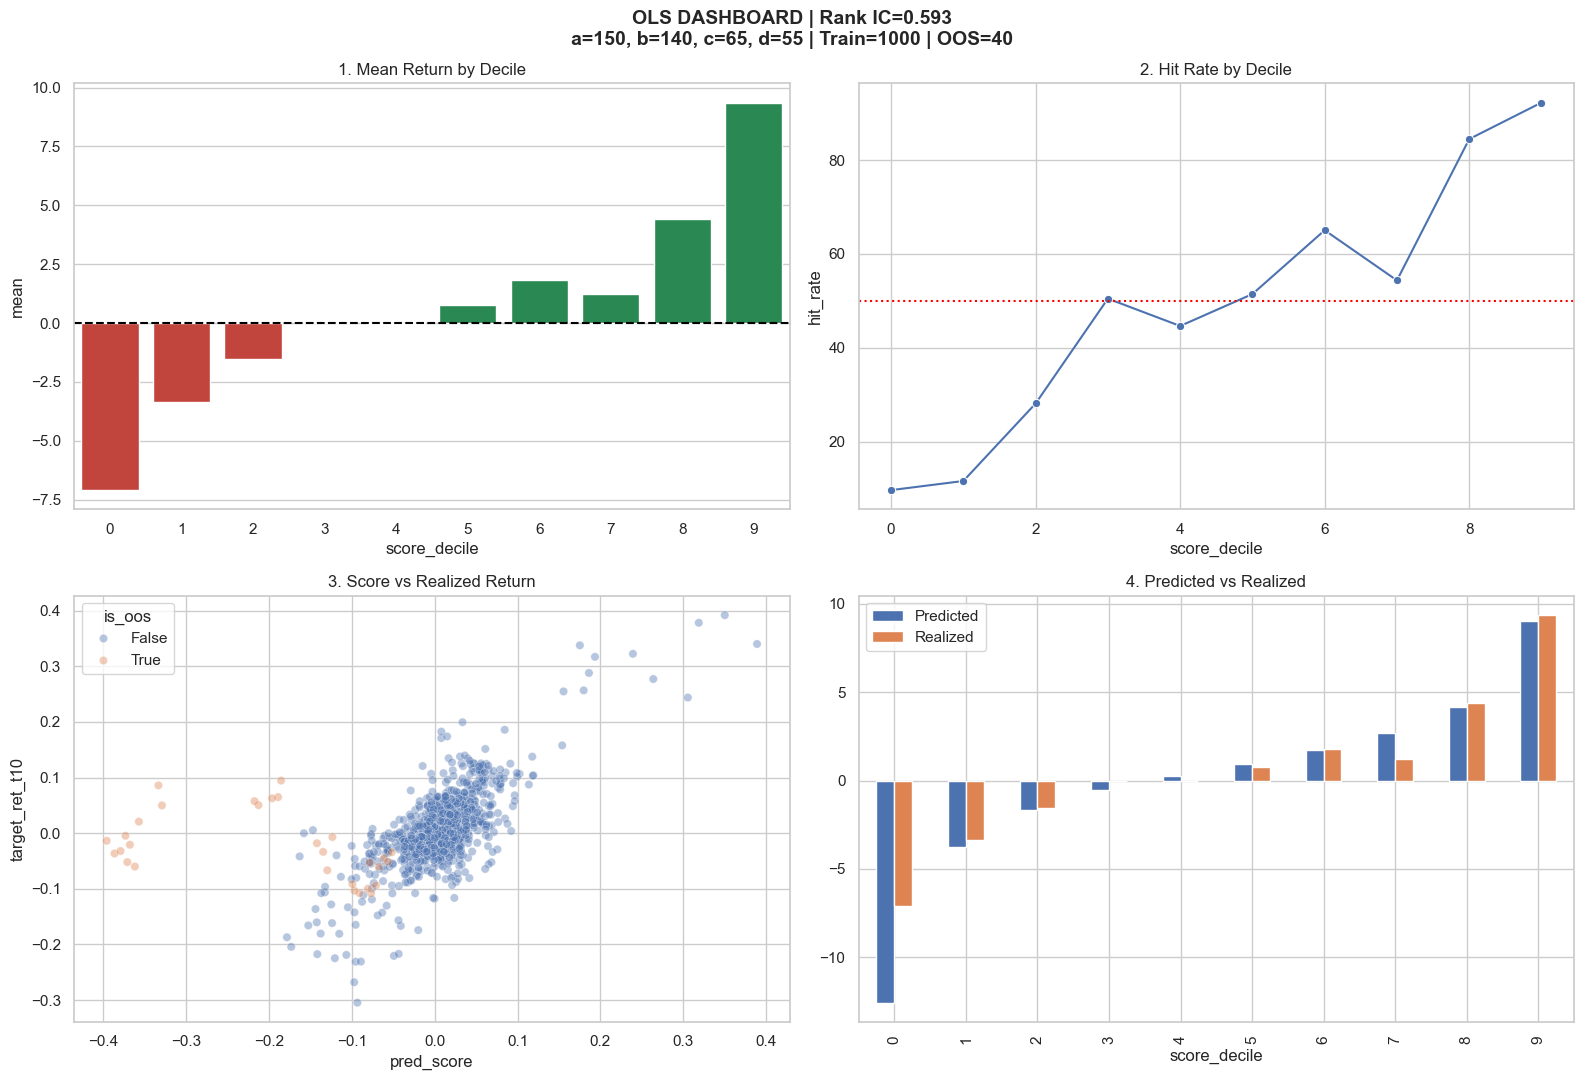

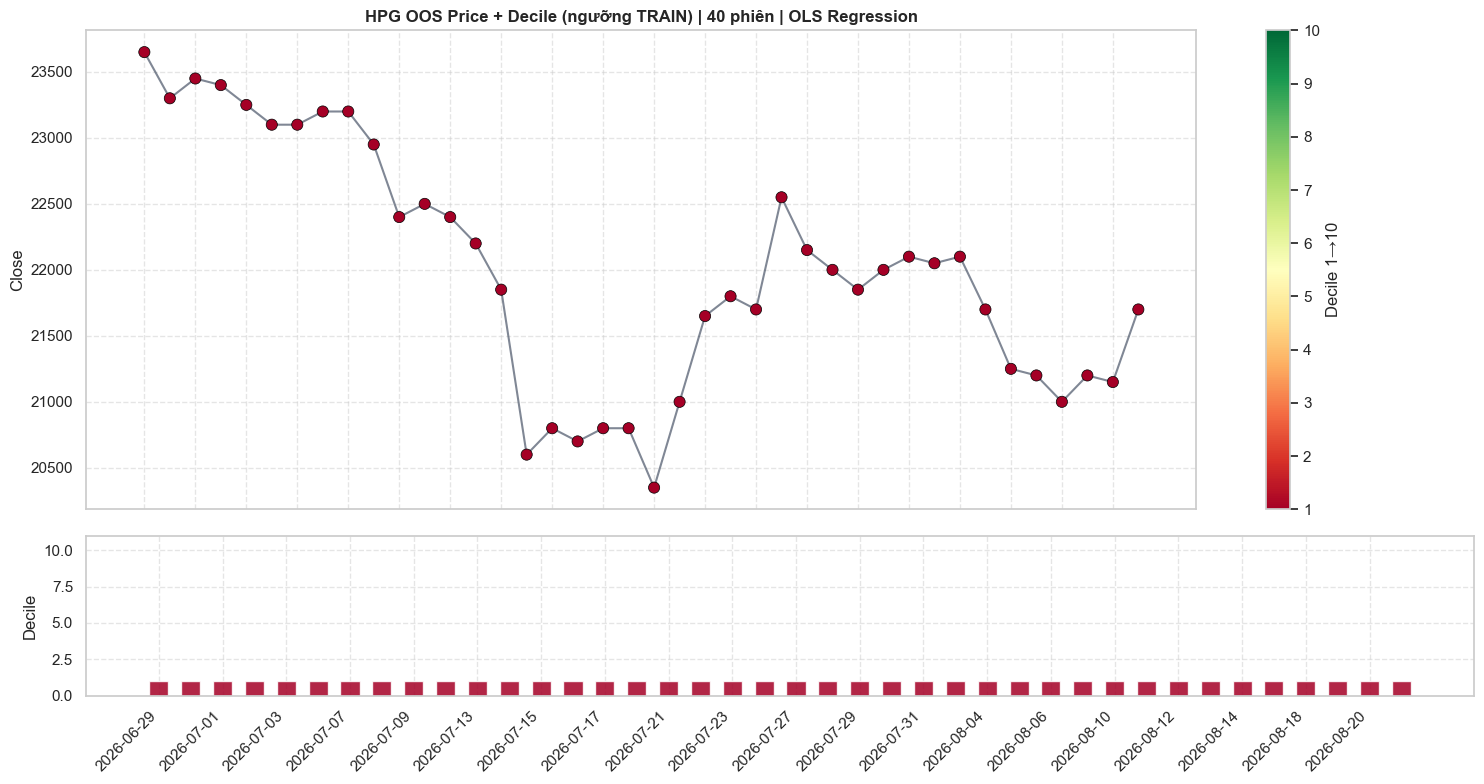

In [429]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# 1. LẤY BEST PARAMS TỪ OPTUNA (OLS)
# ============================================================
best = study.best_trial

a = best.user_attrs["a"]
b = best.user_attrs["b"]
c = best.user_attrs["c"]
d = best.user_attrs["d"]

print("=" * 70)
print("BEST PARAMS (OLS)")
print("=" * 70)
print(f"a = {a} | b = {b} | c = {c} | d = {d}")
print(f"LOOKBACK = {LOOKBACK_DAYS} | OOS = {OOS_DAYS}")
print("=" * 70)

y_col = "target_ret_t10"

# ============================================================
# 2. TẠO FEATURE + TARGET
# ============================================================
df_feat = build_features(df_vni_raw, investor_groups, a, b, c, d)
target = build_target(df_vni_raw, horizon=10)

# Gom dữ liệu nhưng xử lý inf/nan trên Feature trước
df_feat = df_feat.replace([np.inf, -np.inf], np.nan).dropna()
model_data = pd.concat([df_feat, target], axis=1)

close_aligned = df_vni_raw["close"].ffill().reindex(model_data.index)
model_data["close"] = close_aligned

X_cols = list(df_feat.columns)

# ============================================================
# 3. CẮT TRAIN / OOS
# ============================================================
# Tập OOS lấy đúng OOS_DAYS gần đây nhất (bao gồm cả các ngày target = NaN)
oos_data = model_data.iloc[-OOS_DAYS:].copy()

# Tập Train BẮT BUỘC phải có Target hợp lệ
model_data_valid = model_data.dropna(subset=[y_col])
total_needed = LOOKBACK_DAYS + OOS_DAYS

if len(model_data_valid) >= total_needed:
    train_data = model_data_valid.iloc[-total_needed:-OOS_DAYS].copy()
else:
    train_data = model_data_valid.iloc[:-OOS_DAYS].copy()

print(f"TRAIN (Đầy đủ Target): {len(train_data)} | OOS (Gồm ngày mới nhất): {len(oos_data)}")

# ============================================================
# 4. FIT OLS TRÊN TRAIN
# ============================================================
X_train = train_data[X_cols].values
y_train = train_data[y_col].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

train_data = train_data.copy()
train_data["pred_score"] = model.predict(X_train_scaled).ravel()
train_data["actual_ret"] = y_train

# ============================================================
# 5. ĐÁNH GIÁ OOS
# ============================================================
if len(oos_data) > 0:
    X_oos = oos_data[X_cols].values
    X_oos_scaled = scaler.transform(X_oos)

    oos_data = oos_data.copy()
    # Dự báo được điểm cho TẤT CẢ các ngày (kể cả hôm nay)
    oos_data["pred_score"] = model.predict(X_oos_scaled).ravel()
    oos_data["actual_ret"] = oos_data[y_col].values

    # Lọc các ngày đã có thực tế để tính IC & Hit Rate
    eval_oos = oos_data.dropna(subset=["actual_ret"])
    
    if len(eval_oos) > 0:
        ic_oos, _ = spearmanr(eval_oos["pred_score"], eval_oos["actual_ret"])
        n_sig = int((eval_oos["pred_score"] > 0).sum())
        hit_oos = (
            (eval_oos.loc[eval_oos["pred_score"] > 0, "actual_ret"] > 0).mean()
            if n_sig > 0 else np.nan
        )
    else:
        ic_oos, hit_oos, n_sig = np.nan, np.nan, 0

    print("\n========== OOS ==========")
    print(f"IC          : {ic_oos:.4f}")
    print(f"Hit Rate    : {hit_oos:.4f}")
    print(f"Signals     : {n_sig}")
    print(f"Tổng số phiên OOS hiển thị: {len(oos_data)} (Đã có kết quả: {len(eval_oos)})")

# ============================================================
# 6. DECILE ANALYSIS (Train + OOS)
# ============================================================
parts = [train_data[["pred_score", y_col]].assign(is_oos=False)]
if len(oos_data) > 0:
    parts.append(oos_data[["pred_score", y_col]].assign(is_oos=True))

eval_data = pd.concat(parts, axis=0).dropna()
eval_data["score_decile"] = pd.qcut(
    eval_data["pred_score"], 10, labels=False, duplicates="drop"
)

analysis = eval_data.groupby("score_decile")[y_col].agg(["mean", "std", "count"])
analysis["hit_rate"] = eval_data.groupby("score_decile")[y_col].apply(
    lambda x: (x > 0).mean()
)
analysis["avg_pred"] = eval_data.groupby("score_decile")["pred_score"].mean()

rank_ic = eval_data["pred_score"].corr(eval_data[y_col], method="spearman")
print(f"\n=== Rank IC (Train+OOS) = {rank_ic:.4f} ===")
print(analysis)

# ============================================================
# 7. DASHBOARD
# ============================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    f"OLS DASHBOARD | Rank IC={rank_ic:.3f}\n"
    f"a={a}, b={b}, c={c}, d={d} | Train={len(train_data)} | OOS={len(oos_data)}",
    fontsize=14,
    fontweight="bold",
)

colors = ["#d73027" if x < 0 else "#1a9850" for x in analysis["mean"]]
sns.barplot(x=analysis.index, y=analysis["mean"] * 100, ax=axes[0, 0], palette=colors)
axes[0, 0].axhline(0, color="black", ls="--")
axes[0, 0].set_title("1. Mean Return by Decile")

sns.lineplot(x=analysis.index, y=analysis["hit_rate"] * 100, ax=axes[0, 1], marker="o")
axes[0, 1].axhline(50, color="red", ls=":")
axes[0, 1].set_title("2. Hit Rate by Decile")

sns.scatterplot(
    data=eval_data, x="pred_score", y=y_col, hue="is_oos", ax=axes[1, 0], alpha=0.4
)
axes[1, 0].set_title("3. Score vs Realized Return")

pd.DataFrame(
    {
        "Predicted": analysis["avg_pred"] * 100,
        "Realized": analysis["mean"] * 100,
    }
).plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("4. Predicted vs Realized")

plt.tight_layout()
plt.show()

# ============================================================
# 8. BIỂU ĐỒ GIÁ + DECILE OOS (ngưỡng decile từ TRAIN)
# ============================================================
if len(oos_data) > 0 and "close" in oos_data.columns:
    train_scores = train_data["pred_score"]
    _, bin_edges = pd.qcut(train_scores, q=10, duplicates="drop", retbins=True)
    bin_edges = bin_edges.copy()
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf
    n_deciles = len(bin_edges) - 1

    oos_data = oos_data.copy()
    oos_data["decile"] = (
        pd.cut(
            oos_data["pred_score"],
            bins=bin_edges,
            labels=False,
            include_lowest=True,
        )
        + 1
    )

    if "time" in df_vni_raw.columns:
        raw_dates = df_vni_raw.loc[oos_data.index, "time"]
    else:
        raw_dates = oos_data.index

    if pd.api.types.is_datetime64_any_dtype(raw_dates):
        x_dates = pd.to_datetime(raw_dates).dt.strftime("%Y-%m-%d").values
    else:
        x_dates = pd.to_datetime(raw_dates).strftime("%Y-%m-%d").values

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
    )

    ax1.plot(
        x_dates, oos_data["close"], color="#4A5568", lw=1.5, alpha=0.7, label="Close"
    )
    sc = ax1.scatter(
        x_dates,
        oos_data["close"],
        c=oos_data["decile"],
        cmap="RdYlGn",
        vmin=1,
        vmax=n_deciles,
        s=65,
        zorder=5,
        edgecolors="black",
        linewidth=0.5,
    )
    title_sym = globals().get("SYMBOL", "")
    ax1.set_title(
        f"{title_sym} OOS Price + Decile (ngưỡng TRAIN) | {len(oos_data)} phiên | OLS Regression",
        fontweight="bold",
    )
    ax1.set_ylabel("Close")
    ax1.grid(True, ls="--", alpha=0.5)
    plt.colorbar(sc, ax=ax1, label=f"Decile 1→{n_deciles}")

    norm = (n_deciles - 1) if n_deciles > 1 else 1
    bar_colors = plt.cm.RdYlGn((oos_data["decile"].astype(float) - 1) / norm)
    ax2.bar(x_dates, oos_data["decile"], color=bar_colors, alpha=0.85, width=0.6)
    ax2.set_ylabel("Decile")
    ax2.set_ylim(0, n_deciles + 1)
    ax2.grid(True, ls="--", alpha=0.5)
    plt.xticks(
        rotation=45,
        ha="right",
        ticks=range(0, len(x_dates), max(1, len(x_dates) // 15)),
    )

    plt.tight_layout()
    plt.show()